In [154]:
%load_ext autoreload

%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [155]:
import pandas as pd
from datetime import datetime, timedelta
from difflib import SequenceMatcher
import matplotlib.pyplot as plt
import os
from pathlib import Path
import seaborn as sns
import numpy as np
from lifelines.utils import to_long_format
from lifelines.utils import add_covariate_to_timeline
from lifelines import CoxTimeVaryingFitter
from statsmodels.distributions.empirical_distribution import ECDF
from scipy.stats import ks_2samp
from scipy import stats
from matplotlib.ticker import MultipleLocator
import matplotlib.ticker as mtick
from lifelines import KaplanMeierFitter
import warnings
from preproces_prod3 import *
from scipy.stats import norm
import gspread
from oauth2client.service_account import ServiceAccountCredentials
warnings.filterwarnings("ignore")

In [4]:
path_actual = Path.cwd()
path_data = path_actual.parent / 'Data'

In [4]:
# Configurar las credenciales
scope = ["https://spreadsheets.google.com/feeds", "https://www.googleapis.com/auth/spreadsheets",
         "https://www.googleapis.com/auth/drive.file", "https://www.googleapis.com/auth/drive"]

creds = ServiceAccountCredentials.from_json_keyfile_name(path_actual.parent.parent/"credencials.json", scope)
client = gspread.authorize(creds)

# Abrir la hoja de cálculo
spreadsheet = client.open("Efecto_NIRSE")  # Reemplaza con el nombre de tu hoja de cálculo

In [297]:
df_pf = pre_filtred(df_name='NAC_RNI_EGRESOS_ENTREGA_ISCI_11_04_2025_encr.csv',lrti_name='LRTI_Flag')#NAC_RNI_EGRESOS_ENTREGA_ISCI_20_12_2024_encr
df_f_any, df_f_LRTI, df_f_vrs, df_f_upc = filtros_IH_new(df_pf)

pd.set_option('display.max_colwidth', None)
pd.set_option('display.max_columns', None)
T_final_tabla = pd.to_datetime('2024-09-30')

n_rows_inicial= 157557
['DESCONOCIDO---->None' 'Región De Antofagasta---->ANTOFAGASTA'
 'Región De Arica Parinacota---->ARICA Y PARINACOTA'
 'Región De Atacama---->ATACAMA'
 'Región De Aysén del General Carlos Ibañez del Campo---->AISEN'
 'Región De Coquimbo---->COQUIMBO' 'Región De La Araucanía---->ARAUCANIA'
 'Región De Los Lagos---->LOS LAGOS' 'Región De Los Ríos---->LOS RIOS'
 'Región De Magallanes y de la Antártica Chilena---->MAGALLANES Y ANTARTICA'
 'Región De Tarapacá---->TARAPACA' 'Región De Valparaíso---->VALPARAISO'
 'Región De Ñuble---->NUBLE' 'Región Del Bíobío---->BIOBIO'
 "Región Del Libertador Gral. B. O'Higgins---->O'HIGGINS"
 'Región Del Maule---->MAULE'
 'Región Metropolitana de Santiago---->METROPOLITANA']
n_rows_post_prefiltred= 157557
Datos perdidos por muertes:  1227
ruts perdidos por filtro semanas y peso:  491
Droped intersex: 14
Datos perdidos por edad madre atípica: 2
Datos perdidos por fecha ingreso menor a fecha nacimiento: 19
vrs en los primeros 7 dias de 

In [ ]:
dic_mes = {'octubre':1,'noviembre':2,'diciembre':3,'enero':4,'febrero':5,'marzo':6,'abril':7,'mayo':8,'junio':9,'julio':10,'agosto':11,'septiembre':12}

In [ ]:
df_f_vrs[~df_f_vrs['DIAG1'].isin(diagnosticosVRS)][col_diags].apply(lambda x: x.isin(diagnosticosVRS),axis=1).sum(axis=0).reset_index()

In [6]:
col_diags = ['DIAG1', 'DIAG2', 'DIAG3', 'DIAG4', 'DIAG5', 'DIAG6', 'DIAG7', 'DIAG8', 'DIAG9', 'DIAG10', 'DIAG11']
diagnosticosVRS = ['J121', 'J205', 'J210', 'J219', 'B974']

# Filter rows where DIAG1 does not contain any of the diagnosticosVRS codes
filtered_df = df_f_vrs[~df_f_vrs['DIAG1'].isin(diagnosticosVRS)]

# Count the total number of non-null values in DIAG2, DIAG3, ..., DIAG11
diags_count_total = filtered_df[col_diags[1:]].apply(lambda x: x.notna(), axis=1).sum(axis=0).reset_index()

# Count the number of diagnosticosVRS codes in DIAG2, DIAG3, ..., DIAG11
diags_count_vrs = filtered_df[col_diags[1:]].apply(lambda x: x.isin(diagnosticosVRS), axis=1).sum(axis=0).reset_index()

diags_count_total.columns = ['Diagnóstico', 'Total']
diags_count_vrs.columns = ['Diagnóstico', 'VRS']
table_counts = diags_count_total.merge(diags_count_vrs, on='Diagnóstico', how='left').set_index('Diagnóstico').T

In [169]:
table_counts

Diagnóstico,DIAG2,DIAG3,DIAG4,DIAG5,DIAG6,DIAG7,DIAG8,DIAG9,DIAG10,DIAG11
Total,1007,12670,5697,2950,1659,1051,744,528,377,255
VRS,5,84,21,7,4,1,1,0,1,0


In [8]:
worksheet = spreadsheet.worksheet("Tabla diag (apend)")

data = [table_counts.columns.names + list(table_counts.columns)]  # Encabezado
data += [[str(item) if not pd.isna(item) else "" for item in row] for row in table_counts.reset_index().values]


cell_start = 'B2'


num_rows, num_cols = len(data), len(data[0])
range_start = worksheet.cell(2, 2).address  # A1
range_end = worksheet.cell(2 + num_rows - 1, 2 + num_cols - 1).address  # Calcula la última celda
cell_range = f'{range_start}:{range_end}'


worksheet.clear()  # Limpia la hoja
worksheet.update(cell_range, data)
#worksheet.insert_rows(data, value_input_option='USER_ENTERED')

{'spreadsheetId': '1-2qpesSusN3YQRlCdzCRIseRBAr8cpvPfjLu45BZgos',
 'updatedRange': "'Tabla diag (apend)'!B2:L4",
 'updatedRows': 3,
 'updatedColumns': 11,
 'updatedCells': 33}

### graficos

#### P vs J

In [ ]:
df1.assign(first_letter =  lambda x: x.DIAG1.str[0]).groupby(['take_nirse']).first_letter.value_counts().unstack(0)

In [66]:
copia = df1.copy()

#copia.loc[(copia['fechaIng_any'] - copia['fechaInm']).dt.days <= 7, 'fechaInm' ] = pd.NaT

df_histogram = copia.assign(take_nirse = lambda x: x.fechaInm.notnull()).sort_values(by='fechaIng_any').drop_duplicates(subset=['RUN'], keep='first').assign(first_letter=lambda x: x.DIAG1.str[0]) \
    .groupby(['take_nirse']).first_letter.value_counts().unstack(0)

# Reemplazar NaN por 0 para evitar errores al graficar
df_histogram = df_histogram.fillna(0)


df_histogram['Total'] = df_histogram[False] + df_histogram[True]

# Ordenar por la suma total en orden descendente
df_histogram = df_histogram.sort_values(by='Total', ascending=False)

# Eliminar la columna 'Total' (opcional si no la necesitas después)
df_histogram = df_histogram.drop(columns='Total')

In [ ]:
df_histogram

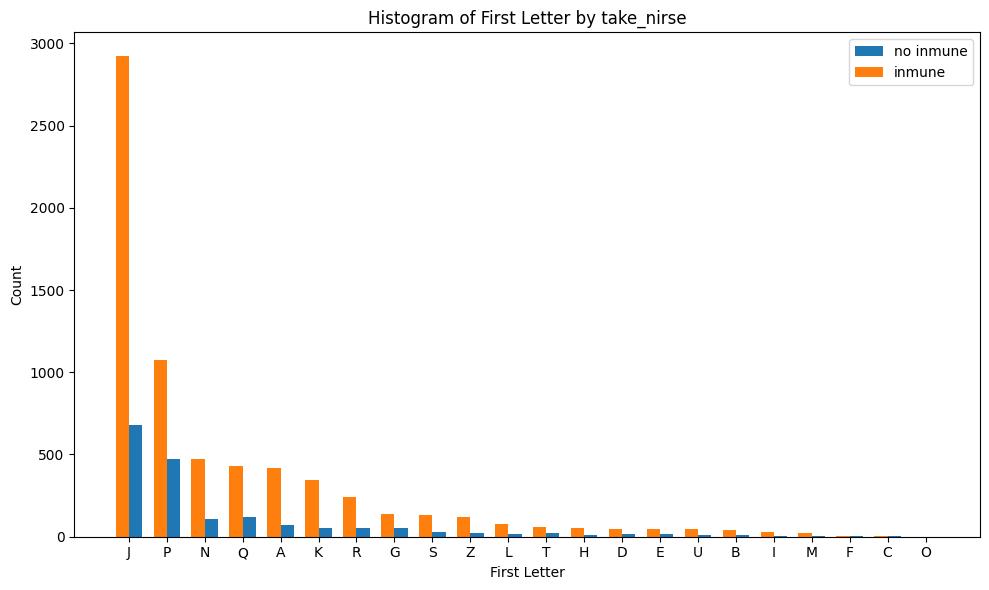

In [10]:
copia = df_f_any.copy()

#copia.loc[(copia['fechaIng_any'] - copia['fechaInm']).dt.days <= 7, 'fechaInm' ] = pd.NaT

#copia.loc[(copia['fechaIng_any'] - copia['fecha_nac']).dt.days <= 7, 'fechaIng_any' ] = pd.NaT

df_histogram = copia.assign(first_letter=lambda x: np.where(x.fechaIng_any.notna(), x.DIAG1.str[0], 'N/A')).dropna(subset=['fechaIng_any']).assign(take_nirse = lambda x: x.fechaInm.notnull()).sort_values(by='fechaIng_any').drop_duplicates(subset=['RUN'], keep='first') \
    .groupby(['take_nirse']).first_letter.value_counts().unstack(0)

# Reemplazar NaN por 0 para evitar errores al graficar
df_histogram = df_histogram.fillna(0)


df_histogram['Total'] = df_histogram[False] + df_histogram[True]

# Ordenar por la suma total en orden descendente
df_histogram = df_histogram.sort_values(by='Total', ascending=False)

# Eliminar la columna 'Total' (opcional si no la necesitas después)
df_histogram = df_histogram.drop(columns='Total')

# Crear un gráfico de barras agrupadas
x = df_histogram.index  # Las letras (first_letter)
width = 0.35  # Ancho de las barras

fig, ax = plt.subplots(figsize=(10, 6))

# Posiciones de las barras
x_indices = range(len(x))
bar1 = ax.bar([i + width/2 for i in x_indices], df_histogram[False], width, label='no inmune')
bar2 = ax.bar([i - width/2 for i in x_indices], df_histogram[True], width, label='inmune')

# Configuración del gráfico
ax.set_xlabel('First Letter')
ax.set_ylabel('Count')
ax.set_title('Histogram of First Letter by take_nirse')
ax.set_xticks(x_indices)
ax.set_xticklabels(x)
ax.legend()

# Mostrar el gráfico
plt.tight_layout()
plt.show()

In [13]:
df_sind = df_f_any.assign(first_letter=lambda x: np.where(x.fechaIng_any.notna(), x.DIAG1.str[0], 'N/A')).groupby('inmunizado').first_letter.value_counts().unstack(0).fillna(0).assign(Total = lambda x: x[0] + x[1], ratio = lambda x: x[1]/x[0]).sort_values(by='Total', ascending=False).drop(columns='Total')

In [14]:
df_sind

inmunizado,0,1,ratio
first_letter,,,
N/A,8166,133608,16.361499
J,678,2921,4.308260
P,473,1077,2.276956
N,108,470,4.351852
Q,118,428,3.627119
A,74,419,5.662162
K,56,343,6.125000
R,52,240,4.615385
G,50,138,2.760000


In [15]:
# df_sind = df1.copy()
# df_sind.loc[(df_sind['fechaIng_any'] - df_sind['fechaInm']).dt.days < 0, 'fechaInm' ] = pd.NaT
# df_sind.loc[(df_sind['fechaIng_any'] - df_sind['fecha_nac']).dt.days <= 7, 'fechaIng_any' ] = pd.NaT
# df_sind.loc[(df_sind['fechaIng_any'] - df_sind['fechaInm']).dt.days <= 7, 'fechaInm' ] = pd.NaT



# df_sind = (df_sind
#            #.query('fechaIng_any.notna()')
#            .sort_values(by='fechaIng_any')
#            .drop_duplicates(subset=['RUN'], keep='first')
#            .assign(ingreso_nona = lambda x: x.fechaIng_any.notna(), first_letter=lambda x: np.where(x.fechaIng_any.notna(), x.DIAG1.str[0], 'N/A'),
#                    take_nirse = lambda x: x.fechaInm.notnull())
#            .groupby(['take_nirse']).first_letter.value_counts()
#            .unstack(0)
#            .fillna(0)
#            .assign(Total = lambda x: x[False] + x[True], ratio = lambda x: x[True]/x[False])
#            .sort_values(by='Total', ascending=False)
#            .drop(columns='Total')
#            )


# df_vivos = df_pf.copy().query('VIVO=="SI"')
# df_vivos_f = df_vivos[(df_vivos['SEMANAS']>=28) & (df_vivos['SEMANAS']<=42) &
#                     (df_vivos['PESO'] >= df_vivos['p_00001_lognormal']) & (df_vivos['PESO'] <= df_vivos['p_99999_lognormal'])]
# df1 = df_vivos_f.query('SEXO!=9')
# df1 = df1[(df1['EDAD_M']<=51) & (df1['EDAD_M']>=12)]
# df1_outIngNac = df1[(df1['fechaIng_any'] < df1['fecha_nac'])]
# df1 = df1[~df1.RUN.isin(df1_outIngNac.RUN.unique())]
#df1 = df1.query('any_pre_campaña==0')

#df1.loc[df1.any_pre_campaña == 1, 'fechaIng_any'] = pd.NaT

# df_sind = df1.copy()


# df_sind.loc[(df_sind['fechaIng_any'] - df_sind['fecha_nac']).dt.days <= 7, 'fechaIng_any' ] = pd.NaT
# df_sind.loc[(df_sind['fechaIng_any'] - df_sind['fechaInm']).dt.days < 0, 'fechaInm' ] = pd.NaT
# df_sind.loc[(df_sind['fechaIng_any'] - df_sind['fechaInm']).dt.days <= 7, 'fechaInm' ] = pd.NaT

# df_sind.loc[df_sind.any_pre_campaña == 1, 'fechaIng_any'] = pd.NaT



df_sind2 = (df_f_any
           #.query('fechaIng_any.notna()')
           .sort_values(by='fechaIng_any')
           .drop_duplicates(subset=['RUN'], keep='first')
           .assign(ingreso = lambda x: np.where(x.fechaIng_any.notna(),'all_cause', 'N/A'), first_letter=lambda x: np.where(x.fechaIng_any.notna(), x.DIAG1.str[0], 'N/A'),
                   take_nirse = lambda x: x.fechaInm.notnull())
           .groupby(['take_nirse']).ingreso.value_counts()
           .unstack(0)
           .fillna(0)
           #.assign(Total = lambda x: x[False] + x[True], ratio = lambda x: x[True]/x[False])
           #.sort_values(by='Total', ascending=False)
           #.drop(columns='Total')
           )

df_sind2#.assign(eff_a_mano = lambda x: 100 - x.ratio)

take_nirse,False,True
ingreso,,
N/A,8166,133608
all_cause,1776,6718


In [16]:
# Extraer valores de la tabla
all_cause_no_vaccine = df_sind2.loc['all_cause', False]  # Enfermos sin vacuna
all_cause_vaccine = df_sind2.loc['all_cause', True]      # Enfermos con vacuna
total_no_vaccine = df_sind2[False].sum()                 # Total grupo sin vacuna
total_vaccine = df_sind2[True].sum()                     # Total grupo con vacuna

# Calcular tasas de ataque
AR_u = all_cause_no_vaccine / total_no_vaccine  # Tasa de ataque no vacunados
AR_v = all_cause_vaccine / total_vaccine        # Tasa de ataque vacunados

# Calcular efectividad de la vacuna
VE = (1 - (AR_v / AR_u)) * 100


print(f"Efectividad de la vacuna: {VE:.2f}%")

Efectividad de la vacuna: 73.20%


In [17]:
df_eff_manual = df_f_any.assign(ingreso = lambda x: np.where(x.fechaIng_any.notna(),'all_cause', 'N/A'), take_nirse=lambda x: np.where(x.fechaInm.notna(), 'inmune', 'no_inmune')).groupby(['take_nirse']).ingreso.value_counts().unstack(0).fillna(0)
display(df_eff_manual)
all_cause_no_vaccine = df_eff_manual.loc['all_cause', 'no_inmune']  # Enfermos sin vacuna
all_cause_vaccine = df_eff_manual.loc['all_cause','inmune']      # Enfermos con vacuna
total_no_vaccine = df_eff_manual['no_inmune'].sum()                 # Total grupo sin vacuna
total_vaccine = df_eff_manual['inmune'].sum()                     # Total grupo con vacuna

# Calcular tasas de ataque
AR_u = all_cause_no_vaccine / total_no_vaccine  # Tasa de ataque no vacunados
AR_v = all_cause_vaccine / total_vaccine        # Tasa de ataque vacunados

# Calcular efectividad de la vacuna
VE = (1 - (AR_v / AR_u)) * 100

print(f"Efectividad de la vacuna: {VE:.2f}%")

take_nirse,inmune,no_inmune
ingreso,,
N/A,133608,8166
all_cause,6718,1776


Efectividad de la vacuna: 73.20%


In [18]:
df_eff_manual = df_f_LRTI.assign(ingreso = lambda x: np.where(x.fechaIng_LRTI.notna(),'all_cause', 'N/A'), take_nirse=lambda x: np.where(x.fechaInm.notna(), 'inmune', 'no_inmune')).groupby(['take_nirse']).ingreso.value_counts().unstack(0).fillna(0)
display(df_eff_manual)
all_cause_no_vaccine = df_eff_manual.loc['all_cause', 'no_inmune']  # Enfermos sin vacuna
all_cause_vaccine = df_eff_manual.loc['all_cause','inmune']      # Enfermos con vacuna
total_no_vaccine = df_eff_manual['no_inmune'].sum()                 # Total grupo sin vacuna
total_vaccine = df_eff_manual['inmune'].sum()                     # Total grupo con vacuna

# Calcular tasas de ataque
AR_u = all_cause_no_vaccine / total_no_vaccine  # Tasa de ataque no vacunados
AR_v = all_cause_vaccine / total_vaccine        # Tasa de ataque vacunados

# Calcular efectividad de la vacuna
VE = (1 - (AR_v / AR_u)) * 100

print(f"Efectividad de la vacuna: {VE:.2f}%")

take_nirse,inmune,no_inmune
ingreso,,
N/A,139819,8417
all_cause,1625,407


Efectividad de la vacuna: 75.09%


In [19]:
df_eff_manual = df_f_LRTI.assign(ingreso = lambda x: np.where(x.fechaIng_vrs.notna(),'all_cause', 'N/A'), take_nirse=lambda x: np.where(x.fechaInm.notna(), 'inmune', 'no_inmune')).groupby(['take_nirse']).ingreso.value_counts().unstack(0).fillna(0)
display(df_eff_manual)
all_cause_no_vaccine = df_eff_manual.loc['all_cause', 'no_inmune']  # Enfermos sin vacuna
all_cause_vaccine = df_eff_manual.loc['all_cause','inmune']      # Enfermos con vacuna
total_no_vaccine = df_eff_manual['no_inmune'].sum()                 # Total grupo sin vacuna
total_vaccine = df_eff_manual['inmune'].sum()                     # Total grupo con vacuna

# Calcular tasas de ataque
AR_u = all_cause_no_vaccine / total_no_vaccine  # Tasa de ataque no vacunados
AR_v = all_cause_vaccine / total_vaccine        # Tasa de ataque vacunados

# Calcular efectividad de la vacuna
VE = (1 - (AR_v / AR_u)) * 100

print(f"Efectividad de la vacuna: {VE:.2f}%")

take_nirse,inmune,no_inmune
ingreso,,
N/A,140549,8529
all_cause,895,295


Efectividad de la vacuna: 81.07%


In [22]:
df_eff_manual = df_f_LRTI.assign(ingreso = lambda x: np.where(x.fecha_upc_vrs.notna(),'all_cause', 'N/A'), take_nirse=lambda x: np.where(x.fechaInm.notna(), 'inmune', 'no_inmune')).groupby(['take_nirse']).ingreso.value_counts().unstack(0).fillna(0)
display(df_eff_manual)
all_cause_no_vaccine = df_eff_manual.loc['all_cause', 'no_inmune']  # Enfermos sin vacuna
all_cause_vaccine = df_eff_manual.loc['all_cause','inmune']      # Enfermos con vacuna
total_no_vaccine = df_eff_manual['no_inmune'].sum()                 # Total grupo sin vacuna
total_vaccine = df_eff_manual['inmune'].sum()                     # Total grupo con vacuna

# Calcular tasas de ataque
AR_u = all_cause_no_vaccine / total_no_vaccine  # Tasa de ataque no vacunados
AR_v = all_cause_vaccine / total_vaccine        # Tasa de ataque vacunados

# Calcular efectividad de la vacuna
VE = (1 - (AR_v / AR_u)) * 100

print(f"Efectividad de la vacuna: {VE:.2f}%")

take_nirse,inmune,no_inmune
ingreso,,
N/A,141276,8753
all_cause,168,71


Efectividad de la vacuna: 85.24%


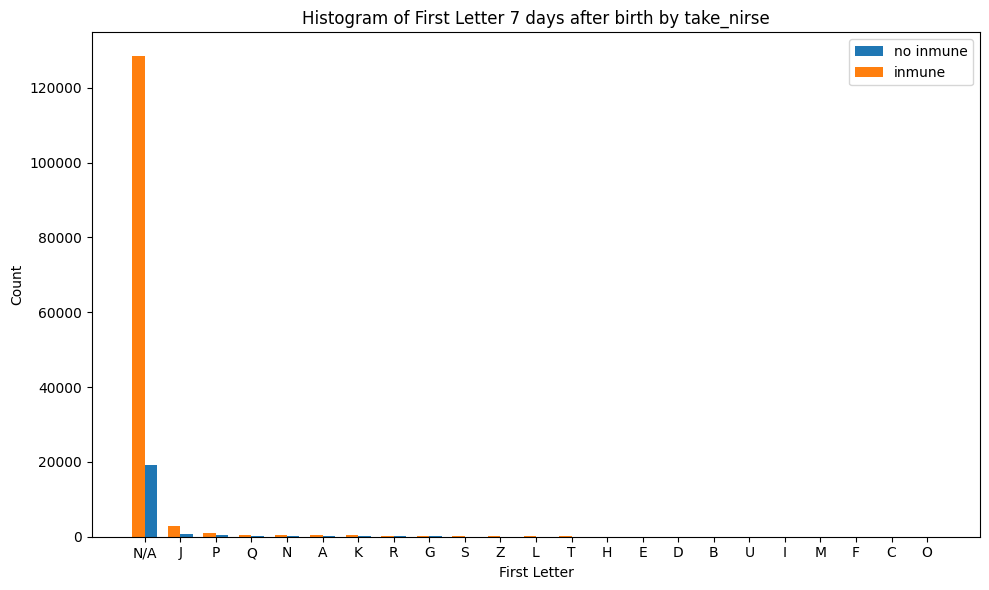

In [164]:
#df_sind = df1.sort_values(by='fechaIng_any').drop_duplicates(subset=['RUN'], keep='first')

# df_sind.loc[(df_sind['fechaIng_any'] - df_sind['fecha_nac']).dt.days <= 7, 'fechaIng_any' ] = pd.NaT
# df_sind.loc[(df_sind['fechaIng_any'] - df_sind['fechaInm']).dt.days <= 7, 'fechaInm' ] = pd.NaT
# #[(df_sind['fechaIng_any'] - df_sind['fecha_nac']).dt.days >7 ]
# df_histogram = df_sind.query('fechaIng_any.notna()').assign(first_letter=lambda x: x.DIAG1.str[0]) \
#     .groupby(['take_nirse']).first_letter.value_counts().unstack(0)


# Reemplazar NaN por 0 para evitar errores al graficar
#df_histogram = df_histogram.fillna(0)

#df_histogram['Total'] = df_histogram[False] + df_histogram[True]

# Ordenar por la suma total en orden descendente
#df_histogram = df_histogram.sort_values(by='Total', ascending=False)

# Eliminar la columna 'Total' (opcional si no la necesitas después)
#df_histogram = df_histogram.drop(columns='Total')

# Crear un gráfico de barras agrupadas
x = df_sind.index  # Las letras (first_letter)
width = 0.35  # Ancho de las barras

fig, ax = plt.subplots(figsize=(10, 6))

# Posiciones de las barras
x_indices = range(len(x))
bar1 = ax.bar([i + width/2 for i in x_indices], df_sind[False], width, label='no inmune')
bar2 = ax.bar([i - width/2 for i in x_indices], df_sind[True], width, label='inmune')

# Configuración del gráfico
ax.set_xlabel('First Letter')
ax.set_ylabel('Count')
ax.set_title('Histogram of First Letter 7 days after birth by take_nirse')
ax.set_xticks(x_indices)
ax.set_xticklabels(x)
ax.legend()

# Mostrar el gráfico
plt.tight_layout()
plt.show()

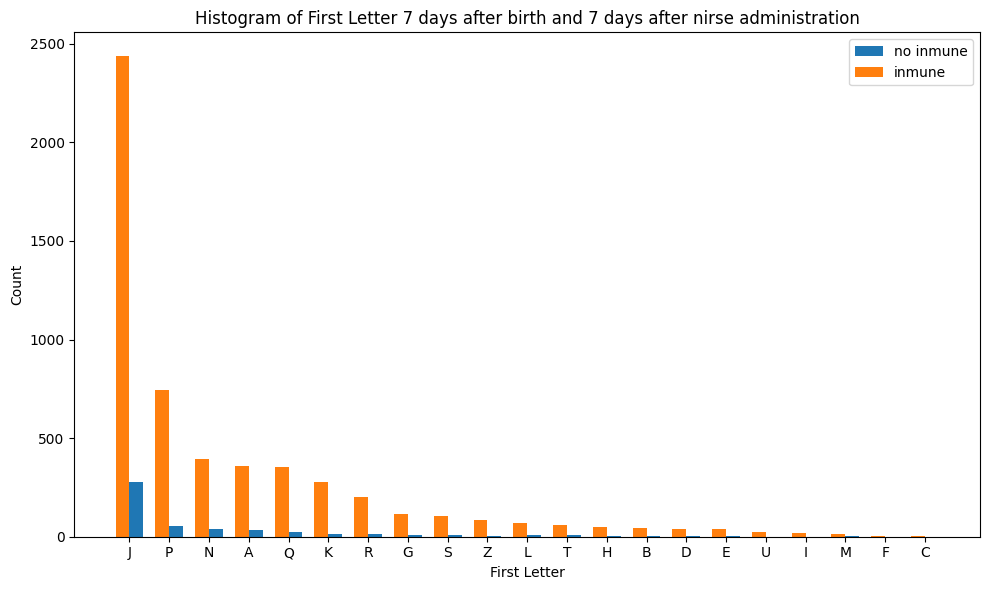

In [99]:
df_histogram = df_sind[((df_sind['fechaIng_any'] - df_sind['fecha_nac']).dt.days > 7) & ((df_sind['fechaInm'].isnull()) | df_sind['fechaIng_any'].isnull()|((df_sind['fechaIng_any'] - df_sind['fechaInm']).dt.days > 7))].assign(first_letter=lambda x: x.DIAG1.str[0]) \
    .groupby(['take_nirse']).first_letter.value_counts().unstack(0)

# Reemplazar NaN por 0 para evitar errores al graficar
df_histogram = df_histogram.fillna(0)

df_histogram['Total'] = df_histogram[False] + df_histogram[True]

# Ordenar por la suma total en orden descendente
df_histogram = df_histogram.sort_values(by='Total', ascending=False)

# Eliminar la columna 'Total' (opcional si no la necesitas después)
df_histogram = df_histogram.drop(columns='Total')

# Crear un gráfico de barras agrupadas
x = df_histogram.index  # Las letras (first_letter)
width = 0.35  # Ancho de las barras

fig, ax = plt.subplots(figsize=(10, 6))

# Posiciones de las barras
x_indices = range(len(x))
bar1 = ax.bar([i + width/2 for i in x_indices], df_histogram[False], width, label='no inmune')
bar2 = ax.bar([i - width/2 for i in x_indices], df_histogram[True], width, label='inmune')

# Configuración del gráfico
ax.set_xlabel('First Letter')
ax.set_ylabel('Count')
ax.set_title('Histogram of First Letter 7 days after birth and 7 days after nirse administration')
ax.set_xticks(x_indices)
ax.set_xticklabels(x)
ax.legend()

# Mostrar el gráfico
plt.tight_layout()
plt.show()

In [121]:
df_sind = df1.sort_values(by='fechaIng_any').drop_duplicates(subset=['RUN'], keep='first') #.query('prematuro==1')
df_sind[(df_sind['fechaIng_any'] - df_sind['fecha_nac']).dt.days >7 ].assign(first_letter=lambda x: x.DIAG1.str[0]) \
    .query('(first_letter=="P") | first_letter=="J"').groupby(['first_letter','take_nirse']).SEMANAS.value_counts().unstack(2)

SEMANAS                  28.0  29.0  30.0  31.0  32.0  33.0  34.0  35.0  \
first_letter take_nirse                                                   
J            False        NaN   1.0   NaN   1.0   1.0   2.0   5.0   3.0   
             True        14.0  13.0  19.0  21.0  23.0  41.0  54.0  79.0   
P            False        NaN   NaN   NaN   NaN   1.0   NaN   3.0   1.0   
             True         4.0   4.0   7.0   4.0  12.0   8.0  23.0  30.0   

SEMANAS                   36.0   37.0   38.0   39.0   40.0  41.0  
first_letter take_nirse                                           
J            False        18.0   51.0   86.0   66.0   39.0   7.0  
             True        139.0  406.0  858.0  742.0  437.0  57.0  
P            False         4.0    9.0   17.0    7.0    9.0   2.0  
             True         90.0  190.0  332.0  227.0  112.0  16.0

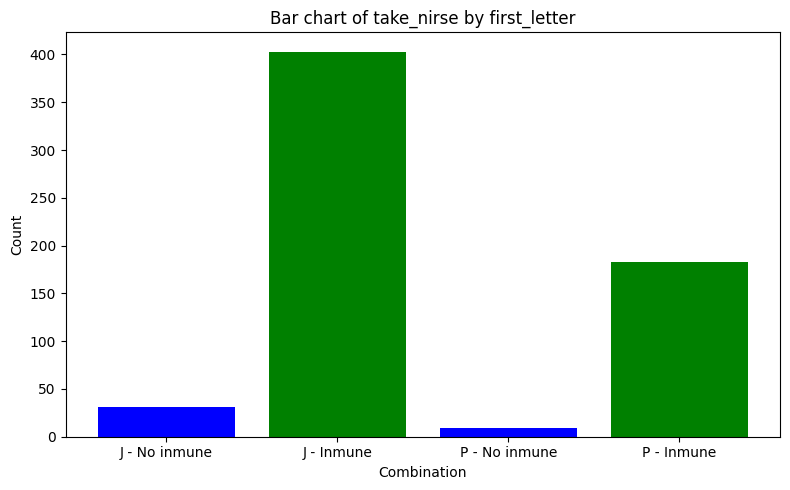

In [115]:
df_sind = df1.query('prematuro==1').sort_values(by='fechaIng_any').drop_duplicates(subset=['RUN'], keep='first') #
df_result = df_sind[(df_sind['fechaIng_any'] - df_sind['fecha_nac']).dt.days > 7] \
    .assign(first_letter=lambda x: x.DIAG1.str[0]) \
    .query('(first_letter=="P") | (first_letter=="J")') \
    .groupby(['first_letter', 'take_nirse']).first_letter.value_counts().unstack(1)

# Asegurarte de que no haya NaN en el resultado
df_result = df_result.fillna(0)

# Definir las etiquetas y valores para graficar
labels = ['J - No inmune', 'J - Inmune', 'P - No inmune', 'P - Inmune']
values = [
    df_result.loc['J', False],
    df_result.loc['J', True],
    df_result.loc['P', False],
    df_result.loc['P', True]
]

# Crear el gráfico de barras
fig, ax = plt.subplots(figsize=(8, 5))

# Generar las barras
ax.bar(labels, values, color=['blue', 'green', 'blue', 'green'])

# Configurar etiquetas y título
ax.set_ylabel('Count')
ax.set_title('Bar chart of take_nirse by first_letter')
ax.set_xlabel('Combination')

# Mostrar el gráfico
plt.tight_layout()
plt.show()

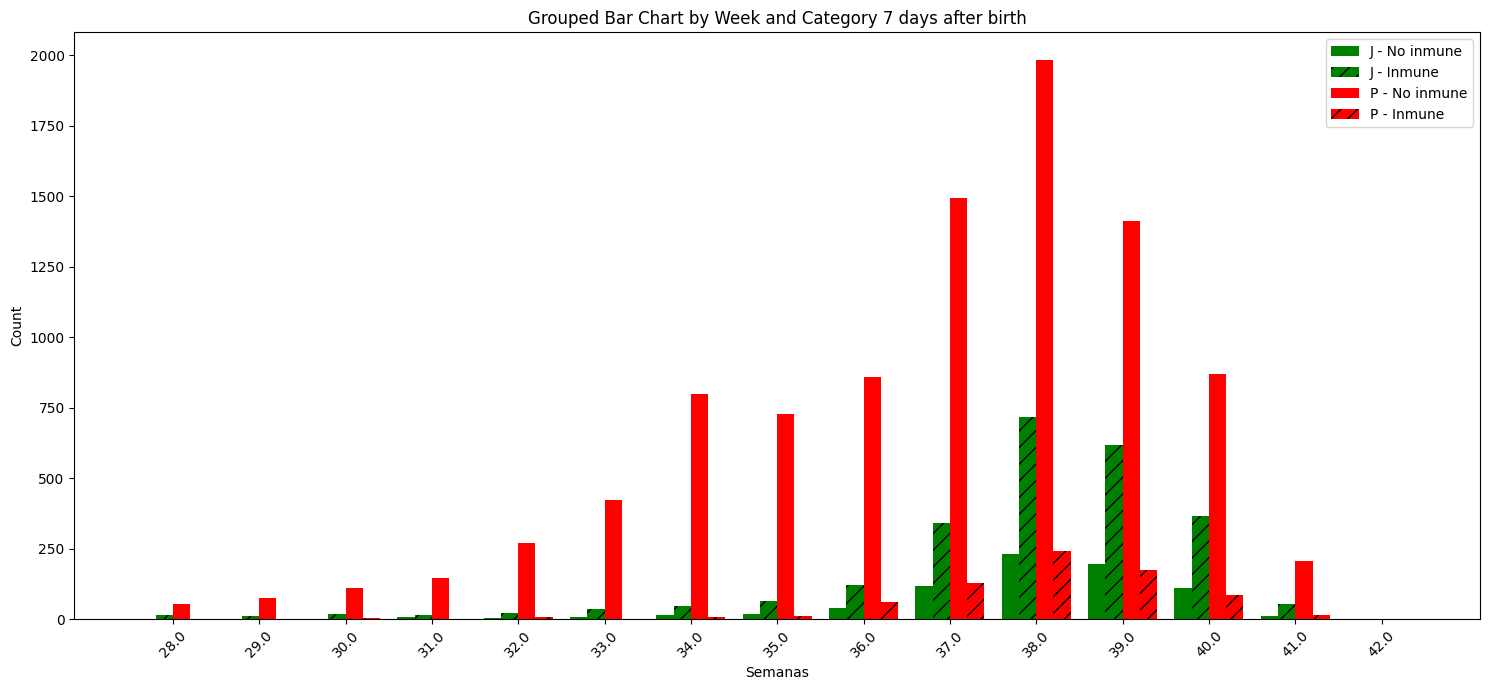

In [18]:
df_sind = df1.copy()
#df_sind.loc[(df_sind['fechaIng_any'] - df_sind['fecha_nac']).dt.days <= 7, 'fechaIng_any' ] = pd.NaT
df_sind.loc[(df_sind['fechaIng_any'] - df_sind['fechaInm']).dt.days <= 7, 'fechaInm' ] = pd.NaT

df_sind = df_sind.query('fechaIng_any.notna()').sort_values(by='fechaIng_any').drop_duplicates(subset=['RUN'], keep='first') 
df_result = (df_sind
             .assign(first_letter=lambda x: x.DIAG1.str[0]
                     , take_nirse = lambda x: x.fechaInm.notnull())
             .query('(first_letter=="P") | (first_letter=="J")')
             .groupby(['first_letter', 'take_nirse']).SEMANAS.value_counts()
             .unstack(2)
)

# Reemplazar NaN por 0 para evitar problemas al graficar
df_result = df_result.fillna(0)

# Reorganizar datos para graficar
weeks = df_result.columns  # Semanas (Eje X)
categories = ['J - No inmune', 'J - Inmune', 'P - No inmune', 'P - Inmune']  # Categorías
data = [
    df_result.loc['J', False],
    df_result.loc['J', True],
    df_result.loc['P', False],
    df_result.loc['P', True]
]

# Configuración del gráfico
width = 0.2  # Ancho de las barras
x = range(len(weeks))  # Posiciones en el eje X

fig, ax = plt.subplots(figsize=(15, 7))

# Crear las barras agrupadas
ax.bar([pos - 1.5 * width for pos in x], data[0], width, label='J - No inmune', color='green', hatch='')  # Barras enteras
ax.bar([pos - 0.5 * width for pos in x], data[1], width, label='J - Inmune', color='green', hatch='//')  # Barras enteras
ax.bar([pos + 0.5 * width for pos in x], data[2], width, label='P - No inmune', color='red', hatch='')  # Barras rayadas
ax.bar([pos + 1.5 * width for pos in x], data[3], width, label='P - Inmune', color='red', hatch='//')

# Configuración de etiquetas y título
ax.set_xlabel('Semanas')
ax.set_ylabel('Count')
ax.set_title('Grouped Bar Chart by Week and Category 7 days after birth')
ax.set_xticks(x)
ax.set_xticklabels(weeks, rotation=45)
ax.legend()

# Mostrar el gráfico
plt.tight_layout()
plt.show()

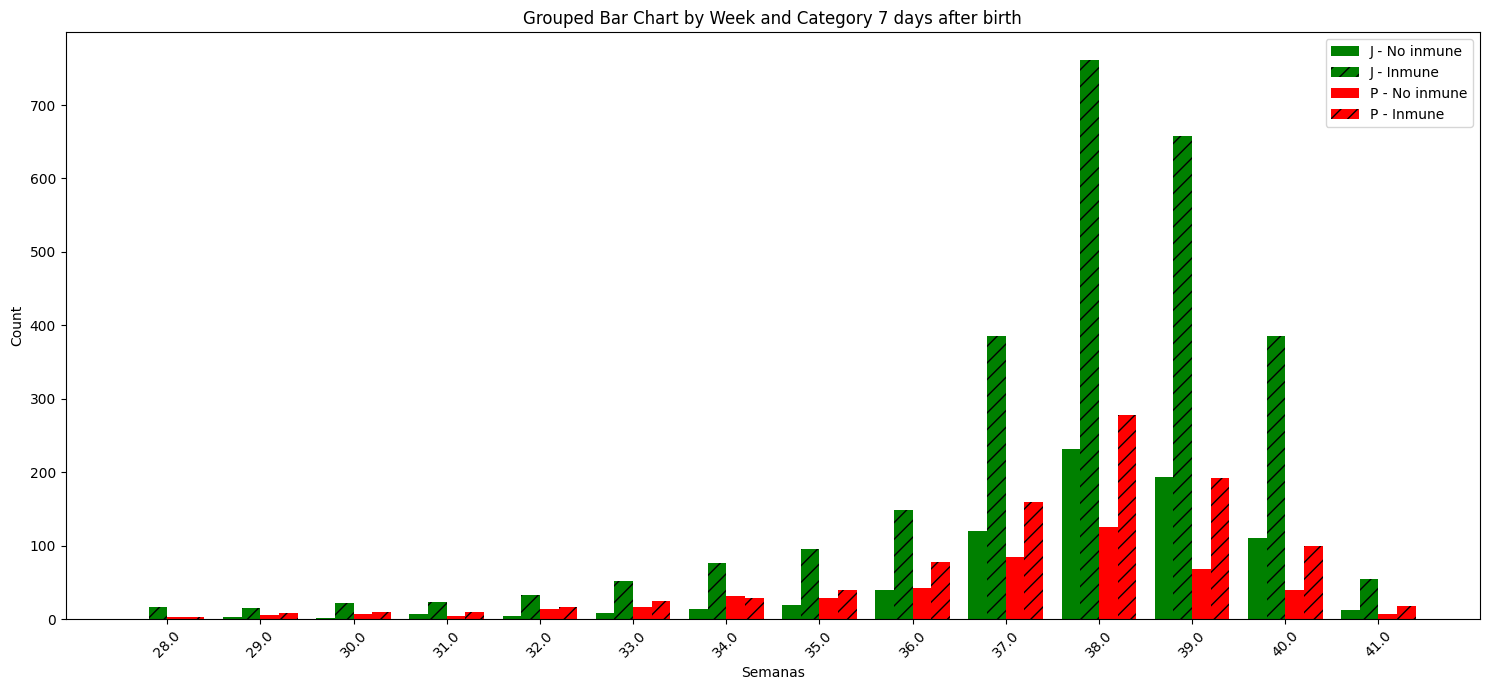

In [19]:
df_sind = df1.copy()
df_sind.loc[(df_sind['fechaIng_any'] - df_sind['fecha_nac']).dt.days <= 7, 'fechaIng_any' ] = pd.NaT
df_sind.loc[(df_sind['fechaIng_any'] - df_sind['fechaInm']).dt.days <= 7, 'fechaInm' ] = pd.NaT

df_sind = df_sind.query('fechaIng_any.notna()').sort_values(by='fechaIng_any').drop_duplicates(subset=['RUN'], keep='first') 
df_result = (df_sind
             .assign(first_letter=lambda x: x.DIAG1.str[0]
                     , take_nirse = lambda x: x.fechaInm.notnull())
             .query('(first_letter=="P") | (first_letter=="J")')
             .groupby(['first_letter', 'take_nirse']).SEMANAS.value_counts()
             .unstack(2)
)

# Reemplazar NaN por 0 para evitar problemas al graficar
df_result = df_result.fillna(0)

# Reorganizar datos para graficar
weeks = df_result.columns  # Semanas (Eje X)
categories = ['J - No inmune', 'J - Inmune', 'P - No inmune', 'P - Inmune']  # Categorías
data = [
    df_result.loc['J', False],
    df_result.loc['J', True],
    df_result.loc['P', False],
    df_result.loc['P', True]
]

# Configuración del gráfico
width = 0.2  # Ancho de las barras
x = range(len(weeks))  # Posiciones en el eje X

fig, ax = plt.subplots(figsize=(15, 7))

# Crear las barras agrupadas
ax.bar([pos - 1.5 * width for pos in x], data[0], width, label='J - No inmune', color='green', hatch='')  # Barras enteras
ax.bar([pos - 0.5 * width for pos in x], data[1], width, label='J - Inmune', color='green', hatch='//')  # Barras enteras
ax.bar([pos + 0.5 * width for pos in x], data[2], width, label='P - No inmune', color='red', hatch='')  # Barras rayadas
ax.bar([pos + 1.5 * width for pos in x], data[3], width, label='P - Inmune', color='red', hatch='//')

# Configuración de etiquetas y título
ax.set_xlabel('Semanas')
ax.set_ylabel('Count')
ax.set_title('Grouped Bar Chart by Week and Category 7 days after birth')
ax.set_xticks(x)
ax.set_xticklabels(weeks, rotation=45)
ax.legend()

# Mostrar el gráfico
plt.tight_layout()
plt.show()

In [ ]:
# Obtener los datos
counts = df_vrs_tilweek.query('event_LRTI==1').DIAG1.value_counts().reset_index()
counts.columns = ['DIAG1', 'count']  # Renombrar columnas

# Crear el gráfico
plt.figure(figsize=(10, 6))
sns.barplot(data=counts.query('count>=5'), x='DIAG1', y='count', palette='viridis')

# Configurar el gráfico
plt.title('Conteo de DIAG1 (event_LRTI == 1)', fontsize=16)
plt.xlabel('DIAG1', fontsize=14)
plt.ylabel('Conteo', fontsize=14)
plt.xticks(rotation=45, ha='right')

# Mostrar el gráfico
plt.tight_layout()
plt.show()

#### Campaign inmune

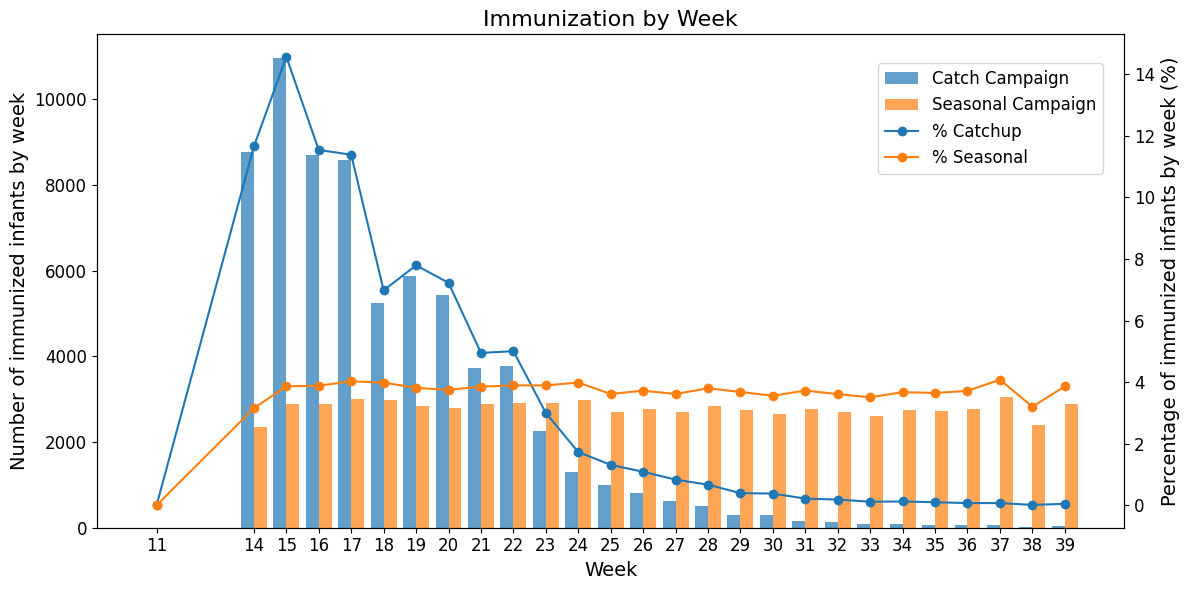

In [25]:
df_vrs_tilweek_cop = df_vrs_tilweek.query('RUN!="a3fc16a9f9903d0ddb0b89d5c91584beeb947924f4862bc2273c0492544791ef"') # este wn se inmunizo en febreo 0 atao

df_vrs_tilweek_cop.loc[df_vrs_tilweek_cop['FECHA_INMUNIZACION'] > pd.to_datetime('2024-09-22') + pd.DateOffset(days=7), 'FECHA_INMUNIZACION'] = pd.NaT

nacimientos_normal = (
    df_vrs_tilweek_cop
    .assign(
        week=lambda x: np.where(
            x.fecha_nac.dt.isocalendar().year == 2024, 
            x.fecha_nac.dt.isocalendar().week, 
            x.fecha_nac.dt.isocalendar().week.min()
        )
    )
    .groupby(['group', 'week'])
    .size()
    .unstack(0)
    .fillna(0)
    .query("week >= 14")
)

nacimientos_cumsum = (
    df_vrs_tilweek_cop
    .assign(
        week=lambda x: np.where(
            x.fecha_nac.dt.isocalendar().year == 2024, 
            x.fecha_nac.dt.isocalendar().week, 
            x.fecha_nac.dt.isocalendar().week.min()
        )
    )
    .groupby(['group', 'week'])
    .size()
    .reset_index(name='count')
    .pivot(index='week', columns='group', values='count')
    .fillna(0)
    .cumsum()
    .query("week >= 14")
)

nacimientos_normal['CATCH_UP'] = nacimientos_cumsum.CATCH_UP

grafico_campaign = (
    df_vrs_tilweek_cop
    .query('FECHA_INMUNIZACION.notna()')
    .assign(week = lambda x: np.where(x.FECHA_INMUNIZACION.dt.isocalendar().week==13,
                                               x.FECHA_INMUNIZACION.dt.isocalendar().week+1,x.
                                               FECHA_INMUNIZACION.dt.isocalendar().week))
    .groupby(['group','week'])
    .size()
    .unstack(0)
    .fillna(0)
    .merge(nacimientos_normal,how='left',on=['week'])
    .rename(columns={
    'CATCH_UP_y': 'Catch_Nacimientos',
    'SEASONAL_y': 'Seasonal_Nacimientos',
    'CATCH_UP_x': 'Catch_Campaña',
    'SEASONAL_x': 'Seasonal_Campaña'
    })
    .assign(Porcentaje_inmune_catchup = lambda x: 100*x.Catch_Campaña/x.Catch_Nacimientos.max(),
            Porcentaje_inmune_seasonal = lambda x: 100*x.Seasonal_Campaña/x.Seasonal_Nacimientos.cumsum().max())
    .drop(columns=['Catch_Nacimientos','Seasonal_Nacimientos'])
    .reset_index()
)

df = grafico_campaign

fig, ax1 = plt.subplots(figsize=(12, 6))

catch_color = '#1f77b4'  # Azul (para Catch Campaña y % Catchup)
seasonal_color = '#ff7f0e'  # Naranja (para Seasonal Campaña y % Seasonal)

# Left axis: Histograms for "Catch_Campaña" and "Seasonal_Campaña"
bar1 = ax1.bar(df['week'] - 0.2, df['Catch_Campaña'], width=0.4, label='Catch Campaign', color=catch_color, alpha=0.7)
bar2 = ax1.bar(df['week'] + 0.2, df['Seasonal_Campaña'], width=0.4, label='Seasonal Campaign', color=seasonal_color, alpha=0.7)
ax1.set_xlabel('Week', fontsize=14)  # Adjust font size for x-axis label
ax1.set_ylabel('Number of immunized infants by week', color='black', fontsize=14)  # Adjust font size for y-axis label
ax1.tick_params(axis='x', labelsize=12)  # Font size for x-axis ticks
ax1.tick_params(axis='y', labelsize=12)  # Font size for left y-axis ticks
ax1.set_xticks(df['week'])

# Right axis: Point curves for "Porcentaje_inmune_catchup" and "Porcentaje_inmune_seasonal"
ax2 = ax1.twinx()
line1, = ax2.plot(df['week'], df['Porcentaje_inmune_catchup'], marker='o', color=catch_color, label='% Catchup')
line2, = ax2.plot(df['week'], df['Porcentaje_inmune_seasonal'], marker='o', color=seasonal_color, label='% Seasonal')
ax2.set_ylabel('Percentage of immunized infants by week (%)', color='black', fontsize=14)  # Adjust font size for right y-axis label
ax2.tick_params(axis='y', labelsize=12)  # Font size for right y-axis ticks

# Create a single combined legend
lines = [bar1, bar2, line1, line2]
labels = ['Catch Campaign', 'Seasonal Campaign', '% Catchup', '% Seasonal']
fig.legend(lines, labels, loc='upper right', ncol=1, bbox_to_anchor=(0.93, 0.9), fontsize=12)  # Adjust legend font size

# Adjust title font size
plt.title('Immunization by Week', fontsize=16)

# Show the plot
plt.tight_layout()
plt.show()


### Tabla exclusión

In [35]:
from itertools import combinations

df_pf_sd = df_pf.copy()#.drop_duplicates(subset=['RUN'], keep='first')

filters = {'Gestational age (weeks) > 42' : (df_pf_sd.SEMANAS > 42),
'Gestational age (weeks) < 28' : (df_pf_sd.SEMANAS < 24),
'Gestational weight <= lower critical percentile':(df_pf_sd.PESO <= df_pf_sd.p_00001_lognormal), 
'Gestational weight >= upper critical percentile':(df_pf_sd.PESO >= df_pf_sd.p_99999_lognormal),
'Dead': ((df_pf_sd.VIVO=='NO' )),
'Unidentifiable ID': df_pf_sd.MARCA==1,
'Non-recognizable sex': df_pf_sd.SEXO == 9,
'Atypical mom age': (df_pf_sd.EDAD_M>51) | (df_pf_sd.EDAD_M<12),
'Hospitalization date before birth ': (df_pf_sd.RUN.isin(df_pf_sd.fechaIng_any < df_pf_sd.fecha_nac)),
'Hospitalization date before start of campaign ': (df_pf_sd.RUN.isin(df_pf_sd[df_pf_sd.fechaIng_any < pd.to_datetime("2024-04-01")].RUN.unique()))}



def apply_filters_and_count(df_pf_sd, filters):
    results = {}
    for filter_name, filter_condition in filters.items():
        filtered_df_pf_sd = df_pf_sd[filter_condition]
        removed_count = len(filtered_df_pf_sd)
        results[filter_name] = removed_count
    
    # Apply combinations of filters
    filter_names = list(filters.keys())
    for r in range(2, len(filters) + 1):
        for combo in combinations(filter_names, r):
            combined_filter = filters[combo[0]]
            for filter_name in combo[1:]:
                combined_filter &= filters[filter_name]
            filtered_df_pf_sd = df_pf_sd[combined_filter]
            removed_count = len(filtered_df_pf_sd)
            results[' + '.join(combo)] = removed_count
    
    return results

# Apply the filters and display the results
results = apply_filters_and_count(df_pf_sd, filters)

# Convert the results to a DataFrame for better display
results_df_pf_sd = pd.DataFrame(list(results.items()), columns=['Filter Combination', 'Removed Count'])
results_df_pf_sd = results_df_pf_sd[results_df_pf_sd['Removed Count'] != 0].reset_index()

index_nmes = results_df_pf_sd['Filter Combination']

# Crear una lista de filtros en el orden deseado
filter_list = [filt for filt in filters.keys()]

# Inicializar la estructura de datos para la tabla
table_data = {f: [''] * len(results_df_pf_sd) for f in filter_list}
table_data['Total'] = [0] * len(results_df_pf_sd)

# Rellenar la tabla con 'x' y los totales
for idx, row in results_df_pf_sd.iterrows():
    filters_applied = row['Filter Combination'].split(' + ')
    for f in filters_applied:
        table_data[f][idx] = 'x'
    table_data['Total'][idx] = row['Removed Count']

# Crear el DataFrame
table_df_pf_sd = pd.DataFrame(table_data)
tabla_exlcusion = table_df_pf_sd #.style.set_properties(**{'text-align': 'center'}).set_table_styles([{'selector': 'th', 'props': [('text-align', 'center')]}])

In [58]:
# DataFrame base sin duplicados por RUN
df_pf_sd = df_pf.drop_duplicates(subset=['RUN'], keep='first')

# Definir los filtros
filters = {'Gestational age (weeks) > 42': (df_pf_sd.SEMANAS > 42),
           'Gestational age (weeks) < 28': (df_pf_sd.SEMANAS < 28),
           'Gestational weight <= lower critical percentile': (df_pf_sd.PESO <= df_pf_sd.p_00001_lognormal),
           'Gestational weight >= upper critical percentile': (df_pf_sd.PESO >= df_pf_sd.p_99999_lognormal),
           #'Dead': (df_pf_sd.VIVO == 'NO'),
           'Non-recognizable sex': (df_pf_sd.SEXO == 9),
           'Atypical mom age': (df_pf_sd.EDAD_M > 51) | (df_pf_sd.EDAD_M < 12),
           'Hospitalization date before birth': (df_pf_sd.fechaIng_any < df_pf_sd.fecha_nac)}

# Función para contar eliminaciones por filtros y sus intersecciones
def count_filter_intersections(df, filters):
    filter_names = list(filters.keys())
    results = pd.DataFrame(index=filter_names, columns=filter_names + ['Total']).fillna('')

    for f1 in filter_names:
        # Filtrar datos solo por el primer filtro
        filtered_f1 = df[filters[f1]]
        results.loc[f1, 'Total'] = len(filtered_f1)
        
        for f2 in filter_names:
            if f1 == f2:
                results.loc[f1, f2] = 'x'  # Diagonal principal
            else:
                # Filtrar datos por la intersección de f1 y f2
                filtered_f1_f2 = filtered_f1[filters[f2]]
                results.loc[f1, f2] = 'x' if len(filtered_f1_f2) > 0 else ''
    
    return results

# Llamar a la función para obtener la tabla final
tabla_exclusion = count_filter_intersections(df_pf_sd, filters)


In [59]:
tabla_exclusion

,Gestational age (weeks) > 42,Gestational age (weeks) < 28,Gestational weight <= lower critical percentile,Gestational weight >= upper critical percentile,Non-recognizable sex,Atypical mom age,Hospitalization date before birth,Total
Gestational age (weeks) > 42,x,,,,,,,72
Gestational age (weeks) < 28,,x,x,x,x,x,,896
Gestational weight <= lower critical percentile,,x,x,,,x,,531
Gestational weight >= upper critical percentile,,x,,x,x,,,181
Non-recognizable sex,,x,,x,x,,,14
Atypical mom age,,x,x,,,x,,301
Hospitalization date before birth,,,,,,,x,13


In [60]:
unique_totals = {}
for filter_name, condition in filters.items():
    unique_totals[filter_name] = len(df_pf_sd[condition])  # Aplica cada filtro de forma aislada

# Añadir una fila de totales únicos a la tabla
tabla_exclusion.loc['Total'] = ''  # Inicializamos la fila de Totales
for col in filters.keys():
    tabla_exclusion.loc['Total', col] = unique_totals[col]  # Asigna el total único

# Sumar la cantidad total de eliminaciones únicas (no intersecciones)
tabla_exclusion.loc['Total', 'Total'] = sum(unique_totals.values())

# Mostrar la tabla final

tabla_exclusion
    

,Gestational age (weeks) > 42,Gestational age (weeks) < 28,Gestational weight <= lower critical percentile,Gestational weight >= upper critical percentile,Non-recognizable sex,Atypical mom age,Hospitalization date before birth,Total
Gestational age (weeks) > 42,x,,,,,,,72
Gestational age (weeks) < 28,,x,x,x,x,x,,896
Gestational weight <= lower critical percentile,,x,x,,,x,,531
Gestational weight >= upper critical percentile,,x,,x,x,,,181
Non-recognizable sex,,x,,x,x,,,14
Atypical mom age,,x,x,,,x,,301
Hospitalization date before birth,,,,,,,x,13
Total,72,896,531,181,14,301,13,2008


In [36]:
columns_orden = tabla_exlcusion.columns
tabla_exlcusion['index'] = index_nmes
#tabla_exlcusion = tabla_exlcusion[['index'] + columns_orden]

In [49]:
tabla_exlcusion[['index'] + ['Gestational age (weeks) > 42', 'Gestational age (weeks) < 28','Gestational weight <= lower critical percentile',
                             'Gestational weight >= upper critical percentile', 'Dead', 'Non-recognizable sex', 'Atypical mom age',
                             'Hospitalization date before birth ', 'Total']]

,index,Gestational age (weeks) > 42,Gestational age (weeks) < 28,Gestational weight <= lower critical percentile,Gestational weight >= upper critical percentile,Dead,Non-recognizable sex,Atypical mom age,Hospitalization date before birth,Total
0,Gestational age (weeks) > 42,x,,,,,,,,72
1,Gestational age (weeks) < 28,,x,,,,,,,896
2,Gestational weight <= lower critical percentile,,,x,,,,,,531
3,Gestational weight >= upper critical percentile,,,,x,,,,,181
4,Dead,,,,,x,,,,1006
5,Non-recognizable sex,,,,,,x,,,14
6,Atypical mom age,,,,,,,x,,301
7,Hospitalization date before birth,,,,,,,,x,13
8,Gestational age (weeks) < 28 + Gestational weight <= lower critical percentile,,x,x,,,,,,34
9,Gestational weight >= upper critical percentile + Dead,,,,x,x,,,,26


In [97]:
# Crear el DataFrame base sin duplicados
df_pf_sd = df_pf#.drop_duplicates(subset=['RUN'], keep='first')


# filters = {'Gestational age (weeks) > 42' : (df_pf_sd.SEMANAS > 42),
# 'Gestational age (weeks) < 28' : (df_pf_sd.SEMANAS < 24),
# 'Gestational weight <= lower critical percentile':(df_pf_sd.PESO <= df_pf_sd.p_00001_lognormal), 
# 'Gestational weight >= upper critical percentile':(df_pf_sd.PESO >= df_pf_sd.p_99999_lognormal),
# 'Dead': ((df_pf_sd.VIVO=='NO' )),
# 'Unidentifiable ID': df_pf_sd.MARCA==1,
# 'Non-recognizable sex': df_pf_sd.SEXO == 9,
# 'Atypical mom age': (df_pf_sd.EDAD_M>51) | (df_pf_sd.EDAD_M<12),
# 'Hospitalization date before birth ': (df_pf_sd.RUN.isin(df_pf_sd.fechaIng_any < df_pf_sd.fecha_nac)),
# 'Hospitalization date before start of campaign ': (df_pf_sd.RUN.isin(df_pf_sd[df_pf_sd.fechaIng_any < pd.to_datetime("2024-04-01")].RUN.unique()))}



filters = {'G.a.w > 42': (df_pf_sd.SEMANAS > 42),
           'G.a.w < 24': (df_pf_sd.SEMANAS < 24),
           'G.weight <=  p_l': (df_pf_sd.PESO <= df_pf_sd.p_00001_lognormal),
           'G.weight >= p_u': (df_pf_sd.PESO >= df_pf_sd.p_99999_lognormal),
           'Intersex': (df_pf_sd.SEXO == 9),
           'Unidentifiable ID': df_pf_sd.MARCA==1,
           'Mom age': (df_pf_sd.EDAD_M > 51) | (df_pf_sd.EDAD_M < 12),
           'Inconsistent dates': (df_pf_sd.RUN.isin(df_pf_sd.fechaIng_any < df_pf_sd.fecha_nac)), #
           'Hospitalization date before start of campaign ': (df_pf_sd.RUN.isin(df_pf_sd[df_pf_sd.fechaIng_any < pd.to_datetime("2024-04-01")].RUN.unique()))}

# Crear la tabla vacía con los nombres de los filtros
filter_names = list(filters.keys())
intersection_table = pd.DataFrame(index=filter_names, columns=filter_names)

# Rellenar la tabla con las intersecciones
for f1 in filter_names:
    for f2 in filter_names:
        if f1 == f2:
            super_filter = filters[f1]
            for f3 in filter_names:
                if f3==f1:
                    continue
                else:
                    super_filter = super_filter & (~filters[f3])
                
            count = len(df_pf_sd[super_filter])
        else:
            # Intersección: cuántos datos elimina al aplicar f1 y f2 simultáneamente
            combined_filter = filters[f1] & filters[f2]
            count = len(df_pf_sd[combined_filter])
        
        intersection_table.loc[f1, f2] = count

# Mostrar la tabla final
intersection_table

,G.a.w > 42,G.a.w < 24,G.weight <= p_l,G.weight >= p_u,Intersex,Unidentifiable ID,Mom age,Inconsistent dates,Hospitalization date before start of campaign
G.a.w > 42,54,0,0,0,0,0,0,0,8
G.a.w < 24,0,170,5,16,2,0,0,0,36
G.weight <= p_l,0,5,316,0,0,0,0,0,162
G.weight >= p_u,0,16,0,113,0,0,0,0,58
Intersex,0,2,0,0,13,0,0,0,4
Unidentifiable ID,0,0,0,0,0,0,0,0,0
Mom age,0,0,0,0,0,0,2,0,0
Inconsistent dates,0,0,0,0,0,0,0,0,0
Hospitalization date before start of campaign,8,36,162,58,4,0,0,0,19133


In [274]:
df_pf = pre_filtred(df_name='NAC_RNI_EGRESOS_ENTREGA_ISCI_20_12_2024_encr.csv',lrti_name='LRTI_Flag')
df_f_any, df_f_LRTI, df_f_vrs, df_f_upc = filtros_IH_new(df_pf)

n_rows_inicial= 167609
['DESCONOCIDO---->None' 'Región De Antofagasta---->ANTOFAGASTA'
 'Región De Arica Parinacota---->ARICA Y PARINACOTA'
 'Región De Atacama---->ATACAMA'
 'Región De Aysén del General Carlos Ibañez del Campo---->AISEN'
 'Región De Coquimbo---->COQUIMBO' 'Región De La Araucanía---->ARAUCANIA'
 'Región De Los Lagos---->LOS LAGOS' 'Región De Los Ríos---->LOS RIOS'
 'Región De Magallanes y de la Antártica Chilena---->MAGALLANES Y ANTARTICA'
 'Región De Tarapacá---->TARAPACA' 'Región De Valparaíso---->VALPARAISO'
 'Región De Ñuble---->NUBLE' 'Región Del Bíobío---->BIOBIO'
 "Región Del Libertador Gral. B. O'Higgins---->O'HIGGINS"
 'Región Del Maule---->MAULE'
 'Región Metropolitana de Santiago---->METROPOLITANA']
n_rows_post_prefiltred= 167609
Datos perdidos por muertes:  1202
ruts perdidos por filtro semanas y peso:  645
Droped intersex: 9
Datos perdidos por edad madre atípica: 245
Datos perdidos por fecha ingreso menor a fecha nacimiento: 57
vrs en los primeros 7 dias de

In [273]:
df_pf_sd[['SEMANAS','PESO','p_00001_lognormal','p_99999_lognormal', 'MARCA','SEXO','EDAD_M','fecha_nac','RUN']].isna().sum()

SEMANAS              432
PESO                 451
p_00001_lognormal    495
p_99999_lognormal    495
MARCA                  0
SEXO                   0
EDAD_M                 0
fecha_nac              0
RUN                    0
dtype: int64

In [102]:
import pickle

with open(path_data/'lista_ruts_cardio.pkl', 'rb') as f:
    lista_ruts_cardio = pickle.load(f)

with open(path_data/'lista_ruts_preterms.pkl', 'rb') as f:
    lista_ruts_preterms = pickle.load(f)

lista_risky = np.union1d(lista_ruts_cardio, lista_ruts_preterms)

df_pf_sd = (
    df_pf
    .copy()
    .assign(fechaIng_any_modify = lambda x: x.fechaIng_any,
                        fechaIng_vrs_modify = lambda x: x.fechaIng_vrs,
                        fecha_def = lambda x: pd.to_datetime(x['FECHA_DEFUNCION'], format='%d%b%Y'),
                        muerto_pre_campain = lambda x: x.fecha_def < pd.to_datetime("2024-04-01"),
                        muerto_7days_birth = lambda x: x.fecha_def <= x.fecha_nac + pd.DateOffset(days=7))
    # .query('muerto_pre_campain==False') 
    # .query('muerto_7days_birth==False')
    # .sort_values(by='fechaIng_vrs').drop_duplicates(subset=['RUN'], keep='first')
    .query('VIVO=="SI"')
    .query('RUN.isin(@lista_risky)')
    )


df_pf_sd.loc[df_pf_sd.fechaIng_any_modify <= df_pf_sd.fecha_nac + pd.DateOffset(days=7), ['fechaIng_any_modify','fechaIng_vrs_modify','fecha_upc_vrs','fechaIng_LRTI']] = pd.NaT

filters = {
    # 'G.a.w > 42': (df_pf_sd.SEMANAS > 42),
    # 'G.a.w < 24': (df_pf_sd.SEMANAS < 24),
    # 'G.weight <=  p_l': (df_pf_sd.PESO <= df_pf_sd.p_00001_lognormal),
    # 'G.weight >= p_u': (df_pf_sd.PESO >= df_pf_sd.p_99999_lognormal),
    'curve_peso_edadGest': ~((df_pf_sd['SEMANAS']>=24) & (df_pf_sd['SEMANAS']<=42) & (df_pf_sd['PESO'] >= df_pf_sd['p_00001_lognormal']) & (df_pf_sd['PESO'] <= df_pf_sd['p_99999_lognormal'])),#((df_pf_sd.PESO < df_pf_sd.p_00001_lognormal) | (df_pf_sd.PESO > df_pf_sd.p_99999_lognormal) | (df_pf_sd.SEMANAS > 42) | (df_pf_sd.SEMANAS < 24)),
    'Intersex': (df_pf_sd.SEXO == 9),
    'Unidentifiable ID': (df_pf_sd.MARCA==1),
    'Mom age': ((df_pf_sd.EDAD_M > 51) | (df_pf_sd.EDAD_M < 12)),
    'vrs_7_days_birth': (df_pf_sd.RUN.isin(df_pf_sd[df_pf_sd.fechaIng_any >= df_pf_sd.fecha_nac].RUN.unique())) & (df_pf_sd.RUN.isin(df_pf_sd[(df_pf_sd.fechaIng_vrs <= df_pf_sd.fecha_nac + pd.DateOffset(days=7))].RUN.unique())), #(df_pf_sd.fechaIng_vrs <= df_pf_sd.fecha_nac + pd.DateOffset(days=7)), #
    'Inconsistent dates': (df_pf_sd.RUN.isin(df_pf_sd[df_pf_sd.fechaIng_any < df_pf_sd.fecha_nac].RUN.unique())), #
    #'All cause Hospitalization date before start of campaign': (df_pf_sd.RUN.isin(df_pf_sd[df_pf_sd.fechaIng_any_modify < pd.to_datetime("2024-04-01")].RUN.unique())),
    #'LRTI Hospitalization date before start of campaign': (df_pf_sd.RUN.isin(df_pf_sd[df_pf_sd.fechaIng_LRTI < pd.to_datetime("2024-04-01")].RUN.unique())),
    'VRS Hospitalization date before start of campaign': (df_pf_sd.RUN.isin(df_pf_sd[df_pf_sd.fechaIng_vrs_modify < pd.to_datetime("2024-04-01")].RUN.unique())),
   # 'UPC Hospitalization date before start of campaign': (df_pf_sd.RUN.isin(df_pf_sd[df_pf_sd.fecha_upc_vrs < pd.to_datetime("2024-04-01")].RUN.unique())),
}

# Crear la tabla vacía con los nombres de los filtros
filter_names = list(filters.keys())
intersection_table = pd.DataFrame(index=filter_names, columns=filter_names + ['Total'])

df_diagonal = {}

# Rellenar la tabla con las intersecciones
for f1 in filter_names:
    for f2 in filter_names:
        if f1 == f2:
            super_filter = filters[f1]
            for f3 in filter_names:
                if f3 == f1:
                    continue
                else:
                    super_filter = super_filter & (~filters[f3])
                    
                
            count = df_pf_sd[super_filter].RUN.nunique() #len(df_pf_sd[super_filter])
            df_diagonal[f1] = count
        else:
            # Intersección: cuántos datos elimina al aplicar f1 y f2 simultáneamente
            combined_filter = filters[f1] & filters[f2]
            count = df_pf_sd[combined_filter].RUN.nunique() #len(df_pf_sd[combined_filter])
        
        intersection_table.loc[f1, f2] = count

    # Calcular el total general (datos eliminados al aplicar f1 sin exclusividad)
    intersection_table.loc[f1, 'Total'] = df_pf_sd[filters[f1]].RUN.nunique() - intersection_table.loc[f1, f1]  #len(df_pf_sd[filters[f1]])


diag_serie = pd.Series(df_diagonal)
total_compare = intersection_table.Total - diag_serie

# Mostrar la tabla final
intersection_table


,curve_peso_edadGest,Intersex,Unidentifiable ID,Mom age,vrs_7_days_birth,Inconsistent dates,VRS Hospitalization date before start of campaign,Total
curve_peso_edadGest,107,0,0,0,0,0,0,0
Intersex,0,1,0,0,0,0,0,0
Unidentifiable ID,0,0,0,0,0,0,0,0
Mom age,0,0,0,0,0,0,0,0
vrs_7_days_birth,0,0,0,0,0,0,0,0
Inconsistent dates,0,0,0,0,0,5,0,0
VRS Hospitalization date before start of campaign,0,0,0,0,0,0,14,0


In [103]:
df_pf_sd = df_pf.assign(fechaIng_any_modify = lambda x: x.fechaIng_any,
                        fechaIng_vrs_modify = lambda x: x.fechaIng_vrs)

# 1) Crear columnas booleanas en el DataFrame para cada filtro
for fname, cond in filters.items():
    df_pf_sd[fname] = cond  # Esto creará o sobrescribirá la columna con valores True/False

filter_names = list(filters.keys())
# df_pf_sd['num_filters_cumplidos'] = df_pf_sd[filter_names].sum(axis=1)

ruts_filts = df_pf_sd.assign(num_filters_cumplidos = lambda x: x[filter_names].sum(axis=1)).groupby('RUN',as_index=False).agg({'num_filters_cumplidos': 'max'})

df_pf_sd = df_pf_sd.merge(ruts_filts, on='RUN', how='left')

# 3) Construir la tabla de intersecciones para “3 o más” filtros
intersection_table_3plus = pd.DataFrame(
    index=filter_names,
    columns=filter_names + ['Total']
)

for f1 in filter_names:

    intersection_table_3plus.loc[f1, 'Total'] = df_pf_sd[df_pf_sd[f1] & (df_pf_sd['num_filters_cumplidos'] >= 2)].RUN.nunique()
    
    for f2 in filter_names:
        if f1 == f2:
            # Podrías dejar vacío, o poner 0, o un guión
            intersection_table_3plus.loc[f1, f2] = 'x'
        else:
            # Marcamos “x” si existe AL MENOS un registro que cumple:
            #   f1 == True, f2 == True y num_filters_cumplidos >= 3
            mask_f1_f2_3plus = (
                df_pf_sd[f1] & 
                df_pf_sd[f2] & 
                (df_pf_sd['num_filters_cumplidos'] >= 2)
            )
            intersection_table_3plus.loc[f1, f2] = 'x' if df_pf_sd[mask_f1_f2_3plus].RUN.nunique()>=1 else ''

df_diagonal_real = pd.DataFrame([df_diagonal])
df_diagonal_real.index = ['Diagonal']
intersection_table_3plus = pd.concat([intersection_table_3plus, df_diagonal_real], ignore_index=False)

# 5) Resultado final
intersection_table_3plus

,curve_peso_edadGest,Intersex,Unidentifiable ID,Mom age,vrs_7_days_birth,Inconsistent dates,VRS Hospitalization date before start of campaign,Total
curve_peso_edadGest,x,,,,,,,0
Intersex,,x,,,,,,0
Unidentifiable ID,,,x,,,,,0
Mom age,,,,x,,,,0
vrs_7_days_birth,,,,,x,,,0
Inconsistent dates,,,,,,x,,0
VRS Hospitalization date before start of campaign,,,,,,,x,0
Diagonal,107,1,0,0,0,5,14,NaN


In [255]:
results = {}
ruts_eliminados = set()
filter_keys = list(filters.keys())
all_combinations = []
for r in range(2, len(filter_keys) + 1):
    all_combinations.extend(itertools.combinations(filter_keys, r))
    
for combo in all_combinations:
    # Construir la condición lógica para la combinación actual
    condition = filters[combo[0]].copy()
    for key in combo[1:]:
        condition &= filters[key].copy()
    
    filtered_df = df_pf_sd[condition]

    if filtered_df.empty:
        continue
    else:
        ruts = filtered_df.RUN
        for rut in ruts:
            ruts_eliminados.add(rut)
    results[combo] = filtered_df

In [257]:
len(ruts_eliminados)

155

In [160]:
total_runs_unique = list(set(total_runs))
run_duplicates = []
for run in total_runs_unique:
    if total_runs.count(run) > 1:
        run_duplicates.append(run)

In [ ]:
serie_total = intersection_table_3plus.Total
serie_total = serie_total.drop('Diagonal')
serie_total - total_compare

In [220]:
df_pf_sd = (
    df_pf
    .assign(fechaIng_any_modify = lambda x: x.fechaIng_any,
                        fechaIng_vrs_modify = lambda x: x.fechaIng_vrs,
                        fecha_def = lambda x: pd.to_datetime(x['FECHA_DEFUNCION'], format='%d%b%Y'),
                        muerto_pre_campain = lambda x: x.fecha_def < pd.to_datetime("2024-04-01"),
                        muerto_7days_birth = lambda x: x.fecha_def <= x.fecha_nac + pd.DateOffset(days=7))
    # .query('muerto_pre_campain==False') 
    # .query('muerto_7days_birth==False')
    #.sort_values(by='fechaIng_vrs').drop_duplicates(subset=['RUN'], keep='first')
    .query('VIVO=="SI"')
    )

df_pf_sd.loc[df_pf_sd.fechaIng_any_modify <= df_pf_sd.fecha_nac + pd.DateOffset(days=7), ['fechaIng_any_modify','fechaIng_vrs_modify','fecha_upc_vrs','fechaIng_LRTI']] = pd.NaT


filters = {
    # 'G.a.w > 42': (df_pf_sd.SEMANAS > 42),
    # 'G.a.w < 24': (df_pf_sd.SEMANAS < 24),
    # 'G.weight <=  p_l': (df_pf_sd.PESO <= df_pf_sd.p_00001_lognormal),
    # 'G.weight >= p_u': (df_pf_sd.PESO >= df_pf_sd.p_99999_lognormal),
    'curve_peso_edadGest': (df_pf_sd.PESO <= df_pf_sd.p_00001_lognormal) | (df_pf_sd.PESO >= df_pf_sd.p_99999_lognormal) | (df_pf_sd.SEMANAS > 42) | (df_pf_sd.SEMANAS < 24),
    'Intersex': (df_pf_sd.SEXO == 9),
    'Unidentifiable ID': df_pf_sd.MARCA==1,
    'Mom age': (df_pf_sd.EDAD_M > 51) | (df_pf_sd.EDAD_M < 12),
    'vrs_7_days_birth': (df_pf_sd.RUN.isin(df_pf_sd[df_pf_sd.fechaIng_any >= df_pf_sd.fecha_nac].RUN.unique())) & (df_pf_sd.RUN.isin(df_pf_sd[(df_pf_sd.fechaIng_vrs <= df_pf_sd.fecha_nac + pd.DateOffset(days=7))].RUN.unique())), #(df_pf_sd.fechaIng_vrs <= df_pf_sd.fecha_nac + pd.DateOffset(days=7)), #
    'Inconsistent dates': (df_pf_sd.RUN.isin(df_pf_sd[df_pf_sd.fechaIng_any < df_pf_sd.fecha_nac].RUN.unique())), #
   # 'All cause Hospitalization date before start of campaign': (df_pf_sd.RUN.isin(df_pf_sd[df_pf_sd.fechaIng_any_modify < pd.to_datetime("2024-04-01")].RUN.unique())),
   # 'LRTI Hospitalization date before start of campaign': (df_pf_sd.RUN.isin(df_pf_sd[df_pf_sd.fechaIng_LRTI < pd.to_datetime("2024-04-01")].RUN.unique())),
    'VRS Hospitalization date before start of campaign': (df_pf_sd.RUN.isin(df_pf_sd[df_pf_sd.fechaIng_vrs_modify < pd.to_datetime("2024-04-01")].RUN.unique())),
   # 'UPC Hospitalization date before start of campaign': (df_pf_sd.RUN.isin(df_pf_sd[df_pf_sd.fecha_upc_vrs < pd.to_datetime("2024-04-01")].RUN.unique())),
}

# 1) Crear columnas booleanas en el DataFrame para cada filtro
for fname, cond in filters.items():
    df_pf_sd[fname] = cond  # Esto creará o sobrescribirá la columna con valores True/False

filter_names = list(filters.keys())
# df_pf_sd['num_filters_cumplidos'] = df_pf_sd[filter_names].sum(axis=1)

ruts_filts = df_pf_sd.assign(num_filters_cumplidos = lambda x: x[filter_names].sum(axis=1)).groupby('RUN',as_index=False).agg({'num_filters_cumplidos': 'max'})

df_pf_sd = df_pf_sd.merge(ruts_filts, on='RUN', how='left')

df_pf_sd.assign(num_filters_cumplidos = lambda x: x[filter_names].sum(axis=1)).groupby(['RUN'], as_index=False).agg({'num_filters_cumplidos': 'max'}).query('num_filters_cumplidos==2').RUN.nunique()

108

In [187]:
tabla_export = intersection_table.copy()

worksheet = spreadsheet.worksheet("Tabla_exclusion_v1")

data = [tabla_export.columns.names + list(tabla_export.columns)]  # Encabezado
data += [[str(item) if not pd.isna(item) else "" for item in row] for row in tabla_export.reset_index().values]


cell_start = 'B2'


num_rows, num_cols = len(data), len(data[0])
range_start = worksheet.cell(2, 2).address  # A1
range_end = worksheet.cell(2 + num_rows - 1, 2 + num_cols - 1).address  # Calcula la última celda
cell_range = f'{range_start}:{range_end}'


worksheet.clear()  # Limpia la hoja
worksheet.update(cell_range, data)
#worksheet.insert_rows(data, value_input_option='USER_ENTERED')

{'spreadsheetId': '1-2qpesSusN3YQRlCdzCRIseRBAr8cpvPfjLu45BZgos',
 'updatedRange': 'Tabla_exclusion_v1!B2:M12',
 'updatedRows': 11,
 'updatedColumns': 12,
 'updatedCells': 131}

### Tabla 1

In [388]:
df_f_vrs.group.value_counts()

group
CATCH_UP    74228
SEASONAL    70196
Name: count, dtype: int64

In [86]:
df_f = df_f_vrs.copy()

In [87]:
region_to_macrozone_isci = {
    "ARICA Y PARINACOTA": "Macrozona Norte",
    "TARAPACA": "Macrozona Norte",
    "ANTOFAGASTA": "Macrozona Norte",
    "ATACAMA": "Macrozona Norte",
    "COQUIMBO": "Macrozona Centro",
    "VALPARAISO": "Macrozona Centro",
    "METROPOLITANA": "Macrozona Centro",
    "O'HIGGINS": "Macrozona Centro",
    "MAULE": "Macrozona Sur",
    "NUBLE": "Macrozona Sur",
    "BIOBIO": "Macrozona Sur",
    "ARAUCANIA": "Macrozona Sur",
    "LOS RIOS": "Macrozona Sur",
    "LOS LAGOS": "Macrozona Sur",
    "AISEN": "Macrozona Austral",
    "MAGALLANES Y ANTARTICA": "Macrozona Austral"
}

df_f["macrozona_isci"] = df_f["region"].map(region_to_macrozone_isci)

In [ ]:
################################# VERSION PASADA DE TABLA 1 ###########################################################

df_f['nacionalidad_madre'] = np.where(df_f['NAC_MA']=='C','Domestic' , np.where(df_f['NAC_MA']=='E','Foreign' ,'Unknown'))
df_f['time_to_imune'] = (df_f['fechaInm'] - df_f['fecha_nac']).dt.days
df_f['age_at_cut'] = (T_final_tabla - df_f['fecha_nac']).dt.days
df_f['ages_group'] = np.where(df_f['age_at_cut'] < 90, 1, np.where(df_f['age_at_cut'] <= 180, 2, 3))

total_overall = len(df_f)
total_non_recipients = len(df_f[df_f['inmunizado'] == 0])
total_recipients = len(df_f[df_f['inmunizado'] == 1])

age_all = df_f['ages_group'].value_counts()
age_no_reci= df_f[df_f['inmunizado'] == 0]['ages_group'].value_counts()
age_reci = df_f[df_f['inmunizado'] == 1]['ages_group'].value_counts()

sex_counts_overall = df_f['sexo'].value_counts()
sex_counts_non_recipients = df_f[df_f['inmunizado'] == 0]['sexo'].value_counts()
sex_counts_recipients = df_f[df_f['inmunizado'] == 1]['sexo'].value_counts()

nationality_counts_overall = df_f['group'].value_counts()
nationality_counts_non_recipients = df_f[df_f['inmunizado'] == 0]['group'].value_counts()
nationality_counts_recipients = df_f[df_f['inmunizado'] == 1]['group'].value_counts()
nationality_mother_counts_overall = df_f['nacionalidad_madre'].value_counts()

nationality_mother_counts_non_recp = df_f[df_f['inmunizado'] == 0]['nacionalidad_madre'].value_counts()
nationality_mother_counts_recipients = df_f[df_f['inmunizado'] == 1]['nacionalidad_madre'].value_counts()

# Edad gestacional al nacer (semanas)
mean_sd_overall = (df_f['SEMANAS'].mean(), df_f['SEMANAS'].std())
mean_sd_non_recipients = (df_f[df_f['inmunizado'] == 0]['SEMANAS'].mean(), df_f[df_f['inmunizado'] == 0]['SEMANAS'].std())
mean_sd_recipients = (df_f[df_f['inmunizado'] == 1]['SEMANAS'].mean(), df_f[df_f['inmunizado'] == 1]['SEMANAS'].std())

median_overall = df_f['SEMANAS'].median()
median_non_recipients = df_f[df_f['inmunizado'] == 0]['SEMANAS'].median()
median_recipients = df_f[df_f['inmunizado'] == 1]['SEMANAS'].median()

#weight 
w_mean_sd_overall = (df_f['PESO'].mean(), df_f['PESO'].std())
w_mean_sd_non_recipients = (df_f[df_f['inmunizado'] == 0]['PESO'].mean(), df_f[df_f['inmunizado'] == 0]['PESO'].std())
w_mean_sd_recipients = (df_f[df_f['inmunizado'] == 1]['PESO'].mean(), df_f[df_f['inmunizado'] == 1]['PESO'].std())

w_median_overall = df_f['PESO'].median()
w_median_non_recipients = df_f[df_f['inmunizado'] == 0]['PESO'].median()
w_median_recipients = df_f[df_f['inmunizado'] == 1]['PESO'].median()

#preterm
df_f['preterm'] = np.where(df_f['SEMANAS']<37, 1, 0)
preterm_counts_overall = df_f['preterm'].value_counts()
preterm_counts_non_recipients = df_f[df_f['inmunizado'] == 0]['preterm'].value_counts()
preterm_counts_recipients = df_f[df_f['inmunizado'] == 1]['preterm'].value_counts()

macrozone_all = df_f['macrozona_isci'].value_counts()
macrozone_no_reci= df_f[df_f['inmunizado'] == 0]['macrozona_isci'].value_counts()
macrozone_reci = df_f[df_f['inmunizado'] == 1]['macrozona_isci'].value_counts()

time_inm_mean_sd_overall = (df_f['time_to_imune'].mean(), df_f['time_to_imune'].std())
time_inm_mean_sd_non_recipients = (df_f[df_f['inmunizado'] == 0]['time_to_imune'].mean(), df_f[df_f['inmunizado'] == 0]['time_to_imune'].std())
time_inm_mean_sd_recipients = (df_f[df_f['inmunizado'] == 1]['time_to_imune'].mean(), df_f[df_f['inmunizado'] == 1]['time_to_imune'].std())

time_inm_median_overall = df_f['time_to_imune'].median()
time_inm_median_non_recipients = df_f[df_f['inmunizado'] == 0]['time_to_imune'].median()
time_inm_median_recipients = df_f[df_f['inmunizado'] == 1]['time_to_imune'].median()

column_tuples = [
    ("Overall", f"(N={total_overall})"),
    ("Nirse recipients", f"(N={total_recipients})"),
    ("Nirse non recipients", f"(N={total_non_recipients})"),
    ("p-value", "")
]

# Convertir las tuplas en un MultiIndex para las columnas
columns = pd.MultiIndex.from_tuples(column_tuples)

# Crear la estructura de la tabla como antes
row_index = pd.MultiIndex.from_tuples([
    ("Ages (Months)", ""),
    ("", "<3"),
    ("", "3 to 6"),
    ("", ">6"),
    ("Sex", ""),
    ("", "Female"),
    ("", "Male"),
    ("Nationality mother", ""),
    ("", "Foreign"),
    ("", "Domestic"),
    ("", "Unknown"),
    ("Season group", ""),
    ("", "Catch-up"),
    ("", "New Born"),
    ("Time to immune (days)", ""),
    ("", "Mean (SD)"),
    ("", "Median"),
    ("Gestational Age at birth (days)", ""),
    (" ", "Mean (SD)"),
 #   (" ", "Median"),
    ("Weight at birth (gr)", ""),
    ("  ", "Mean (SD)"),
   # ("  ", "Median"),
    ("Preterm", ""),
    ("", "No (>= 37 weeks)"),
    ("", "Yes (< 37 weeks)"),
    ("Macro-zones", ""),
    ("", "North"),
    ("", "North Center"),
    ("", "South"),
    ("", "Austral")
])

df_table = pd.DataFrame(index=row_index, columns=columns)

# Función helper para formatear valor y porcentaje
def val_pct(value, total):
    return f"{value} ({(value*100/total):.2f}%)"

# Edades
df_table.loc[("", "<3"), ("Overall", f"(N={total_overall})")] = val_pct(age_all.get(1,0), total_overall)
df_table.loc[("", "<3"), ("Nirse non recipients", f"(N={total_non_recipients})")] = val_pct(age_no_reci.get(1,0), total_non_recipients)
df_table.loc[("", "<3"), ("Nirse recipients", f"(N={total_recipients})")] = val_pct(age_reci.get(1,0), total_recipients)

df_table.loc[("", "3 to 6"), ("Overall", f"(N={total_overall})")] = val_pct(age_all.get(2,0), total_overall)
df_table.loc[("", "3 to 6"), ("Nirse non recipients", f"(N={total_non_recipients})")] = val_pct(age_no_reci.get(2,0), total_non_recipients)
df_table.loc[("", "3 to 6"), ("Nirse recipients", f"(N={total_recipients})")] = val_pct(age_reci.get(2,0), total_recipients)

df_table.loc[("", ">6"), ("Overall", f"(N={total_overall})")] = val_pct(age_all.get(3,0), total_overall)
df_table.loc[("", ">6"), ("Nirse non recipients", f"(N={total_non_recipients})")] = val_pct(age_no_reci.get(3,0), total_non_recipients)
df_table.loc[("", ">6"), ("Nirse recipients", f"(N={total_recipients})")] = val_pct(age_reci.get(3,0), total_recipients)

# Sexo
df_table.loc[("", "Female"), ("Overall", f"(N={total_overall})")] = val_pct(sex_counts_overall.get(0, 0), total_overall)
df_table.loc[("", "Female"), ("Nirse non recipients", f"(N={total_non_recipients})")] = val_pct(sex_counts_non_recipients.get(0, 0), total_non_recipients)
df_table.loc[("", "Female"), ("Nirse recipients", f"(N={total_recipients})")] = val_pct(sex_counts_recipients.get(0, 0), total_recipients)

df_table.loc[("", "Male"), ("Overall", f"(N={total_overall})")] = val_pct(sex_counts_overall.get(1, 0), total_overall)
df_table.loc[("", "Male"), ("Nirse non recipients", f"(N={total_non_recipients})")] = val_pct(sex_counts_non_recipients.get(1, 0), total_non_recipients)
df_table.loc[("", "Male"), ("Nirse recipients", f"(N={total_recipients})")] = val_pct(sex_counts_recipients.get(1, 0), total_recipients)

# Season group
df_table.loc[("", "Catch-up"), ("Overall", f"(N={total_overall})")] = val_pct(nationality_counts_overall.get('CATCH_UP', 0), total_overall)
df_table.loc[("", "New Born"), ("Overall", f"(N={total_overall})")] = val_pct(nationality_counts_overall.get('SEASONAL', 0), total_overall)

df_table.loc[("", "Catch-up"), ("Nirse non recipients", f"(N={total_non_recipients})")] = val_pct(nationality_counts_non_recipients.get('CATCH_UP', 0), total_non_recipients)
df_table.loc[("", "New Born"), ("Nirse non recipients", f"(N={total_non_recipients})")] = val_pct(nationality_counts_non_recipients.get('SEASONAL', 0), total_non_recipients)

df_table.loc[("", "Catch-up"), ("Nirse recipients", f"(N={total_recipients})")] = val_pct(nationality_counts_recipients.get('CATCH_UP', 0), total_recipients)
df_table.loc[("", "New Born"), ("Nirse recipients", f"(N={total_recipients})")] = val_pct(nationality_counts_recipients.get('SEASONAL', 0), total_recipients)

# Nationality mother
df_table.loc[("", "Foreign"), ("Overall", f"(N={total_overall})")] = val_pct(nationality_mother_counts_overall.get('Foreign', 0), total_overall)
df_table.loc[("", "Domestic"), ("Overall", f"(N={total_overall})")] = val_pct(nationality_mother_counts_overall.get('Domestic', 0), total_overall)
df_table.loc[("", "Unknown"), ("Overall", f"(N={total_overall})")] = val_pct(nationality_mother_counts_overall.get('Unknown', 0), total_overall)

df_table.loc[("", "Foreign"), ("Nirse non recipients", f"(N={total_non_recipients})")] = val_pct(nationality_mother_counts_non_recp.get('Foreign', 0), total_non_recipients)
df_table.loc[("", "Domestic"), ("Nirse non recipients", f"(N={total_non_recipients})")] = val_pct(nationality_mother_counts_non_recp.get('Domestic', 0), total_non_recipients)
df_table.loc[("", "Unknown"), ("Nirse non recipients", f"(N={total_non_recipients})")] = val_pct(nationality_mother_counts_non_recp.get('Unknown', 0), total_non_recipients)

df_table.loc[("", "Foreign"), ("Nirse recipients", f"(N={total_recipients})")] = val_pct(nationality_mother_counts_recipients.get('Foreign', 0), total_recipients)
df_table.loc[("", "Domestic"), ("Nirse recipients", f"(N={total_recipients})")] = val_pct(nationality_mother_counts_recipients.get('Domestic', 0), total_recipients)
df_table.loc[("", "Unknown"), ("Nirse recipients", f"(N={total_recipients})")] = val_pct(nationality_mother_counts_recipients.get('Unknown', 0), total_recipients)

# Aquí mantenemos medios y medianas tal como están
df_table.loc[(" ", "Mean (SD)"), ("Overall", f"(N={total_overall})")] = f"{mean_sd_overall[0]:.2f} ({mean_sd_overall[1]:.2f})"
df_table.loc[(" ", "Mean (SD)"), ("Nirse non recipients", f"(N={total_non_recipients})")] = f"{mean_sd_non_recipients[0]:.2f} ({mean_sd_non_recipients[1]:.2f})"
df_table.loc[(" ", "Mean (SD)"), ("Nirse recipients", f"(N={total_recipients})")] = f"{mean_sd_recipients[0]:.2f} ({mean_sd_recipients[1]:.2f})"

# df_table.loc[(" ", "Median"), ("Overall", f"(N={total_overall})")] = median_overall
# df_table.loc[(" ", "Median"), ("Nirse non recipients", f"(N={total_non_recipients})")] = median_non_recipients
# df_table.loc[(" ", "Median"), ("Nirse recipients", f"(N={total_recipients})")] = median_recipients

df_table.loc[("  ", "Mean (SD)"), ("Overall", f"(N={total_overall})")] = f"{w_mean_sd_overall[0]:.2f} ({w_mean_sd_overall[1]:.2f})"
df_table.loc[("  ", "Mean (SD)"), ("Nirse non recipients", f"(N={total_non_recipients})")] = f"{w_mean_sd_non_recipients[0]:.2f} ({w_mean_sd_non_recipients[1]:.2f})"
df_table.loc[("  ", "Mean (SD)"), ("Nirse recipients", f"(N={total_recipients})")] = f"{w_mean_sd_recipients[0]:.2f} ({w_mean_sd_recipients[1]:.2f})"

# df_table.loc[("  ", "Median"), ("Overall", f"(N={total_overall})")] = w_median_overall
# df_table.loc[("  ", "Median"), ("Nirse non recipients", f"(N={total_non_recipients})")] = w_median_non_recipients
# df_table.loc[("  ", "Median"), ("Nirse recipients", f"(N={total_recipients})")] = w_median_recipients

# Preterm
df_table.loc[("", "No (>= 37 weeks)"), ("Overall", f"(N={total_overall})")] = val_pct(preterm_counts_overall.get(0, 0), total_overall)
df_table.loc[("", "No (>= 37 weeks)"), ("Nirse non recipients", f"(N={total_non_recipients})")] = val_pct(preterm_counts_non_recipients.get(0, 0), total_non_recipients)
df_table.loc[("", "No (>= 37 weeks)"), ("Nirse recipients", f"(N={total_recipients})")] = val_pct(preterm_counts_recipients.get(0, 0), total_recipients)

df_table.loc[("", "Yes (< 37 weeks)"), ("Overall", f"(N={total_overall})")] = val_pct(preterm_counts_overall.get(1, 0), total_overall)
df_table.loc[("", "Yes (< 37 weeks)"), ("Nirse non recipients", f"(N={total_non_recipients})")] = val_pct(preterm_counts_non_recipients.get(1, 0), total_non_recipients)
df_table.loc[("", "Yes (< 37 weeks)"), ("Nirse recipients", f"(N={total_recipients})")] = val_pct(preterm_counts_recipients.get(1, 0), total_recipients)

# Macro-zones
df_table.loc[("", "North"), ("Overall", f"(N={total_overall})")] = val_pct(macrozone_all.get('Macrozona Norte',0), total_overall)
df_table.loc[("", "North"), ("Nirse non recipients", f"(N={total_non_recipients})")] = val_pct(macrozone_no_reci.get('Macrozona Norte',0), total_non_recipients)
df_table.loc[("", "North"), ("Nirse recipients", f"(N={total_recipients})")] = val_pct(macrozone_reci.get('Macrozona Norte',0), total_recipients)

df_table.loc[("", "North Center"), ("Overall", f"(N={total_overall})")] = val_pct(macrozone_all.get('Macrozona Centro',0), total_overall)
df_table.loc[("", "North Center"), ("Nirse non recipients", f"(N={total_non_recipients})")] = val_pct(macrozone_no_reci.get('Macrozona Centro',0), total_non_recipients)
df_table.loc[("", "North Center"), ("Nirse recipients", f"(N={total_recipients})")] = val_pct(macrozone_reci.get('Macrozona Centro',0), total_recipients)

df_table.loc[("", "South"), ("Overall", f"(N={total_overall})")] = val_pct(macrozone_all.get('Macrozona Sur',0), total_overall)
df_table.loc[("", "South"), ("Nirse non recipients", f"(N={total_non_recipients})")] = val_pct(macrozone_no_reci.get('Macrozona Sur',0), total_non_recipients)
df_table.loc[("", "South"), ("Nirse recipients", f"(N={total_recipients})")] = val_pct(macrozone_reci.get('Macrozona Sur',0), total_recipients)

df_table.loc[("", "Austral"), ("Overall", f"(N={total_overall})")] = val_pct(macrozone_all.get('Macrozona Austral',0), total_overall)
df_table.loc[("", "Austral"), ("Nirse non recipients", f"(N={total_non_recipients})")] = val_pct(macrozone_no_reci.get('Macrozona Austral',0), total_non_recipients)
df_table.loc[("", "Austral"), ("Nirse recipients", f"(N={total_recipients})")] = val_pct(macrozone_reci.get('Macrozona Austral',0), total_recipients)

# Time to immune (days) - mantener Mean y Median sin porcentajes
df_table.loc[("", "Mean (SD)"), ("Overall", f"(N={total_overall})")] = f"{time_inm_mean_sd_overall[0]:.2f} ({time_inm_mean_sd_overall[1]:.2f})"
df_table.loc[("", "Mean (SD)"), ("Nirse non recipients", f"(N={total_non_recipients})")] = f"{time_inm_mean_sd_non_recipients[0]:.2f} ({time_inm_mean_sd_non_recipients[1]:.2f})"
df_table.loc[("", "Mean (SD)"), ("Nirse recipients", f"(N={total_recipients})")] = f"{time_inm_mean_sd_recipients[0]:.2f} ({time_inm_mean_sd_recipients[1]:.2f})"

df_table.loc[("", "Median"), ("Overall", f"(N={total_overall})")] = time_inm_median_overall
df_table.loc[("", "Median"), ("Nirse non recipients", f"(N={total_non_recipients})")] = time_inm_median_non_recipients
df_table.loc[("", "Median"), ("Nirse recipients", f"(N={total_recipients})")] = time_inm_median_recipients

df_table.to_excel(path_data / "Tabla_1.xlsx")


In [88]:
df_f['nacionalidad_madre'] = np.where(df_f['NAC_MA']=='C','Domestic' , np.where(df_f['NAC_MA']=='E','Foreign' ,'Unknown'))
df_f['time_to_imune'] = np.where(df_f.group=='SEASONAL', (df_f['fechaInm'] - df_f['fecha_nac']).dt.days, (df_f['fechaInm'] - pd.to_datetime("2024-04-01")).dt.days)
df_f['age_at_cut'] = (T_final_tabla - df_f['fecha_nac']).dt.days
df_f['ages_group'] = np.where(df_f['age_at_cut'] < 90, 1, np.where(df_f['age_at_cut'] <= 180, 2, 3))

In [25]:
df_f.groupby('group').time_to_imune.median()

group
CATCH_UP    24.0
Name: time_to_imune, dtype: float64

In [36]:
catchup = df_f[(df_f['group'] == 'CATCH_UP') & (df_f['inmunizado'] == 1)]['time_to_imune']
seasonal = df_f[(df_f['group'] == 'SEASONAL') & (df_f['inmunizado'] == 1)]['time_to_imune']

media_catchup = catchup.mean()
media_seasonal = seasonal.mean()
n_catchup = catchup.count()
n_seasonal = seasonal.count()

t_stat, p_value = stats.ttest_ind(catchup, seasonal)

print(f"Media (Inmunizados): {media_catchup:.2f} (N = {n_catchup})")
print(f"Media (No inmunizados): {media_seasonal:.2f} (N = {n_seasonal})")

print(f"Estadístico t: {t_stat:.4f}")
print(f"Valor p: {p_value:.4f}")

if p_value < 0.05:
    print("Existe una diferencia significativa entre las medias de los dos grupos.")
else:
    print("No existe una diferencia significativa entre las medias de los dos grupos.")

Media (Inmunizados): 30.74 (N = 72246)
Media (No inmunizados): 1.72 (N = 72841)
Estadístico t: 292.6052
Valor p: 0.0000
Existe una diferencia significativa entre las medias de los dos grupos.


In [91]:
df_f.groupby('group').time_to_imune.describe()

,count,mean,std,min,25%,50%,75%,max
group,,,,,,,,
CATCH_UP,72246.0,30.736927,26.055907,0.0,10.0,24.0,44.0,182.0
SEASONAL,72841.0,1.717673,6.101661,0.0,0.0,1.0,2.0,175.0


In [89]:
df_f['nacionalidad_madre'] = np.where(df_f['NAC_MA']=='C','Domestic' , np.where(df_f['NAC_MA']=='E','Foreign' ,'Unknown'))
df_f['time_to_imune'] = np.where(df_f.group=='SEASONAL', (df_f['fechaInm'] - df_f['fecha_nac']).dt.days, (df_f['fechaInm'] - pd.to_datetime("2024-04-01")).dt.days)
df_f['age_at_cut_days'] = ((T_final_tabla - df_f['fecha_nac']).dt.days)
df_f['age_at_cut'] = df_f.age_at_cut_days / 30
df_f['ages_group'] = np.where(df_f['age_at_cut_days'] < 90, 1, np.where(df_f['age_at_cut_days'] <= 180, 2, 3))

total_overall = df_f.RUN.nunique()
total_non_recipients = df_f[df_f['inmunizado'] == 0].RUN.nunique()
total_recipients = df_f[df_f['inmunizado'] == 1].RUN.nunique()

age_all = df_f['ages_group'].value_counts()
age_no_reci= df_f[df_f['inmunizado'] == 0]['ages_group'].value_counts()
age_reci = df_f[df_f['inmunizado'] == 1]['ages_group'].value_counts()

sex_counts_overall = df_f['sexo'].value_counts()
sex_counts_non_recipients = df_f[df_f['inmunizado'] == 0]['sexo'].value_counts()
sex_counts_recipients = df_f[df_f['inmunizado'] == 1]['sexo'].value_counts()

nationality_counts_overall = df_f['group'].value_counts()
nationality_counts_non_recipients = df_f[df_f['inmunizado'] == 0]['group'].value_counts()
nationality_counts_recipients = df_f[df_f['inmunizado'] == 1]['group'].value_counts()
nationality_mother_counts_overall = df_f['nacionalidad_madre'].value_counts()
nationality_mother_counts_non_recp = df_f[df_f['inmunizado'] == 0]['nacionalidad_madre'].value_counts()
nationality_mother_counts_recipients = df_f[df_f['inmunizado'] == 1]['nacionalidad_madre'].value_counts()

# Edad gestacional al nacer (semanas)
mean_sd_overall = (df_f['SEMANAS'].mean(), df_f['SEMANAS'].std())
mean_sd_non_recipients = (df_f[df_f['inmunizado'] == 0]['SEMANAS'].mean(), df_f[df_f['inmunizado'] == 0]['SEMANAS'].std())
mean_sd_recipients = (df_f[df_f['inmunizado'] == 1]['SEMANAS'].mean(), df_f[df_f['inmunizado'] == 1]['SEMANAS'].std())

median_overall = df_f['SEMANAS'].median()
median_non_recipients = df_f[df_f['inmunizado'] == 0]['SEMANAS'].median()
median_recipients = df_f[df_f['inmunizado'] == 1]['SEMANAS'].median()

# weight 
w_mean_sd_overall = (df_f['PESO'].mean(), df_f['PESO'].std())
w_mean_sd_non_recipients = (df_f[df_f['inmunizado'] == 0]['PESO'].mean(), df_f[df_f['inmunizado'] == 0]['PESO'].std())
w_mean_sd_recipients = (df_f[df_f['inmunizado'] == 1]['PESO'].mean(), df_f[df_f['inmunizado'] == 1]['PESO'].std())

w_median_overall = df_f['PESO'].median()
w_median_non_recipients = df_f[df_f['inmunizado'] == 0]['PESO'].median()
w_median_recipients = df_f[df_f['inmunizado'] == 1]['PESO'].median()

# preterm
df_f['preterm'] = np.where(df_f['SEMANAS']<37, 1, 0)
preterm_counts_overall = df_f['preterm'].value_counts()
preterm_counts_non_recipients = df_f[df_f['inmunizado'] == 0]['preterm'].value_counts()
preterm_counts_recipients = df_f[df_f['inmunizado'] == 1]['preterm'].value_counts()

macrozone_all = df_f['macrozona_isci'].value_counts()
macrozone_no_reci= df_f[df_f['inmunizado'] == 0]['macrozona_isci'].value_counts()
macrozone_reci = df_f[df_f['inmunizado'] == 1]['macrozona_isci'].value_counts()

time_inm_mean_sd_overall = (df_f['time_to_imune'].mean(), df_f['time_to_imune'].std())
time_inm_mean_sd_non_recipients = (df_f[df_f['inmunizado'] == 0]['time_to_imune'].mean(), df_f[df_f['inmunizado'] == 0]['time_to_imune'].std())
time_inm_mean_sd_recipients = (df_f[df_f['inmunizado'] == 1]['time_to_imune'].mean(), df_f[df_f['inmunizado'] == 1]['time_to_imune'].std())

time_inm_median_overall = df_f['time_to_imune'].median()
time_inm_median_non_recipients = df_f[df_f['inmunizado'] == 0]['time_to_imune'].median()
time_inm_median_recipients = df_f[df_f['inmunizado'] == 1]['time_to_imune'].median()

# Ahora calculamos mean y sd de time_to_imune por grupo (CATCH_UP y SEASONAL)
catchup_overall = df_f[df_f['group'] == 'CATCH_UP']['time_to_imune']
seasonal_overall = df_f[df_f['group'] == 'SEASONAL']['time_to_imune']

catchup_overall_mean_sd = (catchup_overall.median(), catchup_overall.quantile(0.75) - catchup_overall.quantile(0.25))
seasonal_overall_mean_sd = (seasonal_overall.median(), seasonal_overall.quantile(0.75) - seasonal_overall.quantile(0.25))

catchup_non_recipients = df_f[(df_f['inmunizado'] == 0) & (df_f['group'] == 'CATCH_UP')]['time_to_imune']
catchup_non_rec_mean_sd = (catchup_non_recipients.median(), catchup_non_recipients.quantile(0.75) - catchup_non_recipients.quantile(0.25))

catchup_recipients = df_f[(df_f['inmunizado'] == 1) & (df_f['group'] == 'CATCH_UP')]['time_to_imune']
catchup_rec_mean_sd = (catchup_recipients.median(), catchup_recipients.quantile(0.75) - catchup_recipients.quantile(0.25))

seasonal_non_recipients = df_f[(df_f['inmunizado'] == 0) & (df_f['group'] == 'SEASONAL')]['time_to_imune']
seasonal_non_rec_mean_sd = (seasonal_non_recipients.median(), seasonal_non_recipients.quantile(0.75) - seasonal_non_recipients.quantile(0.25))

seasonal_recipients = df_f[(df_f['inmunizado'] == 1) & (df_f['group'] == 'SEASONAL')]['time_to_imune']
seasonal_rec_mean_sd = (seasonal_recipients.median(), seasonal_recipients.quantile(0.75) - seasonal_recipients.quantile(0.25))

column_tuples = [
    ("Overall", f"(N={total_overall})"),
    ("Nirse recipients", f"(N={total_recipients})"),
    ("Nirse non recipients", f"(N={total_non_recipients})"),
    ("p-value", "")
]

# Convertir las tuplas en un MultiIndex para las columnas
columns = pd.MultiIndex.from_tuples(column_tuples)

# Modificar la estructura de la tabla: en vez de Mean(SD) y Median en Time to immune,
# ahora tendremos "Catch-up" y "Seasonal".
row_index = pd.MultiIndex.from_tuples([
    ("Ages (Months)", ""),
    ("", "<3"),
    ("", "3 to 6"),
    ("", ">6"),
    ("","median (IQR)"),
    ("Sex", ""),
    ("", "Female"),
    ("", "Male"),
    ("Nationality mother", ""),
    ("", "Foreign"),
    ("", "Domestic"),
    ("", "Unknown"),
    ("Season group", ""),
    ("", "Catch-up"),
    ("", "Seasonal"),
    ("Time to immune (days)", ""), 
    (" ", "Catch-up"),    # Nueva fila en vez de Mean (SD)
    (" ", "Seasonal"),    # Nueva fila en vez de Median
    ("Gestational Age at birth (days)", ""),
    (" ", "Mean (SD)"),
    #(" ", "Median"),
    ("Weight at birth (gr)", ""),
    ("  ", "Mean (SD)"),
    #("  ", "Median"),
    ("Preterm", ""),
    ("", "No (>= 37 weeks)"),
    ("", "Yes (< 37 weeks)"),
    ("Macro-zones", ""),
    ("", "North"),
    ("", "Central"),
    ("", "South"),
    ("", "Austral")
])

df_table = pd.DataFrame(index=row_index, columns=columns)

def val_pct(value, total):
    return f"{value} ({(value*100/total):.2f}%)"

# Edades
df_table.loc[("", "<3"), ("Overall", f"(N={total_overall})")] = val_pct(age_all.get(1,0), total_overall)
df_table.loc[("", "<3"), ("Nirse non recipients", f"(N={total_non_recipients})")] = val_pct(age_no_reci.get(1,0), total_non_recipients)
df_table.loc[("", "<3"), ("Nirse recipients", f"(N={total_recipients})")] = val_pct(age_reci.get(1,0), total_recipients)

df_table.loc[("", "3 to 6"), ("Overall", f"(N={total_overall})")] = val_pct(age_all.get(2,0), total_overall)
df_table.loc[("", "3 to 6"), ("Nirse non recipients", f"(N={total_non_recipients})")] = val_pct(age_no_reci.get(2,0), total_non_recipients)
df_table.loc[("", "3 to 6"), ("Nirse recipients", f"(N={total_recipients})")] = val_pct(age_reci.get(2,0), total_recipients)

df_table.loc[("", ">6"), ("Overall", f"(N={total_overall})")] = val_pct(age_all.get(3,0), total_overall)
df_table.loc[("", ">6"), ("Nirse non recipients", f"(N={total_non_recipients})")] = val_pct(age_no_reci.get(3,0), total_non_recipients)
df_table.loc[("", ">6"), ("Nirse recipients", f"(N={total_recipients})")] = val_pct(age_reci.get(3,0), total_recipients)

# df_table.loc[("","median (IQR)"), ("Overall", f"(N={total_overall})")] = f"{df_f['age_at_cut'].median():.2f} ({(df_f['age_at_cut'].quantile(0.25)):.2f} - {(df_f['age_at_cut'].quantile(0.75)):.2f}) ({(df_f['age_at_cut'].quantile(0.75) - df_f['age_at_cut'].quantile(0.25)):.2f})" 
# df_table.loc[("","median (IQR)"), ("Nirse non recipients", f"(N={total_non_recipients})")] = f"{df_f[df_f['inmunizado'] == 0]['age_at_cut'].median():.2f} ({(df_f[df_f['inmunizado'] == 0]['age_at_cut'].quantile(0.75) - df_f[df_f['inmunizado'] == 0]['age_at_cut'].quantile(0.25)):.2f})" 
# df_table.loc[("","median (IQR)"), ("Nirse recipients", f"(N={total_recipients})")] = f"{df_f[df_f['inmunizado'] == 1]['age_at_cut'].median():.2f} ({(df_f[df_f['inmunizado'] == 1]['age_at_cut'].quantile(0.75) - df_f[df_f['inmunizado'] == 1]['age_at_cut'].quantile(0.25)):.2f})"

df_table.loc[("","median (IQR)"), ("Overall", f"(N={total_overall})")] = f"{df_f['age_at_cut'].median():.2f} ({(df_f['age_at_cut'].quantile(0.25)):.2f} - {(df_f['age_at_cut'].quantile(0.75)):.2f})" 
df_table.loc[("","median (IQR)"), ("Nirse non recipients", f"(N={total_non_recipients})")] = f"{df_f[df_f['inmunizado'] == 0]['age_at_cut'].median():.2f} ({(df_f[df_f['inmunizado'] == 0]['age_at_cut'].quantile(0.25)):.2f} - {(df_f[df_f['inmunizado'] == 0]['age_at_cut'].quantile(0.75)):.2f})" 
df_table.loc[("","median (IQR)"), ("Nirse recipients", f"(N={total_recipients})")] = f"{df_f[df_f['inmunizado'] == 1]['age_at_cut'].median():.2f} ({(df_f[df_f['inmunizado'] == 1]['age_at_cut'].quantile(0.25)):.2f} - {(df_f[df_f['inmunizado'] == 1]['age_at_cut'].quantile(0.75)):.2f})"

# Sexo
df_table.loc[("", "Female"), ("Overall", f"(N={total_overall})")] = val_pct(sex_counts_overall.get(0, 0), total_overall)
df_table.loc[("", "Female"), ("Nirse non recipients", f"(N={total_non_recipients})")] = val_pct(sex_counts_non_recipients.get(0, 0), total_non_recipients)
df_table.loc[("", "Female"), ("Nirse recipients", f"(N={total_recipients})")] = val_pct(sex_counts_recipients.get(0, 0), total_recipients)

df_table.loc[("", "Male"), ("Overall", f"(N={total_overall})")] = val_pct(sex_counts_overall.get(1, 0), total_overall)
df_table.loc[("", "Male"), ("Nirse non recipients", f"(N={total_non_recipients})")] = val_pct(sex_counts_non_recipients.get(1, 0), total_non_recipients)
df_table.loc[("", "Male"), ("Nirse recipients", f"(N={total_recipients})")] = val_pct(sex_counts_recipients.get(1, 0), total_recipients)

# Season group
df_table.loc[("", "Catch-up"), ("Overall", f"(N={total_overall})")] = val_pct(nationality_counts_overall.get('CATCH_UP', 0), total_overall)
df_table.loc[("", "Seasonal"), ("Overall", f"(N={total_overall})")] = val_pct(nationality_counts_overall.get('SEASONAL', 0), total_overall)

df_table.loc[("", "Catch-up"), ("Nirse non recipients", f"(N={total_non_recipients})")] = val_pct(nationality_counts_non_recipients.get('CATCH_UP', 0), total_non_recipients)
df_table.loc[("", "Seasonal"), ("Nirse non recipients", f"(N={total_non_recipients})")] = val_pct(nationality_counts_non_recipients.get('SEASONAL', 0), total_non_recipients)

df_table.loc[("", "Catch-up"), ("Nirse recipients", f"(N={total_recipients})")] = val_pct(nationality_counts_recipients.get('CATCH_UP', 0), total_recipients)
df_table.loc[("", "Seasonal"), ("Nirse recipients", f"(N={total_recipients})")] = val_pct(nationality_counts_recipients.get('SEASONAL', 0), total_recipients)

# Nationality mother
df_table.loc[("", "Foreign"), ("Overall", f"(N={total_overall})")] = val_pct(nationality_mother_counts_overall.get('Foreign', 0), total_overall)
df_table.loc[("", "Domestic"), ("Overall", f"(N={total_overall})")] = val_pct(nationality_mother_counts_overall.get('Domestic', 0), total_overall)
df_table.loc[("", "Unknown"), ("Overall", f"(N={total_overall})")] = val_pct(nationality_mother_counts_overall.get('Unknown', 0), total_overall)

df_table.loc[("", "Foreign"), ("Nirse non recipients", f"(N={total_non_recipients})")] = val_pct(nationality_mother_counts_non_recp.get('Foreign', 0), total_non_recipients)
df_table.loc[("", "Domestic"), ("Nirse non recipients", f"(N={total_non_recipients})")] = val_pct(nationality_mother_counts_non_recp.get('Domestic', 0), total_non_recipients)
df_table.loc[("", "Unknown"), ("Nirse non recipients", f"(N={total_non_recipients})")] = val_pct(nationality_mother_counts_non_recp.get('Unknown', 0), total_non_recipients)

df_table.loc[("", "Foreign"), ("Nirse recipients", f"(N={total_recipients})")] = val_pct(nationality_mother_counts_recipients.get('Foreign', 0), total_recipients)
df_table.loc[("", "Domestic"), ("Nirse recipients", f"(N={total_recipients})")] = val_pct(nationality_mother_counts_recipients.get('Domestic', 0), total_recipients)
df_table.loc[("", "Unknown"), ("Nirse recipients", f"(N={total_recipients})")] = val_pct(nationality_mother_counts_recipients.get('Unknown', 0), total_recipients)

# Gestational Age at birth (days) - sin cambios
df_table.loc[(" ", "Mean (SD)"), ("Overall", f"(N={total_overall})")] = f"{mean_sd_overall[0]:.2f} ({mean_sd_overall[1]:.2f})"
df_table.loc[(" ", "Mean (SD)"), ("Nirse non recipients", f"(N={total_non_recipients})")] = f"{mean_sd_non_recipients[0]:.2f} ({mean_sd_non_recipients[1]:.2f})"
df_table.loc[(" ", "Mean (SD)"), ("Nirse recipients", f"(N={total_recipients})")] = f"{mean_sd_recipients[0]:.2f} ({mean_sd_recipients[1]:.2f})"

# df_table.loc[(" ", "Median"), ("Overall", f"(N={total_overall})")] = median_overall
# df_table.loc[(" ", "Median"), ("Nirse non recipients", f"(N={total_non_recipients})")] = median_non_recipients
# df_table.loc[(" ", "Median"), ("Nirse recipients", f"(N={total_recipients})")] = median_recipients

# Weight at birth (gr)
df_table.loc[("  ", "Mean (SD)"), ("Overall", f"(N={total_overall})")] = f"{w_mean_sd_overall[0]:.2f} ({w_mean_sd_overall[1]:.2f})"
df_table.loc[("  ", "Mean (SD)"), ("Nirse non recipients", f"(N={total_non_recipients})")] = f"{w_mean_sd_non_recipients[0]:.2f} ({w_mean_sd_non_recipients[1]:.2f})"
df_table.loc[("  ", "Mean (SD)"), ("Nirse recipients", f"(N={total_recipients})")] = f"{w_mean_sd_recipients[0]:.2f} ({w_mean_sd_recipients[1]:.2f})"

# df_table.loc[("  ", "Median"), ("Overall", f"(N={total_overall})")] = w_median_overall
# df_table.loc[("  ", "Median"), ("Nirse non recipients", f"(N={total_non_recipients})")] = w_median_non_recipients
# df_table.loc[("  ", "Median"), ("Nirse recipients", f"(N={total_recipients})")] = w_median_recipients

# Preterm
df_table.loc[("", "No (>= 37 weeks)"), ("Overall", f"(N={total_overall})")] = val_pct(preterm_counts_overall.get(0, 0), total_overall)
df_table.loc[("", "No (>= 37 weeks)"), ("Nirse non recipients", f"(N={total_non_recipients})")] = val_pct(preterm_counts_non_recipients.get(0, 0), total_non_recipients)
df_table.loc[("", "No (>= 37 weeks)"), ("Nirse recipients", f"(N={total_recipients})")] = val_pct(preterm_counts_recipients.get(0, 0), total_recipients)

df_table.loc[("", "Yes (< 37 weeks)"), ("Overall", f"(N={total_overall})")] = val_pct(preterm_counts_overall.get(1, 0), total_overall)
df_table.loc[("", "Yes (< 37 weeks)"), ("Nirse non recipients", f"(N={total_non_recipients})")] = val_pct(preterm_counts_non_recipients.get(1, 0), total_non_recipients)
df_table.loc[("", "Yes (< 37 weeks)"), ("Nirse recipients", f"(N={total_recipients})")] = val_pct(preterm_counts_recipients.get(1, 0), total_recipients)

# Macro-zones
df_table.loc[("", "North"), ("Overall", f"(N={total_overall})")] = val_pct(macrozone_all.get('Macrozona Norte',0), total_overall)
df_table.loc[("", "North"), ("Nirse non recipients", f"(N={total_non_recipients})")] = val_pct(macrozone_no_reci.get('Macrozona Norte',0), total_non_recipients)
df_table.loc[("", "North"), ("Nirse recipients", f"(N={total_recipients})")] = val_pct(macrozone_reci.get('Macrozona Norte',0), total_recipients)

df_table.loc[("", "Central"), ("Overall", f"(N={total_overall})")] = val_pct(macrozone_all.get('Macrozona Centro',0), total_overall)
df_table.loc[("", "Central"), ("Nirse non recipients", f"(N={total_non_recipients})")] = val_pct(macrozone_no_reci.get('Macrozona Centro',0), total_non_recipients)
df_table.loc[("", "Central"), ("Nirse recipients", f"(N={total_recipients})")] = val_pct(macrozone_reci.get('Macrozona Centro',0), total_recipients)

df_table.loc[("", "South"), ("Overall", f"(N={total_overall})")] = val_pct(macrozone_all.get('Macrozona Sur',0), total_overall)
df_table.loc[("", "South"), ("Nirse non recipients", f"(N={total_non_recipients})")] = val_pct(macrozone_no_reci.get('Macrozona Sur',0), total_non_recipients)
df_table.loc[("", "South"), ("Nirse recipients", f"(N={total_recipients})")] = val_pct(macrozone_reci.get('Macrozona Sur',0), total_recipients)

df_table.loc[("", "Austral"), ("Overall", f"(N={total_overall})")] = val_pct(macrozone_all.get('Macrozona Austral',0), total_overall)
df_table.loc[("", "Austral"), ("Nirse non recipients", f"(N={total_non_recipients})")] = val_pct(macrozone_no_reci.get('Macrozona Austral',0), total_non_recipients)
df_table.loc[("", "Austral"), ("Nirse recipients", f"(N={total_recipients})")] = val_pct(macrozone_reci.get('Macrozona Austral',0), total_recipients)

# Time to immune (days) ahora con Catch-up y Seasonal (Mean(SD))
df_table.loc[(" ", "Catch-up"), ("Overall", f"(N={total_overall})")] = f"{catchup_overall_mean_sd[0]:.2f} ({catchup_overall_mean_sd[1]:.2f})"
df_table.loc[(" ", "Catch-up"), ("Nirse non recipients", f"(N={total_non_recipients})")] = f"{catchup_non_rec_mean_sd[0]:.2f} ({catchup_non_rec_mean_sd[1]:.2f})"
df_table.loc[(" ", "Catch-up"), ("Nirse recipients", f"(N={total_recipients})")] = f"{catchup_rec_mean_sd[0]:.2f} ({catchup_rec_mean_sd[1]:.2f})"

df_table.loc[(" ", "Seasonal"), ("Overall", f"(N={total_overall})")] = f"{seasonal_overall_mean_sd[0]:.2f} ({seasonal_overall_mean_sd[1]:.2f})"
df_table.loc[(" ", "Seasonal"), ("Nirse non recipients", f"(N={total_non_recipients})")] = f"{seasonal_non_rec_mean_sd[0]:.2f} ({seasonal_non_rec_mean_sd[1]:.2f})"
df_table.loc[(" ", "Seasonal"), ("Nirse recipients", f"(N={total_recipients})")] = f"{seasonal_rec_mean_sd[0]:.2f} ({seasonal_rec_mean_sd[1]:.2f})"

df_table.to_excel(path_data / "Tabla_1.xlsx")


In [26]:
df_table

Overall  \
                                                          (N=154173)   
Ages (Months)                                                    NaN   
                                <3                    35821 (23.23%)   
                                3 to 6                38182 (24.77%)   
                                >6                    80170 (52.00%)   
                                median (IQR)      6.27 (3.20 - 9.17)   
Sex                                                              NaN   
                                Female                76045 (49.32%)   
                                Male                  78128 (50.68%)   
Nationality mother                                               NaN   
                                Foreign               16918 (10.97%)   
                                Domestic             127193 (82.50%)   
                                Unknown                10062 (6.53%)   
Season group                                                     NaN   
                                Catch-up              79183 (51.36%)   
                                Seasonal              74990 (48.64%)   
Time to immune (days)                                            NaN   
                                Catch-up               24.00 (34.00)   
                                Seasonal                 1.00 (2.00)   
Gestational Age at birth (days)                                  NaN   
                                Mean (SD)               38.21 (1.76)   
Weight at birth (gr)                                             NaN   
                                Mean (SD)           3276.64 (533.12)   
Preterm                                                          NaN   
                                No (>= 37 weeks)     139219 (90.30%)   
                                Yes (< 37 weeks)       14954 (9.70%)   
Macro-zones                                                      NaN   
                                North                 15518 (10.07%)   
                                Central               90439 (58.66%)   
                                South                 46138 (29.93%)   
                                Austral                 2072 (1.34%)   

                                                    Nirse recipients  \
                                                          (N=145087)   
Ages (Months)                                                    NaN   
                                <3                    34443 (23.74%)   
                                3 to 6                37436 (25.80%)   
                                >6                    73208 (50.46%)   
                                median (IQR)      6.07 (3.13 - 9.00)   
Sex                                                              NaN   
                                Female                71551 (49.32%)   
                                Male                  73536 (50.68%)   
Nationality mother                                               NaN   
                                Foreign               15800 (10.89%)   
                                Domestic             119291 (82.22%)   
                                Unknown                 9996 (6.89%)   
Season group                                                     NaN   
                                Catch-up              72246 (49.79%)   
                                Seasonal              72841 (50.21%)   
Time to immune (days)                                            NaN   
                                Catch-up               24.00 (34.00)   
                                Seasonal                 1.00 (2.00)   
Gestational Age at birth (days)                                  NaN   
                                Mean (SD)               38.21 (1.75)   
Weight at birth (gr)                                             NaN   
                                Mean (SD)           3275.01 (532.66)   
Preterm                     

In [ ]:
def check_chi2_validity(df, column, counts_recipients, counts_non_recipients, bins=10):
    data = df[column].dropna()
    mean, std = np.mean(data), np.std(data)
    percentiles = np.linspace(0, 100, bins + 1)
    bin_edges = np.percentile(data, percentiles)
    observed_freq, _ = np.histogram(data, bins=bin_edges)
    expected_freq = []
    for i in range(len(bin_edges) - 1):
        p_i = stats.norm.cdf(bin_edges[i+1], mean, std) - stats.norm.cdf(bin_edges[i], mean, std)
        expected_freq.append(p_i * len(data))
    expected_freq = np.array(expected_freq)
    expected_freq *= (sum(observed_freq) / sum(expected_freq))
    if np.any(expected_freq < 1):
        print("❌ No válido: Hay celdas con conteo esperado menor a 1.")
    if (np.sum(expected_freq < 5) / len(expected_freq)) > 0.2:
        print("❌ No válido: Más del 20% de los conteos esperados son menores a 5.")
    elif not (np.sum(expected_freq < 5) / len(expected_freq)) > 0.2 and not np.any(expected_freq < 1):
        print("✅ Válido: Cumple con los requisitos de chi-cuadrado.")


In [38]:
################## PEDIDA MARCEL ####################
from scipy.stats import chi2_contingency
from scipy.stats import mannwhitneyu
def calculate_chi2_pval(counts_recipients, counts_non_recipients):
    obs = [
        counts_recipients,        # Valores observados para recipients
        counts_non_recipients     # Valores observados para non-recipients
    ]
    chi2, p, _, _ = chi2_contingency(obs)
    return p

def calculate_median_pval(recipients_data,non_recipients_data):
    
    stat, p_value = mannwhitneyu(recipients_data, non_recipients_data, alternative='two-sided') #recipients != non_recipients p_value
    
    return p_value

def calculate_ttest_pval(mean_recipients, sd_recipients, n_recipients,
                         mean_non_recipients, sd_non_recipients, n_non_recipients):
    # Simular datos basados en media, SD y tamaño de muestra
    from numpy.random import normal
    sample_recipients = normal(mean_recipients, sd_recipients, n_recipients)
    sample_non_recipients = normal(mean_non_recipients, sd_non_recipients, n_non_recipients)
    # Realizar t-test
    
    t_stat, p_value = ttest_ind(sample_recipients, sample_non_recipients, equal_var=False)
    return p_value

def format_p_v(p_value):
    if p_value < 0.0001:
        return "<0.0001"
    else:
        return f"{p_value:.2g}"
    
df_f = df_f_vrs.query('group=="CATCH_UP"').copy()

df_f['nacionalidad_madre'] = np.where(df_f['NAC_MA']=='C','Domestic' , np.where(df_f['NAC_MA']=='E','Foreign' ,'Unknown'))
df_f['time_to_imune'] = np.where(df_f.group=='SEASONAL', (df_f['fechaInm'] - df_f['fecha_nac']).dt.days, (df_f['fechaInm'] - pd.to_datetime("2024-04-01")).dt.days)
df_f['age_at_cut'] = (T_final_tabla - df_f['fecha_nac']).dt.days
df_f['ages_group'] = np.where(df_f['age_at_cut'] < 90, 1, np.where(df_f['age_at_cut'] <= 180, 2, 3))

df_f_inm = df_f[df_f['inmunizado'] == 1]
df_f_no_inm = df_f[df_f['inmunizado'] == 0]

print(f"el p_valor de medianas edad catchup: {format_p_v(calculate_median_pval(df_f_inm.age_at_cut, df_f_no_inm.age_at_cut))}")
print(f"el p_valor de medias semanas de gestacion catchup: {format_p_v(calculate_ttest_pval(df_f_inm.SEMANAS.mean(), df_f_inm.SEMANAS.std(), df_f_inm.SEMANAS.count(), df_f_no_inm.SEMANAS.mean(), df_f_no_inm.SEMANAS.std(), df_f_no_inm.SEMANAS.count()))}")
print(f"el p_valor de medias de peso al nacer catchup: {format_p_v(calculate_ttest_pval(df_f_inm.PESO.mean(), df_f_inm.PESO.std(), df_f_inm.PESO.count(), df_f_no_inm.PESO.mean(), df_f_no_inm.PESO.std(), df_f_no_inm.PESO.count()))}")
print(f"el p_valor de proporciones de sexo catchup: {format_p_v(calculate_chi2_pval(df_f_inm.sexo.value_counts(), df_f_no_inm.sexo.value_counts()))}")

el p_valor de medianas edad catchup: <0.0001
el p_valor de medias semanas de gestacion catchup: <0.0001
el p_valor de medias de peso al nacer catchup: <0.0001
el p_valor de proporciones de sexo catchup: 0.87


In [32]:
df_f_inm.sexo.value_counts(), df_f_no_inm.sexo.value_counts()

(sexo
 1    36596
 0    35650
 Name: count, dtype: int64,
 sexo
 1    3506
 0    3431
 Name: count, dtype: int64)

In [18]:
from scipy.stats import ttest_ind
from scipy.stats import chi2_contingency
from scipy.stats import mannwhitneyu
from scipy.stats import shapiro
from scipy.stats import kstest, norm

def supuesto_t(columna):
    
    stat, p_value = shapiro(columna)
    print(f"Estadístico de prueba: {stat}, p-valor: {p_value}")

    if p_value > 0.05:
        return f"p_value: {p_value}, No se puede rechazar la hipótesis nula: los datos parecen seguir una distribución normal."
    else:
        return f"p_value: {p_value}, Se rechaza la hipótesis nula: los datos no siguen una distribución normal."
    
def supuesto_t_2(columna):

    stat, p_value = kstest(columna, 'norm', args=(columna.mean(), columna.std()))
    print(f"Estadístico de prueba: {stat}, p-valor: {p_value}")

    if p_value > 0.05:
        print("No se puede rechazar la hipótesis nula: los datos parecen seguir una distribución normal.")
    else:
        print("Se rechaza la hipótesis nula: los datos no siguen una distribución normal.")

# Función para calcular p-value usando Chi-cuadrado
def calculate_chi2_pval(counts_recipients, counts_non_recipients):
    obs = [
        counts_recipients,        # Valores observados para recipients
        counts_non_recipients     # Valores observados para non-recipients
    ]
    chi2, p, _, _ = chi2_contingency(obs)
    return p

def calculate_median_pval(recipients_data,non_recipients_data):
    
    stat, p_value = mannwhitneyu(recipients_data, non_recipients_data, alternative='greater') #recipients > non_recipients p_value
    
    return p_value


# Función para calcular p-value usando t-test
def calculate_ttest_pval(mean_recipients, sd_recipients, n_recipients,
                         mean_non_recipients, sd_non_recipients, n_non_recipients):
    # Simular datos basados en media, SD y tamaño de muestra
    from numpy.random import normal
    sample_recipients = normal(mean_recipients, sd_recipients, n_recipients)
    sample_non_recipients = normal(mean_non_recipients, sd_non_recipients, n_non_recipients)
    # Realizar t-test
    
    t_stat, p_value = ttest_ind(sample_recipients, sample_non_recipients, equal_var=False)
    return p_value

def format_p_v(p_value):
    if p_value < 0.0001:
        return "<0.0001"
    else:
        return f"{p_value:.2g}"

# Nationality mother
age_recipients = [
    age_reci.get(1, 0),
    age_reci.get(2, 0),
    age_reci.get(3, 0)
]
age_non_recipients = [
    age_no_reci.get(1, 0),
    age_no_reci.get(2, 0),
    age_no_reci.get(3, 0)
]
df_table.loc[("Ages (Months)", ""), ("p-value", "")] = format_p_v(round(calculate_chi2_pval(age_recipients, age_non_recipients),3))
print("\nagecut")
#check_chi2_validity(df_f, "age_at_cut", age_recipients, age_non_recipients)

# Sex}
sex_recipients = [sex_counts_recipients.get(0, 0), sex_counts_recipients.get(1, 0)]
sex_non_recipients = [sex_counts_non_recipients.get(0, 0), sex_counts_non_recipients.get(1, 0)]
df_table.loc[("Sex", ""), ("p-value", "")] = format_p_v(round(calculate_chi2_pval(sex_recipients, sex_non_recipients),3))
print("\nsexo")
#check_chi2_validity(df_f, "sexo", sex_recipients, sex_non_recipients)

# Nationality mother
nationality_recipients = [
    nationality_mother_counts_recipients.get('Foreign', 0),
    nationality_mother_counts_recipients.get('Domestic', 0),
    nationality_mother_counts_recipients.get('Unknown', 0)
]
nationality_non_recipients = [
    nationality_mother_counts_non_recp.get('Foreign', 0),
    nationality_mother_counts_non_recp.get('Domestic', 0),
    nationality_mother_counts_non_recp.get('Unknown', 0)
]
df_table.loc[("Nationality mother", ""), ("p-value", "")] = format_p_v(round(calculate_chi2_pval(nationality_recipients, nationality_non_recipients),3))

#check_chi2_validity(df_f, "nacionalidad_madre", nationality_recipients, nationality_non_recipients)

# Season group
season_recipients = [
    nationality_counts_recipients.get('CATCH_UP', 0),
    nationality_counts_recipients.get('SEASONAL', 0)
]
season_non_recipients = [
    nationality_counts_non_recipients.get('CATCH_UP', 0),
    nationality_counts_non_recipients.get('SEASONAL', 0)
]

df_table.loc[("Season group", ""), ("p-value", "")] = format_p_v(round(calculate_chi2_pval(season_recipients, season_non_recipients),3))

#check_chi2_validity(df_f, "group", season_recipients, season_non_recipients)

preterm_recipients = [
    preterm_counts_recipients.get(0, 0),
    preterm_counts_recipients.get(1, 0)
]

preterm_non_recipients = [
    preterm_counts_non_recipients.get(0, 0),
    preterm_counts_non_recipients.get(1, 0)
]
df_table.loc[("Preterm", ""), ("p-value", "")] = format_p_v(round(calculate_chi2_pval(preterm_recipients, preterm_non_recipients),3))

print("\npreterm")
#check_chi2_validity(df_f, "preterm", preterm_recipients, preterm_non_recipients)

# Macro-zones
macrozone_recipients = [
    macrozone_reci.get('Macrozona Norte', 0),
    macrozone_reci.get('Macrozona Centro', 0),
    macrozone_reci.get('Macrozona Sur', 0),
    macrozone_reci.get('Macrozona Austral', 0)
]

macrozone_non_recipients = [
    macrozone_no_reci.get('Macrozona Norte', 0),
    macrozone_no_reci.get('Macrozona Centro', 0),
    macrozone_no_reci.get('Macrozona Sur', 0),
    macrozone_no_reci.get('Macrozona Austral', 0)
]

df_table.loc[("Macro-zones", ""), ("p-value", "")] = format_p_v(round(calculate_chi2_pval(macrozone_recipients, macrozone_non_recipients),3))

#check_chi2_validity(df_f, "macrozona_isci", macrozone_recipients, macrozone_non_recipients)

# Variables con medias y desviaciones estándar
# Time to immune (days)
df_table.loc[("Time to immune (days)", ""), ("p-value", "")] = format_p_v(round(calculate_median_pval(
    df_f[(df_f['group'] == 'CATCH_UP') & (df_f['inmunizado'] == 1)].time_to_imune,
    df_f[(df_f['group'] == 'SEASONAL') & (df_f['inmunizado'] == 1)].time_to_imune
),3))

# Gestational Age at birth (days)
df_table.loc[("Gestational Age at birth (days)", ""), ("p-value", "")] = format_p_v(round(calculate_ttest_pval(
    mean_sd_recipients[0], mean_sd_recipients[1], total_recipients,
    mean_sd_non_recipients[0], mean_sd_non_recipients[1], total_non_recipients
),3))
printing = supuesto_t(df_f.SEMANAS)
print("columna SEMANAS", printing)

supuesto_t_2(df_f.SEMANAS)

# Weight at birth (gr)
df_table.loc[("Weight at birth (gr)", ""), ("p-value", "")] = format_p_v(round(calculate_ttest_pval(
    w_mean_sd_recipients[0], w_mean_sd_recipients[1], total_recipients,
    w_mean_sd_non_recipients[0], w_mean_sd_non_recipients[1], total_non_recipients
),3))
printing = supuesto_t(df_f.PESO)
print("columna PESO", printing)

supuesto_t_2(df_f.PESO)

# Guardar la tabla actualizada
df_table.to_excel(path_data / "Tabla_1_con_pvalues.xlsx")



agecut

sexo

preterm
Estadístico de prueba: 0.8096673488616943, p-valor: 0.0
columna SEMANAS p_value: 0.0, Se rechaza la hipótesis nula: los datos no siguen una distribución normal.
Estadístico de prueba: 0.23389113432302766, p-valor: 0.0
Se rechaza la hipótesis nula: los datos no siguen una distribución normal.
Estadístico de prueba: 0.9704708456993103, p-valor: 0.0
columna PESO p_value: 0.0, Se rechaza la hipótesis nula: los datos no siguen una distribución normal.
Estadístico de prueba: 0.05019979131752039, p-valor: 0.0
Se rechaza la hipótesis nula: los datos no siguen una distribución normal.


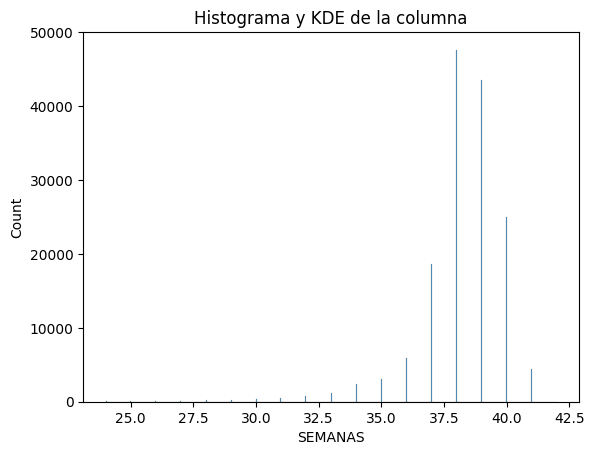

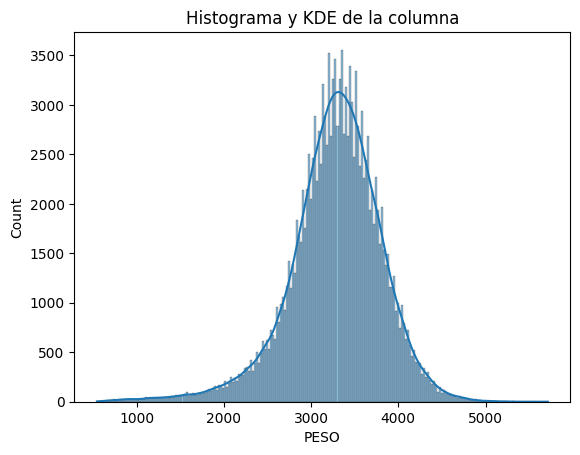

In [326]:
sns.histplot(df_f.SEMANAS, kde=False)
plt.title("Histograma y KDE de la columna")
plt.show()

sns.histplot(df_f.PESO, kde=True)
plt.title("Histograma y KDE de la columna")
plt.show()

In [19]:
df_table

Overall  \
                                                        (N=154173)   
Ages (Months)                                                  NaN   
                                <3                  35821 (23.23%)   
                                3 to 6              38182 (24.77%)   
                                >6                  80170 (52.00%)   
                                median (IQR)           6.27 (5.97)   
Sex                                                            NaN   
                                Female              76045 (49.32%)   
                                Male                78128 (50.68%)   
Nationality mother                                             NaN   
                                Foreign             16918 (10.97%)   
                                Domestic           127193 (82.50%)   
                                Unknown              10062 (6.53%)   
Season group                                                   NaN   
                                Catch-up            79183 (51.36%)   
                                Seasonal            74990 (48.64%)   
Time to immune (days)                                          NaN   
                                Catch-up             24.00 (34.00)   
                                Seasonal               1.00 (2.00)   
Gestational Age at birth (days)                                NaN   
                                Mean (SD)             38.21 (1.76)   
Weight at birth (gr)                                           NaN   
                                Mean (SD)         3276.64 (533.12)   
Preterm                                                        NaN   
                                No (>= 37 weeks)   139219 (90.30%)   
                                Yes (< 37 weeks)     14954 (9.70%)   
Macro-zones                                                    NaN   
                                North               15518 (10.07%)   
                                Central             90439 (58.66%)   
                                South               46138 (29.93%)   
                                Austral               2072 (1.34%)   

                                                  Nirse recipients  \
                                                        (N=145087)   
Ages (Months)                                                  NaN   
                                <3                  34443 (23.74%)   
                                3 to 6              37436 (25.80%)   
                                >6                  73208 (50.46%)   
                                median (IQR)           6.07 (5.87)   
Sex                                                            NaN   
                                Female              71551 (49.32%)   
                                Male                73536 (50.68%)   
Nationality mother                                             NaN   
                                Foreign             15800 (10.89%)   
                                Domestic           119291 (82.22%)   
                                Unknown               9996 (6.89%)   
Season group                                                   NaN   
                                Catch-up            72246 (49.79%)   
                                Seasonal            72841 (50.21%)   
Time to immune (days)                                          NaN   
                                Catch-up             24.00 (34.00)   
                                Seasonal               1.00 (2.00)   
Gestational Age at birth (days)                                NaN   
                                Mean (SD)             38.21 (1.75)   
Weight at birth (gr)                                           NaN   
                                Mean (SD)         3275.01 (532.66)   
Preterm                                                        NaN   
                                No (>= 37 weeks)   130913 (90.23%)  

In [ ]:
# worksheet = spreadsheet.worksheet("Tabla 1")

# data = [df_table.columns.names + list(df_table.columns.levels[0])]  # Encabezado
# data += [[str(item) if not pd.isna(item) else "" for item in row] for row in df_table.reset_index().values]


# cell_start = 'B2'


# num_rows, num_cols = len(data), len(data[0])
# range_start = worksheet.cell(2, 2).address  # A1
# range_end = worksheet.cell(2 + num_rows - 1, 2 + num_cols - 1).address  # Calcula la última celda
# cell_range = f'{range_start}:{range_end}'


# worksheet.clear()  # Limpia la hoja
# worksheet.update(cell_range, data)
# #worksheet.insert_rows(data, value_input_option='USER_ENTERED')

In [ ]:
# from gspread_dataframe import set_with_dataframe

# df_flat = df_table.copy()
# df_flat.columns = [' '.join(col).strip() for col in df_flat.columns.values]  

# #df_flat.columns = [f"{col.split()[0]}\n{' '.join(col.split()[1:])}" if ' ' in col else col for col in df_flat.columns]

# df_flat.index = [' '.join(map(str, idx)).strip() for idx in df_flat.index]  # Aplanar filas

# # Forzar todos los valores a texto
# df_flat = df_flat.fillna("")  # Reemplazar NaN con cadenas vacías
# df_flat = df_flat.astype(str)  # Convertir todos los valores a texto

# # Verificar tipos de datos en caso de problemas
# print("Tipos de datos en el DataFrame:")
# print(df_flat.dtypes)

# worksheet = spreadsheet.worksheet("Tabla 1")
# worksheet.clear()
# set_with_dataframe(worksheet, df_flat, include_index=True, row=2, col=2)

In [40]:
df_table

Overall  \
                                                        (N=154173)   
Ages (Months)                                                  NaN   
                                <3                  35821 (23.23%)   
                                3 to 6              38182 (24.77%)   
                                >6                  80170 (52.00%)   
Sex                                                            NaN   
                                Female              76045 (49.32%)   
                                Male                78128 (50.68%)   
Nationality mother                                             NaN   
                                Foreign             16918 (10.97%)   
                                Domestic           127193 (82.50%)   
                                Unknown              10062 (6.53%)   
Season group                                                   NaN   
                                Catch-up            79183 (51.36%)   
                                Seasonal            74990 (48.64%)   
Time to immune (days)                                          NaN   
                                Catch-up             30.74 (26.06)   
                                Seasonal               1.72 (6.10)   
Gestational Age at birth (days)                                NaN   
                                Mean (SD)             38.21 (1.76)   
                                Median                        38.0   
Weight at birth (gr)                                           NaN   
                                Mean (SD)         3276.64 (533.12)   
                                Median                      3310.0   
Preterm                                                        NaN   
                                No (>= 37 weeks)   139219 (90.30%)   
                                Yes (< 37 weeks)     14954 (9.70%)   
Macro-zones                                                    NaN   
                                North               15518 (10.07%)   
                                Central             90439 (58.66%)   
                                South               46138 (29.93%)   
                                Austral               2072 (1.34%)   

                                                  Nirse recipients  \
                                                        (N=145087)   
Ages (Months)                                                  NaN   
                                <3                  34443 (23.74%)   
                                3 to 6              37436 (25.80%)   
                                >6                  73208 (50.46%)   
Sex                                                            NaN   
                                Female              71551 (49.32%)   
                                Male                73536 (50.68%)   
Nationality mother                                             NaN   
                                Foreign             15800 (10.89%)   
                                Domestic           119291 (82.22%)   
                                Unknown               9996 (6.89%)   
Season group                                                   NaN   
                                Catch-up            72246 (49.79%)   
                                Seasonal            72841 (50.21%)   
Time to immune (days)                                          NaN   
                                Catch-up             30.74 (26.06)   
                                Seasonal               1.72 (6.10)   
Gestational Age at birth (days)                                NaN   
                                Mean (SD)             38.21 (1.75)   
                                Median                        38.0   
Weight at birth (gr)                                           NaN   
                                Mean (SD)         3275.01 (532.66)   
                                Median                      3310.0  

In [325]:
worksheet = spreadsheet.worksheet("Tabla 1")

column_order = list(df_table.columns)

top_level_columns = [col[0] for col in column_order]
bottom_level_columns = [col[1] for col in column_order]

header_top = [''] * len(df_table.columns.names) + top_level_columns
header_bottom = [''] * len(df_table.columns.names) + bottom_level_columns

data = [header_top, header_bottom] 

data += [[str(item) if not pd.isna(item) else "" for item in row] for row in df_table.reset_index().values]


cell_start = 'B3'


num_rows, num_cols = len(data), len(data[0])
range_start = worksheet.cell(3, 2).address  # A1
range_end = worksheet.cell(3 + num_rows - 1, 2 + num_cols - 1).address  # Calcula la última celda
cell_range = f'{range_start}:{range_end}'


worksheet.clear()  # Limpia la hoja
worksheet.update(cell_range, data)
#worksheet.insert_rows(data, value_input_option='USER_ENTERED')

{'spreadsheetId': '1-2qpesSusN3YQRlCdzCRIseRBAr8cpvPfjLu45BZgos',
 'updatedRange': "'Tabla 1'!B3:G34",
 'updatedRows': 32,
 'updatedColumns': 6,
 'updatedCells': 192}

### Tabla 1 Leo

In [58]:
T_final_tabla_abril = pd.to_datetime('2024-04-28')
T_final_tabla_mayo = pd.to_datetime('2024-05-26')
T_final_tabla_junio = pd.to_datetime('2024-06-30')
T_final_tabla_julio = pd.to_datetime('2024-07-28')

df_f['nacionalidad_madre'] = np.where(df_f['NAC_MA']!='C','Domestic' ,'Foreign' )
df_f['time_to_imune'] = (df_f['fechaInm'] - df_f['fecha_nac']).dt.days

df_f_abril= df_f[((df_f['fechaIng_vrs']<=T_final_tabla_abril) | (df_f['fechaIng_vrs'].isna())) & (df_f['fecha_nac'] <= T_final_tabla_abril)]
df_f_mayo= df_f[((df_f['fechaIng_vrs']<=T_final_tabla_mayo) | (df_f['fechaIng_vrs'].isna())) & (df_f['fecha_nac'] <= T_final_tabla_mayo)]
df_f_junio= df_f[((df_f['fechaIng_vrs']<=T_final_tabla_junio) | (df_f['fechaIng_vrs'].isna())) & (df_f['fecha_nac'] <= T_final_tabla_junio)]
df_f_julio= df_f[((df_f['fechaIng_vrs']<=T_final_tabla_julio) | (df_f['fechaIng_vrs'].isna())) & (df_f['fecha_nac'] <= T_final_tabla_julio)]

#### Abril

In [ ]:
df_f=df_f_abril
df_f['age_at_cut'] = (T_final_tabla_abril - df_f['fecha_nac']).dt.days
df_f['ages_group'] = np.where(df_f['age_at_cut'] < 90, 1, np.where(df_f['age_at_cut'] <= 180, 2, 3))

total_overall = len(df_f)
total_non_recipients = len(df_f[df_f['inmunizado'] == 0])
total_recipients = len(df_f[df_f['inmunizado'] == 1])

age_all = df_f['ages_group'].value_counts()
age_no_reci= df_f[df_f['inmunizado'] == 0]['ages_group'].value_counts()
age_reci = df_f[df_f['inmunizado'] == 1]['ages_group'].value_counts()

sex_counts_overall = df_f['SEXO'].value_counts()
sex_counts_non_recipients = df_f[df_f['inmunizado'] == 0]['SEXO'].value_counts()
sex_counts_recipients = df_f[df_f['inmunizado'] == 1]['SEXO'].value_counts()

nationality_counts_overall = df_f['group'].value_counts()
nationality_counts_non_recipients = df_f[df_f['inmunizado'] == 0]['group'].value_counts()
nationality_counts_recipients = df_f[df_f['inmunizado'] == 1]['group'].value_counts()
nationality_mother_counts_overall = df_f['nacionalidad_madre'].value_counts()

nationality_mother_counts_non_recp = df_f[df_f['inmunizado'] == 0]['nacionalidad_madre'].value_counts()
nationality_mother_counts_recipients = df_f[df_f['inmunizado'] == 1]['nacionalidad_madre'].value_counts()

# Edad gestacional al nacer (semanas)
mean_sd_overall = (df_f['SEMANAS'].mean(), df_f['SEMANAS'].std())
mean_sd_non_recipients = (df_f[df_f['inmunizado'] == 0]['SEMANAS'].mean(), df_f[df_f['inmunizado'] == 0]['SEMANAS'].std())
mean_sd_recipients = (df_f[df_f['inmunizado'] == 1]['SEMANAS'].mean(), df_f[df_f['inmunizado'] == 1]['SEMANAS'].std())

median_overall = df_f['SEMANAS'].median()
median_non_recipients = df_f[df_f['inmunizado'] == 0]['SEMANAS'].median()
median_recipients = df_f[df_f['inmunizado'] == 1]['SEMANAS'].median()

macrozone_all = df_f['Macrozona2'].value_counts()
macrozone_no_reci= df_f[df_f['inmunizado'] == 0]['Macrozona2'].value_counts()
macrozone_reci = df_f[df_f['inmunizado'] == 1]['Macrozona2'].value_counts()

time_inm_mean_sd_overall = (df_f['time_to_imune'].mean(), df_f['time_to_imune'].std())
time_inm_mean_sd_non_recipients = (df_f[df_f['inmunizado'] == 0]['time_to_imune'].mean(), df_f[df_f['inmunizado'] == 0]['time_to_imune'].std())
time_inm_mean_sd_recipients = (df_f[df_f['inmunizado'] == 1]['time_to_imune'].mean(), df_f[df_f['inmunizado'] == 1]['time_to_imune'].std())

time_inm_median_overall = df_f['time_to_imune'].median()
time_inm_median_non_recipients = df_f[df_f['inmunizado'] == 0]['time_to_imune'].median()
time_inm_median_recipients = df_f[df_f['inmunizado'] == 1]['time_to_imune'].median()


column_tuples = [
    ("Overall", f"N={total_overall}"),
    ("Nirse non recipients", f"N={total_non_recipients}"),
    ("Nirse recipients", f"N={total_recipients}")
]



# Convertir las tuplas en un MultiIndex para las columnas
columns = pd.MultiIndex.from_tuples(column_tuples)

# Crear la estructura de la tabla como antes
row_index = pd.MultiIndex.from_tuples([
    ("Ages (Months)", ""),
    ("", "<3"),
    ("", "3 to 6"),
    ("", ">6"),
    ("Sex", ""),
    ("", "Female"),
    ("", "Male"),
    ("", "Intersex"),
    ("Nationality mother", ""),
    ("", "Foreign"),
    ("", "Domestic"),
    ("", "Unknown"),
    ("Season group", ""),
    ("", "Catch-up"),
    ("", "New Born"),
    ("Time to immune (days)", ""),
    ("", "Mean (SD)"),
    ("", "Median"),
    ("Gestational Age at birth (days)", ""),
    (" ", "Mean (SD)"),
    (" ", "Median"),
    ("Macro-zones", ""),
    ("", "North"),
    ("", "Central"),
    ("", "South")
])


df_table = pd.DataFrame(index=row_index, columns=columns)

df_table.loc[("", "<3"), ("Overall", f"N={total_overall}")] = age_all.get(1,0)
df_table.loc[("", "<3"), ("Nirse non recipients", f"N={total_non_recipients}")] = age_no_reci.get(1,0)
df_table.loc[("", "<3"), ("Nirse recipients", f"N={total_recipients}")] = age_reci.get(1,0)

df_table.loc[("", "3 to 6"), ("Overall", f"N={total_overall}")] = age_all.get(2,0)
df_table.loc[("", "3 to 6"), ("Nirse non recipients", f"N={total_non_recipients}")] = age_no_reci.get(2,0)
df_table.loc[("", "3 to 6"), ("Nirse recipients", f"N={total_recipients}")] = age_reci.get(2,0)

df_table.loc[("", ">6"), ("Overall", f"N={total_overall}")] = age_all.get(3,0)
df_table.loc[("", ">6"), ("Nirse non recipients", f"N={total_non_recipients}")] = age_no_reci.get(3,0)
df_table.loc[("", ">6"), ("Nirse recipients", f"N={total_recipients}")] = age_reci.get(3,0)

df_table.loc[("", "Female"), ("Overall", f"N={total_overall}")] = sex_counts_overall.get(1, 0)
df_table.loc[("", "Female"), ("Nirse non recipients", f"N={total_non_recipients}")] = sex_counts_non_recipients.get(1, 0)
df_table.loc[("", "Female"), ("Nirse recipients", f"N={total_recipients}")] = sex_counts_recipients.get(1, 0)

df_table.loc[("", "Male"), ("Overall", f"N={total_overall}")] = sex_counts_overall.get(2, 0)
df_table.loc[("", "Male"), ("Nirse non recipients", f"N={total_non_recipients}")] = sex_counts_non_recipients.get(2, 0)
df_table.loc[("", "Male"), ("Nirse recipients", f"N={total_recipients}")] = sex_counts_recipients.get(2, 0)

df_table.loc[("", "Intersex"), ("Overall", f"N={total_overall}")] = sex_counts_overall.get(9, 0)
df_table.loc[("", "Intersex"), ("Nirse non recipients", f"N={total_non_recipients}")] = sex_counts_non_recipients.get(9, 0)
df_table.loc[("", "Intersex"), ("Nirse recipients", f"N={total_recipients}")] = sex_counts_recipients.get(9, 0)

df_table.loc[("", "Catch-up"), ("Overall", f"N={total_overall}")] = nationality_counts_overall.get('CATCH_UP', 0)
df_table.loc[("", "New Born"), ("Overall", f"N={total_overall}")] = nationality_counts_overall.get('SEASONAL', 0)

df_table.loc[("", "Catch-up"), ("Nirse non recipients", f"N={total_non_recipients}")] = nationality_counts_non_recipients.get('CATCH_UP', 0)
df_table.loc[("", "New Born"), ("Nirse non recipients", f"N={total_non_recipients}")] = nationality_counts_non_recipients.get('SEASONAL', 0)

df_table.loc[("", "Catch-up"), ("Nirse recipients", f"N={total_recipients}")] = nationality_counts_recipients.get('CATCH_UP', 0)
df_table.loc[("", "New Born"), ("Nirse recipients", f"N={total_recipients}")] = nationality_counts_recipients.get('SEASONAL', 0)

df_table.loc[("", "Foreign"), ("Overall", f"N={total_overall}")] = nationality_mother_counts_overall.get('Foreign', 0)
df_table.loc[("", "Domestic"), ("Overall", f"N={total_overall}")] = nationality_mother_counts_overall.get('Domestic', 0)

df_table.loc[("", "Foreign"), ("Nirse non recipients", f"N={total_non_recipients}")] = nationality_mother_counts_non_recp.get('Foreign', 0)
df_table.loc[("", "Domestic"), ("Nirse non recipients", f"N={total_non_recipients}")] = nationality_mother_counts_non_recp.get('Domestic', 0)

df_table.loc[("", "Foreign"), ("Nirse recipients", f"N={total_recipients}")] = nationality_mother_counts_recipients.get('Foreign', 0)
df_table.loc[("", "Domestic"), ("Nirse recipients", f"N={total_recipients}")] = nationality_mother_counts_recipients.get('Domestic', 0)

df_table.loc[(" ", "Mean (SD)"), ("Overall", f"N={total_overall}")]= f"{mean_sd_overall[0]:.2f} ({mean_sd_overall[1]:.2f})"
df_table.loc[(" ", "Mean (SD)"), ("Nirse non recipients", f"N={total_non_recipients}")] = f"{mean_sd_non_recipients[0]:.2f} ({mean_sd_non_recipients[1]:.2f})"
df_table.loc[(" ", "Mean (SD)"), ("Nirse recipients", f"N={total_recipients}")] = f"{mean_sd_recipients[0]:.2f} ({mean_sd_recipients[1]:.2f})"

df_table.loc[(" ", "Median"), ("Overall", f"N={total_overall}")] = median_overall
df_table.loc[(" ", "Median"), ("Nirse non recipients", f"N={total_non_recipients}")] = median_non_recipients
df_table.loc[(" ", "Median"), ("Nirse recipients", f"N={total_recipients}")] = median_recipients

df_table.loc[("", "North"), ("Overall", f"N={total_overall}")] = macrozone_all.get('Norte',0)
df_table.loc[("", "North"), ("Nirse non recipients", f"N={total_non_recipients}")] = macrozone_no_reci.get('Norte',0)
df_table.loc[("", "North"), ("Nirse recipients", f"N={total_recipients}")] = macrozone_reci.get('Norte',0)

df_table.loc[("", "Central"), ("Overall", f"N={total_overall}")] = macrozone_all.get('Centro',0)
df_table.loc[("", "Central"), ("Nirse non recipients", f"N={total_non_recipients}")] = macrozone_no_reci.get('Centro',0)
df_table.loc[("", "Central"), ("Nirse recipients", f"N={total_recipients}")] = macrozone_reci.get('Centro',0)

df_table.loc[("", "South"), ("Overall", f"N={total_overall}")] = macrozone_all.get('Sur',0)
df_table.loc[("", "South"), ("Nirse non recipients", f"N={total_non_recipients}")] = macrozone_no_reci.get('Sur',0)
df_table.loc[("", "South"), ("Nirse recipients", f"N={total_recipients}")] = macrozone_reci.get('Sur',0)

df_table.loc[("", "Mean (SD)"), ("Overall", f"N={total_overall}")] = f"{time_inm_mean_sd_overall[0]:.2f} ({time_inm_mean_sd_overall[1]:.2f})"
df_table.loc[("", "Mean (SD)"), ("Nirse non recipients", f"N={total_non_recipients}")] = f"{time_inm_mean_sd_non_recipients[0]:.2f} ({time_inm_mean_sd_non_recipients[1]:.2f})"
df_table.loc[("", "Mean (SD)"), ("Nirse recipients", f"N={total_recipients}")] = f"{time_inm_mean_sd_recipients[0]:.2f} ({time_inm_mean_sd_recipients[1]:.2f})"

df_table.loc[("", "Median"), ("Overall", f"N={total_overall}")] = time_inm_median_overall
df_table.loc[("", "Median"), ("Nirse non recipients", f"N={total_non_recipients}")] = time_inm_median_non_recipients
df_table.loc[("", "Median"), ("Nirse recipients", f"N={total_recipients}")] = time_inm_median_recipients

#df_table.to_excel(path_data / "Tabla1 dinámica.xlsx")

worksheet = spreadsheet.worksheet("abril")

column_order = list(df_table.columns)

top_level_columns = [col[0] for col in column_order]
bottom_level_columns = [col[1] for col in column_order]

header_top = [''] * len(df_table.columns.names) + top_level_columns
header_bottom = [''] * len(df_table.columns.names) + bottom_level_columns

data = [header_top, header_bottom] 

data += [[str(item) if not pd.isna(item) else "" for item in row] for row in df_table.reset_index().values]


cell_start = 'B3'


num_rows, num_cols = len(data), len(data[0])
range_start = worksheet.cell(3, 2).address  # A1
range_end = worksheet.cell(3 + num_rows - 1, 2 + num_cols - 1).address  # Calcula la última celda
cell_range = f'{range_start}:{range_end}'


worksheet.clear()  # Limpia la hoja
worksheet.update(cell_range, data)
#worksheet.insert_rows(data, value_input_option='USER_ENTERED')

{'spreadsheetId': '1-2qpesSusN3YQRlCdzCRIseRBAr8cpvPfjLu45BZgos',
 'updatedRange': 'abril!B3:F29',
 'updatedRows': 27,
 'updatedColumns': 5,
 'updatedCells': 135}

#### mayo

In [60]:
df_f=df_f_mayo
df_f['age_at_cut'] = (T_final_tabla_mayo - df_f['fecha_nac']).dt.days
df_f['ages_group'] = np.where(df_f['age_at_cut'] < 90, 1, np.where(df_f['age_at_cut'] <= 180, 2, 3))

total_overall = len(df_f)
total_non_recipients = len(df_f[df_f['inmunizado'] == 0])
total_recipients = len(df_f[df_f['inmunizado'] == 1])

age_all = df_f['ages_group'].value_counts()
age_no_reci= df_f[df_f['inmunizado'] == 0]['ages_group'].value_counts()
age_reci = df_f[df_f['inmunizado'] == 1]['ages_group'].value_counts()

sex_counts_overall = df_f['SEXO'].value_counts()
sex_counts_non_recipients = df_f[df_f['inmunizado'] == 0]['SEXO'].value_counts()
sex_counts_recipients = df_f[df_f['inmunizado'] == 1]['SEXO'].value_counts()

nationality_counts_overall = df_f['group'].value_counts()
nationality_counts_non_recipients = df_f[df_f['inmunizado'] == 0]['group'].value_counts()
nationality_counts_recipients = df_f[df_f['inmunizado'] == 1]['group'].value_counts()
nationality_mother_counts_overall = df_f['nacionalidad_madre'].value_counts()

nationality_mother_counts_non_recp = df_f[df_f['inmunizado'] == 0]['nacionalidad_madre'].value_counts()
nationality_mother_counts_recipients = df_f[df_f['inmunizado'] == 1]['nacionalidad_madre'].value_counts()

# Edad gestacional al nacer (semanas)
mean_sd_overall = (df_f['SEMANAS'].mean(), df_f['SEMANAS'].std())
mean_sd_non_recipients = (df_f[df_f['inmunizado'] == 0]['SEMANAS'].mean(), df_f[df_f['inmunizado'] == 0]['SEMANAS'].std())
mean_sd_recipients = (df_f[df_f['inmunizado'] == 1]['SEMANAS'].mean(), df_f[df_f['inmunizado'] == 1]['SEMANAS'].std())

median_overall = df_f['SEMANAS'].median()
median_non_recipients = df_f[df_f['inmunizado'] == 0]['SEMANAS'].median()
median_recipients = df_f[df_f['inmunizado'] == 1]['SEMANAS'].median()

macrozone_all = df_f['Macrozona2'].value_counts()
macrozone_no_reci= df_f[df_f['inmunizado'] == 0]['Macrozona2'].value_counts()
macrozone_reci = df_f[df_f['inmunizado'] == 1]['Macrozona2'].value_counts()

time_inm_mean_sd_overall = (df_f['time_to_imune'].mean(), df_f['time_to_imune'].std())
time_inm_mean_sd_non_recipients = (df_f[df_f['inmunizado'] == 0]['time_to_imune'].mean(), df_f[df_f['inmunizado'] == 0]['time_to_imune'].std())
time_inm_mean_sd_recipients = (df_f[df_f['inmunizado'] == 1]['time_to_imune'].mean(), df_f[df_f['inmunizado'] == 1]['time_to_imune'].std())

time_inm_median_overall = df_f['time_to_imune'].median()
time_inm_median_non_recipients = df_f[df_f['inmunizado'] == 0]['time_to_imune'].median()
time_inm_median_recipients = df_f[df_f['inmunizado'] == 1]['time_to_imune'].median()


column_tuples = [
    ("Overall", f"N={total_overall}"),
    ("Nirse non recipients", f"N={total_non_recipients}"),
    ("Nirse recipients", f"N={total_recipients}")
]



# Convertir las tuplas en un MultiIndex para las columnas
columns = pd.MultiIndex.from_tuples(column_tuples)

# Crear la estructura de la tabla como antes
row_index = pd.MultiIndex.from_tuples([
    ("Ages (Months)", ""),
    ("", "<3"),
    ("", "3 to 6"),
    ("", ">6"),
    ("Sex", ""),
    ("", "Female"),
    ("", "Male"),
    ("", "Intersex"),
    ("Nationality mother", ""),
    ("", "Foreign"),
    ("", "Domestic"),
    ("", "Unknown"),
    ("Season group", ""),
    ("", "Catch-up"),
    ("", "New Born"),
    ("Time to immune (days)", ""),
    ("", "Mean (SD)"),
    ("", "Median"),
    ("Gestational Age at birth (days)", ""),
    (" ", "Mean (SD)"),
    (" ", "Median"),
    ("Macro-zones", ""),
    ("", "North"),
    ("", "Central"),
    ("", "South")
])


df_table = pd.DataFrame(index=row_index, columns=columns)

df_table.loc[("", "<3"), ("Overall", f"N={total_overall}")] = age_all.get(1,0)
df_table.loc[("", "<3"), ("Nirse non recipients", f"N={total_non_recipients}")] = age_no_reci.get(1,0)
df_table.loc[("", "<3"), ("Nirse recipients", f"N={total_recipients}")] = age_reci.get(1,0)

df_table.loc[("", "3 to 6"), ("Overall", f"N={total_overall}")] = age_all.get(2,0)
df_table.loc[("", "3 to 6"), ("Nirse non recipients", f"N={total_non_recipients}")] = age_no_reci.get(2,0)
df_table.loc[("", "3 to 6"), ("Nirse recipients", f"N={total_recipients}")] = age_reci.get(2,0)

df_table.loc[("", ">6"), ("Overall", f"N={total_overall}")] = age_all.get(3,0)
df_table.loc[("", ">6"), ("Nirse non recipients", f"N={total_non_recipients}")] = age_no_reci.get(3,0)
df_table.loc[("", ">6"), ("Nirse recipients", f"N={total_recipients}")] = age_reci.get(3,0)

df_table.loc[("", "Female"), ("Overall", f"N={total_overall}")] = sex_counts_overall.get(1, 0)
df_table.loc[("", "Female"), ("Nirse non recipients", f"N={total_non_recipients}")] = sex_counts_non_recipients.get(1, 0)
df_table.loc[("", "Female"), ("Nirse recipients", f"N={total_recipients}")] = sex_counts_recipients.get(1, 0)

df_table.loc[("", "Male"), ("Overall", f"N={total_overall}")] = sex_counts_overall.get(2, 0)
df_table.loc[("", "Male"), ("Nirse non recipients", f"N={total_non_recipients}")] = sex_counts_non_recipients.get(2, 0)
df_table.loc[("", "Male"), ("Nirse recipients", f"N={total_recipients}")] = sex_counts_recipients.get(2, 0)

df_table.loc[("", "Intersex"), ("Overall", f"N={total_overall}")] = sex_counts_overall.get(9, 0)
df_table.loc[("", "Intersex"), ("Nirse non recipients", f"N={total_non_recipients}")] = sex_counts_non_recipients.get(9, 0)
df_table.loc[("", "Intersex"), ("Nirse recipients", f"N={total_recipients}")] = sex_counts_recipients.get(9, 0)

df_table.loc[("", "Catch-up"), ("Overall", f"N={total_overall}")] = nationality_counts_overall.get('CATCH_UP', 0)
df_table.loc[("", "New Born"), ("Overall", f"N={total_overall}")] = nationality_counts_overall.get('SEASONAL', 0)

df_table.loc[("", "Catch-up"), ("Nirse non recipients", f"N={total_non_recipients}")] = nationality_counts_non_recipients.get('CATCH_UP', 0)
df_table.loc[("", "New Born"), ("Nirse non recipients", f"N={total_non_recipients}")] = nationality_counts_non_recipients.get('SEASONAL', 0)

df_table.loc[("", "Catch-up"), ("Nirse recipients", f"N={total_recipients}")] = nationality_counts_recipients.get('CATCH_UP', 0)
df_table.loc[("", "New Born"), ("Nirse recipients", f"N={total_recipients}")] = nationality_counts_recipients.get('SEASONAL', 0)

df_table.loc[("", "Foreign"), ("Overall", f"N={total_overall}")] = nationality_mother_counts_overall.get('Foreign', 0)
df_table.loc[("", "Domestic"), ("Overall", f"N={total_overall}")] = nationality_mother_counts_overall.get('Domestic', 0)

df_table.loc[("", "Foreign"), ("Nirse non recipients", f"N={total_non_recipients}")] = nationality_mother_counts_non_recp.get('Foreign', 0)
df_table.loc[("", "Domestic"), ("Nirse non recipients", f"N={total_non_recipients}")] = nationality_mother_counts_non_recp.get('Domestic', 0)

df_table.loc[("", "Foreign"), ("Nirse recipients", f"N={total_recipients}")] = nationality_mother_counts_recipients.get('Foreign', 0)
df_table.loc[("", "Domestic"), ("Nirse recipients", f"N={total_recipients}")] = nationality_mother_counts_recipients.get('Domestic', 0)

df_table.loc[(" ", "Mean (SD)"), ("Overall", f"N={total_overall}")]= f"{mean_sd_overall[0]:.2f} ({mean_sd_overall[1]:.2f})"
df_table.loc[(" ", "Mean (SD)"), ("Nirse non recipients", f"N={total_non_recipients}")] = f"{mean_sd_non_recipients[0]:.2f} ({mean_sd_non_recipients[1]:.2f})"
df_table.loc[(" ", "Mean (SD)"), ("Nirse recipients", f"N={total_recipients}")] = f"{mean_sd_recipients[0]:.2f} ({mean_sd_recipients[1]:.2f})"

df_table.loc[(" ", "Median"), ("Overall", f"N={total_overall}")] = median_overall
df_table.loc[(" ", "Median"), ("Nirse non recipients", f"N={total_non_recipients}")] = median_non_recipients
df_table.loc[(" ", "Median"), ("Nirse recipients", f"N={total_recipients}")] = median_recipients

df_table.loc[("", "North"), ("Overall", f"N={total_overall}")] = macrozone_all.get('Norte',0)
df_table.loc[("", "North"), ("Nirse non recipients", f"N={total_non_recipients}")] = macrozone_no_reci.get('Norte',0)
df_table.loc[("", "North"), ("Nirse recipients", f"N={total_recipients}")] = macrozone_reci.get('Norte',0)

df_table.loc[("", "Central"), ("Overall", f"N={total_overall}")] = macrozone_all.get('Centro',0)
df_table.loc[("", "Central"), ("Nirse non recipients", f"N={total_non_recipients}")] = macrozone_no_reci.get('Centro',0)
df_table.loc[("", "Central"), ("Nirse recipients", f"N={total_recipients}")] = macrozone_reci.get('Centro',0)

df_table.loc[("", "South"), ("Overall", f"N={total_overall}")] = macrozone_all.get('Sur',0)
df_table.loc[("", "South"), ("Nirse non recipients", f"N={total_non_recipients}")] = macrozone_no_reci.get('Sur',0)
df_table.loc[("", "South"), ("Nirse recipients", f"N={total_recipients}")] = macrozone_reci.get('Sur',0)

df_table.loc[("", "Mean (SD)"), ("Overall", f"N={total_overall}")] = f"{time_inm_mean_sd_overall[0]:.2f} ({time_inm_mean_sd_overall[1]:.2f})"
df_table.loc[("", "Mean (SD)"), ("Nirse non recipients", f"N={total_non_recipients}")] = f"{time_inm_mean_sd_non_recipients[0]:.2f} ({time_inm_mean_sd_non_recipients[1]:.2f})"
df_table.loc[("", "Mean (SD)"), ("Nirse recipients", f"N={total_recipients}")] = f"{time_inm_mean_sd_recipients[0]:.2f} ({time_inm_mean_sd_recipients[1]:.2f})"

df_table.loc[("", "Median"), ("Overall", f"N={total_overall}")] = time_inm_median_overall
df_table.loc[("", "Median"), ("Nirse non recipients", f"N={total_non_recipients}")] = time_inm_median_non_recipients
df_table.loc[("", "Median"), ("Nirse recipients", f"N={total_recipients}")] = time_inm_median_recipients

#df_table.to_excel(path_data / "Tabla1 dinámica.xlsx")

worksheet = spreadsheet.worksheet("mayo")

column_order = list(df_table.columns)

top_level_columns = [col[0] for col in column_order]
bottom_level_columns = [col[1] for col in column_order]

header_top = [''] * len(df_table.columns.names) + top_level_columns
header_bottom = [''] * len(df_table.columns.names) + bottom_level_columns

data = [header_top, header_bottom] 

data += [[str(item) if not pd.isna(item) else "" for item in row] for row in df_table.reset_index().values]


cell_start = 'B3'


num_rows, num_cols = len(data), len(data[0])
range_start = worksheet.cell(3, 2).address  # A1
range_end = worksheet.cell(3 + num_rows - 1, 2 + num_cols - 1).address  # Calcula la última celda
cell_range = f'{range_start}:{range_end}'


worksheet.clear()  # Limpia la hoja
worksheet.update(cell_range, data)
#worksheet.insert_rows(data, value_input_option='USER_ENTERED')

{'spreadsheetId': '1-2qpesSusN3YQRlCdzCRIseRBAr8cpvPfjLu45BZgos',
 'updatedRange': 'mayo!B3:F29',
 'updatedRows': 27,
 'updatedColumns': 5,
 'updatedCells': 135}

In [61]:
df_f=df_f_junio
df_f['age_at_cut'] = (T_final_tabla_junio - df_f['fecha_nac']).dt.days
df_f['ages_group'] = np.where(df_f['age_at_cut'] < 90, 1, np.where(df_f['age_at_cut'] <= 180, 2, 3))

total_overall = len(df_f)
total_non_recipients = len(df_f[df_f['inmunizado'] == 0])
total_recipients = len(df_f[df_f['inmunizado'] == 1])

age_all = df_f['ages_group'].value_counts()
age_no_reci= df_f[df_f['inmunizado'] == 0]['ages_group'].value_counts()
age_reci = df_f[df_f['inmunizado'] == 1]['ages_group'].value_counts()

sex_counts_overall = df_f['SEXO'].value_counts()
sex_counts_non_recipients = df_f[df_f['inmunizado'] == 0]['SEXO'].value_counts()
sex_counts_recipients = df_f[df_f['inmunizado'] == 1]['SEXO'].value_counts()

nationality_counts_overall = df_f['group'].value_counts()
nationality_counts_non_recipients = df_f[df_f['inmunizado'] == 0]['group'].value_counts()
nationality_counts_recipients = df_f[df_f['inmunizado'] == 1]['group'].value_counts()
nationality_mother_counts_overall = df_f['nacionalidad_madre'].value_counts()

nationality_mother_counts_non_recp = df_f[df_f['inmunizado'] == 0]['nacionalidad_madre'].value_counts()
nationality_mother_counts_recipients = df_f[df_f['inmunizado'] == 1]['nacionalidad_madre'].value_counts()

# Edad gestacional al nacer (semanas)
mean_sd_overall = (df_f['SEMANAS'].mean(), df_f['SEMANAS'].std())
mean_sd_non_recipients = (df_f[df_f['inmunizado'] == 0]['SEMANAS'].mean(), df_f[df_f['inmunizado'] == 0]['SEMANAS'].std())
mean_sd_recipients = (df_f[df_f['inmunizado'] == 1]['SEMANAS'].mean(), df_f[df_f['inmunizado'] == 1]['SEMANAS'].std())

median_overall = df_f['SEMANAS'].median()
median_non_recipients = df_f[df_f['inmunizado'] == 0]['SEMANAS'].median()
median_recipients = df_f[df_f['inmunizado'] == 1]['SEMANAS'].median()

macrozone_all = df_f['Macrozona2'].value_counts()
macrozone_no_reci= df_f[df_f['inmunizado'] == 0]['Macrozona2'].value_counts()
macrozone_reci = df_f[df_f['inmunizado'] == 1]['Macrozona2'].value_counts()

time_inm_mean_sd_overall = (df_f['time_to_imune'].mean(), df_f['time_to_imune'].std())
time_inm_mean_sd_non_recipients = (df_f[df_f['inmunizado'] == 0]['time_to_imune'].mean(), df_f[df_f['inmunizado'] == 0]['time_to_imune'].std())
time_inm_mean_sd_recipients = (df_f[df_f['inmunizado'] == 1]['time_to_imune'].mean(), df_f[df_f['inmunizado'] == 1]['time_to_imune'].std())

time_inm_median_overall = df_f['time_to_imune'].median()
time_inm_median_non_recipients = df_f[df_f['inmunizado'] == 0]['time_to_imune'].median()
time_inm_median_recipients = df_f[df_f['inmunizado'] == 1]['time_to_imune'].median()


column_tuples = [
    ("Overall", f"N={total_overall}"),
    ("Nirse non recipients", f"N={total_non_recipients}"),
    ("Nirse recipients", f"N={total_recipients}")
]



# Convertir las tuplas en un MultiIndex para las columnas
columns = pd.MultiIndex.from_tuples(column_tuples)

# Crear la estructura de la tabla como antes
row_index = pd.MultiIndex.from_tuples([
    ("Ages (Months)", ""),
    ("", "<3"),
    ("", "3 to 6"),
    ("", ">6"),
    ("Sex", ""),
    ("", "Female"),
    ("", "Male"),
    ("", "Intersex"),
    ("Nationality mother", ""),
    ("", "Foreign"),
    ("", "Domestic"),
    ("", "Unknown"),
    ("Season group", ""),
    ("", "Catch-up"),
    ("", "New Born"),
    ("Time to immune (days)", ""),
    ("", "Mean (SD)"),
    ("", "Median"),
    ("Gestational Age at birth (days)", ""),
    (" ", "Mean (SD)"),
    (" ", "Median"),
    ("Macro-zones", ""),
    ("", "North"),
    ("", "Central"),
    ("", "South")
])


df_table = pd.DataFrame(index=row_index, columns=columns)

df_table.loc[("", "<3"), ("Overall", f"N={total_overall}")] = age_all.get(1,0)
df_table.loc[("", "<3"), ("Nirse non recipients", f"N={total_non_recipients}")] = age_no_reci.get(1,0)
df_table.loc[("", "<3"), ("Nirse recipients", f"N={total_recipients}")] = age_reci.get(1,0)

df_table.loc[("", "3 to 6"), ("Overall", f"N={total_overall}")] = age_all.get(2,0)
df_table.loc[("", "3 to 6"), ("Nirse non recipients", f"N={total_non_recipients}")] = age_no_reci.get(2,0)
df_table.loc[("", "3 to 6"), ("Nirse recipients", f"N={total_recipients}")] = age_reci.get(2,0)

df_table.loc[("", ">6"), ("Overall", f"N={total_overall}")] = age_all.get(3,0)
df_table.loc[("", ">6"), ("Nirse non recipients", f"N={total_non_recipients}")] = age_no_reci.get(3,0)
df_table.loc[("", ">6"), ("Nirse recipients", f"N={total_recipients}")] = age_reci.get(3,0)

df_table.loc[("", "Female"), ("Overall", f"N={total_overall}")] = sex_counts_overall.get(1, 0)
df_table.loc[("", "Female"), ("Nirse non recipients", f"N={total_non_recipients}")] = sex_counts_non_recipients.get(1, 0)
df_table.loc[("", "Female"), ("Nirse recipients", f"N={total_recipients}")] = sex_counts_recipients.get(1, 0)

df_table.loc[("", "Male"), ("Overall", f"N={total_overall}")] = sex_counts_overall.get(2, 0)
df_table.loc[("", "Male"), ("Nirse non recipients", f"N={total_non_recipients}")] = sex_counts_non_recipients.get(2, 0)
df_table.loc[("", "Male"), ("Nirse recipients", f"N={total_recipients}")] = sex_counts_recipients.get(2, 0)

df_table.loc[("", "Intersex"), ("Overall", f"N={total_overall}")] = sex_counts_overall.get(9, 0)
df_table.loc[("", "Intersex"), ("Nirse non recipients", f"N={total_non_recipients}")] = sex_counts_non_recipients.get(9, 0)
df_table.loc[("", "Intersex"), ("Nirse recipients", f"N={total_recipients}")] = sex_counts_recipients.get(9, 0)

df_table.loc[("", "Catch-up"), ("Overall", f"N={total_overall}")] = nationality_counts_overall.get('CATCH_UP', 0)
df_table.loc[("", "New Born"), ("Overall", f"N={total_overall}")] = nationality_counts_overall.get('SEASONAL', 0)

df_table.loc[("", "Catch-up"), ("Nirse non recipients", f"N={total_non_recipients}")] = nationality_counts_non_recipients.get('CATCH_UP', 0)
df_table.loc[("", "New Born"), ("Nirse non recipients", f"N={total_non_recipients}")] = nationality_counts_non_recipients.get('SEASONAL', 0)

df_table.loc[("", "Catch-up"), ("Nirse recipients", f"N={total_recipients}")] = nationality_counts_recipients.get('CATCH_UP', 0)
df_table.loc[("", "New Born"), ("Nirse recipients", f"N={total_recipients}")] = nationality_counts_recipients.get('SEASONAL', 0)

df_table.loc[("", "Foreign"), ("Overall", f"N={total_overall}")] = nationality_mother_counts_overall.get('Foreign', 0)
df_table.loc[("", "Domestic"), ("Overall", f"N={total_overall}")] = nationality_mother_counts_overall.get('Domestic', 0)

df_table.loc[("", "Foreign"), ("Nirse non recipients", f"N={total_non_recipients}")] = nationality_mother_counts_non_recp.get('Foreign', 0)
df_table.loc[("", "Domestic"), ("Nirse non recipients", f"N={total_non_recipients}")] = nationality_mother_counts_non_recp.get('Domestic', 0)

df_table.loc[("", "Foreign"), ("Nirse recipients", f"N={total_recipients}")] = nationality_mother_counts_recipients.get('Foreign', 0)
df_table.loc[("", "Domestic"), ("Nirse recipients", f"N={total_recipients}")] = nationality_mother_counts_recipients.get('Domestic', 0)

df_table.loc[(" ", "Mean (SD)"), ("Overall", f"N={total_overall}")]= f"{mean_sd_overall[0]:.2f} ({mean_sd_overall[1]:.2f})"
df_table.loc[(" ", "Mean (SD)"), ("Nirse non recipients", f"N={total_non_recipients}")] = f"{mean_sd_non_recipients[0]:.2f} ({mean_sd_non_recipients[1]:.2f})"
df_table.loc[(" ", "Mean (SD)"), ("Nirse recipients", f"N={total_recipients}")] = f"{mean_sd_recipients[0]:.2f} ({mean_sd_recipients[1]:.2f})"

df_table.loc[(" ", "Median"), ("Overall", f"N={total_overall}")] = median_overall
df_table.loc[(" ", "Median"), ("Nirse non recipients", f"N={total_non_recipients}")] = median_non_recipients
df_table.loc[(" ", "Median"), ("Nirse recipients", f"N={total_recipients}")] = median_recipients

df_table.loc[("", "North"), ("Overall", f"N={total_overall}")] = macrozone_all.get('Norte',0)
df_table.loc[("", "North"), ("Nirse non recipients", f"N={total_non_recipients}")] = macrozone_no_reci.get('Norte',0)
df_table.loc[("", "North"), ("Nirse recipients", f"N={total_recipients}")] = macrozone_reci.get('Norte',0)

df_table.loc[("", "Central"), ("Overall", f"N={total_overall}")] = macrozone_all.get('Centro',0)
df_table.loc[("", "Central"), ("Nirse non recipients", f"N={total_non_recipients}")] = macrozone_no_reci.get('Centro',0)
df_table.loc[("", "Central"), ("Nirse recipients", f"N={total_recipients}")] = macrozone_reci.get('Centro',0)

df_table.loc[("", "South"), ("Overall", f"N={total_overall}")] = macrozone_all.get('Sur',0)
df_table.loc[("", "South"), ("Nirse non recipients", f"N={total_non_recipients}")] = macrozone_no_reci.get('Sur',0)
df_table.loc[("", "South"), ("Nirse recipients", f"N={total_recipients}")] = macrozone_reci.get('Sur',0)

df_table.loc[("", "Mean (SD)"), ("Overall", f"N={total_overall}")] = f"{time_inm_mean_sd_overall[0]:.2f} ({time_inm_mean_sd_overall[1]:.2f})"
df_table.loc[("", "Mean (SD)"), ("Nirse non recipients", f"N={total_non_recipients}")] = f"{time_inm_mean_sd_non_recipients[0]:.2f} ({time_inm_mean_sd_non_recipients[1]:.2f})"
df_table.loc[("", "Mean (SD)"), ("Nirse recipients", f"N={total_recipients}")] = f"{time_inm_mean_sd_recipients[0]:.2f} ({time_inm_mean_sd_recipients[1]:.2f})"

df_table.loc[("", "Median"), ("Overall", f"N={total_overall}")] = time_inm_median_overall
df_table.loc[("", "Median"), ("Nirse non recipients", f"N={total_non_recipients}")] = time_inm_median_non_recipients
df_table.loc[("", "Median"), ("Nirse recipients", f"N={total_recipients}")] = time_inm_median_recipients

#df_table.to_excel(path_data / "Tabla1 dinámica.xlsx")

worksheet = spreadsheet.worksheet("junio")

column_order = list(df_table.columns)

top_level_columns = [col[0] for col in column_order]
bottom_level_columns = [col[1] for col in column_order]

header_top = [''] * len(df_table.columns.names) + top_level_columns
header_bottom = [''] * len(df_table.columns.names) + bottom_level_columns

data = [header_top, header_bottom] 

data += [[str(item) if not pd.isna(item) else "" for item in row] for row in df_table.reset_index().values]


cell_start = 'B3'


num_rows, num_cols = len(data), len(data[0])
range_start = worksheet.cell(3, 2).address  # A1
range_end = worksheet.cell(3 + num_rows - 1, 2 + num_cols - 1).address  # Calcula la última celda
cell_range = f'{range_start}:{range_end}'


worksheet.clear()  # Limpia la hoja
worksheet.update(cell_range, data)
#worksheet.insert_rows(data, value_input_option='USER_ENTERED')

{'spreadsheetId': '1-2qpesSusN3YQRlCdzCRIseRBAr8cpvPfjLu45BZgos',
 'updatedRange': 'junio!B3:F29',
 'updatedRows': 27,
 'updatedColumns': 5,
 'updatedCells': 135}

In [62]:
df_f=df_f_julio
df_f['age_at_cut'] = (T_final_tabla_julio - df_f['fecha_nac']).dt.days
df_f['ages_group'] = np.where(df_f['age_at_cut'] < 90, 1, np.where(df_f['age_at_cut'] <= 180, 2, 3))

total_overall = len(df_f)
total_non_recipients = len(df_f[df_f['inmunizado'] == 0])
total_recipients = len(df_f[df_f['inmunizado'] == 1])

age_all = df_f['ages_group'].value_counts()
age_no_reci= df_f[df_f['inmunizado'] == 0]['ages_group'].value_counts()
age_reci = df_f[df_f['inmunizado'] == 1]['ages_group'].value_counts()

sex_counts_overall = df_f['SEXO'].value_counts()
sex_counts_non_recipients = df_f[df_f['inmunizado'] == 0]['SEXO'].value_counts()
sex_counts_recipients = df_f[df_f['inmunizado'] == 1]['SEXO'].value_counts()

nationality_counts_overall = df_f['group'].value_counts()
nationality_counts_non_recipients = df_f[df_f['inmunizado'] == 0]['group'].value_counts()
nationality_counts_recipients = df_f[df_f['inmunizado'] == 1]['group'].value_counts()
nationality_mother_counts_overall = df_f['nacionalidad_madre'].value_counts()

nationality_mother_counts_non_recp = df_f[df_f['inmunizado'] == 0]['nacionalidad_madre'].value_counts()
nationality_mother_counts_recipients = df_f[df_f['inmunizado'] == 1]['nacionalidad_madre'].value_counts()

# Edad gestacional al nacer (semanas)
mean_sd_overall = (df_f['SEMANAS'].mean(), df_f['SEMANAS'].std())
mean_sd_non_recipients = (df_f[df_f['inmunizado'] == 0]['SEMANAS'].mean(), df_f[df_f['inmunizado'] == 0]['SEMANAS'].std())
mean_sd_recipients = (df_f[df_f['inmunizado'] == 1]['SEMANAS'].mean(), df_f[df_f['inmunizado'] == 1]['SEMANAS'].std())

median_overall = df_f['SEMANAS'].median()
median_non_recipients = df_f[df_f['inmunizado'] == 0]['SEMANAS'].median()
median_recipients = df_f[df_f['inmunizado'] == 1]['SEMANAS'].median()

macrozone_all = df_f['Macrozona2'].value_counts()
macrozone_no_reci= df_f[df_f['inmunizado'] == 0]['Macrozona2'].value_counts()
macrozone_reci = df_f[df_f['inmunizado'] == 1]['Macrozona2'].value_counts()

time_inm_mean_sd_overall = (df_f['time_to_imune'].mean(), df_f['time_to_imune'].std())
time_inm_mean_sd_non_recipients = (df_f[df_f['inmunizado'] == 0]['time_to_imune'].mean(), df_f[df_f['inmunizado'] == 0]['time_to_imune'].std())
time_inm_mean_sd_recipients = (df_f[df_f['inmunizado'] == 1]['time_to_imune'].mean(), df_f[df_f['inmunizado'] == 1]['time_to_imune'].std())

time_inm_median_overall = df_f['time_to_imune'].median()
time_inm_median_non_recipients = df_f[df_f['inmunizado'] == 0]['time_to_imune'].median()
time_inm_median_recipients = df_f[df_f['inmunizado'] == 1]['time_to_imune'].median()


column_tuples = [
    ("Overall", f"N={total_overall}"),
    ("Nirse non recipients", f"N={total_non_recipients}"),
    ("Nirse recipients", f"N={total_recipients}")
]



# Convertir las tuplas en un MultiIndex para las columnas
columns = pd.MultiIndex.from_tuples(column_tuples)

# Crear la estructura de la tabla como antes
row_index = pd.MultiIndex.from_tuples([
    ("Ages (Months)", ""),
    ("", "<3"),
    ("", "3 to 6"),
    ("", ">6"),
    ("Sex", ""),
    ("", "Female"),
    ("", "Male"),
    ("", "Intersex"),
    ("Nationality mother", ""),
    ("", "Foreign"),
    ("", "Domestic"),
    ("", "Unknown"),
    ("Season group", ""),
    ("", "Catch-up"),
    ("", "New Born"),
    ("Time to immune (days)", ""),
    ("", "Mean (SD)"),
    ("", "Median"),
    ("Gestational Age at birth (days)", ""),
    (" ", "Mean (SD)"),
    (" ", "Median"),
    ("Macro-zones", ""),
    ("", "North"),
    ("", "Central"),
    ("", "South")
])


df_table = pd.DataFrame(index=row_index, columns=columns)

df_table.loc[("", "<3"), ("Overall", f"N={total_overall}")] = age_all.get(1,0)
df_table.loc[("", "<3"), ("Nirse non recipients", f"N={total_non_recipients}")] = age_no_reci.get(1,0)
df_table.loc[("", "<3"), ("Nirse recipients", f"N={total_recipients}")] = age_reci.get(1,0)

df_table.loc[("", "3 to 6"), ("Overall", f"N={total_overall}")] = age_all.get(2,0)
df_table.loc[("", "3 to 6"), ("Nirse non recipients", f"N={total_non_recipients}")] = age_no_reci.get(2,0)
df_table.loc[("", "3 to 6"), ("Nirse recipients", f"N={total_recipients}")] = age_reci.get(2,0)

df_table.loc[("", ">6"), ("Overall", f"N={total_overall}")] = age_all.get(3,0)
df_table.loc[("", ">6"), ("Nirse non recipients", f"N={total_non_recipients}")] = age_no_reci.get(3,0)
df_table.loc[("", ">6"), ("Nirse recipients", f"N={total_recipients}")] = age_reci.get(3,0)

df_table.loc[("", "Female"), ("Overall", f"N={total_overall}")] = sex_counts_overall.get(1, 0)
df_table.loc[("", "Female"), ("Nirse non recipients", f"N={total_non_recipients}")] = sex_counts_non_recipients.get(1, 0)
df_table.loc[("", "Female"), ("Nirse recipients", f"N={total_recipients}")] = sex_counts_recipients.get(1, 0)

df_table.loc[("", "Male"), ("Overall", f"N={total_overall}")] = sex_counts_overall.get(2, 0)
df_table.loc[("", "Male"), ("Nirse non recipients", f"N={total_non_recipients}")] = sex_counts_non_recipients.get(2, 0)
df_table.loc[("", "Male"), ("Nirse recipients", f"N={total_recipients}")] = sex_counts_recipients.get(2, 0)

df_table.loc[("", "Intersex"), ("Overall", f"N={total_overall}")] = sex_counts_overall.get(9, 0)
df_table.loc[("", "Intersex"), ("Nirse non recipients", f"N={total_non_recipients}")] = sex_counts_non_recipients.get(9, 0)
df_table.loc[("", "Intersex"), ("Nirse recipients", f"N={total_recipients}")] = sex_counts_recipients.get(9, 0)

df_table.loc[("", "Catch-up"), ("Overall", f"N={total_overall}")] = nationality_counts_overall.get('CATCH_UP', 0)
df_table.loc[("", "New Born"), ("Overall", f"N={total_overall}")] = nationality_counts_overall.get('SEASONAL', 0)

df_table.loc[("", "Catch-up"), ("Nirse non recipients", f"N={total_non_recipients}")] = nationality_counts_non_recipients.get('CATCH_UP', 0)
df_table.loc[("", "New Born"), ("Nirse non recipients", f"N={total_non_recipients}")] = nationality_counts_non_recipients.get('SEASONAL', 0)

df_table.loc[("", "Catch-up"), ("Nirse recipients", f"N={total_recipients}")] = nationality_counts_recipients.get('CATCH_UP', 0)
df_table.loc[("", "New Born"), ("Nirse recipients", f"N={total_recipients}")] = nationality_counts_recipients.get('SEASONAL', 0)

df_table.loc[("", "Foreign"), ("Overall", f"N={total_overall}")] = nationality_mother_counts_overall.get('Foreign', 0)
df_table.loc[("", "Domestic"), ("Overall", f"N={total_overall}")] = nationality_mother_counts_overall.get('Domestic', 0)

df_table.loc[("", "Foreign"), ("Nirse non recipients", f"N={total_non_recipients}")] = nationality_mother_counts_non_recp.get('Foreign', 0)
df_table.loc[("", "Domestic"), ("Nirse non recipients", f"N={total_non_recipients}")] = nationality_mother_counts_non_recp.get('Domestic', 0)

df_table.loc[("", "Foreign"), ("Nirse recipients", f"N={total_recipients}")] = nationality_mother_counts_recipients.get('Foreign', 0)
df_table.loc[("", "Domestic"), ("Nirse recipients", f"N={total_recipients}")] = nationality_mother_counts_recipients.get('Domestic', 0)

df_table.loc[(" ", "Mean (SD)"), ("Overall", f"N={total_overall}")]= f"{mean_sd_overall[0]:.2f} ({mean_sd_overall[1]:.2f})"
df_table.loc[(" ", "Mean (SD)"), ("Nirse non recipients", f"N={total_non_recipients}")] = f"{mean_sd_non_recipients[0]:.2f} ({mean_sd_non_recipients[1]:.2f})"
df_table.loc[(" ", "Mean (SD)"), ("Nirse recipients", f"N={total_recipients}")] = f"{mean_sd_recipients[0]:.2f} ({mean_sd_recipients[1]:.2f})"

df_table.loc[(" ", "Median"), ("Overall", f"N={total_overall}")] = median_overall
df_table.loc[(" ", "Median"), ("Nirse non recipients", f"N={total_non_recipients}")] = median_non_recipients
df_table.loc[(" ", "Median"), ("Nirse recipients", f"N={total_recipients}")] = median_recipients

df_table.loc[("", "North"), ("Overall", f"N={total_overall}")] = macrozone_all.get('Norte',0)
df_table.loc[("", "North"), ("Nirse non recipients", f"N={total_non_recipients}")] = macrozone_no_reci.get('Norte',0)
df_table.loc[("", "North"), ("Nirse recipients", f"N={total_recipients}")] = macrozone_reci.get('Norte',0)

df_table.loc[("", "Central"), ("Overall", f"N={total_overall}")] = macrozone_all.get('Centro',0)
df_table.loc[("", "Central"), ("Nirse non recipients", f"N={total_non_recipients}")] = macrozone_no_reci.get('Centro',0)
df_table.loc[("", "Central"), ("Nirse recipients", f"N={total_recipients}")] = macrozone_reci.get('Centro',0)

df_table.loc[("", "South"), ("Overall", f"N={total_overall}")] = macrozone_all.get('Sur',0)
df_table.loc[("", "South"), ("Nirse non recipients", f"N={total_non_recipients}")] = macrozone_no_reci.get('Sur',0)
df_table.loc[("", "South"), ("Nirse recipients", f"N={total_recipients}")] = macrozone_reci.get('Sur',0)

df_table.loc[("", "Mean (SD)"), ("Overall", f"N={total_overall}")] = f"{time_inm_mean_sd_overall[0]:.2f} ({time_inm_mean_sd_overall[1]:.2f})"
df_table.loc[("", "Mean (SD)"), ("Nirse non recipients", f"N={total_non_recipients}")] = f"{time_inm_mean_sd_non_recipients[0]:.2f} ({time_inm_mean_sd_non_recipients[1]:.2f})"
df_table.loc[("", "Mean (SD)"), ("Nirse recipients", f"N={total_recipients}")] = f"{time_inm_mean_sd_recipients[0]:.2f} ({time_inm_mean_sd_recipients[1]:.2f})"

df_table.loc[("", "Median"), ("Overall", f"N={total_overall}")] = time_inm_median_overall
df_table.loc[("", "Median"), ("Nirse non recipients", f"N={total_non_recipients}")] = time_inm_median_non_recipients
df_table.loc[("", "Median"), ("Nirse recipients", f"N={total_recipients}")] = time_inm_median_recipients

#df_table.to_excel(path_data / "Tabla1 dinámica.xlsx")

worksheet = spreadsheet.worksheet("julio")

column_order = list(df_table.columns)

top_level_columns = [col[0] for col in column_order]
bottom_level_columns = [col[1] for col in column_order]

header_top = [''] * len(df_table.columns.names) + top_level_columns
header_bottom = [''] * len(df_table.columns.names) + bottom_level_columns

data = [header_top, header_bottom] 

data += [[str(item) if not pd.isna(item) else "" for item in row] for row in df_table.reset_index().values]


cell_start = 'B3'


num_rows, num_cols = len(data), len(data[0])
range_start = worksheet.cell(3, 2).address  # A1
range_end = worksheet.cell(3 + num_rows - 1, 2 + num_cols - 1).address  # Calcula la última celda
cell_range = f'{range_start}:{range_end}'


worksheet.clear()  # Limpia la hoja
worksheet.update(cell_range, data)
#worksheet.insert_rows(data, value_input_option='USER_ENTERED')

{'spreadsheetId': '1-2qpesSusN3YQRlCdzCRIseRBAr8cpvPfjLu45BZgos',
 'updatedRange': 'julio!B3:F29',
 'updatedRows': 27,
 'updatedColumns': 5,
 'updatedCells': 135}

### Tabla 2

In [46]:
df_f_any['anyIng_time_days'] = (T_final_tabla - df_f_any[['fechaIng_any', 'fecha_nac']].max(axis=1, skipna=True)).dt.days
df_f_LRTI['LRTI_time_days'] = (T_final_tabla - df_f_LRTI[['fechaIng_LRTI', 'fecha_nac']].max(axis=1, skipna=True)).dt.days
df_f_vrs['VRS_time_days'] = (T_final_tabla - df_f_vrs[['fechaIng_vrs', 'fecha_nac']].max(axis=1, skipna=True)).dt.days
df_f_upc['upc_time_days'] = (T_final_tabla - df_f_upc[['fecha_upc_vrs', 'fecha_nac']].max(axis=1, skipna=True)).dt.days

In [6]:
df_cox_vrs, df_cox_upc, df_f_vrs, df_f_upc = call_data_cox('NAC_RNI_EGRESOS_ENTREGA_ISCI_20_12_2024_encr.csv',40,group_age=True,weeks_inm=False)

n_rows_inicial= 167609
['DESCONOCIDO---->None' 'Región De Antofagasta---->ANTOFAGASTA'
 'Región De Arica Parinacota---->ARICA Y PARINACOTA'
 'Región De Atacama---->ATACAMA'
 'Región De Aysén del General Carlos Ibañez del Campo---->AISEN'
 'Región De Coquimbo---->COQUIMBO' 'Región De La Araucanía---->ARAUCANIA'
 'Región De Los Lagos---->LOS LAGOS' 'Región De Los Ríos---->LOS RIOS'
 'Región De Magallanes y de la Antártica Chilena---->MAGALLANES Y ANTARTICA'
 'Región De Tarapacá---->TARAPACA' 'Región De Valparaíso---->VALPARAISO'
 'Región De Ñuble---->NUBLE' 'Región Del Bíobío---->BIOBIO'
 "Región Del Libertador Gral. B. O'Higgins---->O'HIGGINS"
 'Región Del Maule---->MAULE'
 'Región Metropolitana de Santiago---->METROPOLITANA']
n_rows_post_prefiltred= 167609
Datos perdidos por muertes:  1202
ruts perdidos por filtro semanas y peso:  645
Droped intersex: 9
Datos perdidos por edad madre atípica: 245
Datos perdidos por fecha ingreso menor a fecha nacimiento: 57
vrs en los primeros 7 dias de

In [7]:
df_cox_vrs['group_age'] = df_cox_vrs[['si_1_meses', 'si_2_meses', 'si_3_meses', 'si_4_meses', 'si_5_meses', 'si_6_meses']].apply(
    lambda row: row.index[row == 1].max(), axis=1).fillna('si_0_meses')

In [8]:
df_cox_upc['group_age'] = df_cox_upc[['si_1_meses', 'si_2_meses', 'si_3_meses', 'si_4_meses', 'si_5_meses', 'si_6_meses']].apply(
    lambda row: row.index[row == 1].max(), axis=1).fillna('si_0_meses')

In [9]:
df_cox_vrs.to_csv(path_data/'df_vrs_control_neg2_all_meses.csv', index= False)
df_cox_upc.to_csv(path_data/'df_upc_control_neg2_all_meses.csv', index= False)

In [135]:
df_cox_any_marca, df_f_any_marca = call_data_cox_auxiliar('NAC_RNI_EGRESOS_ENTREGA_ISCI_20_12_2024_encr.csv',40,group_age=True,fecha_vrs='fechaIng_any')

n_rows_inicial= 167609
['DESCONOCIDO---->None' 'Región De Antofagasta---->ANTOFAGASTA'
 'Región De Arica Parinacota---->ARICA Y PARINACOTA'
 'Región De Atacama---->ATACAMA'
 'Región De Aysén del General Carlos Ibañez del Campo---->AISEN'
 'Región De Coquimbo---->COQUIMBO' 'Región De La Araucanía---->ARAUCANIA'
 'Región De Los Lagos---->LOS LAGOS' 'Región De Los Ríos---->LOS RIOS'
 'Región De Magallanes y de la Antártica Chilena---->MAGALLANES Y ANTARTICA'
 'Región De Tarapacá---->TARAPACA' 'Región De Valparaíso---->VALPARAISO'
 'Región De Ñuble---->NUBLE' 'Región Del Bíobío---->BIOBIO'
 "Región Del Libertador Gral. B. O'Higgins---->O'HIGGINS"
 'Región Del Maule---->MAULE'
 'Región Metropolitana de Santiago---->METROPOLITANA']
n_rows_post_prefiltred= 167609
Datos perdidos por muertes:  1202
Datos perdidos por filtro semanas y peso:  1224
Droped intersex: 9
Datos perdidos por edad madre atípica: 266
Datos perdidos por fecha ingreso menor a fecha nacimiento: 126
is_hapenin
vrs en los prim

In [136]:
df_cox_lrti_marca, df_f_LRTI_marca = call_data_cox_auxiliar('NAC_RNI_EGRESOS_ENTREGA_ISCI_20_12_2024_encr.csv',40,group_age=True,fecha_vrs='fechaIng_LRTI',lrti_name='LRTI_Flag')

n_rows_inicial= 167609
['DESCONOCIDO---->None' 'Región De Antofagasta---->ANTOFAGASTA'
 'Región De Arica Parinacota---->ARICA Y PARINACOTA'
 'Región De Atacama---->ATACAMA'
 'Región De Aysén del General Carlos Ibañez del Campo---->AISEN'
 'Región De Coquimbo---->COQUIMBO' 'Región De La Araucanía---->ARAUCANIA'
 'Región De Los Lagos---->LOS LAGOS' 'Región De Los Ríos---->LOS RIOS'
 'Región De Magallanes y de la Antártica Chilena---->MAGALLANES Y ANTARTICA'
 'Región De Tarapacá---->TARAPACA' 'Región De Valparaíso---->VALPARAISO'
 'Región De Ñuble---->NUBLE' 'Región Del Bíobío---->BIOBIO'
 "Región Del Libertador Gral. B. O'Higgins---->O'HIGGINS"
 'Región Del Maule---->MAULE'
 'Región Metropolitana de Santiago---->METROPOLITANA']
n_rows_post_prefiltred= 167609
Datos perdidos por muertes:  1202
Datos perdidos por filtro semanas y peso:  1224
Droped intersex: 9
Datos perdidos por edad madre atípica: 266
Datos perdidos por fecha ingreso menor a fecha nacimiento: 126
is_hapenin
vrs en los prim

In [20]:
df_f_any = df_f_any_marca.copy()
df_f_LRTI = df_f_LRTI_marca.copy()

In [137]:
df_cox_lrti_marca['group_age'] = df_cox_lrti_marca[['si_1_meses', 'si_2_meses', 'si_3_meses', 'si_4_meses', 'si_5_meses', 'si_6_meses']].apply(
    lambda row: row.index[row == 1].max(), axis=1).fillna('si_0_meses')

In [138]:
df_cox_any_marca['group_age'] = df_cox_any_marca[['si_1_meses', 'si_2_meses', 'si_3_meses', 'si_4_meses', 'si_5_meses', 'si_6_meses']].apply(
    lambda row: row.index[row == 1].max(), axis=1).fillna('si_0_meses')

In [43]:
# df_cox_vrs.to_csv(path_data/'df_vrs_s39_2012_all_meses.csv', index= False)
# df_cox_upc.to_csv(path_data/'df_upc_s39_2012_all_meses.csv', index= False)
df_cox_lrti.to_csv(path_data/'df_lrti_s39_2012_all_meses.csv', index= False)
df_cox_any.to_csv(path_data/'df_any_s39_2012_all_meses.csv', index= False)

In [139]:
df_cox_lrti_marca.to_csv(path_data/'df_lrti_s39_2012_all_meses_marca.csv', index= False)
df_cox_any_marca.to_csv(path_data/'df_any_s39_2012_all_meses_marca.csv', index= False)

In [49]:
aer_vrs = pd.read_csv(path_data/'df_vrs_s39_2012_all_meses.csv')

In [51]:
aer_vrs

,start,inmunizado,si_1_meses,si_2_meses,si_3_meses,si_4_meses,si_5_meses,si_6_meses,stop,RUN,event_vrs,group,sexo,prematuro_extremo,muy_prematuro,prematuro_moderado,prematuro,region,Macrozona2,EDAD_M,INS_C_M,REG_RES,DIAG1,MARCA,PREVI,URBA_RURAL,COMUNA,COMUNA_N,atypic_mom_age,INS_N_M,SEMANAS,cama,is_rural,categori_macro,categori_regions,exp_rural,percent_poor,percent_poor_multidim,is_poor,vrs_pre_campaña,porcent_rural,group_age
0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,12.0,00614e3cab1b6495a7fdbe942fec258a77383039033819053146c0fd32a73619,0,1,1,0,0,0,0,METROPOLITANA,Centro,29,4,13.0,J219,0,1.0,0,13110,13110,0,2,37.0,NaN,0,1,12,1.000361,3.529903,0.131562,0,0,0.000361,si_0_meses
1,12.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,34.0,00614e3cab1b6495a7fdbe942fec258a77383039033819053146c0fd32a73619,1,1,1,0,0,0,0,METROPOLITANA,Centro,29,4,13.0,J219,0,1.0,0,13110,13110,0,2,37.0,NaN,0,1,12,1.000361,3.529903,0.131562,0,0,0.000361,si_1_meses
2,0.0,0.0,1.0,1.0,1.0,1.0,0.0,0.0,8.0,0174b400385d1a938df24ee371ae82632384746790bf973c4e074a96cb70ed93,0,1,0,0,1,0,1,METROPOLITANA,Centro,30,4,13.0,J219,0,NaN,0,13122,13122,0,3,28.0,NaN,0,1,12,1.000000,3.241671,0.166439,0,0,0.000000,si_4_meses
3,8.0,1.0,1.0,1.0,1.0,1.0,0.0,0.0,13.0,0174b400385d1a938df24ee371ae82632384746790bf973c4e074a96cb70ed93,0,1,0,0,1,0,1,METROPOLITANA,Centro,30,4,13.0,J219,0,NaN,0,13122,13122,0,3,28.0,NaN,0,1,12,1.000000,3.241671,0.166439,0,0,0.000000,si_4_meses
4,13.0,1.0,1.0,1.0,1.0,1.0,1.0,0.0,43.0,0174b400385d1a938df24ee371ae82632384746790bf973c4e074a96cb70ed93,0,1,0,0,1,0,1,METROPOLITANA,Centro,30,4,13.0,J219,0,NaN,0,13122,13122,0,3,28.0,NaN,0,1,12,1.000000,3.241671,0.166439,0,0,0.000000,si_5_meses
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
733157,128.0,1.0,1.0,1.0,1.0,0.0,0.0,0.0,132.0,ffd136653d3cd5fde4bceb76ffeed2fab0f78e6d31d6d965af5a7b2852bde737,1,0,1,0,0,0,0,ARAUCANIA,Sur,28,4,9.0,J219,0,1.0,0,9207,9207,0,2,38.0,NaN,1,3,3,1.756693,21.468695,0.341355,1,0,0.563433,si_3_meses
733158,30.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,31.0,ffe855024890683a414710d903af194164e0fcdee4d9f10b07564fdeae65900f,0,0,1,0,0,1,1,METROPOLITANA,Centro,18,2,13.0,J121,0,1.0,0,13302,13302,1,2,36.0,UPC,0,1,12,1.207120,4.947952,0.256055,1,0,0.188238,si_0_meses
733159,31.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,60.0,ffe855024890683a414710d903af194164e0fcdee4d9f10b07564fdeae65900f,0,0,1,0,0,1,1,METROPOLITANA,Centro,18,2,13.0,J121,0,1.0,0,13302,13302,1,2,36.0,UPC,0,1,12,1.207120,4.947952,0.256055,1,0,0.188238,si_0_meses
733160,60.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,91.0,ffe855024890683a414710d903af194164e0fcdee4d9f10b07564fdeae65900f,0,0,1,0,0,1,1,METROPOLITANA,Centro,18,2,13.0,J121,0,1.0,0,13302,13302,1,2,36.0,UPC,0,1,12,1.207120,4.947952,0.256055,1,0,0.188238,si_1_meses


In [70]:
df_cox_vrs = pd.read_csv(path_data/'df_vrs_s39_2012_all_meses.csv')
df_cox_upc = pd.read_csv(path_data/'df_upc_s39_2012_all_meses.csv')
df_cox_lrti = pd.read_csv(path_data/'df_lrti_s39_2012_all_meses.csv')
df_cox_any = pd.read_csv(path_data/'df_any_s39_2012_all_meses.csv')

In [ ]:
df_cox_vrs = pd.read_csv(path_data/'df_vrs_s39_2012_all_meses_fix_marca.csv')
df_cox_upc = pd.read_csv(path_data/'df_upc_s39_2012_all_meses_fix_marca.csv')
df_cox_lrti = pd.read_csv(path_data/'df_lrti_s39_2012_all_meses_marca.csv')
df_cox_any = pd.read_csv(path_data/'df_any_s39_2012_all_meses_marca.csv')

In [150]:
df_cox_vrs.assign(hay_diag = lambda x: x.DIAG1.notna()).groupby('RUN').agg({'hay_diag':'first'}).hay_diag.sum()

30767

In [145]:
df_cox_vrs.groupby('RUN').agg({'event_vrs':'last'}).event_vrs.sum()

1287

In [76]:
one_hot = pd.get_dummies(df_cox_vrs['PREVI'], prefix='previ')
df = pd.concat([df_cox_vrs, one_hot], axis=1)
previ = df_cox_vrs['PREVI'].unique()
cols_previ = [f'previ_{p}' for p in previ]
cols_previ.remove('previ_nan')

In [103]:
region_to_macrozone_agencia = {
    "ARICA Y PARINACOTA": "Macrozona Norte",
    "TARAPACA": "Macrozona Norte",
    "ANTOFAGASTA": "Macrozona Norte",
    "ATACAMA": "Macrozona Norte",
    "COQUIMBO": "Macrozona Centro Norte",
    "VALPARAISO": "Macrozona Centro Norte",
    "METROPOLITANA": "Macrozona Centro Norte",
    "O'HIGGINS": "Macrozona Centro Norte",
    "MAULE": "Macrozona Centro Sur",
    "NUBLE": "Macrozona Centro Sur",
    "BIOBIO": "Macrozona Centro Sur",
    "ARAUCANIA": "Macrozona Centro Sur",
    "LOS RIOS": "Macrozona Sur",
    "LOS LAGOS": "Macrozona Sur",
    "AISEN": "Macrozona Austral",
    "MAGALLANES Y ANTARTICA": "Macrozona Austral"
}
df["macrozona_v1"] = df["region"].map(region_to_macrozone_agencia)

In [104]:
leo_zonas_rename = {'Macrozona Centro Sur':'South Macrozone',
                    'Macrozona Sur':'South Macrozone',
                    'Macrozona Norte':'North Macrozone',
                    'Macrozona Centro Norte':'Center Macrozone',
                    'Macrozona Austral':'Austral Macrozone'}

df = df.assign(leo_zonas = lambda x: x.macrozona_v1.replace(leo_zonas_rename))

In [136]:
df = df.assign(previ_2 = np.where((df.PREVI==1) | (df.PREVI==3) | (df.PREVI==4) | (df.PREVI==5) | (df.PREVI.isna()), 1, np.where(df.PREVI==2,2,0))).groupby('RUN').agg({'previ_2':'first','inmunizado':'last'}).groupby('inmunizado').previ_2.value_counts(dropna=False)

In [ ]:
df.groupby('RUN').agg({'PREVI':'first'}).PREVI.value_counts(dropna=False,normalize=True)

In [140]:
df_cox_vrs_marca = pd.read_csv(path_data/'df_vrs_s39_2012_all_meses_fix_marca.csv')
df_cox_upc_marca = pd.read_csv(path_data/'df_upc_s39_2012_all_meses_fix_marca.csv')

In [108]:
vrs_0 = ['J121', 'J205', 'J210','B974']
ruts_vrs_0 = df_cox_vrs.groupby('RUN',as_index=False).agg({'event_vrs':'max','DIAG1':'first'}).query('event_vrs==1').query('DIAG1.isin(@vrs_0)').RUN.unique()
ruts_novrs = df_cox_vrs.groupby('RUN',as_index=False).agg({'event_vrs':'max','DIAG1':'first'}).query('event_vrs==0').RUN.unique()

ruts_upc_0 = df_cox_upc.groupby('RUN',as_index=False).agg({'event_upc':'max','DIAG1':'first'}).query('event_upc==1').query('DIAG1.isin(@vrs_0)').RUN.unique()
ruts_noupc = df_cox_upc.groupby('RUN',as_index=False).agg({'event_upc':'max','DIAG1':'first'}).query('event_upc==0').RUN.unique()

df_cox_vrs0 = pd.concat([df_cox_vrs[((df_cox_vrs.DIAG1.isin(vrs_0)) & (df_cox_vrs.event_vrs==1)) | (df_cox_vrs.RUN.isin(ruts_novrs))],
                         df_cox_vrs[~df_cox_vrs.RUN.isin(df_cox_vrs[(df_cox_vrs.RUN.isin(ruts_vrs_0)) | (df_cox_vrs.RUN.isin(ruts_novrs))].RUN.unique())].assign(event_vrs = 0)])

df_cox_upc0 = pd.concat([df_cox_upc[((df_cox_upc.DIAG1.isin(vrs_0)) & (df_cox_upc.event_upc==1)) | (df_cox_upc.RUN.isin(ruts_noupc))],
                         df_cox_upc[~df_cox_upc.RUN.isin(df_cox_upc[(df_cox_upc.RUN.isin(ruts_upc_0)) | (df_cox_upc.RUN.isin(ruts_noupc))].RUN.unique())].assign(event_upc = 0)])

In [72]:
covs_base = ['start', 'inmunizado', 'stop', 'RUN', 'sexo','region', 'group_age','SEMANAS','is_rural']
##try prematuro, previ

events_and_dataframes = {
    'event_vrs': df_cox_vrs,#[((df_cox_vrs.DIAG1.isin(vrs_0)) & (df_cox_vrs.event_vrs==1)) | (df_cox_vrs.event_vrs==0)],
    'event_any': df_cox_any,
    'event_LRTI': df_cox_lrti,
    'event_upc': df_cox_upc#[((df_cox_upc.DIAG1.isin(vrs_0)) & (df_cox_upc.event_upc==1)) | (df_cox_upc.event_upc==0)]
}

cox_results = {}

for event, df_cox in events_and_dataframes.items():
    covs = covs_base + [event]  # Crear la lista de covariables dinámicamente
    cox_results[event] = cox_return(df_cox, covs=covs, prematuros=False).reset_index()
    
    
cox_vrs = cox_results['event_vrs']
cox_any = cox_results['event_any']
cox_LRTI = cox_results['event_LRTI']
cox_upc = cox_results['event_upc']


In [ ]:
covs_base = ['start', 'inmunizado', 'stop', 'RUN', 'sexo','region', 'group_age','SEMANAS','is_rural']
vrs_aver = cox_return(df_cox_vrs, covs=covs_base + ['event_vrs'], prematuros=False).reset_index()
display(vrs_aver.round(3))

,covariate,coef,effectiveness,se(coef),coef lower 95%,coef upper 95%,eff_lower_95,eff_upper_95,p
0,inmunizado,-1.453,0.766,0.089,-1.628,-1.278,0.721,0.804,0.0


In [332]:
df_control_neg = pd.read_csv(path_data/'df_neg_cont_vrs_pacheco_cods_2012_all_meses.csv')
df_control_neg_upc = pd.read_csv(path_data/'df_neg_cont_upc__pacheco_cods_2012_all_meses.csv')

In [334]:
df_control_neg.event_vrs.sum(),df_control_neg_upc.event_upc.sum()

(526, 60)

In [10]:
covs_base = ['start', 'inmunizado', 'stop', 'RUN', 'sexo','region', 'group_age','SEMANAS']

In [ ]:
control_negativo = cox_return(df_cox_vrs, covs=covs_base + ['event_vrs'], prematuros=False).reset_index()
display(control_negativo)
control_negativo_upc = cox_return(df_cox_upc, covs=covs_base + ['event_upc'], prematuros=False).reset_index()
display(control_negativo_upc)

,covariate,coef,effectiveness,se(coef),coef lower 95%,coef upper 95%,eff_lower_95,eff_upper_95,p
0,inmunizado,-0.106,0.101,0.148,-0.397,0.184,-0.202,0.327,0.473


In [ ]:
control_negativo_upc = cox_return(df_cox_upc, covs=covs_base + ['event_upc'], prematuros=False).reset_index()
display(control_negativo_upc)

,covariate,coef,effectiveness,se(coef),coef lower 95%,coef upper 95%,eff_lower_95,eff_upper_95,p
0,inmunizado,-0.272,0.238,0.457,-1.168,0.624,-0.866,0.689,0.551


In [13]:
df_cox_vrs.event_vrs.sum(),df_cox_upc.event_upc.sum()

(788, 206)

In [77]:
covs_marcel = ['start', 'inmunizado', 'stop', 'RUN', 'sexo','region', 'group_age','SEMANAS'] #,'SEMANAS'
marcel_cox = cox_return_marcel(df_cox_vrs, covs=covs_marcel + ['event_vrs'], prematuros=False).reset_index()
marcel_cox.round(3)

,covariate,coef,effectiveness,se(coef),coef lower 95%,coef upper 95%,eff_lower_95,eff_upper_95,p
0,inmunizado,-1.315,0.732,0.074,-1.461,-1.170,0.690,0.768,0.0
1,sexo,0.471,-0.602,0.058,0.358,0.584,-0.794,-0.431,0.0
2,SEMANAS,-0.130,0.122,0.011,-0.152,-0.108,0.103,0.141,0.0


In [ ]:
max = df_cox_vrs.stop.max()
df_marcel = df_cox_vrs.assign(stop_cov = lambda x: np.where(x.stop==max, pd.NA, x.stop))
covs_marcel = ['start', 'inmunizado', 'stop', 'RUN', 'sexo','region', 'group_age','SEMANAS','stop_cov']
marcel_cox = cox_return(df_marcel.dropna(subset=['stop_cov']), covs=covs_marcel + ['event_vrs'], prematuros=False).reset_index()
marcel_cox

,covariate,coef,effectiveness,se(coef),coef lower 95%,coef upper 95%,eff_lower_95,eff_upper_95,p
0,inmunizado,0.071,-0.073,0.115,-0.155,0.297,-0.346,0.144,0.539
1,stop_cov,-3.383,0.966,0.166,-3.709,-3.057,0.953,0.976,0.000


In [62]:
max = df_cox_vrs.stop.max()
df_marcel = df_cox_vrs.assign(stop_cov = lambda x: np.where(x.stop==max, pd.NA, x.stop))
covs_marcel = ['start', 'inmunizado', 'stop', 'RUN', 'sexo','region', 'group_age','SEMANAS','stop_cov']
marcel_cox = cox_return_marcel(df_marcel.dropna(subset=['stop_cov']), covs=covs_marcel + ['event_vrs'], prematuros=False).reset_index()
marcel_cox

,covariate,coef,effectiveness,se(coef),coef lower 95%,coef upper 95%,eff_lower_95,eff_upper_95,p
0,inmunizado,0.615,-0.849,0.102,0.415,0.814,-1.256,-0.515,0.0
1,sexo,0.440,-0.552,0.062,0.319,0.561,-0.752,-0.375,0.0
2,SEMANAS,-0.109,0.103,0.013,-0.134,-0.084,0.080,0.125,0.0
3,stop_cov,-3.393,0.966,0.140,-3.668,-3.118,0.956,0.974,0.0


In [63]:
df_marcel = df_cox_vrs.assign(stop_cov = lambda x: x.stop)
covs_marcel = ['start', 'inmunizado', 'stop', 'RUN', 'sexo','region', 'group_age','SEMANAS','stop_cov']
marcel_cox = cox_return_marcel(df_marcel, covs=covs_marcel + ['event_vrs'], prematuros=False).reset_index()
marcel_cox

,covariate,coef,effectiveness,se(coef),coef lower 95%,coef upper 95%,eff_lower_95,eff_upper_95,p
0,inmunizado,0.601,-0.824,0.101,0.403,0.799,-1.223,-0.497,0.0
1,sexo,0.439,-0.551,0.061,0.319,0.559,-0.749,-0.376,0.0
2,SEMANAS,-0.110,0.104,0.013,-0.135,-0.085,0.081,0.126,0.0
3,stop_cov,-2.975,0.949,0.113,-3.195,-2.754,0.936,0.959,0.0


In [ ]:
df_marcel = df_cox_vrs.assign(stop_cov = lambda x: x.stop)
covs_marcel = ['start', 'inmunizado', 'stop', 'RUN', 'sexo','region', 'group_age','SEMANAS','stop_cov']
marcel_cox = cox_return(df_marcel, covs=covs_marcel + ['event_vrs'], prematuros=False).reset_index()
marcel_cox

,covariate,coef,effectiveness,se(coef),coef lower 95%,coef upper 95%,eff_lower_95,eff_upper_95,p
0,inmunizado,-1.444,0.764,0.077,-1.595,-1.294,0.726,0.797,0.0


In [11]:
control_negativo_2 = cox_return(df_cox_vrs, covs=covs_base + ['event_vrs'], prematuros=False).reset_index()
control_negativo_2

,covariate,coef,effectiveness,se(coef),coef lower 95%,coef upper 95%,eff_lower_95,eff_upper_95,p
0,inmunizado,0.047,-0.048,0.149,-0.245,0.338,-0.402,0.217,0.755


In [12]:
control_negativo_upc_2 = cox_return(df_cox_upc, covs=covs_base + ['event_upc'], prematuros=False).reset_index()
control_negativo_upc_2

,covariate,coef,effectiveness,se(coef),coef lower 95%,coef upper 95%,eff_lower_95,eff_upper_95,p
0,inmunizado,0.299,-0.349,0.352,-0.39,0.989,-1.688,0.323,0.395


In [ ]:
conlos22 = cox_return(df_cox_vrs, covs=covs_base + ['event_vrs'], prematuros=False).reset_index()
conlos22

,covariate,coef,effectiveness,se(coef),coef lower 95%,coef upper 95%,eff_lower_95,eff_upper_95,p
0,inmunizado,-1.368,0.745,0.078,-1.521,-1.216,0.703,0.782,0.0


In [314]:
conlos22_upc = cox_return(df_cox_upc, covs=covs_base + ['event_upc'], prematuros=False).reset_index()
conlos22_upc

,covariate,coef,effectiveness,se(coef),coef lower 95%,coef upper 95%,eff_lower_95,eff_upper_95,p
0,inmunizado,-1.819,0.838,0.16,-2.132,-1.506,0.778,0.881,0.0


In [170]:
postrematuros = cox_return(df_cox_vrs.query('32<=SEMANAS<37'), covs=covs_base + ['event_vrs'], prematuros=False).reset_index()
postrematuros

,covariate,coef,effectiveness,se(coef),coef lower 95%,coef upper 95%,eff_lower_95,eff_upper_95,p
0,inmunizado,-1.113,0.671,0.249,-1.601,-0.624,0.464,0.798,0.0


In [169]:
preprematuros = cox_return(df_cox_vrs.query('SEMANAS<32'), covs=covs_base + ['event_vrs'], prematuros=False).reset_index()
preprematuros

,covariate,coef,effectiveness,se(coef),coef lower 95%,coef upper 95%,eff_lower_95,eff_upper_95,p
0,inmunizado,-1.7,0.817,0.856,-3.378,-0.022,0.022,0.966,0.047


In [ ]:
df_pre7days = (df_pf
 #              .query('event_vrs==1')
               .query('MARCA!=1')
               .query('SEXO!=9')
               .query('VIVO=="SI"')
               .assign(fechaIng_vrs_copy = lambda x: x.fechaIng_vrs)
)

df_pre7days.loc[df_pre7days.fechaIng_any <= df_pre7days.fecha_nac + pd.DateOffset(days=7), ['fechaIng_any', 'fechaIng_vrs', 'fecha_upc_vrs','fechaIng_LRTI']] = pd.NaT

df_pre7days.loc[(df_pre7days['fechaInm'] > df_pre7days['fechaIng_vrs']) , 'fechaInm'] = pd.NaT 

df_pre7days = df_pre7days[(df_pre7days['SEMANAS']>=24) & (df_pre7days['SEMANAS']<=42) & (df_pre7days['PESO'] >= df_pre7days['p_00001_lognormal']) & 
              (df_pre7days['PESO'] <= df_pre7days['p_99999_lognormal']) & (df_pre7days['EDAD_M']<=51) & (df_pre7days['EDAD_M']>=12) &
              (~df_pre7days.RUN.isin(df_pre7days[(df_pre7days['fechaIng_any'] < df_pre7days['fecha_nac'])].RUN.unique())) &
              (~df_pre7days.RUN.isin(df_pre7days[df_pre7days['fechaIng_vrs'] < pd.to_datetime("2024-04-01")].RUN.unique())) &
              (~df_pre7days.RUN.isin(df_pre7days[df_pre7days['fechaIng_vrs_copy'] <= df_pre7days.fecha_nac + pd.DateOffset(days=7)].RUN.unique())) &
              ((df_pre7days['fechaIng_vrs'] - df_pre7days['fechaInm']).dt.days <= 7)]

In [257]:
df_pre7days.DIAG1.value_counts()

DIAG1
J219    8
J210    7
J121    6
J205    1
Name: count, dtype: int64

In [256]:
pd.crosstab(df_pre7days.DIAG1, df_pre7days.assign(how_many_days_between_inm_and_vrs = lambda x: (x.fechaIng_vrs - x.fechaInm).dt.days).how_many_days_between_inm_and_vrs)

how_many_days_between_inm_and_vrs,0,1,4,5,6,7
DIAG1,,,,,,
J121,5,0,1,0,0,0
J205,1,0,0,0,0,0
J210,2,1,0,2,1,1
J219,0,2,2,0,2,2


In [204]:
df_pre7days.region.value_counts()

region
METROPOLITANA    14
VALPARAISO        4
TARAPACA          2
NUBLE             1
ANTOFAGASTA       1
Name: count, dtype: int64

In [281]:
df_pre7days.group.value_counts()

group
CATCH_UP    21
SEASONAL     1
Name: count, dtype: int64

In [284]:
df_pf.query('DIAG1.notna()')[(df_pf.query('DIAG1.notna()').DIAG1.str.startswith('A08')) | (df_pf.query('DIAG1.notna()').DIAG1.str.startswith('A09'))].DIAG1.unique()

array(['A099', 'A080', 'A083', 'A082', 'A084', 'A090', 'A081', 'A085'],
      dtype=object)

In [210]:
df_pre7days.SEMANAS.value_counts()

SEMANAS
38.0    6
40.0    5
37.0    4
39.0    2
35.0    2
34.0    2
36.0    1
Name: count, dtype: int64

In [222]:
df_pre7days.columns[:100]

Index(['RUN', 'RUN_RNI', 'RUN_MADRE', 'VACUNADO', 'MARCA', 'FECHA_NACIMIENTO',
       'MES_NAC', 'ANO_NAC', 'SEXO', 'SEMANAS', 'PESO', 'TALLA', 'EDAD_M',
       'INS_C_M', 'INS_N_M', 'COMUNA', 'COMUNA_N', 'REG_RES', 'URBA_RURAL',
       'NAC_MA', 'FECHA_INMUNIZACION', 'FECHA_DEFUNCION', 'CAUSA_DEFUNCION',
       'VIVO', 'FALLECIDO_PREVIO', 'ESTAB', 'ServicioSalud', 'Seremi',
       'P_ORIGEN', 'PREVI', 'FECHA_INGRESO', 'FECHA_EGRESO', 'AREA_FUNC_I',
       'SER_CLIN_I', 'DIA_1_TRAS', 'MES_1_TRAS', 'ANO_1_TRAS', 'AREAF_1_TRAS',
       'SERC_1_TRAS', 'DIA_2_TRAS', 'MES_2_TRAS', 'ANO_2_TRAS', 'AREAF_2_TRAS',
       'SERC_2_TRAS', 'DIA_3_TRAS', 'MES_3_TRAS', 'ANO_3_TRAS', 'AREAF_3_TRAS',
       'SERC_3_TRAS', 'DIA_4_TRAS', 'MES_4_TRAS', 'ANO_4_TRAS', 'AREAF_4_TRAS',
       'SERC_4_TRAS', 'DIA_5_TRAS', 'MES_5_TRAS', 'ANO_5_TRAS', 'AREAF_5_TRAS',
       'SERC_5_TRAS', 'DIA_6_TRAS', 'MES_6_TRAS', 'ANO_6_TRAS', 'AREAF_6_TRAS',
       'SERC_6_TRAS', 'DIA_7_TRAS', 'MES_7_TRAS', 'ANO_7_TRAS', 'AR

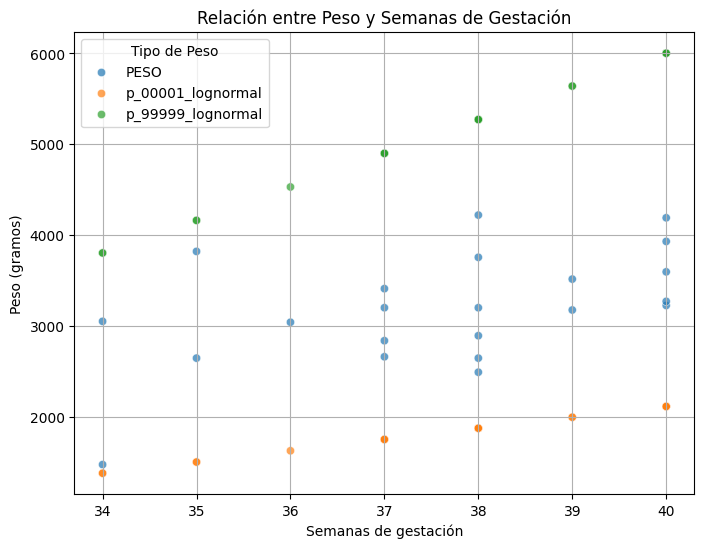

In [224]:
df_melted = df_pre7days.melt(id_vars=['SEMANAS'], value_vars=['PESO', 'p_00001_lognormal', 'p_99999_lognormal'], 
                     var_name='Tipo de Peso', value_name='Peso')

# Crear el gráfico de dispersión
plt.figure(figsize=(8,6))
sns.scatterplot(data=df_melted, x='SEMANAS', y='Peso', hue='Tipo de Peso', alpha=0.7)

# Personalización del gráfico
plt.xlabel("Semanas de gestación")
plt.ylabel("Peso (gramos)")
plt.title("Relación entre Peso y Semanas de Gestación")
plt.legend(title="Tipo de Peso")
plt.grid(True)

# Mostrar gráfico
plt.show()

In [218]:
df_pre7days.assign(how_many_days_between_inm_and_vrs = lambda x: (x.fechaIng_vrs - x.fechaInm).dt.days).how_many_days_between_inm_and_vrs.value_counts().sort_index()

how_many_days_between_inm_and_vrs
0    8
1    3
4    3
5    2
6    3
7    3
Name: count, dtype: int64

In [216]:
df_pre7days.fechaInm.value_counts().sort_index()

fechaInm
2024-04-05    2
2024-04-08    1
2024-04-11    1
2024-04-19    1
2024-04-22    1
2024-04-29    1
2024-05-03    1
2024-05-15    1
2024-05-17    2
2024-06-04    2
2024-06-12    1
2024-06-17    1
2024-06-18    2
2024-07-09    1
2024-07-10    1
2024-07-17    1
2024-07-31    1
2024-08-07    1
Name: count, dtype: int64

In [285]:
df_pf = pre_filtred(df_name='NAC_RNI_EGRESOS_ENTREGA_ISCI_20_12_2024_encr.csv',lrti_name='LRTI_Flag')#NAC_RNI_EGRESOS_ENTREGA_ISCI_16_12_2024_encr
df_f_any, df_f_LRTI, df_f_vrs, df_f_upc = filtros_IH_new(df_pf)

n_rows_inicial= 167609
['DESCONOCIDO---->None' 'Región De Antofagasta---->ANTOFAGASTA'
 'Región De Arica Parinacota---->ARICA Y PARINACOTA'
 'Región De Atacama---->ATACAMA'
 'Región De Aysén del General Carlos Ibañez del Campo---->AISEN'
 'Región De Coquimbo---->COQUIMBO' 'Región De La Araucanía---->ARAUCANIA'
 'Región De Los Lagos---->LOS LAGOS' 'Región De Los Ríos---->LOS RIOS'
 'Región De Magallanes y de la Antártica Chilena---->MAGALLANES Y ANTARTICA'
 'Región De Tarapacá---->TARAPACA' 'Región De Valparaíso---->VALPARAISO'
 'Región De Ñuble---->NUBLE' 'Región Del Bíobío---->BIOBIO'
 "Región Del Libertador Gral. B. O'Higgins---->O'HIGGINS"
 'Región Del Maule---->MAULE'
 'Región Metropolitana de Santiago---->METROPOLITANA']
n_rows_post_prefiltred= 167609
Datos perdidos por muertes:  1202
ruts perdidos por filtro semanas y peso:  645
Droped intersex: 9
Datos perdidos por edad madre atípica: 245
Datos perdidos por fecha ingreso menor a fecha nacimiento: 57
vrs en los primeros 7 dias de

In [ ]:
df_f_vrs.query('event_vrs==1').DIAG1.value_counts().sum(), df_f_upc.query('event_upc==1').DIAG1.value_counts().sum()

(526, 60)

In [335]:
df_f_vrs.event_vrs.sum()

1284

In [336]:
df_f_vrs[['RUN','DIAG1','ESTAB']].to_csv(path_data/'RunDiagEstab_vrs.csv')

In [73]:
df_f_any['anyIng_time_days'] = (T_final_tabla - df_f_any[['fechaIng_any', 'fecha_nac']].max(axis=1, skipna=True)).dt.days
df_f_LRTI['LRTI_time_days'] = (T_final_tabla - df_f_LRTI[['fechaIng_LRTI', 'fecha_nac']].max(axis=1, skipna=True)).dt.days
df_f_vrs['VRS_time_days'] = (T_final_tabla - df_f_vrs[['fechaIng_vrs', 'fecha_nac']].max(axis=1, skipna=True)).dt.days
df_f_upc['upc_time_days'] = (T_final_tabla - df_f_upc[['fecha_upc_vrs', 'fecha_nac']].max(axis=1, skipna=True)).dt.days

In [74]:
df_f = df_f_vrs.copy()
coef_inmunizado = cox_vrs.query('covariate=="inmunizado"').effectiveness.values[0]

lower_bound = cox_vrs.query('covariate=="inmunizado"').eff_lower_95.values[0]
upper_bound =  cox_vrs.query('covariate=="inmunizado"').eff_upper_95.values[0]

Effective = f"{100 * coef_inmunizado:.3f} ({100 * lower_bound:.3f}-{100 * upper_bound:.3f})"

VRS_event_nonrec = df_f[df_f['inmunizado'] == 0]['event_vrs'].sum()
VRS_event_rec = df_f[df_f['inmunizado'] == 1]['event_vrs'].sum()

VRS_person_year_nonrec = df_f[df_f['inmunizado'] == 0]['VRS_time_days'].sum()
VRS_person_year_rec = df_f[df_f['inmunizado'] == 1]['VRS_time_days'].sum()

df_f = df_f_upc.copy()
coef_inmunizado_upc = cox_upc.query('covariate=="inmunizado"').effectiveness.values[0]

lower_bound_upc = cox_upc.query('covariate=="inmunizado"').eff_lower_95.values[0]
upper_bound_upc = cox_upc.query('covariate=="inmunizado"').eff_upper_95.values[0]

Effective_upc = f"{100 * coef_inmunizado_upc:.3f} ({100 * lower_bound_upc:.3f}-{100 * upper_bound_upc:.3f})"

VRS_event_nonrec_upc = df_f[df_f['inmunizado'] == 0]['event_upc'].sum()
VRS_event_rec_upc = df_f[df_f['inmunizado'] == 1]['event_upc'].sum()

VRS_person_year_nonrec_upc = df_f[df_f['inmunizado'] == 0]['upc_time_days'].sum()
VRS_person_year_rec_upc = df_f[df_f['inmunizado'] == 1]['upc_time_days'].sum()

df_f = df_f_LRTI.copy()
coef_inmunizado_LRTI = cox_LRTI.query('covariate=="inmunizado"').effectiveness.values[0]

lower_bound_LRTI = cox_LRTI.query('covariate=="inmunizado"').eff_lower_95.values[0]
upper_bound_LRTI = cox_LRTI.query('covariate=="inmunizado"').eff_upper_95.values[0]

Effective_LRTI = f"{100 * coef_inmunizado_LRTI:.3f} ({100 * lower_bound_LRTI:.3f}-{100 * upper_bound_LRTI:.3f})"

LRTI_event_nonrec = df_f[df_f['inmunizado'] == 0]['event_LRTI'].sum()
LRTI_event_rec = df_f[df_f['inmunizado'] == 1]['event_LRTI'].sum()

LRTI_person_year_nonrec = df_f[df_f['inmunizado'] == 0]['LRTI_time_days'].sum()
LRTI_person_year_rec = df_f[df_f['inmunizado'] == 1]['LRTI_time_days'].sum()

df_f = df_f_any.copy()
coef_inmunizado_any = cox_any.query('covariate=="inmunizado"').effectiveness.values[0]

lower_bound_any = cox_any.query('covariate=="inmunizado"').eff_lower_95.values[0]
upper_bound_any = cox_any.query('covariate=="inmunizado"').eff_upper_95.values[0]

Effective_any = f"{100 * coef_inmunizado_any:.3f} ({100 * lower_bound_any:.3f}-{100 * upper_bound_any:.3f})"

any_event_nonrec = df_f[df_f['inmunizado'] == 0]['event_any'].sum()
any_event_rec = df_f[df_f['inmunizado'] == 1]['event_any'].sum()

any_person_year_nonrec = df_f[df_f['inmunizado'] == 0]['anyIng_time_days'].sum()
any_person_year_rec = df_f[df_f['inmunizado'] == 1]['anyIng_time_days'].sum()

df_f = df_f_vrs.copy()
total_overall = len(df_f)
total_non_recipients = len(df_f[df_f['inmunizado'] == 0])
total_recipients = len(df_f[df_f['inmunizado'] == 1])

In [75]:
nirse_index = f"Nirse recipients \n(N={total_recipients})"
non_nirse_index = f"Nirse non recipients \n(N={total_non_recipients})"

column_tuples2 = [
    (non_nirse_index, "Events"),
    ("", "Person-years"),
    (nirse_index, "Events"),
    (" ", "Person-years"),
    ("Hazard_rate (95% CI)", ""),
    ("Effectiveness (95% CI)", "")
]

columns2 = pd.MultiIndex.from_tuples(column_tuples2)

# row_index2 = pd.MultiIndex.from_tuples([
#     "RSV-related LRTI hospitalisation",
#     "Severe RSV-related LRTI with intensive care unit admission",
#     "All-cause LRTI hospitalisation",
#     "All-cause hospitalisation"
# ])

row_index2 = pd.Index([
    "RSV-related LRTI hospitalisation",
    "Severe RSV-related LRTI with intensive care unit admission",
    "All-cause LRTI hospitalisation",
    "All-cause hospitalisation"
])


df_table2 = pd.DataFrame(index=row_index2, columns=columns2)

df_table2.loc["RSV-related LRTI hospitalisation", (non_nirse_index, "Events")] = VRS_event_nonrec
df_table2.loc["RSV-related LRTI hospitalisation", ("", "Person-years")] = round(VRS_person_year_nonrec/365,2)
df_table2.loc["RSV-related LRTI hospitalisation", (nirse_index, "Events")] = VRS_event_rec
df_table2.loc["RSV-related LRTI hospitalisation", (" ", "Person-years")]= round(VRS_person_year_rec/365,2)
df_table2.loc["RSV-related LRTI hospitalisation", ("Hazard_rate (95% CI)", "")] = pd.NA
df_table2.loc["RSV-related LRTI hospitalisation", ("Effectiveness (95% CI)", "")] = Effective

df_table2.loc["Severe RSV-related LRTI with intensive care unit admission", (non_nirse_index, "Events")] = VRS_event_nonrec_upc
df_table2.loc["Severe RSV-related LRTI with intensive care unit admission", ("", "Person-years")] = round(VRS_person_year_nonrec_upc/365,2)
df_table2.loc["Severe RSV-related LRTI with intensive care unit admission", (nirse_index, "Events")] = VRS_event_rec_upc
df_table2.loc["Severe RSV-related LRTI with intensive care unit admission", (" ", "Person-years")]= round(VRS_person_year_rec_upc/365,2)
df_table2.loc["Severe RSV-related LRTI with intensive care unit admission", ("Hazard_rate (95% CI)", "")] = pd.NA
df_table2.loc["Severe RSV-related LRTI with intensive care unit admission", ("Effectiveness (95% CI)", "")] = Effective_upc

df_table2.loc["All-cause LRTI hospitalisation", (non_nirse_index, "Events")] = LRTI_event_nonrec
df_table2.loc["All-cause LRTI hospitalisation", ("", "Person-years")] = round(LRTI_person_year_nonrec/365,2)
df_table2.loc["All-cause LRTI hospitalisation", (nirse_index, "Events")] = LRTI_event_rec
df_table2.loc["All-cause LRTI hospitalisation", (" ", "Person-years")]= round(LRTI_person_year_rec/365,2)
df_table2.loc["All-cause LRTI hospitalisation", ("Hazard_rate (95% CI)", "")] = pd.NA
df_table2.loc["All-cause LRTI hospitalisation", ("Effectiveness (95% CI)", "")] = Effective_LRTI

df_table2.loc["All-cause hospitalisation", (non_nirse_index, "Events")] = any_event_nonrec
df_table2.loc["All-cause hospitalisation", ("", "Person-years")] = round(any_person_year_nonrec/365,2)
df_table2.loc["All-cause hospitalisation", (nirse_index, "Events")] = any_event_rec
df_table2.loc["All-cause hospitalisation", (" ", "Person-years")]= round(any_person_year_rec/365,2)
df_table2.loc["All-cause hospitalisation", ("Hazard_rate (95% CI)", "")] = pd.NA
df_table2.loc["All-cause hospitalisation", ("Effectiveness (95% CI)", "")] = Effective_any

In [76]:
df_table2

,Nirse non recipients \n(N=9086),,Nirse recipients \n(N=145087),,Hazard_rate (95% CI),Effectiveness (95% CI)
,Events,Person-years,Events,Person-years,,
RSV-related LRTI hospitalisation,327,5787.48,957,72128.31,<NA>,76.507 (72.658-79.814)
Severe RSV-related LRTI with intensive care unit admission,81,5789.0,189,72479.82,<NA>,84.465 (78.774-88.629)
All-cause LRTI hospitalisation,438,5776.54,1689,71721.89,<NA>,66.880 (62.375-70.846)
All-cause hospitalisation,1776,5830.63,6714,66897.67,<NA>,47.824 (44.252-51.167)


In [252]:
worksheet2 = spreadsheet.worksheet("Tabla 2 vrs0") #Tabla 2_autofill

column_order = list(df_table2.columns)

top_level_columns = [col[0] for col in column_order]
bottom_level_columns = [col[1] for col in column_order]

header_top = [''] + top_level_columns
header_bottom = [''] + bottom_level_columns

data = [header_top, header_bottom] 
data += [[str(item) if not pd.isna(item) else "" for item in row] for row in df_table2.reset_index().values]


cell_start = 'B2'


num_rows, num_cols = len(data), len(data[0])
range_start = worksheet2.cell(2, 2).address  # A1
range_end = worksheet2.cell(2 + num_rows - 1, 2 + num_cols).address  # Calcula la última celda
cell_range = f'{range_start}:{range_end}'


worksheet2.clear()  # Limpia la hoja
worksheet2.update(cell_range, data)
#worksheet2.insert_rows(data, value_input_option='USER_ENTERED')

{'spreadsheetId': '1-2qpesSusN3YQRlCdzCRIseRBAr8cpvPfjLu45BZgos',
 'updatedRange': "'Tabla 2 vrs0'!B2:H7",
 'updatedRows': 6,
 'updatedColumns': 7,
 'updatedCells': 42}

In [150]:
worksheet2 = spreadsheet.worksheet("Tabla_2_apendice") #Tabla 2_autofill

column_order = list(df_table2.columns)

top_level_columns = [col[0] for col in column_order]
bottom_level_columns = [col[1] for col in column_order]

header_top = [''] + top_level_columns
header_bottom = [''] + bottom_level_columns

data = [header_top, header_bottom] 
data += [[str(item) if not pd.isna(item) else "" for item in row] for row in df_table2.reset_index().values]


cell_start = 'B2'


num_rows, num_cols = len(data), len(data[0])
range_start = worksheet2.cell(2, 2).address  # A1
range_end = worksheet2.cell(2 + num_rows - 1, 2 + num_cols).address  # Calcula la última celda
cell_range = f'{range_start}:{range_end}'


worksheet2.clear()  # Limpia la hoja
worksheet2.update(cell_range, data)
#worksheet2.insert_rows(data, value_input_option='USER_ENTERED')

{'spreadsheetId': '1-2qpesSusN3YQRlCdzCRIseRBAr8cpvPfjLu45BZgos',
 'updatedRange': 'Tabla_2_apendice!B2:H7',
 'updatedRows': 6,
 'updatedColumns': 7,
 'updatedCells': 42}

In [151]:
df_table2

,Nirse non recipients \n(N=9289),,Nirse recipients \n(N=147172),,Hazard_rate (95% CI),Effectiveness (95% CI)
,Events,Person-years,Events,Person-years,,
RSV-related LRTI hospitalisation,328,5911.22,972,73201.46,<NA>,0.76 (0.72-0.79)
Severe RSV-related LRTI with intensive care unit admission,81,5913.02,190,73557.8,<NA>,0.84 (0.79-0.89)
All-cause LRTI hospitalisation,439,5899.31,1711,72790.21,<NA>,0.66 (0.61-0.70)
All-cause hospitalisation,1790,5946.24,6793,67923.25,<NA>,0.47 (0.44-0.51)


### Tabla 2 chi chico

In [81]:
chile_1 = ['METROPOLITANA','VALPARAISO','LOS LAGOS',"O'HIGGINS",'ARICA Y PARINACOTA','TARAPACA']
df_f_chico = df_f.copy().query('region.isin(@chile_1)')
covs_base = ['start', 'inmunizado', 'stop', 'RUN', 'sexo', 'region', 'group_age', 'muy_prematuro', 'is_poor', 'is_rural']

events_and_dataframes = {
    'event_vrs': df_cox_vrs.query('region.isin(@chile_1)'),
    'event_any': df_cox_any_post.query('region.isin(@chile_1)'),
    'event_LRTI': df_cox_lrti_post.query('region.isin(@chile_1)'),
    'event_upc': df_cox_upc.query('region.isin(@chile_1)')
}

cox_results = {}

for event, df_cox in events_and_dataframes.items():
    covs = covs_base + [event]  # Crear la lista de covariables dinámicamente
    cox_results[event] = cox_return(df_cox, covs=covs, prematuros=False).reset_index()

cox_vrs = cox_results['event_vrs']
cox_any = cox_results['event_any']
cox_LRTI = cox_results['event_LRTI']
cox_upc = cox_results['event_upc']

coef_inmunizado = cox_vrs.query('covariate=="inmunizado"').effectiveness.values[0]
lower_bound = cox_vrs.query('covariate=="inmunizado"').eff_lower_95.values[0]
upper_bound =  cox_vrs.query('covariate=="inmunizado"').eff_upper_95.values[0]
Effective = f"{coef_inmunizado:.2f} ({lower_bound:.2f}-{upper_bound:.2f})"
VRS_event_nonrec = df_f_chico[df_f_chico['inmunizado'] == 0]['event_vrs'].sum()
VRS_event_rec = df_f_chico[df_f_chico['inmunizado'] == 1]['event_vrs'].sum()
VRS_person_year_nonrec = df_f_chico[df_f_chico['inmunizado'] == 0]['VRS_time_days'].sum()
VRS_person_year_rec = df_f_chico[df_f_chico['inmunizado'] == 1]['VRS_time_days'].sum()

coef_inmunizado_upc = cox_upc.query('covariate=="inmunizado"').effectiveness.values[0]
lower_bound_upc = cox_upc.query('covariate=="inmunizado"').eff_lower_95.values[0]
upper_bound_upc = cox_upc.query('covariate=="inmunizado"').eff_upper_95.values[0]
Effective_upc = f"{coef_inmunizado_upc:.2f} ({lower_bound_upc:.2f}-{upper_bound_upc:.2f})"
VRS_event_nonrec_upc = df_f_chico[df_f_chico['inmunizado'] == 0]['event_upc'].sum()
VRS_event_rec_upc = df_f_chico[df_f_chico['inmunizado'] == 1]['event_upc'].sum()
VRS_person_year_nonrec_upc = df_f_chico[df_f_chico['inmunizado'] == 0]['upc_time_days'].sum()
VRS_person_year_rec_upc = df_f_chico[df_f_chico['inmunizado'] == 1]['upc_time_days'].sum()

coef_inmunizado_LRTI = cox_LRTI.query('covariate=="inmunizado"').effectiveness.values[0]

lower_bound_LRTI = cox_LRTI.query('covariate=="inmunizado"').eff_lower_95.values[0]
upper_bound_LRTI = cox_LRTI.query('covariate=="inmunizado"').eff_upper_95.values[0]

Effective_LRTI = f"{coef_inmunizado_LRTI:.2f} ({lower_bound_LRTI:.2f}-{upper_bound_LRTI:.2f})"

LRTI_event_nonrec = df_f_chico[df_f_chico['inmunizado'] == 0]['event_LRTI'].sum()
LRTI_event_rec = df_f_chico[df_f_chico['inmunizado'] == 1]['event_LRTI'].sum()

LRTI_person_year_nonrec = df_f_chico[df_f_chico['inmunizado'] == 0]['LRTI_time_days'].sum()
LRTI_person_year_rec = df_f_chico[df_f_chico['inmunizado'] == 1]['LRTI_time_days'].sum()

coef_inmunizado_any = cox_any.query('covariate=="inmunizado"').effectiveness.values[0]

lower_bound_any = cox_any.query('covariate=="inmunizado"').eff_lower_95.values[0]
upper_bound_any = cox_any.query('covariate=="inmunizado"').eff_upper_95.values[0]

Effective_any = f"{coef_inmunizado_any:.2f} ({lower_bound_any:.2f}-{upper_bound_any:.2f})"

any_event_nonrec = df_f_chico[df_f_chico['inmunizado'] == 0]['event_any'].sum()
any_event_rec = df_f_chico[df_f_chico['inmunizado'] == 1]['event_any'].sum()
any_person_year_nonrec = df_f_chico[df_f_chico['inmunizado'] == 0]['anyIng_time_days'].sum()
any_person_year_rec = df_f_chico[df_f_chico['inmunizado'] == 1]['anyIng_time_days'].sum()
total_overall = len(df_f_chico)
total_non_recipients = len(df_f_chico[df_f_chico['inmunizado'] == 0])
total_recipients = len(df_f_chico[df_f_chico['inmunizado'] == 1])
nirse_index = f"Nirse recipients \n(N={total_recipients})"
non_nirse_index = f"Nirse non recipients \n(N={total_non_recipients})"

column_tuples2 = [
    (nirse_index, "Events"),
    ("", "Person-years"),
    (non_nirse_index, "Events"),
    (" ", "Person-years"),
    ("Hazard_rate (95% CI)", ""),
    ("Effectiveness (95% CI)", "")
]

columns2 = pd.MultiIndex.from_tuples(column_tuples2)

row_index2 = pd.Index([
    "RSV-related LRTI hospitalisation",
    "Severe RSV-related LRTI with intensive care unit admission",
    "All-cause LRTI hospitalisation",
    "All-cause hospitalisation"
])


df_table2 = pd.DataFrame(index=row_index2, columns=columns2)

df_table2.loc["RSV-related LRTI hospitalisation", (nirse_index, "Events")] = VRS_event_nonrec
df_table2.loc["RSV-related LRTI hospitalisation", ("", "Person-years")] = VRS_person_year_nonrec
df_table2.loc["RSV-related LRTI hospitalisation", (non_nirse_index, "Events")] = VRS_event_rec
df_table2.loc["RSV-related LRTI hospitalisation", (" ", "Person-years")]= VRS_person_year_rec
df_table2.loc["RSV-related LRTI hospitalisation", ("Hazard_rate (95% CI)", "")] = pd.NA
df_table2.loc["RSV-related LRTI hospitalisation", ("Effectiveness (95% CI)", "")] = Effective

df_table2.loc["Severe RSV-related LRTI with intensive care unit admission", (nirse_index, "Events")] = VRS_event_nonrec_upc
df_table2.loc["Severe RSV-related LRTI with intensive care unit admission", ("", "Person-years")] = VRS_person_year_nonrec_upc
df_table2.loc["Severe RSV-related LRTI with intensive care unit admission", (non_nirse_index, "Events")] = VRS_event_rec_upc
df_table2.loc["Severe RSV-related LRTI with intensive care unit admission", (" ", "Person-years")]= VRS_person_year_rec_upc
df_table2.loc["Severe RSV-related LRTI with intensive care unit admission", ("Hazard_rate (95% CI)", "")] = pd.NA
df_table2.loc["Severe RSV-related LRTI with intensive care unit admission", ("Effectiveness (95% CI)", "")] = Effective_upc

df_table2.loc["All-cause LRTI hospitalisation", (nirse_index, "Events")] = LRTI_event_nonrec
df_table2.loc["All-cause LRTI hospitalisation", ("", "Person-years")] = LRTI_person_year_nonrec
df_table2.loc["All-cause LRTI hospitalisation", (non_nirse_index, "Events")] = LRTI_event_rec
df_table2.loc["All-cause LRTI hospitalisation", (" ", "Person-years")]= LRTI_person_year_rec
df_table2.loc["All-cause LRTI hospitalisation", ("Hazard_rate (95% CI)", "")] = pd.NA
df_table2.loc["All-cause LRTI hospitalisation", ("Effectiveness (95% CI)", "")] = Effective_LRTI

df_table2.loc["All-cause hospitalisation", (nirse_index, "Events")] = any_event_nonrec
df_table2.loc["All-cause hospitalisation", ("", "Person-years")] = any_person_year_nonrec
df_table2.loc["All-cause hospitalisation", (non_nirse_index, "Events")] = any_event_rec
df_table2.loc["All-cause hospitalisation", (" ", "Person-years")]= any_person_year_rec
df_table2.loc["All-cause hospitalisation", ("Hazard_rate (95% CI)", "")] = pd.NA
df_table2.loc["All-cause hospitalisation", ("Effectiveness (95% CI)", "")] = Effective_any
worksheet2 = spreadsheet.worksheet("Tabla 2_chilechico")

column_order = list(df_table2.columns)

top_level_columns = [col[0] for col in column_order]
bottom_level_columns = [col[1] for col in column_order]

header_top = [''] + top_level_columns
header_bottom = [''] + bottom_level_columns

data = [header_top, header_bottom] 
data += [[str(item) if not pd.isna(item) else "" for item in row] for row in df_table2.reset_index().values]


cell_start = 'B2'


num_rows, num_cols = len(data), len(data[0])
range_start = worksheet2.cell(2, 2).address  # A1
range_end = worksheet2.cell(2 + num_rows - 1, 2 + num_cols).address  # Calcula la última celda
cell_range = f'{range_start}:{range_end}'


worksheet2.clear()  # Limpia la hoja
worksheet2.update(cell_range, data)
#worksheet2.insert_rows(data, value_input_option='USER_ENTERED')

{'spreadsheetId': '1-2qpesSusN3YQRlCdzCRIseRBAr8cpvPfjLu45BZgos',
 'updatedRange': "'Tabla 2_chilechico'!B2:H7",
 'updatedRows': 6,
 'updatedColumns': 7,
 'updatedCells': 42}

In [358]:
# df_f['codJPO'] = np.where(df_f.DIAG1.startswith('J'), 'J', np.where(df_f.DIAG1.startswith('P'),'P','O') )
df_f['codJPO'] = df_f['DIAG1'].str[0].map({'J': 'J', 'P': 'P'}).fillna('O')

In [359]:
df_f['group_age'] = df_f[['si_1_meses', 'si_2_meses', 'si_3_meses', 'si_4_meses', 'si_5_meses', 'si_6_meses']].apply(
        lambda row: row.index[row == 1].max(), axis=1).fillna('si_0_meses')

In [369]:
df_f['edad_ing'] = (df_f.fechaIng_any - df_f.fecha_nac).dt.days

In [370]:
df_f['edad_ing'].describe()

count    53369.000000
mean        23.263468
std         52.133432
min          0.000000
25%          0.000000
50%          2.000000
75%         12.000000
max        325.000000
Name: edad_ing, dtype: float64

In [425]:
conditions = [
    df_f['edad_ing'] < 7,
    df_f['edad_ing'] < 14,
    df_f['edad_ing'] < 21,
    df_f['edad_ing'] < 28,
    df_f['edad_ing'] < 35,
    df_f['edad_ing'] < 42,
    df_f['edad_ing'] < 49,
    df_f['edad_ing'] < 56,
    df_f['edad_ing'] < 63,
    df_f['edad_ing'] < 70,
    df_f['edad_ing'] < 77,
    df_f['edad_ing'] < 84,
    df_f['edad_ing'] < 91,
    df_f['edad_ing'] < 98,
    df_f['edad_ing'] < 105
]

# Definir los valores correspondientes
choices = ['0', '1', '2', '3','4','5','6','7','8','9','10','11','12','13','14']

# Usar np.select para asignar los valores según las condiciones
df_f['semanas_a_ing'] = np.select(conditions, choices).astype(int)

<Axes: xlabel='semanas_a_ing'>

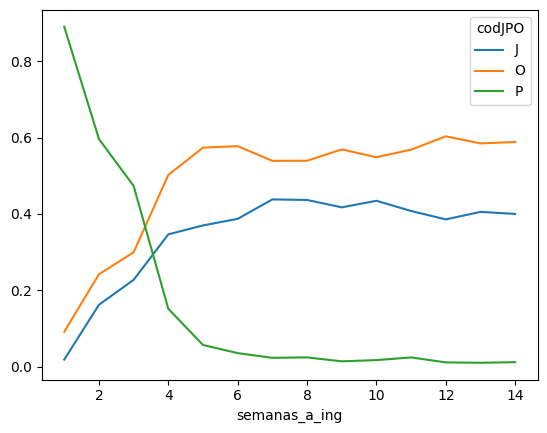

In [427]:
result = (
    df_f[['RUN', 'semanas_a_ing', 'codJPO']]
    .groupby(['semanas_a_ing', 'codJPO'])
    .size()
    .unstack(fill_value=0) 
)
#
result.div(result.sum(axis=1), axis=0).query('semanas_a_ing>0').sort_values(by='semanas_a_ing').plot()

<Axes: xlabel='edad_ing'>

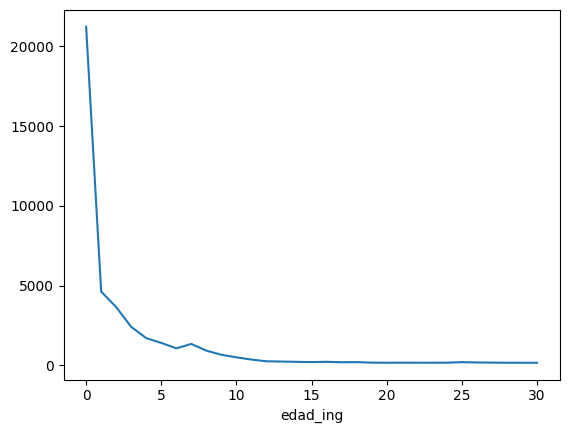

In [415]:
df_f.edad_ing.value_counts()[0:30].sort_index().plot()

### Tabla 3

In [77]:
df_f = df_f_vrs.copy()
coef_inmunizado = cox_vrs.query('covariate=="inmunizado"').effectiveness.values[0]

lower_bound = cox_vrs.query('covariate=="inmunizado"').eff_lower_95.values[0]
upper_bound =  cox_vrs.query('covariate=="inmunizado"').eff_upper_95.values[0]

Effective_vrs = f"{coef_inmunizado:.3f} ({lower_bound:.3f}-{upper_bound:.3f})"

VRS_event_nonrec = df_f[df_f['inmunizado'] == 0]['event_vrs'].sum()
VRS_event_rec = df_f[df_f['inmunizado'] == 1]['event_vrs'].sum()

VRS_person_year_nonrec = df_f[df_f['inmunizado'] == 0]['VRS_time_days'].sum()
VRS_person_year_rec = df_f[df_f['inmunizado'] == 1]['VRS_time_days'].sum()

In [78]:
df_f = df_f_upc.copy()
coef_inmunizado_upc = cox_upc.query('covariate=="inmunizado"').effectiveness.values[0]

lower_bound_upc = cox_upc.query('covariate=="inmunizado"').eff_lower_95.values[0]
upper_bound_upc = cox_upc.query('covariate=="inmunizado"').eff_upper_95.values[0]

Effective_upc = f"{coef_inmunizado_upc:.3f} ({lower_bound_upc:.3f}-{upper_bound_upc:.3f})"

VRS_event_nonrec_upc = df_f[df_f['inmunizado'] == 0]['event_upc'].sum()
VRS_event_rec_upc = df_f[df_f['inmunizado'] == 1]['event_upc'].sum()

VRS_person_year_nonrec_upc = df_f[df_f['inmunizado'] == 0]['upc_time_days'].sum()
VRS_person_year_rec_upc = df_f[df_f['inmunizado'] == 1]['upc_time_days'].sum()

In [86]:
nirse_index = f"Nirse recipients \n(N={total_recipients})"
non_nirse_index = f"Nirse non recipients \n(N={total_non_recipients})"

column_tuples2 = [
    (nirse_index, "Events"),
    ("", "Person-years"),
    (non_nirse_index, "Events"),
    (" ", "Person-years"),
    ("Hazard_rate (95% CI)", ""),
    ("Effectiveness (95% CI)", "")
]

columns2 = pd.MultiIndex.from_tuples(column_tuples2)

# row_index2 = pd.MultiIndex.from_tuples([
#     "RSV-related LRTI hospitalisation",
#     "Severe RSV-related LRTI with intensive care unit admission",
#     "All-cause LRTI hospitalisation",
#     "All-cause hospitalisation"
# ])

row_index2 = pd.Index([
    "RSV-related LRTI hospitalisation",
    "Severe RSV-related LRTI with intensive care unit admission",
    "All-cause LRTI hospitalisation",
    "All-cause hospitalisation"
])


df_table2 = pd.DataFrame(index=row_index2, columns=columns2)

df_table2.loc["RSV-related LRTI hospitalisation", (non_nirse_index, "Events")] = VRS_event_nonrec
df_table2.loc["RSV-related LRTI hospitalisation", ("", "Person-years")] = VRS_person_year_nonrec
df_table2.loc["RSV-related LRTI hospitalisation", (nirse_index, "Events")] = VRS_event_rec
df_table2.loc["RSV-related LRTI hospitalisation", (" ", "Person-years")]= VRS_person_year_rec
df_table2.loc["RSV-related LRTI hospitalisation", ("Hazard_rate (95% CI)", "")] = pd.NA
df_table2.loc["RSV-related LRTI hospitalisation", ("Effectiveness (95% CI)", "")] = Effective

df_table2.loc["Severe RSV-related LRTI with intensive care unit admission", (non_nirse_index, "Events")] = VRS_event_nonrec_upc
df_table2.loc["Severe RSV-related LRTI with intensive care unit admission", ("", "Person-years")] = VRS_person_year_nonrec_upc
df_table2.loc["Severe RSV-related LRTI with intensive care unit admission", (nirse_index, "Events")] = VRS_event_rec_upc
df_table2.loc["Severe RSV-related LRTI with intensive care unit admission", (" ", "Person-years")]= VRS_person_year_rec_upc
df_table2.loc["Severe RSV-related LRTI with intensive care unit admission", ("Hazard_rate (95% CI)", "")] = pd.NA
df_table2.loc["Severe RSV-related LRTI with intensive care unit admission", ("Effectiveness (95% CI)", "")] = Effective_upc

df_table2.loc["All-cause LRTI hospitalisation", (non_nirse_index, "Events")] = LRTI_event_nonrec
df_table2.loc["All-cause LRTI hospitalisation", ("", "Person-years")] = LRTI_person_year_nonrec
df_table2.loc["All-cause LRTI hospitalisation", (nirse_index, "Events")] = LRTI_event_rec
df_table2.loc["All-cause LRTI hospitalisation", (" ", "Person-years")]= LRTI_person_year_rec
df_table2.loc["All-cause LRTI hospitalisation", ("Hazard_rate (95% CI)", "")] = pd.NA
df_table2.loc["All-cause LRTI hospitalisation", ("Effectiveness (95% CI)", "")] = Effective_LRTI

df_table2.loc["All-cause hospitalisation", (non_nirse_index, "Events")] = any_event_nonrec
df_table2.loc["All-cause hospitalisation", ("", "Person-years")] = any_person_year_nonrec
df_table2.loc["All-cause hospitalisation", (nirse_index, "Events")] = any_event_rec
df_table2.loc["All-cause hospitalisation", (" ", "Person-years")]= any_person_year_rec
df_table2.loc["All-cause hospitalisation", ("Hazard_rate (95% CI)", "")] = pd.NA
df_table2.loc["All-cause hospitalisation", ("Effectiveness (95% CI)", "")] = Effective_any

In [79]:
def p_value_betas(beta_0, beta_1, se_0, se_1):
    var_0 = se_0**2
    var_1 = se_1**2

    z = (beta_1 - beta_0) / np.sqrt(var_1 + var_0)
    
    #p_value = 1 - norm.cdf(z)
    p_value = 2 * (1 - norm.cdf(abs(z)))#norm.sf(z)
    
    # if p_value < 0.001:
    #     p_value = "<0.001"
    # elif p_value < 0.01:
    #     p_value = "<0.01"
    # elif p_value < 0.05:
    #     p_value = "<0.05"
    # # elif p_value < 0.1:
    # #     p_value = "<0.1"
    # else:
    #     p_value = f"{p_value:.5f}"
    return p_value

covs_base = ['start', 'inmunizado', 'stop', 'RUN', 'sexo','region', 'group_age','SEMANAS','is_rural']

covs_sexo = ['start', 'inmunizado', 'stop', 'RUN', 'sexo','region', 'group_age','SEMANAS','is_rural']

covs_rural = ['start', 'inmunizado', 'stop', 'RUN', 'sexo','region', 'group_age','SEMANAS','is_rural']

column_tuples = [
    ("Events VRS", ""),
    ("Effectiveness Cox VRS", ""),
    ("Events UPC", ""),
    ("Effectiveness Cox UPC", "")
]

# Convertir las tuplas en un MultiIndex para las columnas
columns = pd.MultiIndex.from_tuples(column_tuples)

# Crear la estructura de la tabla como antes
row_index = pd.MultiIndex.from_tuples([
    ("Sex", ""),
    ("", "Female"),
    ("", "Male"),
 #   ("", "p_value"),
    ("Season group", ""),
    ("", "Catch-up"),
    ("", "New Born"),
#    (" ", "p_value"),
    ("Preterm", ""),
    ("", "No (>= 37 weeks)"),
    ("", "Yes (< 37 weeks)"),
#    ("  ", "p_value"),
    ("Urban/Rural", ""),
    ("", "Urban"),
    ("", "Rural")
 #   ("   ", "p_value")
])

p_values_vrs_dic_t3 = {}
p_values_upc_dic_t3 = {}

table_3 = pd.DataFrame(index=row_index, columns=columns)

cox_vrs_aux = cox_return(df_cox_vrs.query('sexo==0'), covs=covs_sexo + ['event_vrs'], prematuros=False).reset_index()

coef_vrs_aux_1 = cox_vrs_aux.query('covariate=="inmunizado"').coef.values[0]
sd_vrs_aux_1 = cox_vrs_aux.query('covariate=="inmunizado"')['se(coef)'].values[0]

coef_inmunizado = cox_vrs_aux.query('covariate=="inmunizado"').effectiveness.values[0]
lower_bound = cox_vrs_aux.query('covariate=="inmunizado"').eff_lower_95.values[0]
upper_bound =  cox_vrs_aux.query('covariate=="inmunizado"').eff_upper_95.values[0]
Effective = f"{coef_inmunizado:.5f} ({lower_bound:.5f}-{upper_bound:.5f})"
VRS_events = df_f_vrs.query('sexo==0').event_vrs.sum()

table_3.loc[("", "Female"), ("Events VRS", "")] = VRS_events
table_3.loc[("", "Female"), ("Effectiveness Cox VRS", "")] = Effective

cox_vrs_aux = cox_return(df_cox_upc.query('sexo==0'), covs=covs_sexo + ['event_upc'], prematuros=False).reset_index()

coef_upc_aux_1 = cox_vrs_aux.query('covariate=="inmunizado"').coef.values[0]
sd_upc_aux_1 = cox_vrs_aux.query('covariate=="inmunizado"')['se(coef)'].values[0]

coef_inmunizado = cox_vrs_aux.query('covariate=="inmunizado"').effectiveness.values[0]
lower_bound = cox_vrs_aux.query('covariate=="inmunizado"').eff_lower_95.values[0]
upper_bound =  cox_vrs_aux.query('covariate=="inmunizado"').eff_upper_95.values[0]
Effective = f"{coef_inmunizado:.5f} ({lower_bound:.5f}-{upper_bound:.5f})"
upc_events = df_f_upc.query('sexo==0').event_upc.sum()

table_3.loc[("", "Female"), ("Events UPC", "")] = upc_events
table_3.loc[("", "Female"), ("Effectiveness Cox UPC", "")] = Effective

cox_vrs_aux = cox_return(df_cox_vrs.query('sexo==1'), covs=covs_sexo + ['event_vrs'], prematuros=False).reset_index()

coef_vrs_aux_2 = cox_vrs_aux.query('covariate=="inmunizado"').coef.values[0]
sd_vrs_aux_2 = cox_vrs_aux.query('covariate=="inmunizado"')['se(coef)'].values[0]

coef_inmunizado = cox_vrs_aux.query('covariate=="inmunizado"').effectiveness.values[0]
lower_bound = cox_vrs_aux.query('covariate=="inmunizado"').eff_lower_95.values[0]
upper_bound =  cox_vrs_aux.query('covariate=="inmunizado"').eff_upper_95.values[0]
Effective = f"{coef_inmunizado:.5f} ({lower_bound:.5f}-{upper_bound:.5f})"
VRS_events = df_f_vrs.query('sexo==1').event_vrs.sum()

table_3.loc[("", "Male"), ("Events VRS", "")] = VRS_events
table_3.loc[("", "Male"), ("Effectiveness Cox VRS", "")] = Effective

cox_vrs_aux = cox_return(df_cox_upc.query('sexo==1'), covs=covs_sexo + ['event_upc'], prematuros=False).reset_index()

coef_upc_aux_2 = cox_vrs_aux.query('covariate=="inmunizado"').coef.values[0]
sd_upc_aux_2 = cox_vrs_aux.query('covariate=="inmunizado"')['se(coef)'].values[0]

coef_inmunizado = cox_vrs_aux.query('covariate=="inmunizado"').effectiveness.values[0]
lower_bound = cox_vrs_aux.query('covariate=="inmunizado"').eff_lower_95.values[0]
upper_bound =  cox_vrs_aux.query('covariate=="inmunizado"').eff_upper_95.values[0]
Effective = f"{coef_inmunizado:.5f} ({lower_bound:.5f}-{upper_bound:.5f})"
upc_events = df_f_upc.query('sexo==1').event_upc.sum()

table_3.loc[("", "Male"), ("Events UPC", "")] = upc_events
table_3.loc[("", "Male"), ("Effectiveness Cox UPC", "")] = Effective

p_value_vrs_aux = p_value_betas(coef_vrs_aux_1, coef_vrs_aux_2, sd_vrs_aux_1, sd_vrs_aux_2)
p_value_upc_aux = p_value_betas(coef_upc_aux_1, coef_upc_aux_2, sd_upc_aux_1, sd_upc_aux_2)

# table_3.loc[("","p_value"), ("Effectiveness Cox VRS", "")] = p_value_vrs_aux
# table_3.loc[("","p_value"), ("Effectiveness Cox UPC", "")] = p_value_upc_aux

p_values_vrs_dic_t3['sexo'] = p_value_vrs_aux
p_values_upc_dic_t3['sexo'] = p_value_upc_aux

###################################################### ANOTHER CATEGORY ####################################################

cox_vrs_aux = cox_return(df_cox_vrs.query('group==1'), covs=covs_base + ['event_vrs'], prematuros=False).reset_index()

coef_vrs_aux_1 = cox_vrs_aux.query('covariate=="inmunizado"').coef.values[0]
sd_vrs_aux_1 = cox_vrs_aux.query('covariate=="inmunizado"')['se(coef)'].values[0]

coef_inmunizado = cox_vrs_aux.query('covariate=="inmunizado"').effectiveness.values[0]
lower_bound = cox_vrs_aux.query('covariate=="inmunizado"').eff_lower_95.values[0]
upper_bound =  cox_vrs_aux.query('covariate=="inmunizado"').eff_upper_95.values[0]
Effective = f"{coef_inmunizado:.5f} ({lower_bound:.5f}-{upper_bound:.5f})"
VRS_events = df_f_vrs.query('group=="CATCH_UP"').event_vrs.sum()

table_3.loc[("", "Catch-up"), ("Events VRS", "")] = VRS_events
table_3.loc[("", "Catch-up"), ("Effectiveness Cox VRS", "")] = Effective

cox_vrs_aux = cox_return(df_cox_upc.query('group==1'), covs=covs_base + ['event_upc'], prematuros=False).reset_index()

coef_upc_aux_1 = cox_vrs_aux.query('covariate=="inmunizado"').coef.values[0]
sd_upc_aux_1 = cox_vrs_aux.query('covariate=="inmunizado"')['se(coef)'].values[0]

coef_inmunizado = cox_vrs_aux.query('covariate=="inmunizado"').effectiveness.values[0]
lower_bound = cox_vrs_aux.query('covariate=="inmunizado"').eff_lower_95.values[0]
upper_bound =  cox_vrs_aux.query('covariate=="inmunizado"').eff_upper_95.values[0]
Effective = f"{coef_inmunizado:.5f} ({lower_bound:.5f}-{upper_bound:.5f})"
upc_events = df_f_upc.query('group=="CATCH_UP"').event_upc.sum()

table_3.loc[("", "Catch-up"), ("Events UPC", "")] = upc_events
table_3.loc[("", "Catch-up"), ("Effectiveness Cox UPC", "")] = Effective

cox_vrs_aux = cox_return(df_cox_vrs.query('group==0'), covs=covs_base + ['event_vrs'], prematuros=False).reset_index()

coef_vrs_aux_2 = cox_vrs_aux.query('covariate=="inmunizado"').coef.values[0]
sd_vrs_aux_2 = cox_vrs_aux.query('covariate=="inmunizado"')['se(coef)'].values[0]

coef_inmunizado = cox_vrs_aux.query('covariate=="inmunizado"').effectiveness.values[0]
lower_bound = cox_vrs_aux.query('covariate=="inmunizado"').eff_lower_95.values[0]
upper_bound =  cox_vrs_aux.query('covariate=="inmunizado"').eff_upper_95.values[0]
Effective = f"{coef_inmunizado:.5f} ({lower_bound:.5f}-{upper_bound:.5f})"
VRS_events = df_f_vrs.query('group=="SEASONAL"').event_vrs.sum()

table_3.loc[("", "New Born"), ("Events VRS", "")] = VRS_events
table_3.loc[("", "New Born"), ("Effectiveness Cox VRS", "")] = Effective

cox_vrs_aux = cox_return(df_cox_upc.query('group==0'), covs=covs_base + ['event_upc'], prematuros=False).reset_index()

coef_upc_aux_2 = cox_vrs_aux.query('covariate=="inmunizado"').coef.values[0]
sd__upc_aux_2 = cox_vrs_aux.query('covariate=="inmunizado"')['se(coef)'].values[0]

coef_inmunizado = cox_vrs_aux.query('covariate=="inmunizado"').effectiveness.values[0]
lower_bound = cox_vrs_aux.query('covariate=="inmunizado"').eff_lower_95.values[0]
upper_bound =  cox_vrs_aux.query('covariate=="inmunizado"').eff_upper_95.values[0]
Effective = f"{coef_inmunizado:.5f} ({lower_bound:.5f}-{upper_bound:.5f})"
upc_events = df_f_upc.query('group=="SEASONAL"').event_upc.sum()

table_3.loc[("", "New Born"), ("Events UPC", "")] = upc_events
table_3.loc[("", "New Born"), ("Effectiveness Cox UPC", "")] = Effective

p_value_vrs_aux = p_value_betas(coef_vrs_aux_1, coef_vrs_aux_2, sd_vrs_aux_1, sd_vrs_aux_2)
p_value_upc_aux = p_value_betas(coef_upc_aux_1, coef_upc_aux_2, sd_upc_aux_1, sd_upc_aux_2)

# table_3.loc[(" ","p_value"), ("Effectiveness Cox VRS", "")] = p_value_vrs_aux
# table_3.loc[(" ","p_value"), ("Effectiveness Cox UPC", "")] = p_value_upc_aux

p_values_vrs_dic_t3['group'] = p_value_vrs_aux
p_values_upc_dic_t3['group'] = p_value_upc_aux

###################################################### ANOTHER CATEGORY ####################################################

cox_vrs_aux = cox_return(df_cox_vrs.query('SEMANAS>=37'), covs=covs_base + ['event_vrs'], prematuros=False).reset_index()

coef_vrs_aux_1 = cox_vrs_aux.query('covariate=="inmunizado"').coef.values[0]
sd_vrs_aux_1 = cox_vrs_aux.query('covariate=="inmunizado"')['se(coef)'].values[0]

coef_inmunizado = cox_vrs_aux.query('covariate=="inmunizado"').effectiveness.values[0]
lower_bound = cox_vrs_aux.query('covariate=="inmunizado"').eff_lower_95.values[0]
upper_bound =  cox_vrs_aux.query('covariate=="inmunizado"').eff_upper_95.values[0]
Effective = f"{coef_inmunizado:.5f} ({lower_bound:.5f}-{upper_bound:.5f})"
VRS_events = df_f_vrs.query('SEMANAS>=37').event_vrs.sum()

table_3.loc[("", "No (>= 37 weeks)"), ("Events VRS", "")] = VRS_events
table_3.loc[("", "No (>= 37 weeks)"), ("Effectiveness Cox VRS", "")] = Effective

cox_vrs_aux = cox_return(df_cox_upc.query('SEMANAS>=37'), covs=covs_base + ['event_upc'], prematuros=False).reset_index()

coef_upc_aux_1 = cox_vrs_aux.query('covariate=="inmunizado"').coef.values[0]
sd_upc_aux_1 = cox_vrs_aux.query('covariate=="inmunizado"')['se(coef)'].values[0]

coef_inmunizado = cox_vrs_aux.query('covariate=="inmunizado"').effectiveness.values[0]
lower_bound = cox_vrs_aux.query('covariate=="inmunizado"').eff_lower_95.values[0]
upper_bound =  cox_vrs_aux.query('covariate=="inmunizado"').eff_upper_95.values[0]
Effective = f"{coef_inmunizado:.5f} ({lower_bound:.5f}-{upper_bound:.5f})"
upc_events = df_f_upc.query('SEMANAS>=37').event_upc.sum()

table_3.loc[("", "No (>= 37 weeks)"), ("Events UPC", "")] = upc_events
table_3.loc[("", "No (>= 37 weeks)"), ("Effectiveness Cox UPC", "")] = Effective

cox_vrs_aux = cox_return(df_cox_vrs.query('SEMANAS<37'), covs=covs_base + ['event_vrs'], prematuros=False).reset_index()

coef_vrs_aux_2 = cox_vrs_aux.query('covariate=="inmunizado"').coef.values[0]
sd_vrs_aux_2 = cox_vrs_aux.query('covariate=="inmunizado"')['se(coef)'].values[0]

coef_inmunizado = cox_vrs_aux.query('covariate=="inmunizado"').effectiveness.values[0]
lower_bound = cox_vrs_aux.query('covariate=="inmunizado"').eff_lower_95.values[0]
upper_bound =  cox_vrs_aux.query('covariate=="inmunizado"').eff_upper_95.values[0]
Effective = f"{coef_inmunizado:.5f} ({lower_bound:.5f}-{upper_bound:.5f})"
VRS_events = df_f_vrs.query('SEMANAS<37').event_vrs.sum()

table_3.loc[("", "Yes (< 37 weeks)"), ("Events VRS", "")] = VRS_events
table_3.loc[("", "Yes (< 37 weeks)"), ("Effectiveness Cox VRS", "")] = Effective

cox_vrs_aux = cox_return(df_cox_upc.query('SEMANAS<37'), covs=covs_base + ['event_upc'], prematuros=False).reset_index()

coef_upc_aux_2 = cox_vrs_aux.query('covariate=="inmunizado"').coef.values[0]
sd_upc_aux_2 = cox_vrs_aux.query('covariate=="inmunizado"')['se(coef)'].values[0]

coef_inmunizado = cox_vrs_aux.query('covariate=="inmunizado"').effectiveness.values[0]
lower_bound = cox_vrs_aux.query('covariate=="inmunizado"').eff_lower_95.values[0]
upper_bound =  cox_vrs_aux.query('covariate=="inmunizado"').eff_upper_95.values[0]
Effective = f"{coef_inmunizado:.5f} ({lower_bound:.5f}-{upper_bound:.5f})"
upc_events = df_f_upc.query('SEMANAS<37').event_upc.sum()

table_3.loc[("", "Yes (< 37 weeks)"), ("Events UPC", "")] = upc_events
table_3.loc[("", "Yes (< 37 weeks)"), ("Effectiveness Cox UPC", "")] = Effective

p_value_vrs_aux = p_value_betas(coef_vrs_aux_1, coef_vrs_aux_2, sd_vrs_aux_1, sd_vrs_aux_2)
p_value_upc_aux = p_value_betas(coef_upc_aux_1, coef_upc_aux_2, sd_upc_aux_1, sd_upc_aux_2)

# table_3.loc[("  ","p_value"), ("Effectiveness Cox VRS", "")] = p_value_vrs_aux
# table_3.loc[("  ","p_value"), ("Effectiveness Cox UPC", "")] = p_value_upc_aux

p_values_vrs_dic_t3['prematuros'] = p_value_vrs_aux
p_values_upc_dic_t3['prematuros'] = p_value_upc_aux

###################################################### ANOTHER CATEGORY ####################################################


cox_vrs_aux = cox_return(df_cox_vrs.query('is_rural==0'), covs=covs_rural + ['event_vrs'], prematuros=False).reset_index()

coef_vrs_aux_1 = cox_vrs_aux.query('covariate=="inmunizado"').coef.values[0]
sd_vrs_aux_1 = cox_vrs_aux.query('covariate=="inmunizado"')['se(coef)'].values[0]

coef_inmunizado = cox_vrs_aux.query('covariate=="inmunizado"').effectiveness.values[0]
lower_bound = cox_vrs_aux.query('covariate=="inmunizado"').eff_lower_95.values[0]
upper_bound =  cox_vrs_aux.query('covariate=="inmunizado"').eff_upper_95.values[0]
Effective = f"{coef_inmunizado:.5f} ({lower_bound:.5f}-{upper_bound:.5f})"
VRS_events = df_f_vrs.query('is_rural==0').event_vrs.sum()

table_3.loc[("", "Urban"), ("Events VRS", "")] = VRS_events
table_3.loc[("", "Urban"), ("Effectiveness Cox VRS", "")] = Effective

cox_vrs_aux = cox_return(df_cox_upc.query('is_rural==0'), covs=covs_rural + ['event_upc'], prematuros=False).reset_index()

coef_upc_aux_1 = cox_vrs_aux.query('covariate=="inmunizado"').coef.values[0]
sd_upc_aux_1 = cox_vrs_aux.query('covariate=="inmunizado"')['se(coef)'].values[0]

coef_inmunizado = cox_vrs_aux.query('covariate=="inmunizado"').effectiveness.values[0]
lower_bound = cox_vrs_aux.query('covariate=="inmunizado"').eff_lower_95.values[0]
upper_bound =  cox_vrs_aux.query('covariate=="inmunizado"').eff_upper_95.values[0]
Effective = f"{coef_inmunizado:.5f} ({lower_bound:.5f}-{upper_bound:.5f})"
upc_events = df_f_upc.query('is_rural==0').event_upc.sum()

table_3.loc[("", "Urban"), ("Events UPC", "")] = upc_events
table_3.loc[("", "Urban"), ("Effectiveness Cox UPC", "")] = Effective

cox_vrs_aux = cox_return(df_cox_vrs.query('is_rural==1'), covs=covs_rural + ['event_vrs'], prematuros=False).reset_index()

coef_vrs_aux_2 = cox_vrs_aux.query('covariate=="inmunizado"').coef.values[0]
sd_vrs_aux_2 = cox_vrs_aux.query('covariate=="inmunizado"')['se(coef)'].values[0]

coef_inmunizado = cox_vrs_aux.query('covariate=="inmunizado"').effectiveness.values[0]
lower_bound = cox_vrs_aux.query('covariate=="inmunizado"').eff_lower_95.values[0]
upper_bound =  cox_vrs_aux.query('covariate=="inmunizado"').eff_upper_95.values[0]
Effective = f"{coef_inmunizado:.5f} ({lower_bound:.5f}-{upper_bound:.5f})"
VRS_events = df_f_vrs.query('is_rural==1').event_vrs.sum()

table_3.loc[("", "Rural"), ("Events VRS", "")] = VRS_events
table_3.loc[("", "Rural"), ("Effectiveness Cox VRS", "")] = Effective

cox_vrs_aux = cox_return(df_cox_upc.query('is_rural==1'), covs=covs_rural + ['event_upc'], prematuros=False).reset_index()

coef_upc_aux_2 = cox_vrs_aux.query('covariate=="inmunizado"').coef.values[0]
sd_upc_aux_2 = cox_vrs_aux.query('covariate=="inmunizado"')['se(coef)'].values[0]

coef_inmunizado = cox_vrs_aux.query('covariate=="inmunizado"').effectiveness.values[0]
lower_bound = cox_vrs_aux.query('covariate=="inmunizado"').eff_lower_95.values[0]
upper_bound =  cox_vrs_aux.query('covariate=="inmunizado"').eff_upper_95.values[0]
Effective = f"{coef_inmunizado:.5f} ({lower_bound:.5f}-{upper_bound:.5f})"
upc_events = df_f_upc.query('is_rural==1').event_upc.sum()

table_3.loc[("", "Rural"), ("Events UPC", "")] = upc_events
table_3.loc[("", "Rural"), ("Effectiveness Cox UPC", "")] = Effective

p_value_vrs_aux = p_value_betas(coef_vrs_aux_1, coef_vrs_aux_2, sd_vrs_aux_1, sd_vrs_aux_2)
p_value_upc_aux = p_value_betas(coef_upc_aux_1, coef_upc_aux_2, sd_upc_aux_1, sd_upc_aux_2)

# table_3.loc[("   ","p_value"), ("Effectiveness Cox VRS", "")] = p_value_vrs_aux
# table_3.loc[("   ","p_value"), ("Effectiveness Cox UPC", "")] = p_value_upc_aux

p_values_vrs_dic_t3['is_rural'] = p_value_vrs_aux
p_values_upc_dic_t3['is_rural'] = p_value_upc_aux

#table_3 = table_3.fillna("")

table_3.to_excel(path_data / "Tabla_3.xlsx")

In [80]:
table_3

Events VRS      Effectiveness Cox VRS  \
                                                                      
Sex                                  NaN                        NaN   
             Female                  483  0.80943 (0.75816-0.84983)   
             Male                    801  0.73104 (0.67253-0.77910)   
Season group                         NaN                        NaN   
             Catch-up                707  0.80582 (0.76871-0.83697)   
             New Born                577  0.54672 (0.33497-0.69104)   
Preterm                              NaN                        NaN   
             No (>= 37 weeks)       1056  0.77338 (0.73400-0.80693)   
             Yes (< 37 weeks)        228  0.68470 (0.49543-0.80297)   
Urban/Rural                          NaN                        NaN   
             Urban                  1239  0.76600 (0.72703-0.79942)   
             Rural                    45  0.73428 (0.37172-0.88762)   

                              Events UPC       Effectiveness Cox UPC  
                                                                      
Sex                                  NaN                         NaN  
             Female                   95   0.89542 (0.82731-0.93667)  
             Male                    175   0.80292 (0.70529-0.86822)  
Season group                         NaN                         NaN  
             Catch-up                151   0.86999 (0.81127-0.91045)  
             New Born                119   0.74393 (0.48920-0.87162)  
Preterm                              NaN                         NaN  
             No (>= 37 weeks)        216   0.85096 (0.79230-0.89305)  
             Yes (< 37 weeks)         54   0.78956 (0.47317-0.91594)  
Urban/Rural                          NaN                         NaN  
             Urban                   259   0.85482 (0.80058-0.89430)  
             Rural                    11  0.32991 (-2.49839-0.87165)

In [96]:
covs_base = ['start', 'inmunizado', 'stop', 'RUN', 'sexo','region', 'group_age','SEMANAS']

column_tuples = [
    ("Catch-up", "Season_group"),
    ("New Born", "Season_group")
]

# Convertir las tuplas en un MultiIndex para las columnas
columns = pd.MultiIndex.from_tuples(column_tuples)

# Crear la estructura de la tabla como antes
row_index = pd.MultiIndex.from_tuples([
    ("Preterm", ""),
    ("", "No (>= 37 weeks)"),
    ("", "Yes (< 37 weeks)")
])

Tabla_3_mini = pd.DataFrame(index=row_index, columns=columns)

cox_vrs_aux = cox_return(df_cox_vrs.query('prematuro==1').query('group==1'), covs=covs_base + ['event_vrs'], prematuros=False).reset_index()

coef_inmunizado = cox_vrs_aux.query('covariate=="inmunizado"').effectiveness.values[0]
lower_bound = cox_vrs_aux.query('covariate=="inmunizado"').eff_lower_95.values[0]
upper_bound =  cox_vrs_aux.query('covariate=="inmunizado"').eff_upper_95.values[0]
Effective = f"{coef_inmunizado:.5f} ({lower_bound:.5f}-{upper_bound:.5f})"

Tabla_3_mini.loc[("", "Yes (< 37 weeks)"), ("Catch-up", "Season_group")] = Effective


cox_vrs_aux = cox_return(df_cox_vrs.query('prematuro==1').query('group==0'), covs=covs_base + ['event_vrs'], prematuros=False).reset_index()

coef_inmunizado = cox_vrs_aux.query('covariate=="inmunizado"').effectiveness.values[0]
lower_bound = cox_vrs_aux.query('covariate=="inmunizado"').eff_lower_95.values[0]
upper_bound =  cox_vrs_aux.query('covariate=="inmunizado"').eff_upper_95.values[0]
Effective = f"{coef_inmunizado:.5f} ({lower_bound:.5f}-{upper_bound:.5f})"

Tabla_3_mini.loc[("", "Yes (< 37 weeks)"), ("New Born", "Season_group")] = Effective


cox_vrs_aux = cox_return(df_cox_vrs.query('prematuro==0').query('group==1'), covs=covs_base + ['event_vrs'], prematuros=False).reset_index()

coef_inmunizado = cox_vrs_aux.query('covariate=="inmunizado"').effectiveness.values[0]
lower_bound = cox_vrs_aux.query('covariate=="inmunizado"').eff_lower_95.values[0]
upper_bound =  cox_vrs_aux.query('covariate=="inmunizado"').eff_upper_95.values[0]
Effective = f"{coef_inmunizado:.5f} ({lower_bound:.5f}-{upper_bound:.5f})"

Tabla_3_mini.loc[("", "No (>= 37 weeks)"), ("Catch-up", "Season_group")] = Effective


cox_vrs_aux = cox_return(df_cox_vrs.query('prematuro==0').query('group==0'), covs=covs_base + ['event_vrs'], prematuros=False).reset_index()

coef_inmunizado = cox_vrs_aux.query('covariate=="inmunizado"').effectiveness.values[0]
lower_bound = cox_vrs_aux.query('covariate=="inmunizado"').eff_lower_95.values[0]
upper_bound =  cox_vrs_aux.query('covariate=="inmunizado"').eff_upper_95.values[0]
Effective = f"{coef_inmunizado:.5f} ({lower_bound:.5f}-{upper_bound:.5f})"

Tabla_3_mini.loc[("", "No (>= 37 weeks)"), ("New Born", "Season_group")] = Effective


In [97]:
Tabla_3_mini

Catch-up  \
                                       Season_group   
Preterm                                         NaN   
        No (>= 37 weeks)  0.81427 (0.77634-0.84576)   
        Yes (< 37 weeks)  0.74321 (0.57547-0.84468)   

                                              New Born  
                                          Season_group  
Preterm                                            NaN  
        No (>= 37 weeks)     0.56749 (0.36190-0.70684)  
        Yes (< 37 weeks)  -0.61993 (-11.44037-0.78906)

In [45]:
# Crear las tablas cruzadas para eventos VRS y totales
crosstab_vrs = pd.crosstab(df_f_vrs.query('event_vrs==1')['prematuro'], df_f_vrs.query('event_vrs==1')['group']).reset_index()[['prematuro','CATCH_UP','SEASONAL']]
crosstab_total = pd.crosstab(df_f_vrs['prematuro'], df_f_vrs['group']).reset_index()[['prematuro','CATCH_UP','SEASONAL']]

# Renombrar las columnas para diferenciarlas
crosstab_total.columns = ['prematuro','CATCH_UP_total','SEASONAL_total']
crosstab_vrs.columns = ['prematuro','CATCH_UP_vrs','SEASONAL_vrs']

# Unir las tablas cruzadas en una sola
merged = pd.merge(crosstab_total, crosstab_vrs, on='prematuro', how='left')

# Crear la tabla final con el formato deseado
table_2x2 = pd.DataFrame(index=['CATCH_UP', 'SEASONAL'], columns=['prematuro_0', 'prematuro_1'])

# Llenar la tabla con los valores de eventos VRS y totales
table_2x2.loc['CATCH_UP', 'prematuro_0'] = f"{merged.loc[merged['prematuro'] == 0, 'CATCH_UP_vrs'].values[0]}, {merged.loc[merged['prematuro'] == 0, 'CATCH_UP_total'].values[0]}"
table_2x2.loc['CATCH_UP', 'prematuro_1'] = f"{merged.loc[merged['prematuro'] == 1, 'CATCH_UP_vrs'].values[0]}, {merged.loc[merged['prematuro'] == 1, 'CATCH_UP_total'].values[0]}"
table_2x2.loc['SEASONAL', 'prematuro_0'] = f"{merged.loc[merged['prematuro'] == 0, 'SEASONAL_vrs'].values[0]}, {merged.loc[merged['prematuro'] == 0, 'SEASONAL_total'].values[0]}"
table_2x2.loc['SEASONAL', 'prematuro_1'] = f"{merged.loc[merged['prematuro'] == 1, 'SEASONAL_vrs'].values[0]}, {merged.loc[merged['prematuro'] == 1, 'SEASONAL_total'].values[0]}"

table_2x2

,prematuro_0,prematuro_1
CATCH_UP,"572, 71500","135, 7683"
SEASONAL,"484, 67719","93, 7271"


In [ ]:
import pandas as pd

# --- Variables base (sin cambios) ---
covs_base = ['start', 'inmunizado', 'stop', 'RUN', 'sexo','region', 'group_age','SEMANAS']
covs_sexo = ['start', 'inmunizado', 'stop', 'RUN', 'sexo','region', 'group_age','SEMANAS']
covs_rural = ['start', 'inmunizado', 'stop', 'RUN', 'sexo','region', 'group_age','SEMANAS']

column_tuples = [
    ("Events VRS", ""),
    ("Effectiveness Cox VRS", ""),
    ("Events UPC", ""),
    ("Effectiveness Cox UPC", "")
]
columns = pd.MultiIndex.from_tuples(column_tuples)

row_index = pd.MultiIndex.from_tuples([
    ("Sex", ""),
    ("", "Female"),
    ("", "Male"),
    ("", "p_value"),
    # ("", "Intersex"),
    ("Season group", ""),
    ("", "Catch-up"),
    ("", "New Born"),
    (" ", "p_value"),
    ("Preterm", ""),
    ("", "No (>= 37 weeks)"),
    ("", "Yes (< 37 weeks)"),
    ("  ", "p_value"),
    ("Urban/Rural", ""),
    ("", "Urban"),
    ("", "Rural"),
    ("   ", "p_value")
])

table_3 = pd.DataFrame(index=row_index, columns=columns)

def fill_table(
    table, 
    row_key, 
    col_event, 
    col_eff, 
    df_cox, 
    df_filter, 
    query_str, 
    covs, 
    event_col
):
    """Hace query, calcula efectividad e intervalos, 
    cuenta eventos y rellena la tabla en la celda adecuada."""
    cox_aux = cox_return(df_cox.query(query_str), covs=covs + [event_col], prematuros=False).reset_index()
    
    coef   = cox_aux.query('covariate=="inmunizado"').coef.values[0]
    sd     = cox_aux.query('covariate=="inmunizado"')['se(coef)'].values[0]
    eff    = cox_aux.query('covariate=="inmunizado"').effectiveness.values[0]
    lo     = cox_aux.query('covariate=="inmunizado"').eff_lower_95.values[0]
    up     = cox_aux.query('covariate=="inmunizado"').eff_upper_95.values[0]
    events = df_filter.query(query_str)[event_col].sum()
    
    table.loc[row_key, (col_event, "")] = events
    table.loc[row_key, (col_eff,   "")] = f"{eff:.2f} ({lo:.2f}-{up:.2f})"


# --- Ejecuciones repetidas compactadas ---

# Sexo = Female
fill_table(table_3, ("", "Female"), 
           "Events VRS", "Effectiveness Cox VRS", 
           df_cox_vrs, df_f_vrs, 'sexo==0', covs_sexo, 'event_vrs')

fill_table(table_3, ("", "Female"), 
           "Events UPC", "Effectiveness Cox UPC", 
           df_cox_upc, df_f_upc, 'sexo==0', covs_sexo, 'event_upc')

# Sexo = Male
fill_table(table_3, ("", "Male"), 
           "Events VRS", "Effectiveness Cox VRS", 
           df_cox_vrs, df_f_vrs, 'sexo==1', covs_sexo, 'event_vrs')

fill_table(table_3, ("", "Male"), 
           "Events UPC", "Effectiveness Cox UPC", 
           df_cox_upc, df_f_upc, 'sexo==1', covs_sexo, 'event_upc')

# Temporada = Catch-up
fill_table(table_3, ("", "Catch-up"), 
           "Events VRS", "Effectiveness Cox VRS", 
           df_cox_vrs, df_f_vrs, 'group==1', covs_base, 'event_vrs')

fill_table(table_3, ("", "Catch-up"), 
           "Events UPC", "Effectiveness Cox UPC", 
           df_cox_upc, df_f_upc, 'group==1', covs_base, 'event_upc')

# Temporada = New Born
fill_table(table_3, ("", "New Born"), 
           "Events VRS", "Effectiveness Cox VRS", 
           df_cox_vrs, df_f_vrs, 'group==0', covs_base, 'event_vrs')

fill_table(table_3, ("", "New Born"), 
           "Events UPC", "Effectiveness Cox UPC", 
           df_cox_upc, df_f_upc, 'group==0', covs_base, 'event_upc')

# Preterm = No (>= 37 weeks)
fill_table(table_3, ("", "No (>= 37 weeks)"), 
           "Events VRS", "Effectiveness Cox VRS", 
           df_cox_vrs, df_f_vrs, 'SEMANAS>=37', covs_base, 'event_vrs')

fill_table(table_3, ("", "No (>= 37 weeks)"), 
           "Events UPC", "Effectiveness Cox UPC", 
           df_cox_upc, df_f_upc, 'SEMANAS>=37', covs_base, 'event_upc')

# Preterm = Yes (< 37 weeks)
fill_table(table_3, ("", "Yes (< 37 weeks)"), 
           "Events VRS", "Effectiveness Cox VRS", 
           df_cox_vrs, df_f_vrs, 'SEMANAS<37', covs_base, 'event_vrs')

fill_table(table_3, ("", "Yes (< 37 weeks)"), 
           "Events UPC", "Effectiveness Cox UPC", 
           df_cox_upc, df_f_upc, 'SEMANAS<37', covs_base, 'event_upc')

# Ruralidad = Urban
fill_table(table_3, ("", "Urban"), 
           "Events VRS", "Effectiveness Cox VRS", 
           df_cox_vrs, df_f_vrs, 'is_rural==0', covs_rural, 'event_vrs')

fill_table(table_3, ("", "Urban"), 
           "Events UPC", "Effectiveness Cox UPC", 
           df_cox_upc, df_f_upc, 'is_rural==0', covs_rural, 'event_upc')

# Ruralidad = Rural
fill_table(table_3, ("", "Rural"), 
           "Events VRS", "Effectiveness Cox VRS", 
           df_cox_vrs, df_f_vrs, 'is_rural==1', covs_rural, 'event_vrs')

fill_table(table_3, ("", "Rural"), 
           "Events UPC", "Effectiveness Cox UPC", 
           df_cox_upc, df_f_upc, 'is_rural==1', covs_rural, 'event_upc')


# --- Exportar a Excel ---
table_3.to_excel(path_data / "Tabla_3.xlsx")


In [53]:
worksheet = spreadsheet.worksheet("Tabla 3")

column_order = list(table_3.columns)

top_level_columns = [col[0] for col in column_order]
bottom_level_columns = [col[1] for col in column_order]

header_top = [''] * len(table_3.columns.names) + top_level_columns
header_bottom = [''] * len(table_3.columns.names) + bottom_level_columns

data = [header_top, header_bottom] 

data += [[str(item) if not pd.isna(item) else "" for item in row] for row in table_3.reset_index().values]


cell_start = 'B3'


num_rows, num_cols = len(data), len(data[0])
range_start = worksheet.cell(3, 2).address  # A1
range_end = worksheet.cell(3 + num_rows - 1, 2 + num_cols - 1).address  # Calcula la última celda
cell_range = f'{range_start}:{range_end}'


worksheet.clear()  # Limpia la hoja
worksheet.update(cell_range, data)
#worksheet.insert_rows(data, value_input_option='USER_ENTERED')

{'spreadsheetId': '1-2qpesSusN3YQRlCdzCRIseRBAr8cpvPfjLu45BZgos',
 'updatedRange': "'Tabla 3'!B3:G16",
 'updatedRows': 14,
 'updatedColumns': 6,
 'updatedCells': 84}

In [42]:
column_order = list(df_table2.columns)

top_level_columns = [col[0] for col in column_order]
bottom_level_columns = [col[1] for col in column_order]

header_top = [''] + top_level_columns
header_bottom = [''] + bottom_level_columns

data = [header_top, header_bottom] 
data += [[str(item) if not pd.isna(item) else "" for item in row] for row in df_table2.reset_index().values]


cell_start = 'B2'


num_rows, num_cols = len(data), len(data[0])
range_start = worksheet2.cell(2, 2).address  # A1
range_end = worksheet2.cell(2 + num_rows - 1, 2 + num_cols).address  # Calcula la última celda
cell_range = f'{range_start}:{range_end}'


worksheet2.clear()  # Limpia la hoja
worksheet2.update(cell_range, data)
#worksheet2.insert_rows(data, value_input_option='USER_ENTERED')

{'spreadsheetId': '1-2qpesSusN3YQRlCdzCRIseRBAr8cpvPfjLu45BZgos',
 'updatedRange': 'Tabla_2_af_fix!B2:H7',
 'updatedRows': 6,
 'updatedColumns': 7,
 'updatedCells': 42}

In [154]:
medias_toimm = (df_cox_vrs.groupby(['RUN'],as_index=False).agg({'start':'min'})).merge(df_cox_vrs.groupby(['RUN','inmunizado'],as_index=False).agg({'start':'min'}).rename(columns={'start':'stop'}).query('inmunizado==1')[['RUN','stop']], on='RUN',how='left').assign(to_inm = lambda x: x.stop-x.start)[['RUN','to_inm']]
df_cox_vrs[['RUN','group']].merge(medias_toimm, on = 'RUN', how='left').groupby('group').to_inm.mean()

group
0     2.062542
1    32.017747
Name: to_inm, dtype: float64

In [155]:
(df_cox_vrs
#  .query('RUN.isin(df_cox_upc.query(event_upc==1).RUN.unique())')
 .groupby(['RUN','inmunizado'], as_index=False)
 .agg({'start':'min', 'stop': 'max', 'group':'first'})
 .rename(columns={'start': 'min_start','stop': 'max_stop'})
 .assign(diff_time = lambda x: x.max_stop - x.min_start)
 .groupby(['group','inmunizado'])
 .diff_time
 .mean()
 .unstack()
)

inmunizado,0.0,1.0
group,,
0,5.364724,91.890910
1,44.603847,150.888183


### Tabla Macrozona

In [81]:
region_to_macrozone_isci = {
    "ARICA Y PARINACOTA": "Macrozona Norte",
    "TARAPACA": "Macrozona Norte",
    "ANTOFAGASTA": "Macrozona Norte",
    "ATACAMA": "Macrozona Norte",
    "COQUIMBO": "Macrozona Centro",
    "VALPARAISO": "Macrozona Centro",
    "METROPOLITANA": "Macrozona Centro",
    "O'HIGGINS": "Macrozona Centro",
    "MAULE": "Macrozona Sur",
    "NUBLE": "Macrozona Sur",
    "BIOBIO": "Macrozona Sur",
    "ARAUCANIA": "Macrozona Sur",
    "LOS RIOS": "Macrozona Sur",
    "LOS LAGOS": "Macrozona Sur",
    "AISEN": "Macrozona Austral",
    "MAGALLANES Y ANTARTICA": "Macrozona Austral"
}

isci_rename = {'Macrozona Sur':'South Macrozone',
                    'Macrozona Norte':'North Macrozone',
                    'Macrozona Centro Norte':'Center Macrozone',
                    'Macrozona Austral':'Austral Macrozone'}

df_cox_vrs["macrozona_isci"] = df_cox_vrs["region"].map(region_to_macrozone_isci)#.replace(isci_rename)
df_cox_upc["macrozona_isci"] = df_cox_upc["region"].map(region_to_macrozone_isci)#.replace(isci_rename)

df_f_vrs["macrozona_isci"] = df_f_vrs["region"].map(region_to_macrozone_isci)
df_f_upc["macrozona_isci"] = df_f_upc["region"].map(region_to_macrozone_isci)

In [82]:
def p_value_betas(beta_0, beta_1, se_0, se_1):
    var_0 = se_0**2
    var_1 = se_1**2

    z = (beta_0 - beta_1) / np.sqrt(var_1 + var_0)
    
    p_value =  2 * (1 - norm.cdf(abs(z))) #norm.sf(z) # 1 - norm.cdf(z)#
    
    return p_value

covs_base = ['start', 'inmunizado', 'stop', 'RUN', 'sexo','region', 'group_age','SEMANAS','is_rural']

covs_sexo = ['start', 'inmunizado', 'stop', 'RUN', 'sexo','region', 'group_age','SEMANAS','is_rural']

covs_rural = ['start', 'inmunizado', 'stop', 'RUN', 'sexo','region', 'group_age','SEMANAS','is_rural']

column_tuples = [
    ("Total N", ""),
    ("Events VRS", ""),
    ("Effectiveness Cox VRS", ""),
    ("Events UPC", ""),
    ("Effectiveness Cox UPC", "")
]

# Convertir las tuplas en un MultiIndex para las columnas
columns = pd.MultiIndex.from_tuples(column_tuples)

# Crear la estructura de la tabla como antes
row_index = pd.MultiIndex.from_tuples([
    ("Macrozone", ""),
    ("", "North"),
    ("", "Center"),
    ("", "South"),
    ("", "Austral")#,
    # ("", "p_value (Center>South)"),
    # (" ", "p_value (South>North)"),
    # ("  ", "p_value (North>Austral)")
])

table_macro = pd.DataFrame(index=row_index, columns=columns)

dic_mac = {'North': 'Macrozona Norte','Center': 'Macrozona Centro','South': 'Macrozona Sur','Austral': 'Macrozona Austral'}

coefs_vrs = {}
coefs_upc = {}

desv_vrs = {}
desv_upc = {}

for key, value in dic_mac.items():
    print(key)
    table_macro.loc[("", key), ("Total N", "")] = df_cox_vrs.query(f'macrozona_isci==@value').RUN.nunique()
    
    VRS_events = df_f_vrs.query(f'macrozona_isci==@value').event_vrs.sum()
    table_macro.loc[("", key), ("Events VRS", "")] = VRS_events
    
    upc_events = df_f_upc.query(f'macrozona_isci==@value').event_upc.sum()
    table_macro.loc[("", key), ("Events UPC", "")] = upc_events
    
    if key!='Aus':#Austral
        cox_vrs_aux = cox_return(df_cox_vrs.query(f'macrozona_isci==@value'), covs=covs_sexo + ['event_vrs'], prematuros=False).reset_index()
        
        coef_vrs_aux= cox_vrs_aux.query('covariate=="inmunizado"').coef.values[0]
        sd_vrs_aux= cox_vrs_aux.query('covariate=="inmunizado"')['se(coef)'].values[0]
        
        coefs_vrs[key] = coef_vrs_aux
        desv_vrs[key] = sd_vrs_aux
        
        coef_inmunizado = cox_vrs_aux.query('covariate=="inmunizado"').effectiveness.values[0]
        lower_bound = cox_vrs_aux.query('covariate=="inmunizado"').eff_lower_95.values[0]
        upper_bound =  cox_vrs_aux.query('covariate=="inmunizado"').eff_upper_95.values[0]
        Effective = f"{coef_inmunizado:.5f} ({lower_bound:.5f}-{upper_bound:.5f})"

        table_macro.loc[("", key), ("Effectiveness Cox VRS", "")] = Effective

        cox_vrs_aux = cox_return(df_cox_upc.query(f'macrozona_isci==@value'), covs=covs_sexo + ['event_upc'], prematuros=False).reset_index()
        
        coef_upc_aux= cox_vrs_aux.query('covariate=="inmunizado"').coef.values[0]
        sd_upc_aux= cox_vrs_aux.query('covariate=="inmunizado"')['se(coef)'].values[0]
        
        coefs_upc[key] = coef_upc_aux
        desv_upc[key] = sd_upc_aux
        
        coef_inmunizado = cox_vrs_aux.query('covariate=="inmunizado"').effectiveness.values[0]
        lower_bound = cox_vrs_aux.query('covariate=="inmunizado"').eff_lower_95.values[0]
        upper_bound =  cox_vrs_aux.query('covariate=="inmunizado"').eff_upper_95.values[0]
        Effective = f"{coef_inmunizado:.5f} ({lower_bound:.5f}-{upper_bound:.5f})"

        table_macro.loc[("", key), ("Effectiveness Cox UPC", "")] = Effective
    else:

        table_macro.loc[("", key), ("Effectiveness Cox VRS", "")] = ""
        table_macro.loc[("", key), ("Effectiveness Cox UPC", "")] = ""

# p_value_vrs_1 = p_value_betas(coefs_vrs['Center'], coefs_vrs['South'], desv_vrs['Center'], desv_vrs['South'])
# p_value_upc_1 = p_value_betas(coefs_upc['Center'], coefs_upc['South'], desv_upc['Center'], desv_upc['South'])

# table_macro.loc[("","p_value (Center>South)"), ("Effectiveness Cox VRS", "")] = p_value_vrs_1
# table_macro.loc[("","p_value (Center>South)"), ("Effectiveness Cox UPC", "")] = p_value_upc_1


# p_value_vrs_2 = p_value_betas(coefs_vrs['South'], coefs_vrs['North'], desv_vrs['South'], desv_vrs['North'])
# p_value_upc_2 = p_value_betas(coefs_upc['South'], coefs_upc['North'], desv_upc['South'], desv_upc['North'])

# table_macro.loc[(" ","p_value (South>North)"), ("Effectiveness Cox VRS", "")] = p_value_vrs_2
# table_macro.loc[(" ","p_value (South>North)"), ("Effectiveness Cox UPC", "")] = p_value_upc_2


# p_value_vrs_3 = p_value_betas(coefs_vrs['North'], coefs_vrs['Austral'], desv_vrs['North'], desv_vrs['Austral'])
# p_value_upc_3 = p_value_betas(coefs_upc['North'], coefs_upc['Austral'], desv_upc['North'], desv_upc['Austral'])

# table_macro.loc[("  ","p_value (North>Austral)"), ("Effectiveness Cox VRS", "")] = p_value_vrs_3
# table_macro.loc[("  ","p_value (North>Austral)"), ("Effectiveness Cox UPC", "")] = p_value_upc_3

table_macro.to_excel(path_data / "Tabla_macrozona.xlsx")

North
Center
South
Austral


In [83]:
table_macro

Total N Events VRS       Effectiveness Cox VRS Events UPC  \
                                                                              
Macrozone             NaN        NaN                         NaN        NaN   
          North     15518         61   0.59448 (0.18138-0.79911)         14   
          Center    90442        864   0.78530 (0.74124-0.82186)        179   
          South     46139        347   0.74665 (0.66463-0.80861)         70   
          Austral    2072         12  0.32488 (-2.73553-0.87798)          7   

                          Effectiveness Cox UPC  
                                                 
Macrozone                                   NaN  
          North      0.50209 (-1.17690-0.88612)  
          Center      0.86181 (0.79711-0.90587)  
          South       0.85913 (0.74963-0.92074)  
          Austral  -0.24012 (-11.57259-0.87768)

### Tabla p_valor

In [84]:
def format_p_value(x):
    if x < 0.0001:
        return "<0.0001"
    else:
        return f"{x:.2g}"

def p_value_betas(beta_0, beta_1, se_0, se_1):
    var_0 = se_0**2
    var_1 = se_1**2

    z = (beta_0 - beta_1) / np.sqrt(var_1 + var_0)
    
    p_value =  2 * (1 - norm.cdf(abs(z))) #norm.sf(z) # 1 - norm.cdf(z)#
    
    return p_value

p_values_vrs_dic_tmacro = {}
p_values_upc_dic_tmacro = {}

for key, coef in coefs_vrs.items():
    for key2, coef2 in coefs_vrs.items():
        if (key!=key2) & (coef>coef2):
            p_value_vrs = p_value_betas(coef, coef2, desv_vrs[key], desv_vrs[key2])
            p_values_vrs_dic_tmacro[f"{key2} > {key}"] = p_value_vrs
        if (key!=key2) & (coefs_upc[key]>coefs_upc[key2]):
            p_value_upc = p_value_betas(coefs_upc[key], coefs_upc[key2], desv_upc[key], desv_upc[key2])
            p_values_upc_dic_tmacro[f"{key2} > {key}"] = p_value_upc
            
p_values_dic_vrs = p_values_vrs_dic_t3 | p_values_vrs_dic_tmacro
p_values_dic_upc = p_values_upc_dic_t3 | p_values_upc_dic_tmacro

df_p_values_vrs = pd.DataFrame(p_values_dic_vrs.items(), columns=['Covariates', 'Value_vrs'])
df_p_values_upc = pd.DataFrame(p_values_dic_upc.items(), columns=['Covariates', 'Value_upc'])

df_p_values = df_p_values_vrs.merge(df_p_values_upc,on='Covariates',how='left').assign(p_values_vrs= lambda x: x.Value_vrs.apply(format_p_value), 
                                                                     p_values_upc = lambda x: x.Value_upc.apply(format_p_value)).drop(columns=['Value_vrs','Value_upc'])

In [85]:
df_p_values

,Covariates,p_values_vrs,p_values_upc
0,sexo,0.029,0.053
1,group,<0.0001,0.015
2,prematuros,0.19,0.49
3,is_rural,0.78,0.075
4,Center > North,0.086,0.099
5,South > North,0.22,0.12
6,Center > South,0.34,0.96
7,North > Austral,0.59,0.51
8,Center > Austral,0.19,0.067
9,South > Austral,0.27,0.074


In [97]:
worksheet = spreadsheet.worksheet("Tabla_p_valor")
data = [df_p_values.columns.tolist()] + df_p_values.values.tolist()

# Limpiar la hoja y actualizar los datos
worksheet.clear()
worksheet.update('B2', data)

{'spreadsheetId': '1-2qpesSusN3YQRlCdzCRIseRBAr8cpvPfjLu45BZgos',
 'updatedRange': 'Tabla_p_valor!B2:D12',
 'updatedRows': 11,
 'updatedColumns': 3,
 'updatedCells': 33}

### Tabla Impacto 

In [ ]:

import pickle
# ruts_cariopaticos_1 = pd.read_csv(path_data/'lista_pacientes_riesgo.csv').query('card1')
# ruts_cariopaticos_2 = pd.read_csv(path_data/'lista_pacientes_riesgo.csv').query('card2')
# ruts_displasia = pd.read_csv(path_data/'lista_pacientes_riesgo.csv').query('displ')

with open(path_data/'lista_ruts_cardio.pkl', 'rb') as f:
    lista_ruts_cardio = pickle.load(f)

with open(path_data/'lista_ruts_preterms.pkl', 'rb') as f:
    lista_ruts_preterms = pickle.load(f)

path_nirsecl = path_actual.parent.parent/'Nirse_cl' / 'Data'
df_historic = pd.read_csv(path_nirsecl/"data_sintrib.csv").drop(columns=['Unnamed: 0'])  #data.csv #.query('RUN.isin(@ruts_cariopaticos_1.RUN.unique())')

filtro_cardio = 'RUN.isin(@lista_ruts_cardio)'
filtro_prematuro = 'RUN.isin(@lista_ruts_preterms)'
filtro_any = '(RUN.isin(@lista_ruts_cardio)) | (RUN.isin(@lista_ruts_preterms))'
df_historic_cardio = df_historic.query(filtro_cardio).reset_index(drop=True)
df_historic_prematuro = df_historic.query(filtro_prematuro).reset_index(drop=True)

df_nac_hist = pd.read_csv(path_data / "NAC_DEF_EGRE3.csv", encoding='latin1', sep=';')
pf_nac = pre_filtred_nac_hist(df_name='NAC_DEF_EGRE3.csv')
df_pf = pre_filtred(df_name='NAC_RNI_EGRESOS_ENTREGA_ISCI_11_04_2025_encr.csv',lrti_name='LRTI_Flag')
pf_all = pd.concat([pf_nac,df_pf.assign(FECHA_NAC = lambda x: x.fecha_nac)]).reset_index(drop=True)
_, _, nac_filtered_vrs, _ = filtros_IH_nac(pf_all)

df_nac_per_year_filt_cardio = count_nacs_filter(pf_all, nac_filtered_vrs, filtro_cardio)
df_nac_per_year_filt_prematuro = count_nacs_filter(pf_all, nac_filtered_vrs, filtro_prematuro)
df_nac_per_year_filt_any = count_nacs_filter(pf_all, nac_filtered_vrs, filtro_any)

nacimientos_per_year_cardio = df_nac_per_year_filt_cardio[['elegibilidad_alt','nacs_filtred']].rename(columns={'nacs_filtred':'nacimientos','elegibilidad_alt':'year'})
nacimientos_per_year_prematuro = df_nac_per_year_filt_prematuro[['elegibilidad_alt','nacs_filtred']].rename(columns={'nacs_filtred':'nacimientos','elegibilidad_alt':'year'})
nacimientos_per_year_any = df_nac_per_year_filt_any[['elegibilidad_alt','nacs_filtred']].rename(columns={'nacs_filtred':'nacimientos','elegibilidad_alt':'year'})

nacimientos_per_year_cardio.to_csv(path_data / "nacimientos_per_year_cardio.csv", index=False)
nacimientos_per_year_prematuro.to_csv(path_data / "nacimientos_per_year_prematuro.csv", index=False)
nacimientos_per_year_any.to_csv(path_data / "nacimientos_per_year_any.csv", index=False)

dict_nac_filt = {'cardio': nacimientos_per_year_cardio, 'prematuro': nacimientos_per_year_prematuro, 'any': nacimientos_per_year_any}

In [ ]:

df_nac_per_year_filt_cardio = count_nacs_filter(pf_all, nac_filtered_vrs, filtro_cardio)
df_nac_per_year_filt_prematuro = count_nacs_filter(pf_all, nac_filtered_vrs, filtro_prematuro)
df_nac_per_year_filt_any = count_nacs_filter(pf_all, nac_filtered_vrs, filtro_any)

nacimientos_per_year_cardio = df_nac_per_year_filt_cardio[['elegibilidad_alt','nacs_filtred']].rename(columns={'nacs_filtred':'nacimientos','elegibilidad_alt':'year'})
nacimientos_per_year_prematuro = df_nac_per_year_filt_prematuro[['elegibilidad_alt','nacs_filtred']].rename(columns={'nacs_filtred':'nacimientos','elegibilidad_alt':'year'})
nacimientos_per_year_any = df_nac_per_year_filt_any[['elegibilidad_alt','nacs_filtred']].rename(columns={'nacs_filtred':'nacimientos','elegibilidad_alt':'year'})

nacimientos_per_year_cardio.to_csv(path_data / "nacimientos_per_year_cardio.csv", index=False)
nacimientos_per_year_prematuro.to_csv(path_data / "nacimientos_per_year_prematuro.csv", index=False)
nacimientos_per_year_any.to_csv(path_data / "nacimientos_per_year_any.csv", index=False)

dict_nac_filt = {'cardio': nacimientos_per_year_cardio, 'prematuro': nacimientos_per_year_prematuro, 'any': nacimientos_per_year_any}

In [445]:
df_nac_per_year_filt_cardio = count_nacs_filter(pf_all, nac_filtered_vrs, filtro_cardio)[['elegibilidad_alt','nacs_filtred']].rename(columns={'nacs_filtred':'nacimientos','elegibilidad_alt':'year'})

In [446]:
df_nac_per_year_filt_cardio

,year,nacimientos
0,2018,67
1,2019,890
2,2020,941
3,2021,976
4,2022,1084
5,2023,1290
6,2024,1108


In [436]:
opcion_1 = (
    pf_all
    .query('FECHA_NAC.notna()')
    .query('(SEMANAS<32) | (PESO<1500)')
    .assign(
        FECHA_NAC = lambda x: pd.to_datetime(x.FECHA_NAC),
        year_nac = lambda x: x.FECHA_NAC.dt.year,
        month_nac = lambda x: x.FECHA_NAC.dt.month,
     #   cumple_1_ano = lambda x: pd.to_datetime(x.FECHA_NAC) + pd.DateOffset(years=1),
        elegibilidad_alt = lambda x: (x.year_nac + (x.month_nac >= 10).astype(int)),
        season = lambda x: np.where(x.month_nac.between(4, 9, inclusive='both'), 'in_season','pre_season'),
        # alta_circula_2021 = lambda x: pd.to_datetime('2021-04-01'), #### cambiar el 4 por 5,6,7,8....
        # alta_circula_2022 = lambda x: pd.to_datetime('2022-04-01'), #### cambiar el 4 por 5,6,7,8....
        # alta_circula_2023 = lambda x: pd.to_datetime('2023-04-01'), #### cambiar el 4 por 5,6,7,8....
        is_pali_2022 = lambda x: ((x.elegibilidad_alt==2022) | ((x.season=='in_season') & (x.elegibilidad_alt==2021))),
        is_pali_2023 = lambda x: ((x.elegibilidad_alt==2023) | ((x.season=='in_season') & (x.elegibilidad_alt==2022))),
        )
    .query('(year_nac<2023) | (year_nac==2023 & month_nac<7)')
    
    # .query('(cumple_1_ano>alta_circula)')
    # .RUN
    # .unique()
)

opcion_1[['FECHA_NAC','year_nac','is_pali_2022','is_pali_2023']]

,FECHA_NAC,year_nac,is_pali_2022,is_pali_2023
19,2018-01-27,2018,False,False
20,2018-01-27,2018,False,False
62,2018-01-01,2018,False,False
69,2018-01-01,2018,False,False
119,2018-01-02,2018,False,False
...,...,...,...,...
1238971,2023-06-28,2023,False,True
1240846,2023-04-15,2023,False,True
1242725,2023-06-27,2023,False,True
1242982,2023-05-13,2023,False,True


In [377]:
nacimientos_per_year_cardio

,year,nacimientos
0,2018,67
1,2019,890
2,2020,941
3,2021,976
4,2022,1084
5,2023,1290
6,2024,1108


In [73]:
df_historic.groupby(['elegibilidad','year']).size().unstack()

year,2018,2019,2020,2021,2022,2023,2024,2025
elegibilidad,,,,,,,,
0.0,NaN,1708.0,6.0,NaN,NaN,NaN,NaN,NaN
2018.0,1.0,3500.0,8.0,105.0,12.0,NaN,NaN,NaN
2019.0,5.0,9889.0,103.0,273.0,476.0,25.0,NaN,NaN
2020.0,NaN,89.0,260.0,455.0,804.0,759.0,NaN,NaN
2021.0,NaN,NaN,13.0,2398.0,1479.0,1097.0,416.0,1.0
2022.0,NaN,NaN,NaN,248.0,5921.0,3067.0,1020.0,2.0
2023.0,NaN,NaN,NaN,NaN,125.0,7794.0,2323.0,8.0
2024.0,NaN,NaN,NaN,NaN,NaN,110.0,1871.0,22.0
2025.0,NaN,NaN,NaN,NaN,NaN,NaN,65.0,55.0


In [89]:
aver = df_historic.assign(FECHA_NAC = lambda x: pd.to_datetime(x.FECHA_NAC, format='%Y-%m-%d'),
                   elegibilidad_alt = lambda df: (df.FECHA_NAC.dt.year + (df.FECHA_NAC.dt.month >= 10).astype(int)))

aver[((aver.elegibilidad_alt != df_historic.elegibilidad))][['FECHA_NAC','elegibilidad','elegibilidad_alt','year']].groupby(['elegibilidad_alt','year']).size().unstack()

year,2019,2020
elegibilidad_alt,,
2015,5.0,NaN
2016,537.0,1.0
2017,1166.0,5.0


In [270]:
dict_nac_filt['cardio'].query('year==2024').nacimientos.values[0]

1108

In [448]:

VRS_table = round(
    hist_filt
    #.query('year!=2024')
    #.assign(elegibilidad_inyear = lambda x: np.where(x.elegibilidad == x.year, 'first_season', np.where(x.elegibilidad + 1 == x.year , 'second_season', 'discart')))
    .assign(fechaIng = lambda x: pd.to_datetime(x.fechaIng, format='%Y-%m-%d'),
            ola_enfermedad=lambda df: df.fechaIng.dt.month.between(4, 9),
            elegibilidad_inyear=lambda df: np.where((df.elegibilidad == df.year) & df.ola_enfermedad,'first_season',
                                                np.where((df.elegibilidad + 1 == df.year) & df.ola_enfermedad,'second_season',
                                                         'discart'))   
    )
    .groupby(['elegibilidad_inyear','year'])
    .VRS1.size()
    .unstack(0)
    .reset_index()
    .drop(columns='discart')
    .merge(dict_nac_filt['cardio'], on='year', how='left')
    .merge(hist_filt.groupby('year', as_index=False).size().rename(columns={'size':'egresos_total'}),on='year',how='left')
    .assign(first_season_per = lambda x: x.first_season * 100000/ x.nacimientos,
            second_season_per = lambda x: x.second_season * 100000/ x.nacimientos,
            ratio = lambda x: x.first_season_per / x.second_season_per )
    .drop(columns=['egresos_total','first_season','second_season'])
   # .query('year!=2018 & & year!=2020 & year!=2021 & year!=2025')
    .set_index('year')
    .T
,2)
VRS_table

year,2019,2020,2021,2022,2023,2024
nacimientos,890.00,941.00,976.00,1084.00,1290.00,1108.00
first_season_per,27078.65,743.89,4303.28,13284.13,15116.28,180.51
second_season_per,12134.83,NaN,1844.26,7749.08,9534.88,5956.68
ratio,2.23,NaN,2.33,1.71,1.59,0.03


In [444]:
merged = pd.concat([VRS_table_1, VRS_table_2],axis=1)
merged

year,2022,2023
nacimientos,1084.00,1290.00
first_season_per,13284.13,15116.28
second_season_per,7749.08,9534.88
ratio,1.71,1.59


In [442]:
VRS_table_2 = round(
    hist_filt
    .query('year==2023')
    .assign(fechaIng = lambda x: pd.to_datetime(x.fechaIng, format='%Y-%m-%d'),
            ola_enfermedad=lambda df: df.fechaIng.dt.month.between(4, 9),
            elegibilidad_inyear=lambda df: np.where((df.elegibilidad == df.year) & df.ola_enfermedad,'first_season',
                                                np.where((df.elegibilidad + 1 == df.year) & df.ola_enfermedad,'second_season',
                                                         'discart'))   
    )
    .groupby(['elegibilidad_inyear','year'])
    .VRS1.size()
    .unstack(0)
    .reset_index()
    .drop(columns='discart')
    .merge(dict_nac_filt['cardio'], on='year', how='left')
    .merge(hist_filt.groupby('year', as_index=False).size().rename(columns={'size':'egresos_total'}),on='year',how='left')
    .assign(first_season_per = lambda x: x.first_season * 100000/ x.nacimientos,
            second_season_per = lambda x: x.second_season * 100000/ x.nacimientos,
            ratio = lambda x: x.first_season_per / x.second_season_per )
    .drop(columns=['egresos_total','first_season','second_season'])
   # .query('year!=2018 & & year!=2020 & year!=2021 & year!=2025')
    .set_index('year')
    .T
,2)
VRS_table_2

year,2023
nacimientos,1290.00
first_season_per,15116.28
second_season_per,9534.88
ratio,1.59


In [295]:
filtro = '(RUN.isin(@lista_ruts_cardio)) ' #'RUN.notna()'# & ((RUN.isin(@df_nac.RUN)) | (RUN.isin(@df_pf.RUN)))
#nacidos_2024 =  df_f_vrs.query(filtro).query('(fechaIng_vrs<="2024-09-30") | (fechaIng_vrs.isna())').fecha_nac.notna().sum()
hist_filt = (
    df_historic
    .query(filtro)
    .query('fechaIng<="2024-09-30"')
)

egresos_2024 = (
    hist_filt
    .query('year==2024')
    .query('2023<=elegibilidad<=2024')                
    #.assign(elegibilidad_inyear = lambda x: np.where(x.elegibilidad == x.year, 'first_season', 'second_season'))
    .assign(fechaIng = lambda x: pd.to_datetime(x.fechaIng, format='%Y-%m-%d'),
            ola_enfermedad=lambda df: df.fechaIng.dt.month.between(4, 9),
            elegibilidad_inyear=lambda df: np.where((df.elegibilidad == df.year) & df.ola_enfermedad,'first_season',
                                                np.where((df.elegibilidad + 1 == df.year) & df.ola_enfermedad,'second_season',
                                                        'discart'))
    )
    .query('ola_enfermedad')
    .groupby(['elegibilidad_inyear','year'])
    .VRS1.size()
    .unstack(0)
    .reset_index()
)
egresos_second_season_2024 = egresos_2024.second_season.values[0]

vrs_eleg_2024 = egresos_2024.first_season.values[0] #df_f_vrs.query('fechaIng_vrs<="2024-09-30"').query(filtro).event_vrs.sum() 

VRS_table = round(
    hist_filt
    #.query('year!=2024')
    #.assign(elegibilidad_inyear = lambda x: np.where(x.elegibilidad == x.year, 'first_season', np.where(x.elegibilidad + 1 == x.year , 'second_season', 'discart')))
    .assign(fechaIng = lambda x: pd.to_datetime(x.fechaIng, format='%Y-%m-%d'),
            ola_enfermedad=lambda df: df.fechaIng.dt.month.between(4, 9),
            elegibilidad_inyear=lambda df: np.where((df.elegibilidad == df.year) & df.ola_enfermedad,'first_season',
                                                np.where((df.elegibilidad + 1 == df.year) & df.ola_enfermedad,'second_season',
                                                         'discart'))   
    )
    .groupby(['elegibilidad_inyear','year'])
    .VRS1.size()
    .unstack(0)
    .reset_index()
    .drop(columns='discart')
    .merge(dict_nac_filt['cardio'], on='year', how='left')
    .merge(hist_filt.groupby('year', as_index=False).size().rename(columns={'size':'egresos_total'}),on='year',how='left')
    .assign(first_season_per = lambda x: x.first_season * 100000/ x.nacimientos,
            second_season_per = lambda x: x.second_season * 100000/ x.nacimientos,
            ratio = lambda x: x.first_season_per / x.second_season_per )
    .drop(columns=['egresos_total','first_season','second_season'])
    .query('year!=2018 & year!=2024 & year!=2020 & year!=2021 & year!=2025')
    .set_index('year')
    .T
,2)

nac_24 = dict_nac_filt['cardio'].query('year==2024').nacimientos.values[0]

tabale_3_proxy = round(
    VRS_table.T.reset_index()
    .assign(vrs_noeleg_2024_per = lambda x: egresos_second_season_2024* 100000/ nac_24, #x.nacimientos, 
            exp_rate_per = lambda x: x.vrs_noeleg_2024_per * x.ratio, 
            exp_numer_cases = lambda x: (egresos_second_season_2024 * x.ratio) * x.nacimientos / nac_24, # AQUÍ ANTES NO NORMALIZABA POR NACS #x.exp_rate_per * nacidos_2024 / 100000,
            averted_num_cases = lambda x: x.exp_numer_cases - (vrs_eleg_2024 * x.nacimientos / nac_24), # AQUÍ ANTES NO NORMALIZABA POR NACS
            relative_reduction = lambda x: 100*x.averted_num_cases/x.exp_numer_cases, # NO INFLUYE LA NORMALIZACIÓN POR NACIMIENTOS (SE CANCELAN)
            averted_num_cases_per = lambda x: x.averted_num_cases * 1000 /x.nacimientos, #/ nac_24,#
            number_needed_to_immunise = lambda x: (1000/x.averted_num_cases_per).astype(int) #np.where(x.averted_num_cases_per>0, (1000/x.averted_num_cases_per).astype(int), 'b')
    )
    .drop(columns=['vrs_noeleg_2024_per'])
    
, 2)   

main_analisis = pd.DataFrame([tabale_3_proxy.drop(columns=['first_season_per','second_season_per','ratio']).mean()])

df_tomain = tabale_3_proxy.drop(columns=['first_season_per','second_season_per','ratio'])

q1 = df_tomain.quantile(0.25).round(2)
q3 = df_tomain.quantile(0.75).round(2)
sd = df_tomain.std().round(2)
med = df_tomain.mean().round(2)

# formatted = med.astype(str) + " (" + round(q1,2).astype(str) + "-" + round(q3,2).astype(str) + ")"

formatted = med.astype(str) + " (" + round(sd,2).astype(str) + ")"

main_analisis = pd.DataFrame([formatted])
to_loc = main_analisis.year.values[0]
main_analisis.loc[main_analisis.year==to_loc, 'year'] = 'Main Analysis (sd)'

Tabla_3_impacto = (
    pd.concat([tabale_3_proxy, main_analisis], ignore_index=True)
    .set_index('year')
    .T
    .reset_index()
    .replace([np.inf, -np.inf], np.nan)
    .fillna('')
    .query('index!="nacimientos"')
)


Names_col = ['First RSV season', 'Second RSV season', 'Ratio (first:second)', 'Expected rate per 100000',
             'Expected number of cases','Averted number of cases','Relative reduction (%)',
             'Averted number of cases per 1000','Number needed to immunise']

Tabla_3_impacto = Tabla_3_impacto.assign(index = Names_col)[['index',2019,2022,2023, 'Main Analysis (sd)']]

na_row = pd.DataFrame([[np.nan] * len(Tabla_3_impacto.columns)], columns=Tabla_3_impacto.columns)

# Divide el DataFrame original en dos partes e inserta la fila
Tabla_3_impacto = pd.concat([Tabla_3_impacto.iloc[:3], na_row, Tabla_3_impacto.iloc[3:]], ignore_index=True)
Tabla_3_impacto.loc[3, 'index'] = 'Estimates for the 2024 RSV season'
Tabla_3_impacto = pd.concat([Tabla_3_impacto.iloc[:0], na_row, Tabla_3_impacto.iloc[0:]], ignore_index=True)
Tabla_3_impacto.loc[0, 'index'] = 'RSV hospitalisation rate per 100000'

Tabla_3_impacto = Tabla_3_impacto.replace([np.inf, -np.inf], np.nan).fillna('')
Tabla_3_impacto

year,index,2019,2022,2023,Main Analysis (sd)
0,RSV hospitalisation rate per 100000,,,,
1,First RSV season,15393.26,9963.1,10542.64,
2,Second RSV season,1123.6,4797.05,4186.05,
3,Ratio (first:second),13.7,2.08,2.52,
4,Estimates for the 2024 RSV season,,,,
5,Expected rate per 100000,75424.19,11451.26,13873.65,33583.03 (36255.74)
6,Expected number of cases,671.28,124.13,178.97,324.79 (301.32)
7,Averted number of cases,632.72,77.17,123.09,277.66 (308.35)
8,Relative reduction (%),94.26,62.17,68.77,75.07 (16.95)
9,Averted number of cases per 1000,710.92,71.19,95.42,292.51 (362.56)


In [383]:
VRS_table = round(
    hist_filt
    #.query('year!=2024')
    #.assign(elegibilidad_inyear = lambda x: np.where(x.elegibilidad == x.year, 'first_season', np.where(x.elegibilidad + 1 == x.year , 'second_season', 'discart')))
    .assign(fechaIng = lambda x: pd.to_datetime(x.fechaIng, format='%Y-%m-%d'),
            ola_enfermedad=lambda df: df.fechaIng.dt.month.between(4, 9),
            elegibilidad_inyear=lambda df: np.where((df.elegibilidad == df.year) & df.ola_enfermedad,'first_season',
                                                np.where((df.elegibilidad + 1 == df.year) & df.ola_enfermedad,'second_season',
                                                         'discart'))   
    )
    .groupby(['elegibilidad_inyear','year'])
    .VRS1.size()
    .unstack(0)
    .reset_index()
    .drop(columns='discart')
,3)
VRS_table

elegibilidad_inyear,year,first_season,second_season
0,2019,403,15
1,2020,11,1
2,2021,107,27
3,2022,325,132
4,2023,477,214
5,2024,145,163


In [384]:
dict_nac_filt['prematuro']

,year,nacimientos
0,2018,87
1,2019,3793
2,2020,4652
3,2021,4858
4,2022,5038
5,2023,5118
6,2024,5047


In [418]:
ruts_preterm = pf_nac.query('SEMANAS<=32').RUN.unique() #lista_ruts_preterms
filtro = '(RUN.isin(@ruts_preterm))'
hist_filt = (
    df_historic
    .query(filtro)
    .query('fechaIng<="2024-09-30"')
)

egresos_2024 = (
    hist_filt
    .query('year==2024')
    .query('2023<=elegibilidad<=2024')                
    #.assign(elegibilidad_inyear = lambda x: np.where(x.elegibilidad == x.year, 'first_season', 'second_season'))
    .assign(fechaIng = lambda x: pd.to_datetime(x.fechaIng, format='%Y-%m-%d'),
            ola_enfermedad=lambda df: df.fechaIng.dt.month.between(4, 9),
            elegibilidad_inyear=lambda df: np.where((df.elegibilidad == df.year) & df.ola_enfermedad,'first_season',
                                                np.where((df.elegibilidad + 1 == df.year) & df.ola_enfermedad,'second_season',
                                                        'discart'))
    )
    .query('ola_enfermedad')
    .groupby(['elegibilidad_inyear','year'])
    .VRS1.size()
    .unstack(0)
    .reset_index()
)
egresos_second_season_2024 = egresos_2024.second_season.values[0]

vrs_eleg_2024 = egresos_2024.first_season.values[0] #df_f_vrs.query('fechaIng_vrs<="2024-09-30"').query(filtro).event_vrs.sum() 

VRS_table = round(
    hist_filt
    #.query('year!=2024')
    #.assign(elegibilidad_inyear = lambda x: np.where(x.elegibilidad == x.year, 'first_season', np.where(x.elegibilidad + 1 == x.year , 'second_season', 'discart')))
    .assign(fechaIng = lambda x: pd.to_datetime(x.fechaIng, format='%Y-%m-%d'),
            ola_enfermedad=lambda df: df.fechaIng.dt.month.between(4, 9),
            elegibilidad_inyear=lambda df: np.where((df.elegibilidad == df.year) & df.ola_enfermedad,'first_season',
                                                np.where((df.elegibilidad + 1 == df.year) & df.ola_enfermedad,'second_season',
                                                         'discart'))   
    )
    .groupby(['elegibilidad_inyear','year'])
    .VRS1.size()
    .unstack(0)
    .reset_index()
    .drop(columns='discart')
    .merge(dict_nac_filt['prematuro'], on='year', how='left')
    .merge(hist_filt.groupby('year', as_index=False).size().rename(columns={'size':'egresos_total'}),on='year',how='left')
    .assign(first_season_per = lambda x: x.first_season * 100000/ x.nacimientos,
            second_season_per = lambda x: x.second_season * 100000/ x.nacimientos,
            ratio = lambda x: x.first_season_per / x.second_season_per )
    .drop(columns=['egresos_total','first_season','second_season'])
    .query('year!=2018 & year!=2024 & year!=2020 & year!=2021 & year!=2025')
    .set_index('year')
    .T
,2)

nac_24 = dict_nac_filt['prematuro'].query('year==2024').nacimientos.values[0]

tabale_3_proxy = round(
    VRS_table.T.reset_index()
    .assign(vrs_noeleg_2024_per = lambda x: egresos_second_season_2024* 100000/ nac_24, #x.nacimientos, 
            exp_rate_per = lambda x: x.vrs_noeleg_2024_per * x.ratio, 
            exp_numer_cases = lambda x: (egresos_second_season_2024 * x.ratio) * x.nacimientos / nac_24, # AQUÍ ANTES NO NORMALIZABA POR NACS #x.exp_rate_per * nacidos_2024 / 100000,
            averted_num_cases = lambda x: x.exp_numer_cases - (vrs_eleg_2024 * x.nacimientos / nac_24), # AQUÍ ANTES NO NORMALIZABA POR NACS
            relative_reduction = lambda x: 100*x.averted_num_cases/x.exp_numer_cases, # NO INFLUYE LA NORMALIZACIÓN POR NACIMIENTOS (SE CANCELAN)
            averted_num_cases_per = lambda x: x.averted_num_cases * 1000 /x.nacimientos, #/ nac_24,#
            number_needed_to_immunise = lambda x: (1000/x.averted_num_cases_per).astype(int) #np.where(x.averted_num_cases_per>0, (1000/x.averted_num_cases_per).astype(int), 'b')
    )
    .drop(columns=['vrs_noeleg_2024_per'])
    
, 2)   

main_analisis = pd.DataFrame([tabale_3_proxy.drop(columns=['first_season_per','second_season_per','ratio']).mean()])

df_tomain = tabale_3_proxy.drop(columns=['first_season_per','second_season_per','ratio'])

q1 = df_tomain.quantile(0.25).round(2)
q3 = df_tomain.quantile(0.75).round(2)
sd = df_tomain.std().round(2)
med = df_tomain.mean().round(2)

# formatted = med.astype(str) + " (" + round(q1,2).astype(str) + "-" + round(q3,2).astype(str) + ")"

formatted = med.astype(str) + " (" + round(sd,2).astype(str) + ")"

main_analisis = pd.DataFrame([formatted])
to_loc = main_analisis.year.values[0]
main_analisis.loc[main_analisis.year==to_loc, 'year'] = 'Main Analysis (sd)'

Tabla_3_impacto = (
    pd.concat([tabale_3_proxy, main_analisis], ignore_index=True)
    .set_index('year')
    .T
    .reset_index()
    .replace([np.inf, -np.inf], np.nan)
    .fillna('')
    .query('index!="nacimientos"')
)


Names_col = ['First RSV season', 'Second RSV season', 'Ratio (first:second)', 'Expected rate per 100000',
             'Expected number of cases','Averted number of cases','Relative reduction (%)',
             'Averted number of cases per 1000','Number needed to immunise']

Tabla_3_impacto = Tabla_3_impacto.assign(index = Names_col)[['index',2019,2022,2023, 'Main Analysis (sd)']]

na_row = pd.DataFrame([[np.nan] * len(Tabla_3_impacto.columns)], columns=Tabla_3_impacto.columns)

# Divide el DataFrame original en dos partes e inserta la fila
Tabla_3_impacto = pd.concat([Tabla_3_impacto.iloc[:3], na_row, Tabla_3_impacto.iloc[3:]], ignore_index=True)
Tabla_3_impacto.loc[3, 'index'] = 'Estimates for the 2024 RSV season'
Tabla_3_impacto = pd.concat([Tabla_3_impacto.iloc[:0], na_row, Tabla_3_impacto.iloc[0:]], ignore_index=True)
Tabla_3_impacto.loc[0, 'index'] = 'RSV hospitalisation rate per 100000'

Tabla_3_impacto = Tabla_3_impacto.replace([np.inf, -np.inf], np.nan).fillna('')
Tabla_3_impacto

year,index,2019,2022,2023,Main Analysis (sd)
0,RSV hospitalisation rate per 100000,,,,
1,First RSV season,6353.81,2858.28,3810.08,
2,Second RSV season,2847.35,1667.33,2403.28,
3,Ratio (first:second),2.23,1.71,1.59,
4,Estimates for the 2024 RSV season,,,,
5,Expected rate per 100000,2916.19,2236.18,2079.26,2410.54 (444.88)
6,Expected number of cases,110.61,112.66,106.42,109.9 (3.18)
7,Averted number of cases,109.11,110.66,104.39,108.05 (3.27)
8,Relative reduction (%),98.64,98.23,98.09,98.32 (0.29)
9,Averted number of cases per 1000,28.77,21.97,20.4,23.71 (4.45)


In [381]:
ruts_risky = np.union1d(lista_ruts_preterms, lista_ruts_cardio) 
filtro = '(RUN.isin(@ruts_risky))'
hist_filt = (
    df_historic
    .query(filtro)
    .query('fechaIng<="2024-09-30"')
)

egresos_2024 = (
    hist_filt
    .query('year==2024')
    .query('2023<=elegibilidad<=2024')                
    #.assign(elegibilidad_inyear = lambda x: np.where(x.elegibilidad == x.year, 'first_season', 'second_season'))
    .assign(fechaIng = lambda x: pd.to_datetime(x.fechaIng, format='%Y-%m-%d'),
            ola_enfermedad=lambda df: df.fechaIng.dt.month.between(4, 9),
            elegibilidad_inyear=lambda df: np.where((df.elegibilidad == df.year) & df.ola_enfermedad,'first_season',
                                                np.where((df.elegibilidad + 1 == df.year) & df.ola_enfermedad,'second_season',
                                                        'discart'))
    )
    .query('ola_enfermedad')
    .groupby(['elegibilidad_inyear','year'])
    .VRS1.size()
    .unstack(0)
    .reset_index()
)
egresos_second_season_2024 = egresos_2024.second_season.values[0]

vrs_eleg_2024 = egresos_2024.first_season.values[0] #df_f_vrs.query('fechaIng_vrs<="2024-09-30"').query(filtro).event_vrs.sum() 

VRS_table = round(
    hist_filt
    #.query('year!=2024')
    #.assign(elegibilidad_inyear = lambda x: np.where(x.elegibilidad == x.year, 'first_season', np.where(x.elegibilidad + 1 == x.year , 'second_season', 'discart')))
    .assign(fechaIng = lambda x: pd.to_datetime(x.fechaIng, format='%Y-%m-%d'),
            ola_enfermedad=lambda df: df.fechaIng.dt.month.between(4, 9),
            elegibilidad_inyear=lambda df: np.where((df.elegibilidad == df.year) & df.ola_enfermedad,'first_season',
                                                np.where((df.elegibilidad + 1 == df.year) & df.ola_enfermedad,'second_season',
                                                         'discart'))   
    )
    .groupby(['elegibilidad_inyear','year'])
    .VRS1.size()
    .unstack(0)
    .reset_index()
    .drop(columns='discart')
    .merge(dict_nac_filt['any'], on='year', how='left')
    .merge(hist_filt.groupby('year', as_index=False).size().rename(columns={'size':'egresos_total'}),on='year',how='left')
    .assign(first_season_per = lambda x: x.first_season * 100000/ x.nacimientos,
            second_season_per = lambda x: x.second_season * 100000/ x.nacimientos,
            ratio = lambda x: x.first_season_per / x.second_season_per )
    .drop(columns=['egresos_total','first_season','second_season'])
    .query('year!=2018 & year!=2024 & year!=2020 & year!=2021 & year!=2025')
    .set_index('year')
    .T
,2)

nac_24 = dict_nac_filt['any'].query('year==2024').nacimientos.values[0]

tabale_3_proxy = round(
    VRS_table.T.reset_index()
    .assign(vrs_noeleg_2024_per = lambda x: egresos_second_season_2024* 100000/ nac_24, #x.nacimientos, 
            exp_rate_per = lambda x: x.vrs_noeleg_2024_per * x.ratio, 
            exp_numer_cases = lambda x: (egresos_second_season_2024 * x.ratio) * x.nacimientos / nac_24, # AQUÍ ANTES NO NORMALIZABA POR NACS #x.exp_rate_per * nacidos_2024 / 100000,
            averted_num_cases = lambda x: x.exp_numer_cases - (vrs_eleg_2024 * x.nacimientos / nac_24), # AQUÍ ANTES NO NORMALIZABA POR NACS
            relative_reduction = lambda x: 100*x.averted_num_cases/x.exp_numer_cases, # NO INFLUYE LA NORMALIZACIÓN POR NACIMIENTOS (SE CANCELAN)
            averted_num_cases_per = lambda x: x.averted_num_cases * 1000 /x.nacimientos, #/ nac_24,#
            number_needed_to_immunise = lambda x: (1000/x.averted_num_cases_per).astype(int) #np.where(x.averted_num_cases_per>0, (1000/x.averted_num_cases_per).astype(int), 'b')
    )
    .drop(columns=['vrs_noeleg_2024_per'])
    
, 2)   

main_analisis = pd.DataFrame([tabale_3_proxy.drop(columns=['first_season_per','second_season_per','ratio']).mean()])

df_tomain = tabale_3_proxy.drop(columns=['first_season_per','second_season_per','ratio'])

q1 = df_tomain.quantile(0.25).round(2)
q3 = df_tomain.quantile(0.75).round(2)
sd = df_tomain.std().round(2)
med = df_tomain.mean().round(2)

# formatted = med.astype(str) + " (" + round(q1,2).astype(str) + "-" + round(q3,2).astype(str) + ")"

formatted = med.astype(str) + " (" + round(sd,2).astype(str) + ")"

main_analisis = pd.DataFrame([formatted])
to_loc = main_analisis.year.values[0]
main_analisis.loc[main_analisis.year==to_loc, 'year'] = 'Main Analysis (sd)'

Tabla_3_impacto = (
    pd.concat([tabale_3_proxy, main_analisis], ignore_index=True)
    .set_index('year')
    .T
    .reset_index()
    .replace([np.inf, -np.inf], np.nan)
    .fillna('')
    .query('index!="nacimientos"')
)


Names_col = ['First RSV season', 'Second RSV season', 'Ratio (first:second)', 'Expected rate per 100000',
             'Expected number of cases','Averted number of cases','Relative reduction (%)',
             'Averted number of cases per 1000','Number needed to immunise']

Tabla_3_impacto = Tabla_3_impacto.assign(index = Names_col)[['index',2019,2022,2023, 'Main Analysis (sd)']]

na_row = pd.DataFrame([[np.nan] * len(Tabla_3_impacto.columns)], columns=Tabla_3_impacto.columns)

# Divide el DataFrame original en dos partes e inserta la fila
Tabla_3_impacto = pd.concat([Tabla_3_impacto.iloc[:3], na_row, Tabla_3_impacto.iloc[3:]], ignore_index=True)
Tabla_3_impacto.loc[3, 'index'] = 'Estimates for the 2024 RSV season'
Tabla_3_impacto = pd.concat([Tabla_3_impacto.iloc[:0], na_row, Tabla_3_impacto.iloc[0:]], ignore_index=True)
Tabla_3_impacto.loc[0, 'index'] = 'RSV hospitalisation rate per 100000'

Tabla_3_impacto = Tabla_3_impacto.replace([np.inf, -np.inf], np.nan).fillna('')
Tabla_3_impacto

year,index,2019,2022,2023,Main Analysis (sd)
0,RSV hospitalisation rate per 100000,,,,
1,First RSV season,8894.28,5526.27,7822.24,
2,Second RSV season,331.05,2244.52,3509.35,
3,Ratio (first:second),26.87,2.46,2.23,
4,Estimates for the 2024 RSV season,,,,
5,Expected rate per 100000,74473.9,6818.23,6180.75,29157.63 (39246.34)
6,Expected number of cases,3374.41,400.98,376.9,1384.1 (1723.7)
7,Averted number of cases,3262.7,255.98,226.55,1248.41 (1744.49)
8,Relative reduction (%),96.69,63.84,60.11,73.55 (20.13)
9,Averted number of cases per 1000,720.08,43.53,37.15,266.92 (392.46)


In [55]:
ruts_risky = np.union1d(lista_ruts_preterms, lista_ruts_cardio) 
filtro = '(RUN.isin(@ruts_risky))'
nacidos_2024 =  df_f_vrs.query(filtro).query('(fechaIng_vrs<="2024-09-30") | (fechaIng_vrs.isna())').fecha_nac.notna().sum()
egresos_second_season_2024 = (df_historic
                              .query(filtro)
                              .query('year==2024')
                              .query('fechaIng<="2024-09-30"')
                              .query('2023<=elegibilidad<=2024')                
                              .assign(elegibilidad_inyear = lambda x: np.where(x.elegibilidad == x.year, 'first_seson', 'second_season'))
                              .groupby(['elegibilidad_inyear','year'])
                              .VRS1.size()
                              .unstack(0)
                              .reset_index()
                              .second_season.values[0])

vrs_eleg_2024 = df_f_vrs.query('fechaIng_vrs<="2024-09-30"').query(filtro).event_vrs.sum() 

print('nacidos:',nacidos_2024)
print('secon_season:',egresos_second_season_2024)
print('vrs eleg:',vrs_eleg_2024)

VRS_table = round(
    df_historic
    .query(filtro)
    .query('fechaIng<="2024-09-30"')
    #.query('year!=2024')
    .assign(elegibilidad_inyear = lambda x: np.where(x.elegibilidad == x.year, 'first_seson', np.where(x.elegibilidad + 1 == x.year , 'second_season', 'discart')))
    .groupby(['elegibilidad_inyear','year'])
    .VRS1.size()
    .unstack(0)
    .reset_index()
    .drop(columns='discart')
    .merge(df_historic.query(filtro).query('fechaIng<="2024-09-30"').groupby('year', as_index=False).size().rename(columns={'size':'egresos_total'}),on='year',how='left')
    .assign(first_seson_per = lambda x: x.first_seson * 100000/ nacidos_2024,
            second_season_per = lambda x: x.second_season * 100000/ nacidos_2024,
            ratio = lambda x: x.first_seson_per / x.second_season_per )
    .drop(columns=['egresos_total','first_seson','second_season'])
    .query('year!=2018 & year!=2024 & year!=2020 & year!=2021 & year!=2025')
    .set_index('year')
    .T
,2)

tabale_3_proxy = round(
    VRS_table.T.reset_index()
    .assign(vrs_noeleg_2024_per = egresos_second_season_2024* 100000/ nacidos_2024, 
            exp_rate_per = lambda x: x.vrs_noeleg_2024_per * x.ratio, 
            exp_numer_cases = lambda x: egresos_second_season_2024 * x.ratio, #x.exp_rate_per * nacidos_2024 / 100000,
            averted_num_cases = lambda x: x.exp_numer_cases - vrs_eleg_2024,
            relative_reduction = lambda x: 100*x.averted_num_cases/x.exp_numer_cases,
            averted_num_cases_per = lambda x: x.averted_num_cases * 1000 /nacidos_2024,
            number_needed_to_immunise = lambda x: (1000/x.averted_num_cases_per).astype(int) #np.where(x.averted_num_cases_per>0, (1000/x.averted_num_cases_per).astype(int), 'b')
    )
    .drop(columns=['vrs_noeleg_2024_per'])
    
, 2)   

main_analisis = pd.DataFrame([tabale_3_proxy.drop(columns=['first_seson_per','second_season_per','ratio']).mean()])

df_tomain = tabale_3_proxy.drop(columns=['first_seson_per','second_season_per','ratio'])

q1 = df_tomain.quantile(0.25).round(2)
q3 = df_tomain.quantile(0.75).round(2)
sd = df_tomain.std().round(2)
med = df_tomain.mean().round(2)

# formatted = med.astype(str) + " (" + round(q1,2).astype(str) + "-" + round(q3,2).astype(str) + ")"

formatted = med.astype(str) + " (" + round(sd,2).astype(str) + ")"

main_analisis = pd.DataFrame([formatted])
to_loc = main_analisis.year.values[0]
main_analisis.loc[main_analisis.year==to_loc, 'year'] = 'Main Analysis (sd)'

Tabla_3_impacto = pd.concat([tabale_3_proxy, main_analisis], ignore_index=True).set_index('year').T.reset_index().replace([np.inf, -np.inf], np.nan).fillna('')


Names_col = ['First RSV season', 'Second RSV season', 'Ratio (first:second)', 'Expected rate per 100000',
             'Expected number of cases','Averted number of cases','Relative reduction (%)',
             'Averted number of cases per 1000','Number needed to immunise']

Tabla_3_impacto = Tabla_3_impacto.assign(index = Names_col)[['index',2019,2022,2023, 'Main Analysis (sd)']]

na_row = pd.DataFrame([[np.nan] * len(Tabla_3_impacto.columns)], columns=Tabla_3_impacto.columns)

# Divide el DataFrame original en dos partes e inserta la fila
Tabla_3_impacto = pd.concat([Tabla_3_impacto.iloc[:3], na_row, Tabla_3_impacto.iloc[3:]], ignore_index=True)
Tabla_3_impacto.loc[3, 'index'] = 'Estimates for the 2024 RSV season'
Tabla_3_impacto = pd.concat([Tabla_3_impacto.iloc[:0], na_row, Tabla_3_impacto.iloc[0:]], ignore_index=True)
Tabla_3_impacto.loc[0, 'index'] = 'RSV hospitalisation rate per 100000'

Tabla_3_impacto = Tabla_3_impacto.replace([np.inf, -np.inf], np.nan).fillna('')
Tabla_3_impacto

nacidos: 5672
secon_season: 189
vrs eleg: 124


year,index,2019,2022,2023,Main Analysis (sd)
0,RSV hospitalisation rate per 100000,,,,
1,First RSV season,8691.82,7034.56,9978.84,
2,Second RSV season,1304.65,3014.81,4372.36,
3,Ratio (first:second),6.66,2.33,2.28,
4,Estimates for the 2024 RSV season,,,,
5,Expected rate per 100000,22192.17,7763.93,7597.32,12517.81 (8378.66)
6,Expected number of cases,1258.74,440.37,430.92,710.01 (475.24)
7,Averted number of cases,1134.74,316.37,306.92,586.01 (475.24)
8,Relative reduction (%),90.15,71.84,71.22,77.74 (10.75)
9,Averted number of cases per 1000,200.06,55.78,54.11,103.32 (83.79)


In [110]:
worksheet = spreadsheet.worksheet("Tabla_impacto")

# Limpiar el contenido actual de la hoja
worksheet.clear()

# Convertir DataFrame a lista de listas (primera fila será encabezados)
values = [Tabla_3_impacto.columns.values.tolist()] + Tabla_3_impacto.values.tolist()

# Actualizar la hoja con los datos del DataFrame
worksheet.update('B2', values)

{'spreadsheetId': '1-2qpesSusN3YQRlCdzCRIseRBAr8cpvPfjLu45BZgos',
 'updatedRange': 'Tabla_impacto!B2:F13',
 'updatedRows': 12,
 'updatedColumns': 5,
 'updatedCells': 60}

In [385]:
nacidos_2024 =  df_f_vrs.fecha_nac.notna().sum()
egresos_second_season_2024 = (df_historic.query('year==2024').query('2023<=elegibilidad<=2024')                
                              .assign(elegibilidad_inyear = lambda x: np.where(x.elegibilidad == x.year, 'first_seson', 'second_season'))
                              .groupby(['elegibilidad_inyear','year'])
                              .VRS1.size()
                              .unstack(0)
                              .reset_index()
                              .second_season.values[0])
print(egresos_second_season_2024)
vrs_eleg_2024 = df_f_vrs.event_vrs.sum() #46 # 

VRS_table = round(
    df_historic
    
    #.query('year!=2024')
    .assign(elegibilidad_inyear = lambda x: np.where(x.elegibilidad == x.year, 'first_seson', np.where(x.elegibilidad + 1 == x.year , 'second_season', 'discart')))
    .groupby(['elegibilidad_inyear','year'])
    .VRS1.size()
    .unstack(0)
    .reset_index()
    .drop(columns='discart')
    .merge(df_historic.groupby('year', as_index=False).size().rename(columns={'size':'egresos_total'}),on='year',how='left')
    .assign(first_seson_per = lambda x: x.first_seson * 100000/ nacidos_2024,
            second_season_per = lambda x: x.second_season * 100000/ nacidos_2024,
            ratio = lambda x: x.first_seson_per / x.second_season_per )
    .drop(columns=['egresos_total','first_seson','second_season'])
    .query('year!=2018 & year!=2024 & year!=2020 & year!=2021')
    .set_index('year')
    .T
,2)

tabale_3_proxy = round(
    VRS_table.T.reset_index()
    .assign(vrs_noeleg_2024_per = egresos_second_season_2024* 100000/ nacidos_2024, 
            exp_rate_per = lambda x: x.vrs_noeleg_2024_per * x.ratio, 
            exp_numer_cases = lambda x: egresos_second_season_2024 * x.ratio, #x.exp_rate_per * nacidos_2024 / 100000,
            averted_num_cases = lambda x: x.exp_numer_cases - vrs_eleg_2024,
            relative_reduction = lambda x: 100*x.averted_num_cases/x.exp_numer_cases,
            averted_num_cases_per = lambda x: x.averted_num_cases * 1000 /nacidos_2024,
            number_needed_to_immunise = lambda x: (1000/x.averted_num_cases_per).astype(int) #np.where(x.averted_num_cases_per>0, (1000/x.averted_num_cases_per).astype(int), 'b')
    )
    .drop(columns=['vrs_noeleg_2024_per'])
    
, 2)   

main_analisis = pd.DataFrame([tabale_3_proxy.drop(columns=['first_seson_per','second_season_per','ratio']).mean()])

df_tomain = tabale_3_proxy.drop(columns=['first_seson_per','second_season_per','ratio'])

q1 = df_tomain.quantile(0.25).round(3)
q3 = df_tomain.quantile(0.75).round(3)
sd = df_tomain.std().round(3)
med = df_tomain.mean().round(3)

# formatted = med.astype(str) + " (" + round(q1,2).astype(str) + "-" + round(q3,2).astype(str) + ")"

formatted = med.astype(str) + " (" + round(sd,2).astype(str) + ")"

main_analisis = pd.DataFrame([formatted])

to_loc = main_analisis.year.values[0]
main_analisis.loc[main_analisis.year==to_loc, 'year'] = 'Main Analysis (sd)'

Tabla_3_impacto = pd.concat([tabale_3_proxy, main_analisis], ignore_index=True).set_index('year').T.reset_index().replace([np.inf, -np.inf], np.nan).fillna('')


Names_col = ['First RSV season', 'Second RSV season', 'Ratio (first:second)', 'Expected rate per 100000',
             'Expected number of cases','Averted number of cases','Relative reduction (%)',
             'Averted number of cases per 1000','Number needed to immunise']

Tabla_3_impacto = Tabla_3_impacto.assign(index = Names_col)[['index',2019,2022,2023, 'Main Analysis (sd)']]

na_row = pd.DataFrame([[np.nan] * len(Tabla_3_impacto.columns)], columns=Tabla_3_impacto.columns)

# Divide el DataFrame original en dos partes e inserta la fila
Tabla_3_impacto = pd.concat([Tabla_3_impacto.iloc[:3], na_row, Tabla_3_impacto.iloc[3:]], ignore_index=True)
Tabla_3_impacto.loc[3, 'index'] = 'Estimates for the 2024 RSV season'
Tabla_3_impacto = pd.concat([Tabla_3_impacto.iloc[:0], na_row, Tabla_3_impacto.iloc[0:]], ignore_index=True)
Tabla_3_impacto.loc[0, 'index'] = 'RSV hospitalisation rate per 100000'

Tabla_3_impacto = Tabla_3_impacto.replace([np.inf, -np.inf], np.nan).fillna('')
Tabla_3_impacto

2323


year,index,2019,2022,2023,Main Analysis (sd)
0,RSV hospitalisation rate per 100000,,,,
1,First RSV season,6847.2,4099.73,5396.61,
2,Second RSV season,2423.42,1024.07,2123.61,
3,Ratio (first:second),2.83,4.0,2.54,
4,Estimates for the 2024 RSV season,,,,
5,Expected rate per 100000,4551.94,6433.83,4085.48,4773.1 (1132.14)
6,Expected number of cases,6574.09,9292.0,5900.42,6893.503 (1635.08)
7,Averted number of cases,5362.09,8080.0,4688.42,5681.503 (1635.08)
8,Relative reduction (%),81.56,86.96,79.46,81.777 (3.62)
9,Averted number of cases per 1000,37.13,55.95,32.46,39.34 (11.32)


In [ ]:
#################### TABLA IMPACTO 2025 DA CUALQUIER COSA
nacidos_2025 =  df_f_vrs.fecha_nac.notna().sum()
egresos_second_season_2025 = (df_historic.query('year==2025').query('2023<=elegibilidad<=2025')                
                              .assign(elegibilidad_inyear = lambda x: np.where(x.elegibilidad == x.year, 'first_seson', 'second_season'))
                              .groupby(['elegibilidad_inyear','year'])
                              .VRS1.size()
                              .unstack(0)
                              .reset_index()
                              .second_season.values[0])
print(egresos_second_season_2025)
vrs_eleg_2025 = df_f_vrs.event_vrs.sum() #46 # 

VRS_table = round(
    df_historic
    
    #.query('year!=2025')
    .assign(elegibilidad_inyear = lambda x: np.where(x.elegibilidad == x.year, 'first_seson', np.where(x.elegibilidad + 1 == x.year , 'second_season', 'discart')))
    .groupby(['elegibilidad_inyear','year'])
    .VRS1.size()
    .unstack(0)
    .reset_index()
    .drop(columns='discart')
    .merge(df_historic.groupby('year', as_index=False).size().rename(columns={'size':'egresos_total'}),on='year',how='left')
    .assign(first_seson_per = lambda x: x.first_seson * 100000/ nacidos_2025,
            second_season_per = lambda x: x.second_season * 100000/ nacidos_2025,
            ratio = lambda x: x.first_seson_per / x.second_season_per )
    .drop(columns=['egresos_total','first_seson','second_season'])
    .query('year!=2018 & year!=2025 & year!=2020 & year!=2021')
    .set_index('year')
    .T
,2)

tabale_3_proxy = round(
    VRS_table.T.reset_index()
    .assign(vrs_noeleg_2025_per = egresos_second_season_2025* 100000/ nacidos_2025, 
            exp_rate_per = lambda x: x.vrs_noeleg_2025_per * x.ratio, 
            exp_numer_cases = lambda x: egresos_second_season_2025 * x.ratio, #x.exp_rate_per * nacidos_2025 / 100000,
            averted_num_cases = lambda x: x.exp_numer_cases - vrs_eleg_2025,
            relative_reduction = lambda x: 100*x.averted_num_cases/x.exp_numer_cases,
            averted_num_cases_per = lambda x: x.averted_num_cases * 1000 /nacidos_2025,
            number_needed_to_immunise = lambda x: (1000/x.averted_num_cases_per).astype(int) #np.where(x.averted_num_cases_per>0, (1000/x.averted_num_cases_per).astype(int), 'b')
    )
    .drop(columns=['vrs_noeleg_2025_per'])
    
, 2)   

main_analisis = pd.DataFrame([tabale_3_proxy.drop(columns=['first_seson_per','second_season_per','ratio']).mean()])

df_tomain = tabale_3_proxy.drop(columns=['first_seson_per','second_season_per','ratio'])

q1 = df_tomain.quantile(0.25).round(2)
q3 = df_tomain.quantile(0.75).round(2)
sd = df_tomain.std().round(2)
med = df_tomain.mean().round(2)

# formatted = med.astype(str) + " (" + round(q1,2).astype(str) + "-" + round(q3,2).astype(str) + ")"

formatted = med.astype(str) + " (" + round(sd,2).astype(str) + ")"

main_analisis = pd.DataFrame([formatted])

main_analisis.loc[main_analisis.year=='2022.0 (2.16)', 'year'] = 'Main Analysis (sd)'

Tabla_3_impacto = pd.concat([tabale_3_proxy, main_analisis], ignore_index=True).set_index('year').T.reset_index().replace([np.inf, -np.inf], np.nan).fillna('')


Names_col = ['First RSV season', 'Second RSV season', 'Ratio (first:second)', 'Expected rate per 100000',
             'Expected number of cases','Averted number of cases','Relative reduction (%)',
             'Averted number of cases per 1000','Number needed to immunise']

Tabla_3_impacto = Tabla_3_impacto.assign(index = Names_col)[['index',2019,2022,2023,2024, 'Main Analysis (sd)']]

na_row = pd.DataFrame([[np.nan] * len(Tabla_3_impacto.columns)], columns=Tabla_3_impacto.columns)

# Divide el DataFrame original en dos partes e inserta la fila
Tabla_3_impacto = pd.concat([Tabla_3_impacto.iloc[:3], na_row, Tabla_3_impacto.iloc[3:]], ignore_index=True)
Tabla_3_impacto.loc[3, 'index'] = 'Estimates for the 2025 RSV season'
Tabla_3_impacto = pd.concat([Tabla_3_impacto.iloc[:0], na_row, Tabla_3_impacto.iloc[0:]], ignore_index=True)
Tabla_3_impacto.loc[0, 'index'] = 'RSV hospitalisation rate per 100000'

Tabla_3_impacto = Tabla_3_impacto.replace([np.inf, -np.inf], np.nan).fillna('')
Tabla_3_impacto

In [396]:
VRS_table = round(
    hist_filt
    #.query('year!=2024')
    #.assign(elegibilidad_inyear = lambda x: np.where(x.elegibilidad == x.year, 'first_season', np.where(x.elegibilidad + 1 == x.year , 'second_season', 'discart')))
    .assign(fechaIng = lambda x: pd.to_datetime(x.fechaIng, format='%Y-%m-%d'),
            ola_enfermedad=lambda df: df.fechaIng.dt.month.between(4, 9),
            elegibilidad_inyear=lambda df: np.where((df.elegibilidad == df.year) & df.ola_enfermedad,'first_season',
                                                np.where((df.elegibilidad + 2 == df.year) & df.ola_enfermedad,'third_season',
                                                         'discart'))   
    )
    
    .groupby(['elegibilidad_inyear','year'])
    .VRS1.size()
    .unstack(0)
    .reset_index()
    .drop(columns='discart')
    .query('year!=2018 & year!=2019 & year!=2020 & year!=2021')
,2)
VRS_table

elegibilidad_inyear,year,first_season,third_season
3,2022,108.0,34.0
4,2023,136.0,25.0
5,2024,48.0,31.0


In [392]:
# AER TERCERA SEASON 

filtro = 'RUN.isin(@lista_ruts_cardio)' #'RUN.notna()'#
#nacidos_2024 =  df_f_vrs.query(filtro).query('(fechaIng_vrs<="2024-09-30") | (fechaIng_vrs.isna())').fecha_nac.notna().sum()
hist_filt = (
    df_historic
    .query(filtro)
    .query('fechaIng<="2024-09-30"')
)
egresos_2024 = (
    hist_filt
    .query('year==2024')
    .query('2022<=elegibilidad<=2024')  # NO ES NECESARIO              
    #.assign(elegibilidad_inyear = lambda x: np.where(x.elegibilidad == x.year, 'first_season', 'second_season'))
    .assign(fechaIng = lambda x: pd.to_datetime(x.fechaIng, format='%Y-%m-%d'),
            ola_enfermedad=lambda df: df.fechaIng.dt.month.between(4, 9),
            elegibilidad_inyear=lambda df: np.where((df.elegibilidad == df.year) & df.ola_enfermedad,'first_season',
                                                np.where((df.elegibilidad + 2 == df.year) & df.ola_enfermedad,'third_season',
                                                        'discart'))
    )
    .query('ola_enfermedad')
    .groupby(['elegibilidad_inyear','year'])
    .VRS1.size()
    .unstack(0)
    .reset_index()
)
egresos_th_season_2024 = egresos_2024.third_season.values[0]
vrs_eleg_2024  = egresos_2024.first_season.values[0] #df_f_vrs.query('fechaIng_vrs<="2024-09-30"').query(filtro).event_vrs.sum() 

VRS_table = round(
    hist_filt
    #.query('year!=2024')
    #.assign(elegibilidad_inyear = lambda x: np.where(x.elegibilidad == x.year, 'first_season', np.where(x.elegibilidad + 1 == x.year , 'second_season', 'discart')))
    .assign(fechaIng = lambda x: pd.to_datetime(x.fechaIng, format='%Y-%m-%d'),
            ola_enfermedad=lambda df: df.fechaIng.dt.month.between(4, 9),
            elegibilidad_inyear=lambda df: np.where((df.elegibilidad == df.year) & df.ola_enfermedad,'first_season',
                                                np.where((df.elegibilidad + 2 == df.year) & df.ola_enfermedad,'third_season',
                                                         'discart'))   
    )
    #.query('ola_enfermedad')
    .groupby(['elegibilidad_inyear','year'])
    .VRS1.size()
    .unstack(0)
    .reset_index()
    .drop(columns='discart')
    .merge(dict_nac_filt['cardio'], on='year', how='left')
    .merge(hist_filt.groupby('year', as_index=False).size().rename(columns={'size':'egresos_total'}),on='year',how='left')
    .assign(first_season_per = lambda x: x.first_season * 100000/ x.nacimientos,
            third_season_per = lambda x: x.third_season * 100000/ x.nacimientos,
            ratio = lambda x: x.first_season_per / x.third_season_per )
    .drop(columns=['egresos_total','first_season','third_season'])
    .query('year!=2018 & year!=2024 & year!=2020 & year!=2021 & year!=2025')
    .set_index('year')
    .T
,2)

tabale_3_proxy = round(
    VRS_table.T.reset_index()
    .query('ratio.notna()')
    .assign(vrs_noeleg_2024_per = lambda x: egresos_th_season_2024* 100000/ x.nacimientos, 
            exp_rate_per = lambda x: x.vrs_noeleg_2024_per * x.ratio, 
            exp_numer_cases = lambda x: egresos_th_season_2024 * x.ratio, #x.exp_rate_per * nacidos_2024 / 100000,
            averted_num_cases = lambda x: x.exp_numer_cases - vrs_eleg_2024,
            relative_reduction = lambda x: 100*x.averted_num_cases/x.exp_numer_cases,
            averted_num_cases_per = lambda x: x.averted_num_cases * 1000 /x.nacimientos,
            number_needed_to_immunise = lambda x: (1000/x.averted_num_cases_per).astype(int) #np.where(x.averted_num_cases_per>0, (1000/x.averted_num_cases_per).astype(int), 'b')
    )
    .drop(columns=['vrs_noeleg_2024_per'])
    
, 2)   

main_analisis = pd.DataFrame([tabale_3_proxy.drop(columns=['first_season_per','third_season_per','ratio']).mean()])

df_tomain = tabale_3_proxy.drop(columns=['first_season_per','third_season_per','ratio'])

q1 = df_tomain.quantile(0.25).round(2)
q3 = df_tomain.quantile(0.75).round(2)
sd = df_tomain.std().round(2)
med = df_tomain.mean().round(2)

# formatted = med.astype(str) + " (" + round(q1,2).astype(str) + "-" + round(q3,2).astype(str) + ")"

formatted = med.astype(str) + " (" + round(sd,2).astype(str) + ")"

main_analisis = pd.DataFrame([formatted])
to_loc = main_analisis.year.values[0]
main_analisis.loc[main_analisis.year==to_loc, 'year'] = 'Main Analysis (sd)'

Tabla_3_impacto = (
    pd.concat([tabale_3_proxy, main_analisis], ignore_index=True)
    .set_index('year')
    .T
    .reset_index()
    .replace([np.inf, -np.inf], np.nan)
    .fillna('')
    .query('index!="nacimientos"')
)


Names_col = ['First RSV season', 'Third RSV season', 'Ratio (first:third)', 'Expected rate per 100000',
             'Expected number of cases','Averted number of cases','Relative reduction (%)',
             'Averted number of cases per 1000','Number needed to immunise']

Tabla_3_impacto = Tabla_3_impacto.assign(index = Names_col)[['index',2022,2023, 'Main Analysis (sd)']]

na_row = pd.DataFrame([[np.nan] * len(Tabla_3_impacto.columns)], columns=Tabla_3_impacto.columns)

# Divide el DataFrame original en dos partes e inserta la fila
Tabla_3_impacto = pd.concat([Tabla_3_impacto.iloc[:3], na_row, Tabla_3_impacto.iloc[3:]], ignore_index=True)
Tabla_3_impacto.loc[3, 'index'] = 'Estimates for the 2024 RSV season'
Tabla_3_impacto = pd.concat([Tabla_3_impacto.iloc[:0], na_row, Tabla_3_impacto.iloc[0:]], ignore_index=True)
Tabla_3_impacto.loc[0, 'index'] = 'RSV hospitalisation rate per 100000'

Tabla_3_impacto = Tabla_3_impacto.replace([np.inf, -np.inf], np.nan).fillna('')
Tabla_3_impacto

year,index,2022,2023,Main Analysis (sd)
0,RSV hospitalisation rate per 100000,,,
1,First RSV season,9963.1,10542.64,
2,Third RSV season,3136.53,1937.98,
3,Ratio (first:third),3.18,5.44,
4,Estimates for the 2024 RSV season,,,
5,Expected rate per 100000,9094.1,13072.87,11083.48 (2813.42)
6,Expected number of cases,98.58,168.64,133.61 (49.54)
7,Averted number of cases,50.58,120.64,85.61 (49.54)
8,Relative reduction (%),51.31,71.54,61.42 (14.3)
9,Averted number of cases per 1000,46.66,93.52,70.09 (33.14)


In [331]:
df_f_vrs.query('RUN.isin(@df_historic.query("preterm==1").RUN)')

,RUN,RUN_RNI,RUN_M,VACUNADO,MARCA,FECHA_NACIMIENTO,MES_NAC,ANO_NAC,SEXO,SEMANAS,PESO,TALLA,EDAD_M,INS_C_M,INS_N_M,COMUNA,COMUNA_N,REG_RES,URBA_RURAL,NAC_MA,FECHA_INMUNIZACION,FECHA_DEFUNCION,CAUSA_DEFUNCION,VIVO,FALLECIDO_PREVIO,ESTAB,ServicioSalud,Seremi,P_ORIGEN,PREVI,FECHA_INGRESO,FECHA_EGRESO,AREA_FUNC_I,SER_CLIN_I,DIA_1_TRAS,MES_1_TRAS,ANO_1_TRAS,AREAF_1_TRAS,SERC_1_TRAS,DIA_2_TRAS,MES_2_TRAS,ANO_2_TRAS,AREAF_2_TRAS,SERC_2_TRAS,DIA_3_TRAS,MES_3_TRAS,ANO_3_TRAS,AREAF_3_TRAS,SERC_3_TRAS,DIA_4_TRAS,MES_4_TRAS,ANO_4_TRAS,AREAF_4_TRAS,SERC_4_TRAS,DIA_5_TRAS,MES_5_TRAS,ANO_5_TRAS,AREAF_5_TRAS,SERC_5_TRAS,DIA_6_TRAS,MES_6_TRAS,ANO_6_TRAS,AREAF_6_TRAS,SERC_6_TRAS,DIA_7_TRAS,MES_7_TRAS,ANO_7_TRAS,AREAF_7_TRAS,SERC_7_TRAS,DIA_8_TRAS,MES_8_TRAS,ANO_8_TRAS,AREAF_8_TRAS,SERC_8_TRAS,DIA_9_TRAS,MES_9_TRAS,ANO_9_TRAS,AREAF_9_TRAS,SERC_9_TRAS,AREAF_EGR,DIAS_ESTAD,COND_EGR,DIAG1,DIAG2,DIAG3,DIAG4,DIAG5,DIAG6,DIAG7,DIAG8,DIAG9,DIAG10,DIAG11,NOMBRE_REGION,Porcentaje Urbano,porcent_rural,percent_poor_multidim,percent_poor,p_00001_lognormal,p_99999_lognormal,fecha_tras_1,fecha_tras_2,fecha_tras_3,fecha_tras_4,fecha_tras_5,fecha_tras_6,fecha_tras_7,fecha_tras_8,fecha_tras_9,fecha_nac,fechaIng_any,fechaEgr,fechaInm,VRS_D1,VRS_D1y3,VRS_Dall,diag_irag,diag_ira_alta,LRTI_Flag,LRTI_all_j,LRTI_Flag_Dall,fechaIng_vrs,fechaIng_LRTI,fechaIng_vrs_Dall,fechaIng_LRTI_Dall,group,sexo,prematuro_extremo,muy_prematuro,prematuro_moderado,prematuro,atypic_mom_age,region,Macrozona2,cama,fecha_upc,fecha_upc_vrs,fecha_upc_vrs_Dall,days_upc,dias_en_ing,days_estad_vrs,days_estad_vrs_Dall,is_rural,categori_macro,categori_regions,exp_rural,is_poor,vrs_pre_campaña,lrti_pre_campaña,any_pre_campaña,upc_pre_campaña,dias_en_area_1,dias_en_area_2,dias_en_area_3,dias_en_area_4,dias_en_area_5,dias_en_area_6,dias_en_area_7,dias_en_area_8,dias_en_area_9,days_upc_vrs,days_upc_vrs_Dall,event_upc,event_upc_Dall,event_vrs,event_vrs_Dall,event_LRTI,event_any,take_nirse,fechaIng_vrs_copy,age_1m,si_1_meses,age_2m,si_2_meses,age_3m,si_3_meses,age_4m,si_4_meses,age_5m,si_5_meses,age_6m,si_6_meses,inm_7d,inm_mayor_7d,inm_14d,inm_mayor_14d,inm_21d,inm_mayor_21d,inm_28d,inm_mayor_28d,inm_35d,inm_mayor_35d,inm_42d,inm_mayor_42d,inm_49d,inm_mayor_49d,inm_56d,inm_mayor_56d,inm_63d,inm_mayor_63d,inm_70d,inm_mayor_70d,inm_77d,inm_mayor_77d,inm_84d,inm_mayor_84d,inm_91d,inm_mayor_91d,inm_98d,inm_mayor_98d,inm_105d,inm_mayor_105d,inm_112d,inm_mayor_112d,inm_119d,inm_mayor_119d,inm_126d,inm_mayor_126d,inm_133d,inm_mayor_133d,inm_140d,inm_mayor_140d,inm_147d,inm_mayor_147d,inm_154d,inm_mayor_154d,inm_161d,inm_mayor_161d,inm_168d,inm_mayor_168d,inm_175d,inm_mayor_175d,inm_182d,inm_mayor_182d,inmunizado
45452,ed4b91e7060d0584d336d8e5addde4777cfc8729a30c8cd0cfefa656b72de03e,1.0,4bc67cae96b39ebc479e6aa43ebcd62e78346c92189063569929c3e37f1263dc,SI,0.0,13Jan2024,1.0,2024.0,1.0,34.0,1473.0,42.0,25.0,2.0,1.0,13110.0,13110.0,13.0,0.0,C,2024-04-08,NaN,NaN,SI,VIVO,114105.0,14.0,NaN,152.0,1.0,09Apr2024,10Apr2024,0,NaN,NaN,NaN,NaN,0,NaN,NaN,NaN,NaN,0,NaN,NaN,NaN,NaN,0,NaN,NaN,NaN,NaN,0,NaN,NaN,NaN,NaN,0,NaN,NaN,NaN,NaN,0,NaN,NaN,NaN,NaN,0,NaN,NaN,NaN,NaN,0,NaN,NaN,NaN,NaN,0,NaN,0,1.0,1.0,J219,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Región Metropolitana de Santiago,0.999639,0.000361,0.131562,3.529903,1377.890820,3803.094627,NaT,NaT,NaT,NaT,NaT,NaT,NaT,NaT,NaT,2024-01-13,2024-04-09,2024-04-10,NaT,1,1,1,True,False,True,True,True,2024-04-09,2024-04-09,2024-04-09,2024-04-09,CATCH_UP,1,0,0,1,1,0,METROPOLITANA,Centro,,NaT,NaT,NaT,0,0,1.0,1.0,0,1,12,1.000361,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,False,1,True,1,1,True,2024-04-09,2024-02-13,1,2024-03-13,1,2024-04-13,1,2024-05-13,1,2024-06-13,1,2024-07-13,1,NaT,0,NaT,0,NaT,0,NaT,0,NaT,0,NaT,0,NaT,0,NaT,0,NaT,0,NaT,0,NaT,0,NaT,0,NaT,0,NaT,0,NaT,0,NaT,0,NaT,0,NaT,0,NaT,0,NaT,0,NaT,0,NaT,0,NaT,0,NaT,0,NaT,0,NaT,0,0
49929,faa42ceeeae5c3bbf7910504482649703a8626221ce0af06eb792822c61bca2e,1.0,8edb665b91073a8c68b5259c7fc86fc32beeea5e9f19bedd1b7af7a811385387,SI,0.0,15Jan2024,1.0,2024.0,

In [346]:
pf_nac.query('RUN.isin(@df_historic.RUN.unique())').RUN.nunique(),  df_historic.query('RUN.isin(@pf_nac.RUN.unique())').RUN.nunique()

(39188, 39188)

In [353]:
(
    df_historic
    .query('RUN.isin(@pf_nac.RUN.unique())')[['RUN','preterm','year']]
    .rename(columns={'preterm':'preterm_codigo'})
    .merge(pf_nac.query('RUN.isin(@df_historic.RUN.unique())')[['RUN','prematuro','fecha_nac']]
           .rename(columns={'prematuro':'prematuro_semanas'}), on='RUN', how='left')
    .groupby(['preterm_codigo','prematuro_semanas'])
    .size()
    .unstack()
)

prematuro_semanas,0,1
preterm_codigo,,
0.0,59961,11792
1.0,505,5603


In [369]:
df_interest_egresos = df_historic.query('(year==2019) | (year==2022) | (year==2023) | (year==2024)')
df_interes_nac = pf_nac.query('24<=SEMANAS<=40')

tabla = (
    df_interest_egresos
    .query('RUN.isin(@df_interes_nac.RUN.unique())')[['RUN','preterm']]
    .rename(columns={'preterm':'preterm_codigo'})
    .merge(df_interes_nac.query('RUN.isin(@df_interest_egresos.RUN.unique())')[['RUN','SEMANAS']], on='RUN', how='left')
    .groupby(['preterm_codigo','SEMANAS'])
    .size()
    .unstack()
    .fillna(0)
)

tabla.loc['proporcion_1'] = round(tabla.loc[1.0] / (tabla.loc[0.0]+ tabla.loc[1.0]),2)
tabla

SEMANAS,24.0,25.0,26.0,27.0,28.0,29.0,30.0,31.0,32.0,33.0,34.0,35.0,36.0,37.0,38.0,39.0,40.0
preterm_codigo,,,,,,,,,,,,,,,,,
0.0,67.00,141.00,226.00,280.00,248.00,198.0,287.00,378.00,670.00,951.00,1434.0,2028.00,3557.00,8965.00,19010.00,15242.0,8905.0
1.0,75.00,84.00,165.00,160.00,281.00,196.0,409.00,319.00,521.00,547.00,947.0,611.00,637.00,199.00,110.00,62.0,35.0
proporcion_1,0.53,0.37,0.42,0.36,0.53,0.5,0.59,0.46,0.44,0.37,0.4,0.23,0.15,0.02,0.01,0.0,0.0


In [370]:
df_interest_egresos = df_historic.query('(preterm==0)')
df_interes_nac = pf_nac.query('SEMANAS==32')

real_preterm_sin_cods = df_interest_egresos.query('RUN.isin(@df_interes_nac.RUN.unique())')
real_preterm_sin_cods

,RUN,FECHA_NAC,fechaEgr,fechaIng,age,epiweek,year,season,elegibilidad,region,sex,card1,preterm,cama,ingreso_UPC,critico,ESTAB,fecha_tras_1,fecha_tras_2,fecha_tras_3,fecha_tras_4,fecha_tras_5,fecha_tras_6,fecha_tras_7,fecha_tras_8,fecha_tras_9,DIAS_ESTAD,AREAF_1_TRAS,AREAF_2_TRAS,AREAF_3_TRAS,AREAF_4_TRAS,AREAF_5_TRAS,AREAF_6_TRAS,AREAF_7_TRAS,AREAF_8_TRAS,AREAF_9_TRAS,AREA_FUNC_I,Macrozona,Macrozona2,VRS1,epiweekupc,elegibilidad_inyear
42,ce0a8ccd6e89f585476cb312070109f16a463c4494819e9f8dd1fd37b9418212,2018-05-21,2019-08-21,2019-08-16,16,33,2019,in_season,2018.0,NUBLE,Female,0.0,0.0,NaN,NaN,0.0,117106.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,5.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,Macrozona Centro Sur,Sur,1,-1,second_season
43,3bc6c499421a3a374a246405e3a3f2048cc984ff98deb2a9cd361f086e105ef6,2018-05-21,2019-08-21,2019-08-16,16,33,2019,in_season,2018.0,NUBLE,Female,0.0,0.0,NaN,NaN,0.0,117106.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,5.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,Macrozona Centro Sur,Sur,1,-1,second_season
209,b862dda5a84829ca470abe8b3bbaea3c4f7301a37102c8ed7b9973717f053282,2018-11-04,2019-07-05,2019-07-01,8,27,2019,pre_season,2019.0,LOS RIOS,Male,0.0,0.0,NaN,NaN,0.0,122104.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,4.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,Macrozona Sur,Sur,1,-1,first_seson
260,37ead30426c2ee72f57c09d380b481f20d4a0d43930e84ebeb515909932f5c60,2019-02-18,2019-08-03,2019-07-28,5,30,2019,pre_season,2019.0,O'HIGGINS,Male,0.0,0.0,UPC,2019-07-28,1.0,115110.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,6.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,Macrozona Centro Sur,Centro,1,30,first_seson
703,1c874c87677a37b829d378c709711d1bf99c88d8906da5690671328f467db5d0,2018-09-20,2019-05-29,2019-05-22,8,21,2019,in_season,2018.0,VALPARAISO,Male,0.0,0.0,NaN,NaN,0.0,106103.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,7.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,Macrozona Centro,Centro,1,-1,second_season
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
45122,a9188028413fe39a2bb250396c5613afb6c8f2ef43b2c201fd08a13fca2faec4,2023-06-19,2024-08-18,2024-08-16,15,33,2024,in_season,2023.0,METROPOLITANA,Female,0.0,0.0,NaN,NaN,0.0,114103.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,Macrozona METROPOLITANA,Centro,1,-1,second_season
45439,df88a0a6f194de7bf2046e986c6aa16582ac0c1ead9d3e0448545fe07d338cfd,2021-04-25,2024-08-27,2024-08-22,43,34,2024,in_season,2021.0,MAULE,Female,0.0,0.0,NaN,NaN,0.0,116105.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,5.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,Macrozona Centro Sur,Sur,1,-1,discart
45495,7ee4f505af7d26d7156f6afd692409db7f6db8ae8264a6d8f1777304fa3fae47,2023-08-15,2024-08-10,2024-08-04,12,31,2024,in_season,2023.0,METROPOLITANA,Female,0.0,0.0,UPC,2024-08-06,1.0,109101.0,2024-08-06,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,6.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,Macrozona METROPOLITANA,Centro,1,32,second_season
45545,cd418c7ca46f96c99f29ba9be6f216e5a069427c5ba5aa104fee9fa58398c0d0,2023-06-15,2024-08-30,2024-08-23,15,34,2024,in_season,2023.0,METROPOLITANA,Male,0.0,0.0,UPC,2024-08-23,1.0,109101.0,2024-08-29,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,7.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,Macrozona METROPOLITANA,Centro,1,34,second_season


In [414]:
pf_nac.PESO.isna().sum(), pf_nac.SEMANAS.isna().sum()

(673, 672)

In [408]:
pf_nac.assign(peso_critic = lambda x: (x.PESO<=1500).astype(int),
              risk_preterm_peso = lambda x: np.where((x.peso_critic.astype(int)==1) | (x.prematuro==1),1,0))

,RUN,FECHA_NAC,SEXO,SEMANAS,PESO,TALLA,DEFUNCIONES,FECHA_DEF,DIAG1,DIAG2,EGRESOS,ESTAB,Seremi,ServicioSalud,COMUNA,ID_REGION,NOMBRE_REGION,ETNIA,T_ETNIA,P_ORIGEN,PREVI,BENEF,DIA_ING,MES_ING,ANO_ING,DIAG11,DIAG21,DIAG3,DIAG4,DIAG5,DIAG6,DIAG7,DIAG8,DIAG9,DIAG10,DIAG111,FECHA_EGR,AREA_FUNC_I,DIA_1_TRAS,MES_1_TRAS,ANO_1_TRAS,AREAF_1_TRAS,DIA_2_TRAS,MES_2_TRAS,ANO_2_TRAS,AREAF_2_TRAS,DIA_3_TRAS,MES_3_TRAS,ANO_3_TRAS,AREAF_3_TRAS,DIA_4_TRAS,MES_4_TRAS,ANO_4_TRAS,AREAF_4_TRAS,DIA_5_TRAS,MES_5_TRAS,ANO_5_TRAS,AREAF_5_TRAS,DIA_6_TRAS,MES_6_TRAS,ANO_6_TRAS,AREAF_6_TRAS,DIA_7_TRAS,MES_7_TRAS,ANO_7_TRAS,AREAF_7_TRAS,DIA_8_TRAS,MES_8_TRAS,ANO_8_TRAS,AREAF_8_TRAS,DIA_9_TRAS,MES_9_TRAS,ANO_9_TRAS,AREAF_9_TRAS,DIAS_ESTAD,COND_EGR,p_00001_lognormal,p_99999_lognormal,fecha_tras_1,fecha_tras_2,fecha_tras_3,fecha_tras_4,fecha_tras_5,fecha_tras_6,fecha_tras_7,fecha_tras_8,fecha_tras_9,fechaIng,fecha_nac,fechaIng_any,VRS_D1,VRS_D1y3,VRS_Dall,diag_irag,diag_ira_alta,LRTI_Flag,LRTI_all_j,LRTI_Flag_Dall,fechaIng_vrs,fechaIng_LRTI,fechaIng_vrs_Dall,fechaIng_LRTI_Dall,group,sexo,prematuro_extremo,muy_prematuro,prematuro_moderado,prematuro,region,Macrozona2,cama,fecha_upc,fecha_upc_vrs,fecha_upc_vrs_Dall,days_upc,dias_en_ing,days_estad_vrs,days_estad_vrs_Dall,categori_macro,categori_regions,vrs_pre_campaña,lrti_pre_campaña,any_pre_campaña,upc_pre_campaña,event_upc,event_upc_Dall,event_vrs,event_vrs_Dall,event_LRTI,event_any,peso_critic,risk_preterm_peso
0,c778a54fb75224daa2ee04fc2107bad9b88ce00aa766ace21f42c016173cd8f8,23-04-2023,2,99.0,9999.0,99.0,DEFUNCIONES,NaN,NaN,NaN,EGRESOS,200486.0,13.0,NaN,13129.0,13.0,Metropolitana de Santiago,96.0,NaN,152.0,2.0,NaN,26.0,4.0,2019.0,O149,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,30-04-2019,0,NaN,NaN,NaN,0,NaN,NaN,NaN,0,NaN,NaN,NaN,0,NaN,NaN,NaN,0,NaN,NaN,NaN,0,NaN,NaN,NaN,0,NaN,NaN,NaN,0,NaN,NaN,NaN,0,NaN,NaN,NaN,0,4.0,1.0,NaN,NaN,NaT,NaT,NaT,NaT,NaT,NaT,NaT,NaT,NaT,2019-04-26,2023-04-23,2019-04-26,0,0,0,False,False,False,NaN,False,NaT,NaT,NaT,NaT,CATCH_UP,0,0,0,0,0,METROPOLITANA,Centro,,NaT,NaT,NaT,0,0,0.0,0.0,1,13,0,0,1,0,False,False,False,False,False,True,0,0
1,ab1efbe4f27d0c7bd982e8385941018640fa50f0db460be9d655c4544ad56922,21-09-2020,2,40.0,3560.0,49.0,DEFUNCIONES,NaN,NaN,NaN,EGRESOS,133155.0,NaN,33.0,10202.0,10.0,De Los Lagos,96.0,NaN,152.0,1.0,C,18.0,7.0,2023.0,D70X,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,24-07-2023,0,NaN,NaN,NaN,0,NaN,NaN,NaN,0,NaN,NaN,NaN,0,NaN,NaN,NaN,0,NaN,NaN,NaN,0,NaN,NaN,NaN,0,NaN,NaN,NaN,0,NaN,NaN,NaN,0,NaN,NaN,NaN,0,6.0,1.0,2112.867412,6001.942936,NaT,NaT,NaT,NaT,NaT,NaT,NaT,NaT,NaT,2023-07-18,2020-09-21,2023-07-18,0,0,0,False,False,False,NaN,False,NaT,NaT,NaT,NaT,CATCH_UP,0,0,0,0,0,LOS LAGOS,Sur,,NaT,NaT,NaT,0,0,0.0,0.0,3,9,0,0,1,0,False,False,False,False,False,True,0,0
2,1615688e98925a1ccb54e732fac2dda3d296c1d7f143879ca2e6537ddbc4c2a6,18-01-2018,1,38.0,3565.0,49.0,DEFUNCIONES,NaN,NaN,NaN,EGRESOS,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,NaN,NaN,NaN,0,NaN,NaN,NaN,0,NaN,NaN,NaN,0,NaN,NaN,NaN,0,NaN,NaN,NaN,0,NaN,NaN,NaN,0,NaN,NaN,NaN,0,NaN,NaN,NaN,0,NaN,NaN,NaN,0,NaN,NaN,1873.189390,5271.639121,NaT,NaT,NaT,NaT,NaT,NaT,NaT,NaT,NaT,NaT,2018-01-18,NaT,0,0,0,False,False,False,NaN,False,NaT,NaT,NaT,NaT,CATCH_UP,1,0,0,0,0,None,NaN,,NaT,NaT,NaT,0,0,0.0,0.0,0,0,0,0,0,0,False,False,False,False,False,False,0,0
3,de8907c6cf9ca03b64c70bde8aef92d8a175a8a40ddcc64935cf395a3d7a1426,23-12-2020,1,38.0,3250.0,49.0,DEFUNCIONES,NaN,NaN,NaN,EGRESOS,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,NaN,NaN,NaN,0,NaN,NaN,NaN,0,NaN,NaN,NaN,0,NaN,NaN,NaN,0,NaN,NaN,NaN,0,NaN,NaN,NaN,0,NaN,NaN,NaN,0,NaN,NaN,NaN,0,NaN,NaN,NaN,0,NaN,NaN,1873.189390,5271.639121,NaT,NaT,NaT,NaT,NaT,NaT,NaT,NaT,NaT,NaT,2020-12-23,NaT,0,0,0,False,False,False,NaN,False,NaT,NaT,NaT,NaT,CATCH_UP,1,0,0,0,0,None,NaN,,NaT,NaT,NaT,0,0,0.0,0.0,0,0,0,0,0,0,False,False,False,False,False,False,0,0
4,79014c111b90f34a9bdedf1ca0

In [415]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

df_interest_egresos = df_historic.query('(year==2019) | (year==2022) | (year==2023) | (year==2024)')
df_interes_nac = pf_nac.assign(peso_critic = lambda x: (x.PESO<=1500).astype(int),
                                                        risk_preterm_peso = lambda x: np.where((x.peso_critic.astype(int)==1) | (x.prematuro==1) |(x.SEMANAS.isna()) | (x.PESO.isna()),1,0)) #.query('24<=SEMANAS<=40')

conf_matrix_df = (
    df_interest_egresos
    .query('RUN.isin(@df_interes_nac.RUN.unique())')[['RUN','preterm']]
    .rename(columns={'preterm':'preterm_codigo'})
    .merge(df_interes_nac.query('RUN.isin(@df_interest_egresos.RUN.unique())')[['RUN','risk_preterm_peso']]
           , on='RUN', how='left') #.rename(columns={'prematuro':'prematuro_semanas'})
    .groupby(['preterm_codigo','risk_preterm_peso'])
    .size()
    .unstack()
)

y_true = []
y_pred = []

for true_val, row in conf_matrix_df.iterrows():
    for pred_val, count in row.items():
        y_true.extend([true_val] * count)
        y_pred.extend([pred_val] * count)

accuracy = accuracy_score(y_true, y_pred)
precision = precision_score(y_true, y_pred)
recall = recall_score(y_true, y_pred)
f1 = f1_score(y_true, y_pred)

display(conf_matrix_df)

print(f"Accuracy:  {accuracy:.3f}")
print(f"Precision: {precision:.3f}")
print(f"Recall:    {recall:.3f}")
print(f"F1 Score:  {f1:.3f}")

risk_preterm_peso,0,1
preterm_codigo,,
0.0,53968,10560
1.0,401,4972


Accuracy:  0.843
Precision: 0.320
Recall:    0.925
F1 Score:  0.476


In [373]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

df_interest_egresos = df_historic.query('(year==2019) | (year==2022) | (year==2023) | (year==2024)')
df_interes_nac = df_pf.query('24<=SEMANAS<=40')

conf_matrix_df = (
    df_interest_egresos
    .query('RUN.isin(@df_interes_nac.RUN.unique())')[['RUN','preterm']]
    .rename(columns={'preterm':'preterm_codigo'})
    .merge(df_interes_nac.query('RUN.isin(@df_interest_egresos.RUN.unique())')[['RUN','prematuro']]
           .rename(columns={'prematuro':'prematuro_semanas'}), on='RUN', how='left')
    .groupby(['preterm_codigo','prematuro_semanas'])
    .size()
    .unstack()
)

y_true = []
y_pred = []

for true_val, row in conf_matrix_df.iterrows():
    for pred_val, count in row.items():
        y_true.extend([true_val] * count)
        y_pred.extend([pred_val] * count)

accuracy = accuracy_score(y_true, y_pred)
precision = precision_score(y_true, y_pred)
recall = recall_score(y_true, y_pred)
f1 = f1_score(y_true, y_pred)

display(conf_matrix_df)

print(f"Accuracy:  {accuracy:.3f}")
print(f"Precision: {precision:.3f}")
print(f"Recall:    {recall:.3f}")
print(f"F1 Score:  {f1:.3f}")

prematuro_semanas,0,1
preterm_codigo,,
0.0,2276,535
1.0,192,356


Accuracy:  0.784
Precision: 0.400
Recall:    0.650
F1 Score:  0.495


In [314]:
df_f_vrs.query('RUN.isin(@df_historic.RUN)').groupby('prematuro',as_index=False).size()

,prematuro,size
0,0,1220
1,1,279


In [391]:
ruts_df_f_vrs_preterms = df_f_vrs.query('prematuro==1').RUN.unique()

path_actual = Path.cwd()
path_data_nirse = path_actual.parent.parent / 'Nirse_cl' / 'Data'

with open(path_data_nirse/'ruts_df_f_vrs_preterms.pkl', 'wb') as f:
    pickle.dump(ruts_df_f_vrs_preterms, f)
    
with open(path_data/'ruts_df_f_vrs_preterms.pkl', 'wb') as f:
    pickle.dump(ruts_df_f_vrs_preterms, f)